# DriveGuard-X | Battery AI: Lithium-Ion SOH Estimation

## 1. Project Objective

This notebook develops the Battery AI component of the DriveGuard-X
project.

The primary objective is to estimate the **State of Health (SOH)** of
lithium-ion batteries using battery operating data and machine
learning.

The model developed here will initially use the NASA Ames Lithium-Ion
Battery Aging Dataset.

The final objective is to create a battery-health estimation pipeline
that can later be adapted to real battery data collected from the
DriveGuard-X RC vehicle.

---

## 2. Research Approach

The development process is divided into two stages:

### Stage 1: Research Baseline

A published research methodology will be used as the baseline.

The baseline will be implemented using the NASA battery dataset and
evaluated using appropriate battery-level train/test separation.

### Stage 2: Improved Model

After establishing the baseline, we will investigate improvements in:

- Feature engineering
- Feature selection
- Machine learning algorithms
- Hyperparameter optimization
- Temporal battery features

The final model will then be compared against the research baseline.

---

## 3. Final Evaluation

The models will be evaluated using quantitative regression metrics
including:

- MAE
- RMSE
- R²

Visual comparisons will include:

- Actual vs predicted SOH
- Prediction error
- Model comparison bar charts
- Feature importance
- Battery degradation curves

---

## 4. Future DriveGuard-X Integration

The final pipeline is intended to support future adaptation to the
DriveGuard-X RC vehicle.

The planned workflow is:

NASA Battery Dataset
        ↓
Initial SOH Model
        ↓
RC-Car Battery Data
        ↓
Target-Domain Evaluation
        ↓
Retraining / Calibration
        ↓
DriveGuard-X Battery Model

The objective is to retain the same preprocessing and feature
engineering pipeline wherever possible so that the model can later
operate on measurements obtained from the physical prototype.

In [1]:
# ============================================================
# DriveGuard-X Battery AI
# Cell 2: Environment Setup
# ============================================================

# Numerical computation
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File and directory handling
from pathlib import Path
import os

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment setup completed successfully.")

Environment setup completed successfully.


## 5. Dataset

The initial dataset used in this study is the NASA Ames Lithium-Ion
Battery Aging Dataset.

The dataset contains experimental measurements collected during
repeated battery charge, discharge, and impedance cycles.

For this project, discharge-cycle measurements are particularly
important because they provide information that can be related to
battery capacity and degradation.

The primary NASA battery cells considered are:

- B0005
- B0006
- B0007
- B0018

Before performing any preprocessing, the dataset structure will be
inspected programmatically.

This is important because the Kaggle version of the dataset contains
CSV files generated from the original NASA experimental records.

In [2]:
# ============================================================
# Cell 4: Inspect Kaggle Input Directory
# ============================================================

input_path = Path("/kaggle/input")

print("Datasets available to this notebook:\n")

for item in input_path.iterdir():
    print(item)

Datasets available to this notebook:

/kaggle/input/notebooks


In [3]:
# ============================================================
# Cell 5: Locate All CSV Files
# ============================================================

csv_files = list(input_path.rglob("*.csv"))

print(f"Total CSV files found: {len(csv_files)}")

print("\nFirst 10 CSV files:\n")

for file in csv_files[:10]:
    print(file)

Total CSV files found: 7566

First 10 CSV files:

/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/metadata.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/02421.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/04530.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/06086.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/01486.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/05955.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/04119.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/06847.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/06029.csv
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-da

## 6. Initial Dataset Inspection

Before building the SOH estimation pipeline, the raw CSV structure
must be examined.

At this stage we are not making assumptions about:

- Which files correspond to charge cycles
- Which files correspond to discharge cycles
- Which files correspond to impedance measurements
- How battery IDs are represented
- How SOH should be calculated

These relationships will be determined from the dataset itself.

This prevents incorrect preprocessing and ensures that the subsequent
machine learning pipeline is based on the actual structure of the
provided data.

In [4]:
# ============================================================
# Cell 7: Inspect a Sample CSV
# ============================================================

sample_file = csv_files[0]

print(f"Sample file: {sample_file.name}")
print(f"Full path: {sample_file}")

sample_df = pd.read_csv(sample_file)

print("\nDataset shape:")
print(sample_df.shape)

print("\nColumn names:")
print(sample_df.columns.tolist())

print("\nFirst five rows:")
display(sample_df.head())

Sample file: metadata.csv
Full path: /kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/metadata.csv

Dataset shape:
(7565, 10)

Column names:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

First five rows:


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [5]:
# ============================================================
# Cell 8: Basic Data Quality Check
# ============================================================

print("Data types:\n")
print(sample_df.dtypes)

print("\nMissing values:\n")
print(sample_df.isnull().sum())

print("\nBasic statistics:\n")
display(sample_df.describe())

Data types:

type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

Missing values:

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

Basic statistics:



,ambient_temperature,test_id,uid
count,7565.000000,7565.000000,7565.000000
mean,20.017713,176.012558,3783.000000
std,11.082914,152.174147,2183.971726
min,4.000000,0.000000,1.000000
25%,4.000000,55.000000,1892.000000
50%,24.000000,129.000000,3783.000000
75%,24.000000,255.000000,5674.000000
max,44.000000,615.000000,7565.000000


## 7. Understanding the Experiment Metadata

The NASA dataset contains a metadata table that provides information
about each experimental record.

The metadata is used to connect each individual measurement file with:

- Battery ID
- Experiment/test ID
- Experiment type
- Ambient temperature
- Measured battery capacity
- Impedance parameters where available
- The corresponding measurement filename

Before extracting features or calculating SOH, we first need to
understand how the experiments are organized.

This step is important because the dataset contains multiple experiment
types, including charge, discharge, and impedance measurements.

For SOH estimation, we will primarily use discharge experiments because
battery capacity can be obtained from the discharge process.

In [6]:
# ============================================================
# Cell 10: Load the Dataset Metadata
# ============================================================

metadata_path = Path("/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/metadata.csv")

metadata = pd.read_csv(metadata_path)

print(f"Metadata shape: {metadata.shape}")

display(metadata.head())

Metadata shape: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [7]:
# ============================================================
# Cell 11: Metadata Information
# ============================================================

print("Columns:")
print(metadata.columns.tolist())

print("\nData types:")
print(metadata.dtypes)

print("\nDataset dimensions:")
print(f"Rows    : {metadata.shape[0]}")
print(f"Columns : {metadata.shape[1]}")

Columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

Data types:
type                   object
start_time             object
ambient_temperature     int64
battery_id             object
test_id                 int64
uid                     int64
filename               object
Capacity               object
Re                     object
Rct                    object
dtype: object

Dataset dimensions:
Rows    : 7565
Columns : 10


## 8. Experiment Type Distribution

The metadata contains different types of battery experiments.

We first examine the distribution of experiment types to determine
how the dataset is structured.

For the SOH estimation problem, discharge experiments will be the
primary subset because they provide battery capacity information that
can be used to characterize degradation.

Experiment type distribution:


type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

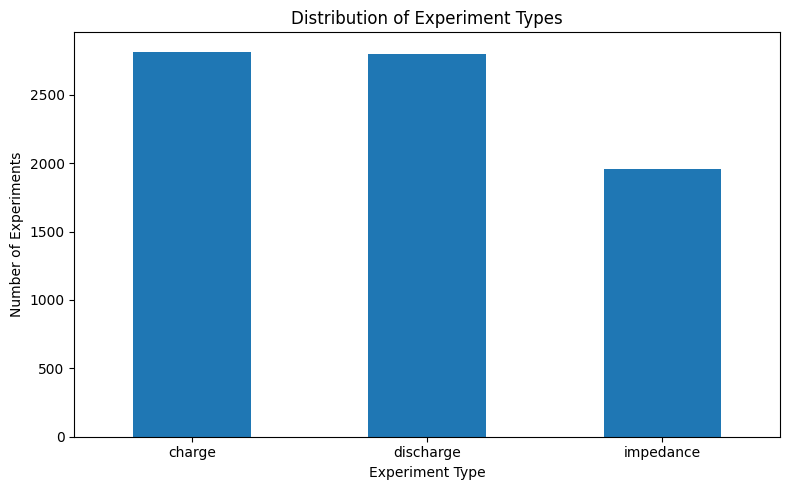

In [8]:
# ============================================================
# Cell 13: Experiment Type Distribution
# ============================================================

experiment_counts = metadata["type"].value_counts()

print("Experiment type distribution:")
display(experiment_counts)

# Visualize the distribution
plt.figure(figsize=(8, 5))

experiment_counts.plot(kind="bar")

plt.title("Distribution of Experiment Types")
plt.xlabel("Experiment Type")
plt.ylabel("Number of Experiments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9. Battery Distribution

The dataset may contain measurements from multiple batteries.

We therefore inspect the number of unique battery IDs and the number
of experiments associated with each battery.

This information will help us determine the appropriate battery-level
train/test strategy.

For battery health estimation, randomly splitting individual rows can
cause data leakage because multiple experiments from the same battery
may appear in both training and testing.

A battery-aware split is therefore preferred.

In [9]:
# ============================================================
# Cell 15: Battery Distribution
# ============================================================

unique_batteries = metadata["battery_id"].nunique()

print(f"Number of unique batteries: {unique_batteries}")

battery_counts = metadata["battery_id"].value_counts()

print("\nExperiments per battery:")
display(battery_counts)

Number of unique batteries: 34

Experiments per battery:


battery_id
B0006    616
B0007    616
B0005    616
B0034    486
B0036    486
B0033    486
B0018    319
B0042    275
B0044    275
B0043    275
B0054    253
B0056    252
B0055    252
B0047    184
B0045    184
B0048    184
B0046    184
B0041    163
B0053    137
B0040    122
B0038    122
B0039    122
B0032     97
B0031     97
B0029     97
B0030     97
B0027     80
B0028     80
B0026     80
B0025     80
B0051     62
B0052     62
B0050     62
B0049     62
Name: count, dtype: int64

In [10]:
# ============================================================
# Cell 16: Battery and Experiment Type Relationship
# ============================================================

battery_type_counts = pd.crosstab(
    metadata["battery_id"],
    metadata["type"]
)

display(battery_type_counts)

type,charge,discharge,impedance
battery_id,,,
B0005,170,168,278
B0006,170,168,278
B0007,170,168,278
B0018,134,132,53
B0025,31,28,21
B0026,31,28,21
B0027,31,28,21
B0028,31,28,21
B0029,40,40,17


## 10. Discharge Experiments

Since the objective of this notebook is battery State of Health
estimation, we now isolate the discharge experiments.

Discharge records are particularly important because battery capacity
can be determined from the discharge process.

The resulting subset will form the foundation of our SOH dataset.

We will inspect:

- Number of discharge experiments
- Batteries represented
- Available capacity measurements
- Distribution of capacity values

In [11]:
# ============================================================
# Cell 18: Extract Discharge Experiments
# ============================================================

discharge_data = metadata[
    metadata["type"].str.lower() == "discharge"
].copy()

print(f"Total discharge experiments: {len(discharge_data)}")

print("\nBatteries represented in discharge data:")
print(discharge_data["battery_id"].unique())

print("\nDischarge experiments per battery:")
display(discharge_data["battery_id"].value_counts())

Total discharge experiments: 2794

Batteries represented in discharge data:
['B0047' 'B0045' 'B0048' 'B0046' 'B0043' 'B0032' 'B0039' 'B0040' 'B0029'
 'B0028' 'B0042' 'B0034' 'B0038' 'B0033' 'B0030' 'B0041' 'B0027' 'B0044'
 'B0036' 'B0025' 'B0026' 'B0031' 'B0049' 'B0050' 'B0052' 'B0051' 'B0006'
 'B0005' 'B0007' 'B0018' 'B0053' 'B0054' 'B0056' 'B0055']

Discharge experiments per battery:


battery_id
B0034    197
B0033    197
B0036    197
B0005    168
B0006    168
B0007    168
B0018    132
B0042    112
B0044    112
B0043    112
B0054    103
B0056    102
B0055    102
B0047     72
B0045     72
B0048     72
B0046     72
B0041     67
B0053     56
B0040     47
B0038     47
B0039     47
B0032     40
B0031     40
B0029     40
B0030     40
B0027     28
B0028     28
B0026     28
B0025     28
B0051     25
B0052     25
B0050     25
B0049     25
Name: count, dtype: int64

In [12]:
# ============================================================
# Cell 19: Examine Capacity Availability
# ============================================================

capacity_available = discharge_data["Capacity"].notna()

print(f"Discharge records: {len(discharge_data)}")
print(f"Capacity available: {capacity_available.sum()}")
print(f"Capacity missing: {discharge_data['Capacity'].isna().sum()}")

print("\nCapacity statistics:")
display(discharge_data["Capacity"].describe())

Discharge records: 2794
Capacity available: 2794
Capacity missing: 0

Capacity statistics:


count     2794
unique    2752
top         []
freq        25
Name: Capacity, dtype: object

## 11. Inspecting Battery Capacity

Battery capacity is the primary quantity used to characterize battery
degradation in this study.

The metadata currently represents the `Capacity` column as an object
rather than a numerical variable. Before calculating State of Health
(SOH), we therefore need to inspect the actual values stored in this
column.

This step allows us to identify the numerical representation of
capacity and detect any unexpected values or formatting issues before
conversion.

In [13]:
# ============================================================
# Cell 20: Inspect Raw Capacity Values
# ============================================================

print("Capacity data type:")
print(discharge_data["Capacity"].dtype)

print("\nFirst 20 capacity values:")
display(discharge_data["Capacity"].head(20))

print("\nSample unique capacity values:")
display(discharge_data["Capacity"].drop_duplicates().head(30))

Capacity data type:
object

First 20 capacity values:


0     1.6743047446975208
4     1.5243662105099023
6     1.5080762969973425
8     1.4835577960067696
10    1.4671391666146525
12     1.448858156982267
16    1.4458534180949325
20     1.431118266178283
22    1.4192745516578533
24    1.3999974221808271
26    1.3885156686114437
28    1.3652234669528964
32    1.4060442272970963
36    1.4057541613525781
38    1.3867662881727878
40    1.3705053061420223
42    1.3497431114823601
44    1.3251533367939783
48    1.3111943869635805
50                     0
Name: Capacity, dtype: object


Sample unique capacity values:


0     1.6743047446975208
4     1.5243662105099023
6     1.5080762969973425
8     1.4835577960067696
10    1.4671391666146525
12     1.448858156982267
16    1.4458534180949325
20     1.431118266178283
22    1.4192745516578533
24    1.3999974221808271
26    1.3885156686114437
28    1.3652234669528964
32    1.4060442272970963
36    1.4057541613525781
38    1.3867662881727878
40    1.3705053061420223
42    1.3497431114823601
44    1.3251533367939783
48    1.3111943869635805
50                     0
52    1.3394234405932892
54    1.2849157142560723
56     1.281719159327807
60    1.2600051642942829
62     1.266070385993126
64    1.2413590294280803
66    1.2298873703485311
68     1.228088614506696
72    1.2139857189070042
74    1.2173435064564189
Name: Capacity, dtype: object

In [14]:
# ============================================================
# Cell 21: Examine Capacity Values
# ============================================================

# Convert capacity to numeric where possible.
capacity_numeric = pd.to_numeric(
    discharge_data["Capacity"],
    errors="coerce"
)

print("Original capacity values:", len(discharge_data))

print("Successfully converted to numeric:",
      capacity_numeric.notna().sum())

print("Failed conversions:",
      capacity_numeric.isna().sum())

print("\nNumeric capacity statistics:")
display(capacity_numeric.describe())

Original capacity values: 2794
Successfully converted to numeric: 2769
Failed conversions: 25

Numeric capacity statistics:


count    2769.000000
mean        1.326543
std         0.472517
min         0.000000
25%         1.150286
50%         1.428065
75%         1.673645
max         2.640149
Name: Capacity, dtype: float64

In [15]:
# ============================================================
# Cell 22: Capacity Statistics by Battery
# ============================================================

discharge_data["Capacity_numeric"] = capacity_numeric

capacity_by_battery = (
    discharge_data
    .groupby("battery_id")["Capacity_numeric"]
    .agg(["count", "min", "max", "mean"])
    .sort_index()
)

display(capacity_by_battery)

,count,min,max,mean
battery_id,,,,
B0005,168,1.287453,1.856487,1.572502
B0006,168,1.153818,2.035338,1.546851
B0007,168,1.400455,1.891052,1.644421
B0018,132,1.341051,1.855005,1.557701
B0025,28,1.767789,1.848984,1.816511
B0026,28,1.386337,1.816528,1.775935
B0027,28,1.770093,1.823308,1.804885
B0028,28,1.717234,1.804783,1.770059
B0029,40,1.612080,1.844701,1.726012


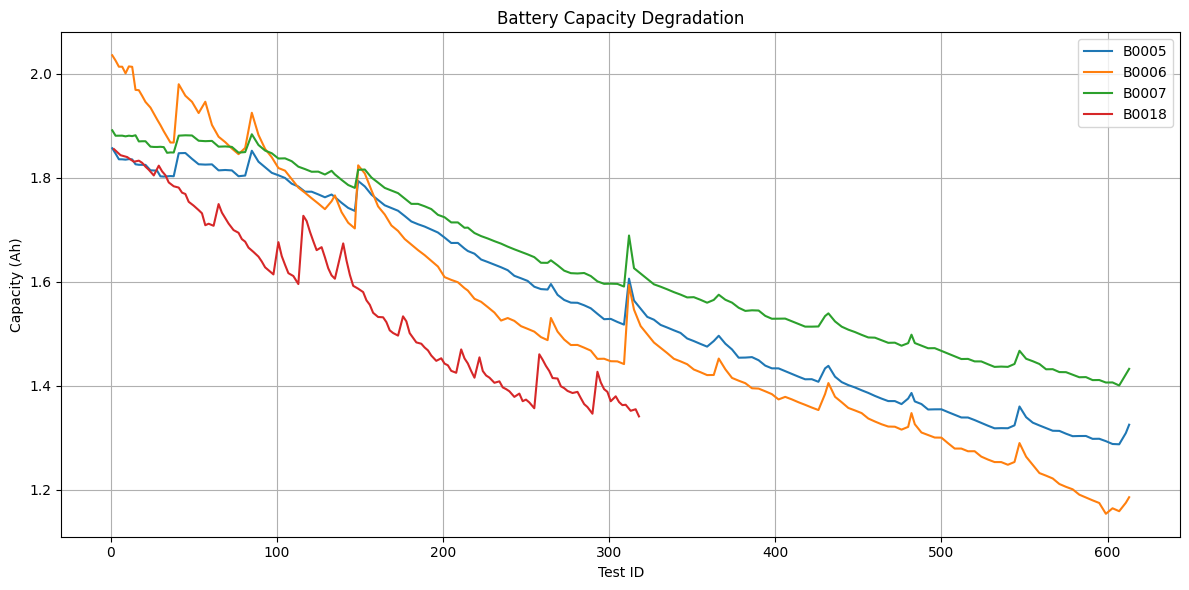

In [16]:
# ============================================================
# Cell 23: Capacity Degradation Across Experiments
# ============================================================

plt.figure(figsize=(12, 6))

for battery_id in ["B0005", "B0006", "B0007", "B0018"]:
    battery_data = discharge_data[
        discharge_data["battery_id"] == battery_id
    ].sort_values("test_id")

    plt.plot(
        battery_data["test_id"],
        battery_data["Capacity_numeric"],
        label=battery_id
    )

plt.title("Battery Capacity Degradation")
plt.xlabel("Test ID")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Investigating Invalid Capacity Values

Before calculating State of Health (SOH), the capacity measurements
must be validated.

Although every discharge experiment contains a value in the `Capacity`
field, some values cannot be interpreted as numerical measurements.

We will inspect these records to determine whether they represent:

- Missing measurements
- Empty values
- Invalid entries
- Zero-capacity measurements
- Other dataset-specific representations

Invalid capacity measurements will not be used as ground truth for
SOH estimation.

In [17]:
# ============================================================
# Cell 25: Identify Invalid Capacity Values
# ============================================================

# Convert capacity to numeric
capacity_numeric = pd.to_numeric(
    discharge_data["Capacity"],
    errors="coerce"
)

# Find records that failed conversion
invalid_capacity = discharge_data[
    capacity_numeric.isna()
].copy()

print(f"Number of invalid capacity records: {len(invalid_capacity)}")

print("\nRaw values causing conversion failure:")
display(
    invalid_capacity["Capacity"]
    .value_counts(dropna=False)
)

Number of invalid capacity records: 25

Raw values causing conversion failure:


Capacity
[]    25
Name: count, dtype: int64

In [18]:
# ============================================================
# Cell 26: Identify Zero-Capacity Records
# ============================================================

zero_capacity = discharge_data[
    capacity_numeric == 0
].copy()

print(f"Number of zero-capacity records: {len(zero_capacity)}")

print("\nZero-capacity records by battery:")
display(
    zero_capacity["battery_id"].value_counts()
)

print("\nZero-capacity records:")
display(
    zero_capacity[
        ["battery_id", "test_id", "uid", "filename", "Capacity"]
    ].head(50)
)

Number of zero-capacity records: 19

Zero-capacity records by battery:


battery_id
B0047    3
B0048    3
B0046    3
B0045    2
B0043    1
B0042    1
B0044    1
B0049    1
B0050    1
B0051    1
B0053    1
B0054    1
Name: count, dtype: int64


Zero-capacity records:


,battery_id,test_id,uid,filename,Capacity
50,B0047,50,51,00051.csv,0
132,B0047,132,133,00133.csv,0
164,B0047,164,165,00165.csv,0
234,B0045,50,235,00235.csv,0
348,B0045,164,349,00349.csv,0
418,B0048,50,419,00419.csv,0
500,B0048,132,501,00501.csv,0
532,B0048,164,533,00533.csv,0
602,B0046,50,603,00603.csv,0
684,B0046,132,685,00685.csv,0


In [19]:
# ============================================================
# Cell 27: Inspect Capacity Progression
# ============================================================

capacity_check = discharge_data[
    ["battery_id", "test_id", "filename", "Capacity"]
].copy()

capacity_check["Capacity_numeric"] = pd.to_numeric(
    capacity_check["Capacity"],
    errors="coerce"
)

capacity_check = capacity_check.sort_values(
    ["battery_id", "test_id"]
)

display(capacity_check.head(30))

,battery_id,test_id,filename,Capacity,Capacity_numeric
5121,B0005,1,05122.csv,1.8564874208181574,1.856487
5123,B0005,3,05124.csv,1.846327249719927,1.846327
5125,B0005,5,05126.csv,1.8353491942234077,1.835349
5127,B0005,7,05128.csv,1.8352625275821128,1.835263
5129,B0005,9,05130.csv,1.8346455082120419,1.834646
5131,B0005,11,05132.csv,1.8356616600675495,1.835662
5133,B0005,13,05134.csv,1.8351461429226603,1.835146
5135,B0005,15,05136.csv,1.8257567905665537,1.825757
5137,B0005,17,05138.csv,1.8247738529891333,1.824774
5139,B0005,19,05140.csv,1.824613268496936,1.824613


## 13. Cleaning Capacity Measurements

The discharge experiments contain two types of invalid capacity
measurements:

1. Empty list values represented as `[]`
2. Zero-capacity values

Neither represents a valid physical battery capacity for SOH
estimation.

These records will therefore be excluded from the supervised
SOH dataset.

The original metadata will not be modified. Instead, a cleaned
copy will be created for modelling.

In [20]:
# ============================================================
# Cell 29: Create Clean Discharge Dataset
# ============================================================

clean_discharge = discharge_data.copy()

# Convert Capacity to numeric
clean_discharge["Capacity_numeric"] = pd.to_numeric(
    clean_discharge["Capacity"],
    errors="coerce"
)

# Remove invalid / missing capacity values
clean_discharge = clean_discharge[
    clean_discharge["Capacity_numeric"].notna()
]

# Remove zero and negative capacities
clean_discharge = clean_discharge[
    clean_discharge["Capacity_numeric"] > 0
]

print("Original discharge records:", len(discharge_data))
print("Clean discharge records:", len(clean_discharge))
print("Removed records:", len(discharge_data) - len(clean_discharge))

print("\nRemaining invalid capacities:")
print(clean_discharge["Capacity_numeric"].isna().sum())

print("\nRemaining zero/negative capacities:")
print((clean_discharge["Capacity_numeric"] <= 0).sum())

Original discharge records: 2794
Clean discharge records: 2750
Removed records: 44

Remaining invalid capacities:
0

Remaining zero/negative capacities:
0


## 14. Verifying the Paper-Compliant Battery Set

The selected reference paper uses a cross-battery validation protocol:

- Battery B0005: training
- Battery B0006: testing
- Battery B0007: testing
- Battery B0018: testing

We will reproduce this experimental structure first so that
our results can be compared fairly with the published baseline.

After reproducing the baseline experiment, we will extend the
study to the remaining batteries to investigate generalization.

In [21]:
# ============================================================
# Cell 31: Verify Baseline Battery Dataset
# ============================================================

baseline_batteries = ["B0005", "B0006", "B0007", "B0018"]

baseline_data = clean_discharge[
    clean_discharge["battery_id"].isin(baseline_batteries)
].copy()

print("Baseline records:", len(baseline_data))

print("\nRecords by battery:")
display(
    baseline_data["battery_id"].value_counts().sort_index()
)

print("\nCapacity statistics:")
display(
    baseline_data.groupby("battery_id")["Capacity_numeric"]
    .agg(["count", "min", "max", "mean"])
)

Baseline records: 636

Records by battery:


battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64


Capacity statistics:


,count,min,max,mean
battery_id,,,,
B0005,168,1.287453,1.856487,1.572502
B0006,168,1.153818,2.035338,1.546851
B0007,168,1.400455,1.891052,1.644421
B0018,132,1.341051,1.855005,1.557701


## 15. Calculating Battery State of Health

State of Health (SOH) represents the remaining capacity of a
battery relative to its initial measured capacity.

For each battery:

SOH = Current Capacity / Initial Capacity

The initial capacity is determined independently for each battery
using its first valid discharge measurement.

This produces an SOH value between approximately 0 and 1 and
allows batteries with slightly different initial measured
capacities to be compared consistently.

In [22]:
# ============================================================
# Cell 33: Calculate SOH
# ============================================================

baseline_data = baseline_data.sort_values(
    ["battery_id", "test_id"]
)

# Get initial capacity for each battery
initial_capacity = (
    baseline_data
    .groupby("battery_id")["Capacity_numeric"]
    .transform("first")
)

baseline_data["Initial_Capacity"] = initial_capacity

# Calculate SOH
baseline_data["SOH"] = (
    baseline_data["Capacity_numeric"]
    / baseline_data["Initial_Capacity"]
)

print("SOH statistics:")
display(
    baseline_data.groupby("battery_id")["SOH"]
    .agg(["count", "min", "max", "mean"])
)

SOH statistics:


,count,min,max,mean
battery_id,,,,
B0005,168,0.693488,1.0,0.847031
B0006,168,0.566893,1.0,0.759997
B0007,168,0.740569,1.0,0.869580
B0018,132,0.722937,1.0,0.839729


## 16. Visualizing SOH Degradation

Before training any machine learning model, the calculated SOH
values will be visually inspected.

The expected behavior is an overall degradation trend as the
battery undergoes repeated discharge cycles, although local
increases may occur because lithium-ion battery capacity can
exhibit temporary recovery effects.

This plot will also provide a visual reference for later
comparison with the model predictions.

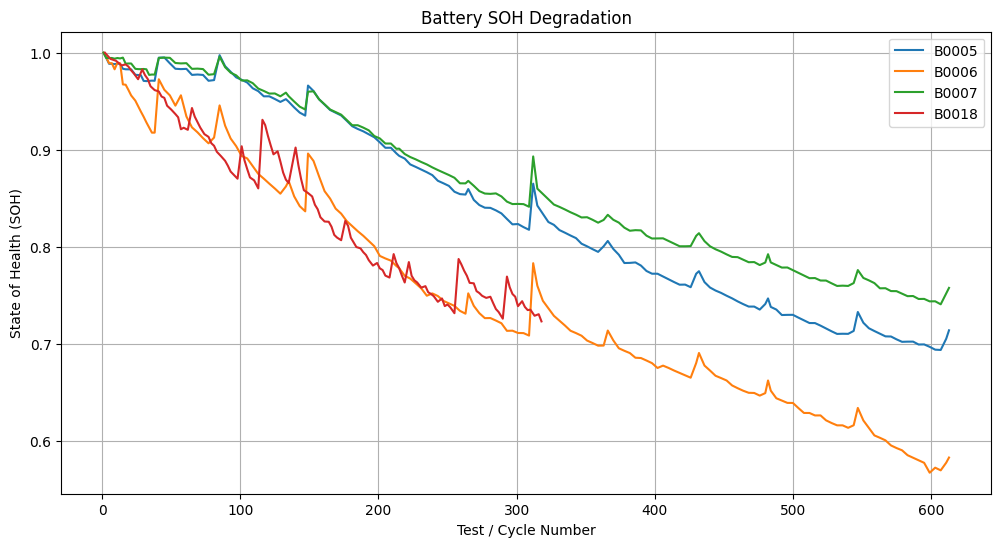

In [23]:
# ============================================================
# Cell 35: Plot SOH vs Cycle
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for battery in baseline_batteries:
    battery_subset = baseline_data[
        baseline_data["battery_id"] == battery
    ]

    plt.plot(
        battery_subset["test_id"],
        battery_subset["SOH"],
        label=battery
    )

plt.xlabel("Test / Cycle Number")
plt.ylabel("State of Health (SOH)")
plt.title("Battery SOH Degradation")
plt.legend()
plt.grid(True)

plt.show()

## 17. Inspecting Raw Discharge Measurements

The metadata contains one row per experiment, while the actual
battery measurements are stored in separate CSV files.

We will now inspect one valid discharge file to identify the
available voltage, current, temperature and time measurements.

These raw measurements will form the basis of our feature
engineering pipeline.

In [24]:
# ============================================================
# Cell 37: Inspect One Raw Discharge File
# ============================================================

# Select the first valid baseline discharge experiment
sample_record = baseline_data.iloc[0]

sample_filename = sample_record["filename"]

print("Battery:", sample_record["battery_id"])
print("Test ID:", sample_record["test_id"])
print("Filename:", sample_filename)
print("Capacity:", sample_record["Capacity_numeric"])
print("SOH:", sample_record["SOH"])

# Find the corresponding CSV file
matching_files = list(
    input_path.rglob(sample_filename)
)

print("\nMatching files found:", len(matching_files))

for file in matching_files:
    print(file)

Battery: B0005
Test ID: 1
Filename: 05122.csv
Capacity: 1.8564874208181572
SOH: 1.0

Matching files found: 1
/kaggle/input/notebooks/patrickfleith/nasa-battery-life-prediction-dataset-cleaning/tmp/05122.csv


In [25]:
# ============================================================
# Cell 38: Load and Inspect Raw Measurements
# ============================================================

raw_file = matching_files[0]

raw_data = pd.read_csv(raw_file)

print("Raw file shape:")
print(raw_data.shape)

print("\nColumns:")
print(raw_data.columns.tolist())

print("\nData types:")
print(raw_data.dtypes)

print("\nFirst five rows:")
display(raw_data.head())

Raw file shape:
(197, 6)

Columns:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time']

Data types:
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
Current_load            float64
Voltage_load            float64
Time                    float64
dtype: object

First five rows:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


## 18. Feature Engineering Strategy

Each discharge experiment contains a variable number of voltage,
current, temperature and load measurements.

Machine learning models such as XGBoost require a fixed number of
input features for every training sample.

Therefore, each discharge time series will be converted into a
fixed-length feature vector using statistical and physically
meaningful characteristics.

The extracted features will describe:

- Voltage behavior
- Current behavior
- Temperature behavior
- Load behavior
- Discharge duration

The measured capacity-derived SOH will remain the target variable.

In [26]:
# ============================================================
# Cell 40: Inspect One Discharge Experiment in Detail
# ============================================================

print("Number of measurements:", len(raw_data))

print("\nBasic statistics:")
display(raw_data.describe())

print("\nFirst measurement:")
display(raw_data.iloc[0])

print("\nLast measurement:")
display(raw_data.iloc[-1])

Number of measurements: 197

Basic statistics:


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,3.529829,-1.818702,32.572328,-1.805570,2.404944,1812.087497
std,0.236558,0.595058,3.495804,0.591217,0.796974,1069.272600
min,2.612467,-2.018015,24.325993,-1.998400,0.000000,0.000000
25%,3.418746,-2.013447,30.422589,-1.998200,2.498000,891.812000
50%,3.529903,-2.012427,32.865786,-1.998200,2.610000,1796.328000
75%,3.685214,-2.011144,35.095568,-1.998200,2.765000,2724.203000
max,4.191492,0.000729,38.982181,-0.000400,4.206000,3690.234000



First measurement:


Voltage_measured         4.191492
Current_measured        -0.004902
Temperature_measured    24.330034
Current_load            -0.000600
Voltage_load             0.000000
Time                     0.000000
Name: 0, dtype: float64


Last measurement:


Voltage_measured           3.277170
Current_measured          -0.006528
Temperature_measured      34.230853
Current_load              -0.000600
Voltage_load               0.000000
Time                    3690.234000
Name: 196, dtype: float64

In [27]:
# ============================================================
# Cell 41: Check for Missing Values in Raw Measurements
# ============================================================

print("Missing values:")
display(raw_data.isnull().sum())

print("\nInfinite values:")
display(
    np.isinf(raw_data.select_dtypes(include=np.number)).sum()
)

Missing values:


Voltage_measured        0
Current_measured        0
Temperature_measured    0
Current_load            0
Voltage_load            0
Time                    0
dtype: int64


Infinite values:


Voltage_measured        0
Current_measured        0
Temperature_measured    0
Current_load            0
Voltage_load            0
Time                    0
dtype: int64

## 19. Visualizing a Single Discharge Profile

Before extracting statistical features, the raw discharge
signals are visualized to understand how voltage, current and
temperature evolve during a discharge event.

This helps verify that the source data contains physically
meaningful time-series behavior before feature engineering.

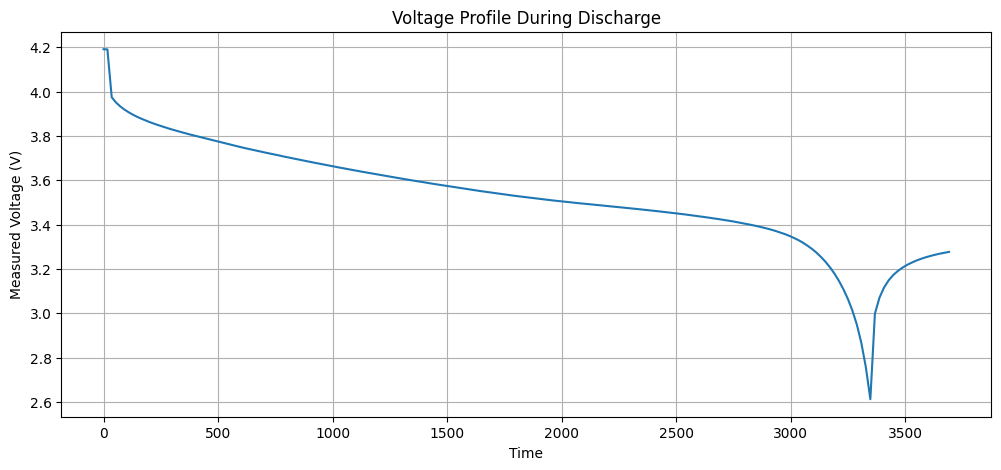

In [28]:
# ============================================================
# Cell 43: Plot Voltage During Discharge
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    raw_data["Time"],
    raw_data["Voltage_measured"]
)

plt.xlabel("Time")
plt.ylabel("Measured Voltage (V)")
plt.title("Voltage Profile During Discharge")
plt.grid(True)

plt.show()

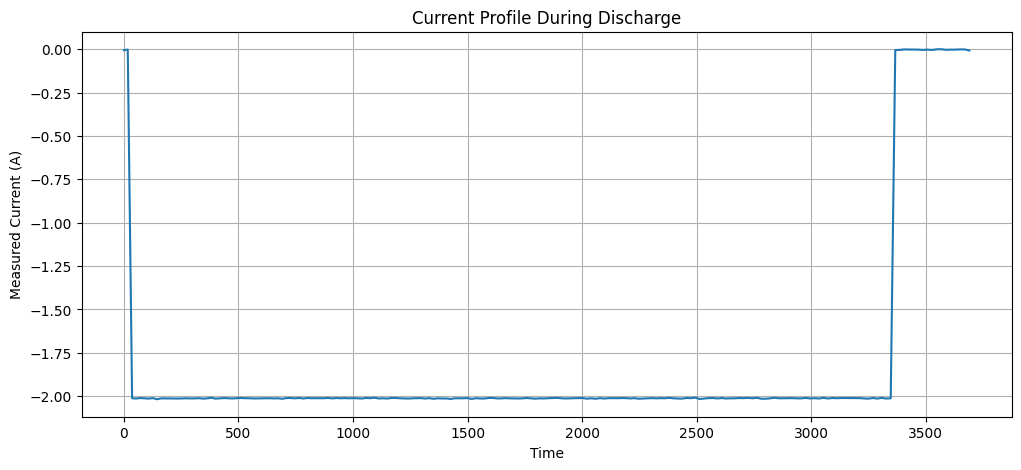

In [29]:
# ============================================================
# Cell 44: Plot Current During Discharge
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    raw_data["Time"],
    raw_data["Current_measured"]
)

plt.xlabel("Time")
plt.ylabel("Measured Current (A)")
plt.title("Current Profile During Discharge")
plt.grid(True)

plt.show()

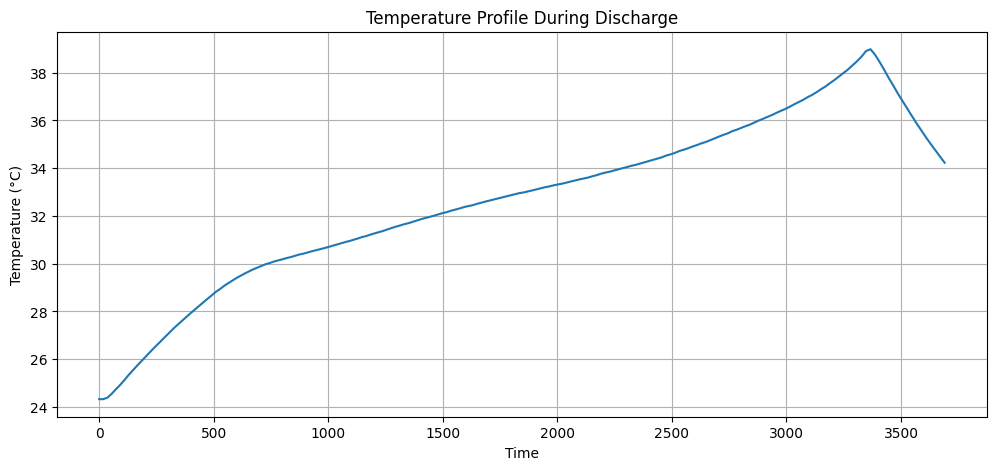

In [30]:
# ============================================================
# Cell 45: Plot Temperature During Discharge
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    raw_data["Time"],
    raw_data["Temperature_measured"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Profile During Discharge")
plt.grid(True)

plt.show()

## 20. Identifying the Active Discharge Region

The raw discharge files contain measurements before and after the
actual load is applied.

During the active discharge period, the measured current has a
large negative magnitude, while the current is approximately zero
before the discharge and after the load is removed.

To extract meaningful battery-health features, the active
discharge region will be identified using the measured current.

This prevents the idle portions of the experiment from distorting
statistics such as average current, voltage behavior and
temperature rise.

In [31]:
# ============================================================
# Cell 47: Identify Active Discharge Region
# ============================================================

current = raw_data["Current_measured"]

# Current magnitude threshold
threshold = 0.5

active_discharge = raw_data[
    current.abs() > threshold
].copy()

print("Total measurements:", len(raw_data))
print("Active discharge measurements:", len(active_discharge))

print("\nActive discharge time:")
print("Start:", active_discharge["Time"].iloc[0])
print("End:", active_discharge["Time"].iloc[-1])

print("\nCurrent statistics during active discharge:")
display(
    active_discharge["Current_measured"].describe()
)

Total measurements: 197
Active discharge measurements: 178

Active discharge time:
Start: 35.703
End: 3346.937

Current statistics during active discharge:


count    178.000000
mean      -2.012621
std        0.001463
min       -2.018015
25%       -2.013547
50%       -2.012633
75%       -2.011631
max       -2.008709
Name: Current_measured, dtype: float64

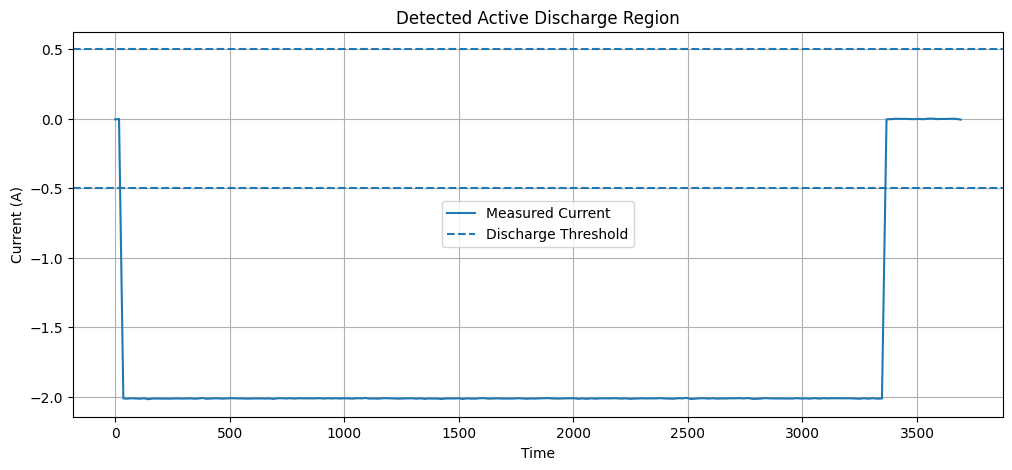

In [32]:
# ============================================================
# Cell 48: Visualize Detected Discharge Region
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    raw_data["Time"],
    raw_data["Current_measured"],
    label="Measured Current"
)

plt.axhline(
    -threshold,
    linestyle="--",
    label="Discharge Threshold"
)

plt.axhline(
    threshold,
    linestyle="--"
)

plt.xlabel("Time")
plt.ylabel("Current (A)")
plt.title("Detected Active Discharge Region")
plt.legend()
plt.grid(True)

plt.show()

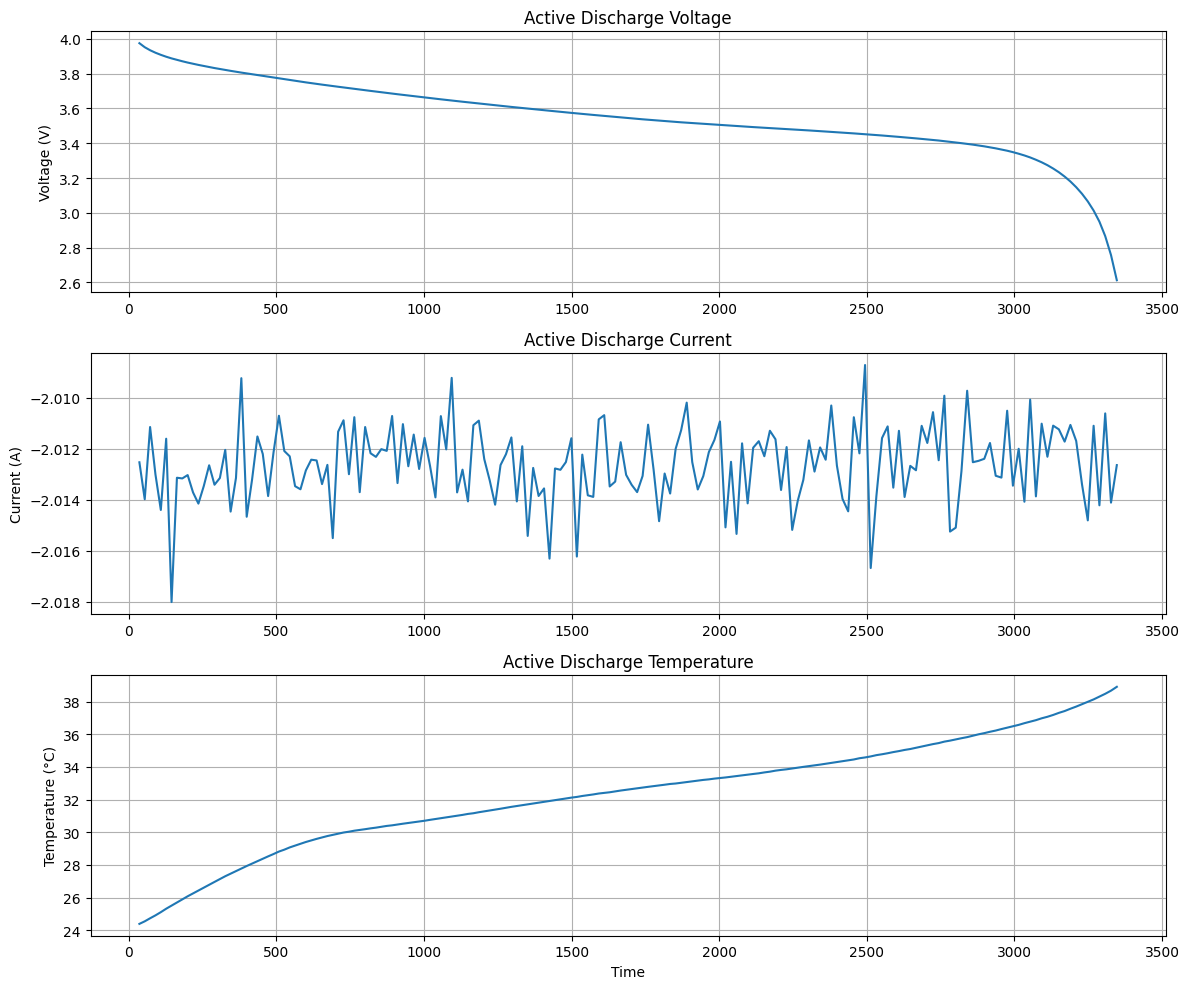

In [33]:
# ============================================================
# Cell 49: Plot Active Discharge Signals
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(
    active_discharge["Time"],
    active_discharge["Voltage_measured"]
)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Active Discharge Voltage")
axes[0].grid(True)

axes[1].plot(
    active_discharge["Time"],
    active_discharge["Current_measured"]
)
axes[1].set_ylabel("Current (A)")
axes[1].set_title("Active Discharge Current")
axes[1].grid(True)

axes[2].plot(
    active_discharge["Time"],
    active_discharge["Temperature_measured"]
)
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_title("Active Discharge Temperature")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 21. Feature Engineering

Each discharge experiment is represented by a time series of
voltage, current, temperature, load current, load voltage and time.

For machine learning, each experiment must be converted into a
fixed-length feature vector.

Statistical and physically meaningful characteristics are extracted
from the active discharge region.

The extracted features describe the electrical, thermal and temporal
behavior of the battery.

Direct integration of current over time is intentionally excluded
from the initial feature set because it can closely reproduce the
capacity measurement used to calculate the SOH target and could
introduce target leakage.

In [34]:
# ============================================================
# Cell 51: Feature Extraction Function
# ============================================================

def extract_features(raw_data):
    
    # --------------------------------------------------------
    # Identify active discharge region
    # --------------------------------------------------------
    
    threshold = 0.5
    
    active = raw_data[
        raw_data["Current_measured"].abs() > threshold
    ].copy()
    
    # Safety check
    if len(active) == 0:
        return None
    
    # --------------------------------------------------------
    # Extract signals
    # --------------------------------------------------------
    
    voltage = active["Voltage_measured"]
    current = active["Current_measured"]
    temperature = active["Temperature_measured"]
    load_current = active["Current_load"]
    load_voltage = active["Voltage_load"]
    time = active["Time"]
    
    # --------------------------------------------------------
    # Create feature dictionary
    # --------------------------------------------------------
    
    features = {
        
        # Voltage features
        "voltage_initial": voltage.iloc[0],
        "voltage_final": voltage.iloc[-1],
        "voltage_min": voltage.min(),
        "voltage_max": voltage.max(),
        "voltage_mean": voltage.mean(),
        "voltage_std": voltage.std(),
        "voltage_drop": voltage.iloc[0] - voltage.iloc[-1],
        
        # Current features
        "current_mean": current.mean(),
        "current_min": current.min(),
        "current_max": current.max(),
        "current_std": current.std(),
        
        # Temperature features
        "temperature_initial": temperature.iloc[0],
        "temperature_final": temperature.iloc[-1],
        "temperature_max": temperature.max(),
        "temperature_mean": temperature.mean(),
        "temperature_rise": temperature.max() - temperature.iloc[0],
        
        # Load features
        "load_current_mean": load_current.mean(),
        "load_current_max": load_current.max(),
        "load_voltage_mean": load_voltage.mean(),
        "load_voltage_min": load_voltage.min(),
        
        # Time feature
        "discharge_duration": time.iloc[-1] - time.iloc[0]
    }
    
    return features

In [35]:
# ============================================================
# Cell 52: Test Feature Extraction
# ============================================================

test_features = extract_features(raw_data)

print("Extracted features:")
display(
    pd.DataFrame([test_features])
)

Extracted features:


,voltage_initial,voltage_final,voltage_min,voltage_max,voltage_mean,voltage_std,voltage_drop,current_mean,current_min,current_max,current_std,temperature_initial,temperature_final,temperature_max,temperature_mean,temperature_rise,load_current_mean,load_current_max,load_voltage_mean,load_voltage_min,discharge_duration
0,3.974871,2.612467,2.612467,3.974871,3.553734,0.213428,1.362404,-2.012621,-2.018015,-2.008709,0.001463,24.389085,38.904112,38.904112,32.285161,14.515027,-1.998237,-1.9982,2.638011,1.782,3311.234


In [36]:
# ============================================================
# Cell 53: Inspect Extracted Feature Values
# ============================================================

for feature, value in test_features.items():
    print(f"{feature:25s}: {value:.6f}")

voltage_initial          : 3.974871
voltage_final            : 2.612467
voltage_min              : 2.612467
voltage_max              : 3.974871
voltage_mean             : 3.553734
voltage_std              : 0.213428
voltage_drop             : 1.362404
current_mean             : -2.012621
current_min              : -2.018015
current_max              : -2.008709
current_std              : 0.001463
temperature_initial      : 24.389085
temperature_final        : 38.904112
temperature_max          : 38.904112
temperature_mean         : 32.285161
temperature_rise         : 14.515027
load_current_mean        : -1.998237
load_current_max         : -1.998200
load_voltage_mean        : 2.638011
load_voltage_min         : 1.782000
discharge_duration       : 3311.234000


## 22. Building the Machine Learning Dataset

The feature extraction function has been validated on an individual
discharge experiment.

We will now apply the same procedure to every valid discharge
experiment from batteries B0005, B0006, B0007 and B0018.

Each discharge experiment becomes one row in the machine learning
dataset.

The dataset will contain:

- Battery identifier
- Test identifier
- 22 engineered input features
- SOH as the prediction target

Battery and test identifiers will be retained for analysis but will
not be used as machine learning features.

In [37]:
# ============================================================
# Cell 55: Create Filename-to-Path Mapping
# ============================================================

# Create a mapping so we can quickly locate each measurement CSV
# without repeatedly searching the entire dataset.

file_map = {}

for file in csv_files:
    file_map[file.name] = file

print("Measurement files indexed:", len(file_map))

# Check that every baseline experiment has a corresponding file
missing_files = []

for filename in baseline_data["filename"]:
    if filename not in file_map:
        missing_files.append(filename)

print("Missing baseline measurement files:", len(missing_files))

if missing_files:
    print("\nMissing filenames:")
    print(missing_files[:20])

Measurement files indexed: 7566
Missing baseline measurement files: 0


In [38]:
# ============================================================
# Cell 56: Extract Features from All Baseline Experiments
# ============================================================

feature_rows = []

for _, record in baseline_data.iterrows():
    
    filename = record["filename"]
    
    # Locate measurement file
    raw_file = file_map.get(filename)
    
    if raw_file is None:
        continue
    
    # Load raw measurement data
    raw = pd.read_csv(raw_file)
    
    # Extract features
    features = extract_features(raw)
    
    # Skip experiments where active discharge could not be found
    if features is None:
        continue
    
    # Add experiment metadata
    features["battery_id"] = record["battery_id"]
    features["test_id"] = record["test_id"]
    features["filename"] = filename
    
    # Add target variables
    features["Capacity"] = record["Capacity_numeric"]
    features["SOH"] = record["SOH"]
    
    feature_rows.append(features)

# Convert all feature dictionaries into a DataFrame
ml_dataset = pd.DataFrame(feature_rows)

print("Machine learning dataset shape:")
print(ml_dataset.shape)

print("\nFirst five rows:")
display(ml_dataset.head())

Machine learning dataset shape:
(636, 26)

First five rows:


,voltage_initial,voltage_final,voltage_min,voltage_max,voltage_mean,voltage_std,voltage_drop,current_mean,current_min,current_max,current_std,temperature_initial,temperature_final,temperature_max,temperature_mean,temperature_rise,load_current_mean,load_current_max,load_voltage_mean,load_voltage_min,discharge_duration,battery_id,test_id,filename,Capacity,SOH
0,3.974871,2.612467,2.612467,3.974871,3.553734,0.213428,1.362404,-2.012621,-2.018015,-2.008709,0.001463,24.389085,38.904112,38.904112,32.285161,14.515027,-1.998237,-1.9982,2.638011,1.782,3311.234,B0005,1,05122.csv,1.856487,1.000000
1,3.979157,2.587209,2.587209,3.979157,3.560999,0.212552,1.391948,-2.012561,-2.016821,-2.008829,0.001481,24.738132,38.934590,38.934590,32.438327,14.196458,-1.998231,-1.9980,2.633028,1.766,3293.125,B0005,3,05124.csv,1.846327,0.994527
2,3.979995,2.651917,2.651917,3.979995,3.565476,0.207369,1.328078,-2.012474,-2.016574,-2.007352,0.001622,24.791450,38.743649,38.743649,32.363279,13.952199,-1.998217,-1.9982,2.632949,1.820,3273.656,B0005,5,05126.csv,1.835349,0.988614
3,3.981613,2.592948,2.592948,3.981613,3.565378,0.211632,1.388665,-2.012181,-2.015936,-2.008008,0.001530,24.697864,38.672511,38.672511,32.236975,13.974647,-1.998208,-1.9982,2.630705,1.772,3273.969,B0005,7,05128.csv,1.835263,0.988567
4,3.982253,2.547420,2.547420,3.982253,3.565019,0.214690,1.434834,-2.012707,-2.017426,-2.009143,0.001565,24.571624,38.558828,38.558828,32.099754,13.987204,-1.998223,-1.9982,2.630949,1.738,3272.032,B0005,9,05130.csv,1.834646,0.988235


## 23. Verifying the Machine Learning Dataset

Before training a model, the engineered dataset must be checked
for missing values, duplicate experiments and invalid numerical
values.

This verification ensures that problems in individual raw CSV
files have not propagated into the final modelling dataset.

In [40]:
# ============================================================
# Cell 58: Dataset Quality Check
# ============================================================

print("Dataset shape:")
print(ml_dataset.shape)

print("\nMissing values:")
display(
    ml_dataset.isnull().sum()
)

print("\nDuplicate rows:")
print(
    ml_dataset.duplicated().sum()
)

print("\nInfinite numerical values:")
display(
    np.isinf(
        ml_dataset.select_dtypes(include=np.number)
    ).sum()
)

Dataset shape:
(636, 26)

Missing values:


voltage_initial        0
voltage_final          0
voltage_min            0
voltage_max            0
voltage_mean           0
voltage_std            0
voltage_drop           0
current_mean           0
current_min            0
current_max            0
current_std            0
temperature_initial    0
temperature_final      0
temperature_max        0
temperature_mean       0
temperature_rise       0
load_current_mean      0
load_current_max       0
load_voltage_mean      0
load_voltage_min       0
discharge_duration     0
battery_id             0
test_id                0
filename               0
Capacity               0
SOH                    0
dtype: int64


Duplicate rows:
0

Infinite numerical values:


voltage_initial        0
voltage_final          0
voltage_min            0
voltage_max            0
voltage_mean           0
voltage_std            0
voltage_drop           0
current_mean           0
current_min            0
current_max            0
current_std            0
temperature_initial    0
temperature_final      0
temperature_max        0
temperature_mean       0
temperature_rise       0
load_current_mean      0
load_current_max       0
load_voltage_mean      0
load_voltage_min       0
discharge_duration     0
test_id                0
Capacity               0
SOH                    0
dtype: int64

In [41]:
# ============================================================
# Cell 59: Verify Experiments by Battery
# ============================================================

print("Experiments in final ML dataset:")

display(
    ml_dataset["battery_id"]
    .value_counts()
    .sort_index()
)

Experiments in final ML dataset:


battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64

In [42]:
# ============================================================
# Cell 60: Feature Statistics
# ============================================================

feature_columns = [
    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",
    "current_mean",
    "current_min",
    "current_max",
    "current_std",
    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",
    "load_current_mean",
    "load_current_max",
    "load_voltage_mean",
    "load_voltage_min",
    "discharge_duration"
]

display(
    ml_dataset[feature_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
voltage_initial,636.0,3.981274,0.024224,3.900683,3.972560,3.986587,3.997417,4.035025
voltage_final,636.0,2.387737,0.219906,1.737030,2.186663,2.421034,2.529182,2.699983
voltage_min,636.0,2.387737,0.219906,1.737030,2.186663,2.421034,2.529182,2.699983
voltage_max,636.0,3.981274,0.024224,3.900683,3.972560,3.986587,3.997417,4.035025
voltage_mean,636.0,3.502418,0.056004,3.344863,3.472727,3.513329,3.550925,3.575355
voltage_std,636.0,0.239912,0.016433,0.203613,0.227981,0.241050,0.250617,0.275899
voltage_drop,636.0,1.593537,0.227270,1.270101,1.425197,1.539660,1.816170,2.260347
current_mean,636.0,-2.005045,0.009430,-2.013171,-2.012234,-2.010045,-1.989858,-1.988886
current_min,636.0,-2.010235,0.009747,-2.029098,-2.016468,-2.014195,-2.000385,-1.992201
current_max,636.0,-1.999972,0.009621,-2.009389,-2.006757,-2.004576,-1.986050,-1.974808


## 24. Validating Load Current Measurements

The engineered dataset shows that load current has both positive
and negative values across the experiments.

Before using load current as a machine learning feature, its
behavior must be inspected to determine whether the variation
represents actual experimental behavior or a sign convention in
the source data.

This check prevents potentially misleading features from entering
the model.

In [43]:
# ============================================================
# Cell 62: Inspect Load Current Distribution
# ============================================================

print("Load current statistics:")

display(
    ml_dataset["load_current_mean"].describe()
)

print("\nExperiments with negative mean load current:")

negative_load = ml_dataset[
    ml_dataset["load_current_mean"] < 0
]

print("Count:", len(negative_load))

display(
    negative_load[
        [
            "battery_id",
            "test_id",
            "filename",
            "load_current_mean",
            "load_current_max"
        ]
    ].head(20)
)

Load current statistics:


count    636.000000
mean       1.414338
std        1.413749
min       -2.000000
25%        1.998163
50%        1.998745
75%        1.999027
max        2.000000
Name: load_current_mean, dtype: float64


Experiments with negative mean load current:
Count: 93


,battery_id,test_id,filename,load_current_mean,load_current_max
0,B0005,1,05122.csv,-1.998237,-1.9982
1,B0005,3,05124.csv,-1.998231,-1.9980
2,B0005,5,05126.csv,-1.998217,-1.9982
3,B0005,7,05128.csv,-1.998208,-1.9982
4,B0005,9,05130.csv,-1.998223,-1.9982
5,B0005,11,05132.csv,-1.998305,-1.9982
6,B0005,13,05134.csv,-1.998264,-1.9982
7,B0005,15,05136.csv,-1.998224,-1.9982
8,B0005,17,05138.csv,-1.998213,-1.9982
9,B0005,19,05140.csv,-1.998200,-1.9982


In [45]:
# ============================================================
# Cell 63: Inspect Raw Load Current for an Anomalous Experiment
# ============================================================

if len(negative_load) > 0:

    anomalous_filename = negative_load.iloc[0]["filename"]

    anomalous_file = file_map[anomalous_filename]

    anomalous_raw = pd.read_csv(anomalous_file)

    print("Battery:",
          negative_load.iloc[0]["battery_id"])

    print("Test ID:",
          negative_load.iloc[0]["test_id"])

    print("Filename:",
          anomalous_filename)

    print("\nUnique Current_load values:")
    print(
        anomalous_raw["Current_load"]
        .value_counts()
        .sort_index()
    )

    print("\nUnique Current_measured values/range:")
    print(
        anomalous_raw["Current_measured"].describe()
    )

Battery: B0005
Test ID: 1
Filename: 05122.csv

Unique Current_load values:
Current_load
-1.9984     33
-1.9982    145
-0.0006     17
-0.0004      2
Name: count, dtype: int64

Unique Current_measured values/range:
count    197.000000
mean      -1.818702
std        0.595058
min       -2.018015
25%       -2.013447
50%       -2.012427
75%       -2.011144
max        0.000729
Name: Current_measured, dtype: float64


## 25. Inspecting the SOH Target

SOH is the target variable that the machine learning models will
predict.

The distribution and range of SOH values are inspected before
training to ensure that the target contains a meaningful battery
degradation signal.

In [46]:
# ============================================================
# Cell 65: SOH Statistics
# ============================================================

print("Overall SOH statistics:")

display(
    ml_dataset["SOH"].describe()
)

print("\nSOH statistics by battery:")

display(
    ml_dataset.groupby("battery_id")["SOH"]
    .agg(["count", "min", "max", "mean"])
)

Overall SOH statistics:


count    636.000000
mean       0.828482
std        0.109306
min        0.566893
25%        0.748067
50%        0.823178
75%        0.925262
max        1.000000
Name: SOH, dtype: float64


SOH statistics by battery:


,count,min,max,mean
battery_id,,,,
B0005,168,0.693488,1.0,0.847031
B0006,168,0.566893,1.0,0.759997
B0007,168,0.740569,1.0,0.869580
B0018,132,0.722937,1.0,0.839729


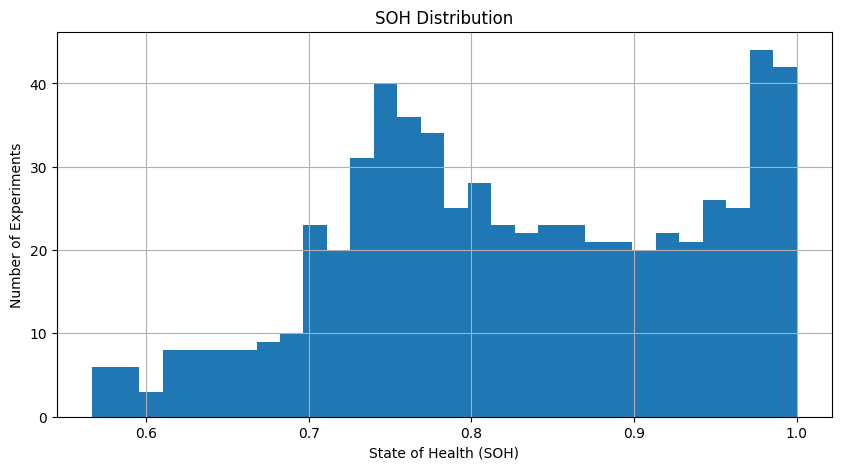

In [47]:
# ============================================================
# Cell 66: SOH Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    ml_dataset["SOH"],
    bins=30
)

plt.xlabel("State of Health (SOH)")
plt.ylabel("Number of Experiments")
plt.title("SOH Distribution")

plt.grid(True)
plt.show()

## 26. Feature Correlation Analysis

Correlation analysis is used as an exploratory step to understand
the relationship between engineered battery features and SOH.

This analysis does not determine which features the machine
learning model must use. Tree-based models such as XGBoost can
capture nonlinear relationships that simple correlation does not
represent.

The analysis is also used to identify highly redundant features.

In [48]:
# ============================================================
# Cell 68: Correlation with SOH
# ============================================================

correlation_with_soh = (
    ml_dataset[feature_columns + ["SOH"]]
    .corr()["SOH"]
    .drop("SOH")
    .sort_values()
)

print("Feature correlation with SOH:")

display(
    correlation_with_soh.to_frame("correlation")
)

Feature correlation with SOH:


,correlation
temperature_rise,-0.666099
temperature_final,-0.560445
temperature_max,-0.560398
load_current_max,-0.544110
load_current_mean,-0.544105
voltage_std,-0.513647
temperature_mean,-0.385330
voltage_final,-0.200256
voltage_min,-0.200256
load_voltage_min,-0.148783


In [49]:
# ============================================================
# Cell 69: Identify Highly Correlated Feature Pairs
# ============================================================

feature_corr = ml_dataset[feature_columns].corr()

high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        correlation = feature_corr.iloc[i, j]

        if abs(correlation) >= 0.95:
            high_corr_pairs.append(
                (
                    feature_columns[i],
                    feature_columns[j],
                    correlation
                )
            )

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

display(
    high_corr_pairs_df.sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
)

,Feature 1,Feature 2,Correlation
0,voltage_initial,voltage_max,1.000000
1,voltage_final,voltage_min,1.000000
10,load_current_mean,load_current_max,1.000000
9,temperature_final,temperature_max,0.999998
2,voltage_final,voltage_drop,-0.994672
4,voltage_min,voltage_drop,-0.994672
6,voltage_drop,load_voltage_min,-0.982744
5,voltage_min,load_voltage_min,0.982101
3,voltage_final,load_voltage_min,0.982101
8,current_mean,current_max,0.975499


## 27. Standardizing Load Current Representation

The NASA dataset uses a current sign convention in which the
direction of load current can vary between experiments.

For SOH estimation, the magnitude of the applied load is more
relevant than its sign.

Therefore, load current will be represented using its absolute
magnitude.

This prevents the model from learning an experimental sign
convention instead of a physical battery characteristic.

In [50]:
# ============================================================
# Cell 71: Convert Load Current Features to Magnitude
# ============================================================

# Replace the signed load-current features with magnitude-based
# features.

ml_dataset["load_current_abs_mean"] = (
    ml_dataset["load_current_mean"].abs()
)

ml_dataset["load_current_abs_max"] = (
    ml_dataset["load_current_max"].abs()
)

# Remove the original signed features
ml_dataset = ml_dataset.drop(
    columns=[
        "load_current_mean",
        "load_current_max"
    ]
)

print("Updated dataset shape:")
print(ml_dataset.shape)

Updated dataset shape:
(636, 26)


In [51]:
# ============================================================
# Cell 72: Final Feature List
# ============================================================

feature_columns = [
    
    # Voltage
    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",
    
    # Current
    "current_mean",
    "current_min",
    "current_max",
    "current_std",
    
    # Temperature
    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",
    
    # Load
    "load_current_abs_mean",
    "load_current_abs_max",
    "load_voltage_mean",
    "load_voltage_min",
    
    # Time
    "discharge_duration"
]

print("Number of ML features:", len(feature_columns))

print("\nFeatures:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:2d}. {feature}")

Number of ML features: 21

Features:
 1. voltage_initial
 2. voltage_final
 3. voltage_min
 4. voltage_max
 5. voltage_mean
 6. voltage_std
 7. voltage_drop
 8. current_mean
 9. current_min
10. current_max
11. current_std
12. temperature_initial
13. temperature_final
14. temperature_max
15. temperature_mean
16. temperature_rise
17. load_current_abs_mean
18. load_current_abs_max
19. load_voltage_mean
20. load_voltage_min
21. discharge_duration


In [52]:
# ============================================================
# Cell 73: Final Dataset Validation
# ============================================================

X_check = ml_dataset[feature_columns]
y_check = ml_dataset["SOH"]

print("Input feature matrix:")
print("Rows:", X_check.shape[0])
print("Features:", X_check.shape[1])

print("\nMissing values:")
print(X_check.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_check).sum().sum())

print("\nTarget missing values:")
print(y_check.isnull().sum())

print("\nTarget range:")
print("Minimum SOH:", y_check.min())
print("Maximum SOH:", y_check.max())

Input feature matrix:
Rows: 636
Features: 21

Missing values:
0

Infinite values:
0

Target missing values:
0

Target range:
Minimum SOH: 0.5668928519254556
Maximum SOH: 1.0


## 28. Paper-Compliant Train/Test Split

To evaluate cross-battery generalization, the model will be trained
using battery B0005 and evaluated on previously unseen batteries
B0006, B0007 and B0018.

This avoids randomly mixing cycles from the same battery between
training and testing.

The input variables consist only of the engineered battery
measurement features.

Battery identifiers, experiment identifiers, filename and measured
capacity are retained only for analysis and are excluded from the
model inputs.

In [54]:
# ============================================================
# Cell 75: Create Train/Test Split
# ============================================================

train_battery = "B0005"

test_batteries = [
    "B0006",
    "B0007",
    "B0018"
]

# Training data
train_data = ml_dataset[
    ml_dataset["battery_id"] == train_battery
].copy()

# Testing data
test_data = ml_dataset[
    ml_dataset["battery_id"].isin(test_batteries)
].copy()

# Input features
X_train = train_data[feature_columns]
X_test = test_data[feature_columns]

# Target
y_train = train_data["SOH"]
y_test = test_data["SOH"]

print("Training set:")
print("Rows:", X_train.shape[0])
print("Features:", X_train.shape[1])

print("\nTesting set:")
print("Rows:", X_test.shape[0])
print("Features:", X_test.shape[1])

print("\nTraining battery:")
print(train_data["battery_id"].unique())

print("\nTesting batteries:")
print(test_data["battery_id"].unique())

Training set:
Rows: 168
Features: 21

Testing set:
Rows: 468
Features: 21

Training battery:
['B0005']

Testing batteries:
['B0006' 'B0007' 'B0018']


## 29. Checking for Data Leakage

The testing batteries must not appear in the training dataset.

This check ensures that the model is evaluated on batteries that
were not used during training.

In [55]:
# ============================================================
# Cell 77: Verify Battery Separation
# ============================================================

train_batteries = set(train_data["battery_id"].unique())
test_batteries_set = set(test_data["battery_id"].unique())

print("Training batteries:", train_batteries)
print("Testing batteries:", test_batteries_set)

overlap = train_batteries.intersection(test_batteries_set)

print("\nBattery overlap:", overlap)

if len(overlap) == 0:
    print("✓ No battery leakage detected.")
else:
    print("WARNING: Battery overlap detected!")

Training batteries: {'B0005'}
Testing batteries: {'B0018', 'B0007', 'B0006'}

Battery overlap: set()
✓ No battery leakage detected.


## 30. Initial XGBoost Baseline

XGBoost is selected as the first machine learning model because
the reference study identifies XGBoost as one of the strongest
performers among the evaluated machine learning approaches.

The first experiment intentionally uses a simple, unoptimized
XGBoost configuration.

No hyperparameter search is performed at this stage.

The purpose of this experiment is to establish a baseline
performance before introducing model optimization or additional
feature engineering.

In [56]:
# ============================================================
# Cell 79: Train Initial XGBoost Model
# ============================================================

from xgboost import XGBRegressor

xgb_baseline = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# Train the model
xgb_baseline.fit(
    X_train,
    y_train
)

print("XGBoost baseline model trained successfully.")

XGBoost baseline model trained successfully.


## 31. Generating SOH Predictions

The trained XGBoost model will now predict SOH for the three
previously unseen batteries.

These predictions will be compared with the measured SOH values
from the NASA dataset.

In [57]:
# ============================================================
# Cell 81: Generate Predictions
# ============================================================

y_pred = xgb_baseline.predict(X_test)

print("Number of predictions:", len(y_pred))

print("\nFirst 10 predictions:")
print(y_pred[:10])

Number of predictions: 468

First 10 predictions:
[0.9782953  0.9974483  0.9976938  0.99711275 0.9976938  0.9965646
 0.9966452  0.99711275 0.99711275 0.9976938 ]


## 32. Model Evaluation Metrics

The model will be evaluated using four regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

MAE represents the average absolute prediction error.

MSE penalizes larger errors more strongly.

RMSE expresses the prediction error in the same units as SOH.

R² measures how much of the variation in SOH is explained by
the model.

In [58]:
# ============================================================
# Cell 83: Calculate Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("XGBoost Baseline Performance")
print("--------------------------------")
print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

XGBoost Baseline Performance
--------------------------------
MAE  : 0.031389
MSE  : 0.001781
RMSE : 0.042204
R²   : 0.855063


In [60]:
# ============================================================
# Cell 84: Per-Battery Evaluation
# ============================================================

test_results = test_data[
    ["battery_id", "test_id", "SOH"]
].copy()

test_results["Predicted_SOH"] = y_pred

battery_metrics = []

for battery in test_batteries:
    
    battery_results = test_results[
        test_results["battery_id"] == battery
    ]
    
    actual = battery_results["SOH"]
    predicted = battery_results["Predicted_SOH"]
    
    battery_mae = mean_absolute_error(
        actual,
        predicted
    )
    
    battery_mse = mean_squared_error(
        actual,
        predicted
    )
    
    battery_rmse = np.sqrt(battery_mse)
    
    battery_r2 = r2_score(
        actual,
        predicted
    )
    
    battery_metrics.append({
        "battery_id": battery,
        "MAE": battery_mae,
        "MSE": battery_mse,
        "RMSE": battery_rmse,
        "R2": battery_r2
    })

battery_metrics_df = pd.DataFrame(
    battery_metrics
)

display(battery_metrics_df)

,battery_id,MAE,MSE,RMSE,R2
0,B0006,0.063250,0.004440,0.066632,0.708728
1,B0007,0.019573,0.000471,0.021696,0.934633
2,B0018,0.005879,0.000065,0.008087,0.990548


## 33. Actual vs Predicted SOH

The actual SOH values are compared with the XGBoost predictions
for each test battery.

A strong model should follow the degradation trajectory while
avoiding systematic overestimation or underestimation.

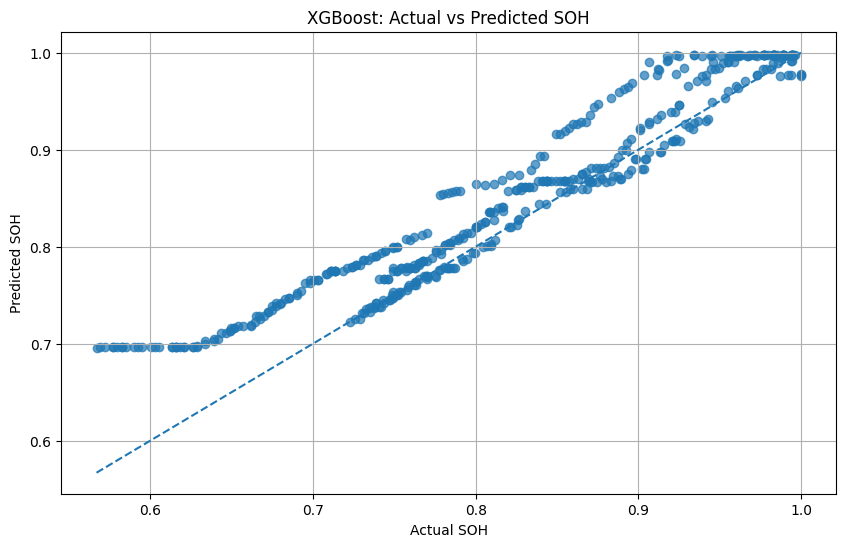

In [61]:
# ============================================================
# Cell 86: Actual vs Predicted SOH
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("XGBoost: Actual vs Predicted SOH")

plt.grid(True)
plt.show()

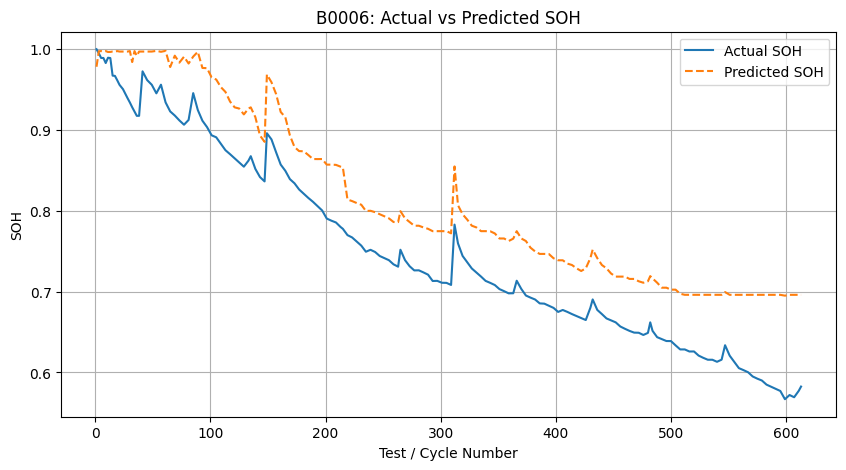

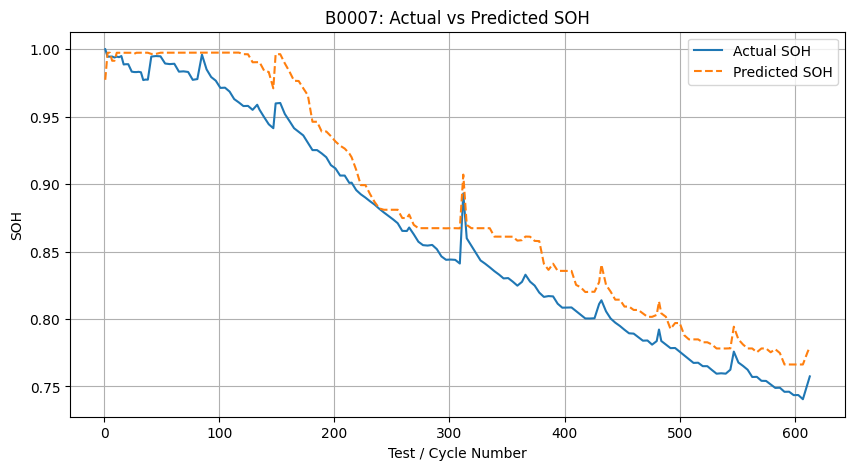

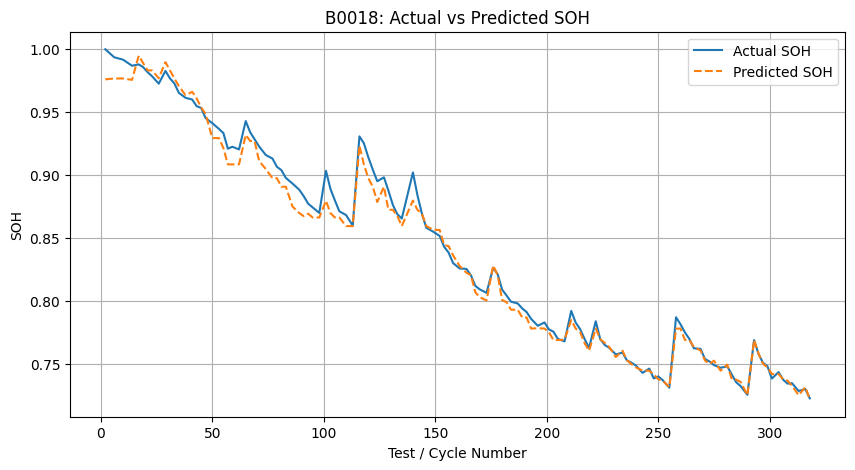

In [62]:
# ============================================================
# Cell 87: Plot Actual and Predicted SOH by Test Cycle
# ============================================================

for battery in test_batteries:
    
    battery_results = test_results[
        test_results["battery_id"] == battery
    ].sort_values("test_id")
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(
        battery_results["test_id"],
        battery_results["SOH"],
        label="Actual SOH"
    )
    
    plt.plot(
        battery_results["test_id"],
        battery_results["Predicted_SOH"],
        linestyle="--",
        label="Predicted SOH"
    )
    
    plt.xlabel("Test / Cycle Number")
    plt.ylabel("SOH")
    plt.title(f"{battery}: Actual vs Predicted SOH")
    
    plt.legend()
    plt.grid(True)
    plt.show()

## 34. XGBoost Feature Importance

The trained XGBoost model provides feature-importance scores that
indicate which engineered features contributed most strongly to
the model's predictions.

This analysis is used to understand the baseline model before
performing further feature engineering or hyperparameter
optimization.

Feature importance is treated as an exploratory analysis rather
than proof of causality.

In [63]:
# ============================================================
# Cell 89: XGBoost Feature Importance
# ============================================================

importance_values = xgb_baseline.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
20,discharge_duration,0.833301
4,voltage_mean,0.149244
18,load_voltage_mean,0.012035
16,load_current_abs_mean,0.003353
0,voltage_initial,0.000657
1,voltage_final,0.000504
15,temperature_rise,0.000237
12,temperature_final,0.000159
5,voltage_std,0.000129
8,current_min,0.000113


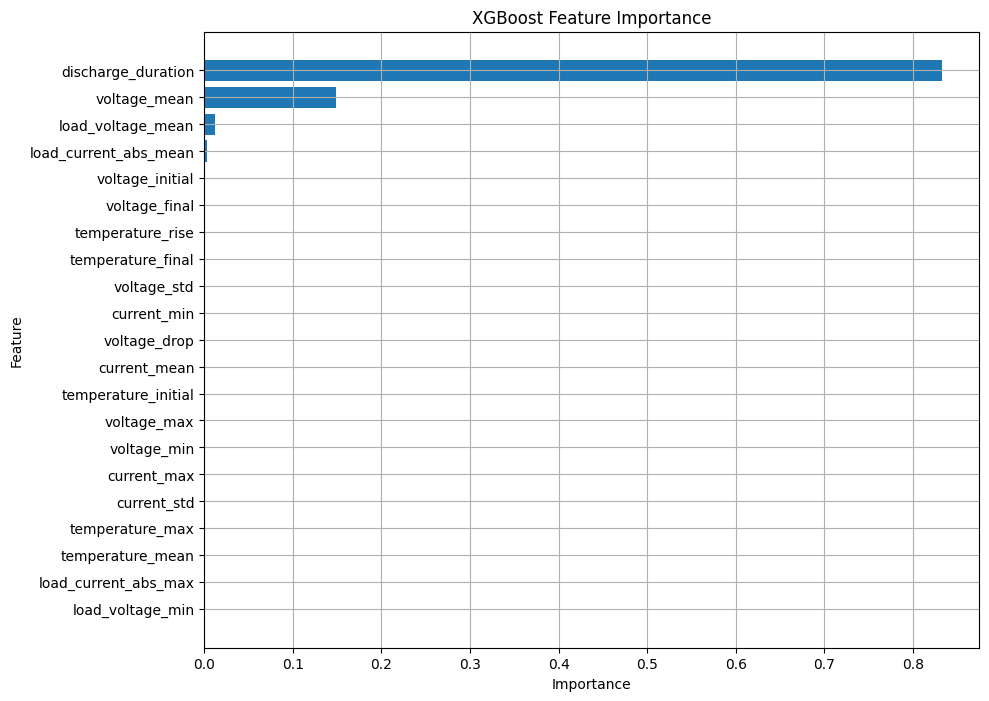

In [64]:
# ============================================================
# Cell 90: Plot Feature Importance
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.grid(True)
plt.show()

## 35. Permutation Feature Importance

Permutation importance evaluates the practical contribution of
each feature by randomly shuffling that feature and measuring the
resulting deterioration in model performance.

Unlike native tree-based feature importance, permutation importance
evaluates feature usefulness with respect to the model's actual
predictions.

The test set is used for this analysis only after the baseline
model has already been trained.

In [65]:
# ============================================================
# Cell 92: Permutation Importance
# ============================================================

from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    xgb_baseline,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_STD": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Importance_Mean",
    ascending=False
)

display(permutation_importance_df)

,Feature,Importance_Mean,Importance_STD
20,discharge_duration,7.489667e-02,0.003238
4,voltage_mean,8.134399e-03,0.000257
18,load_voltage_mean,3.148544e-04,0.000023
12,temperature_final,8.243469e-05,0.000008
15,temperature_rise,3.639109e-05,0.000006
11,temperature_initial,2.546514e-05,0.000004
5,voltage_std,6.534337e-06,0.000001
1,voltage_final,0.000000e+00,0.000000
2,voltage_min,0.000000e+00,0.000000
16,load_current_abs_mean,0.000000e+00,0.000000


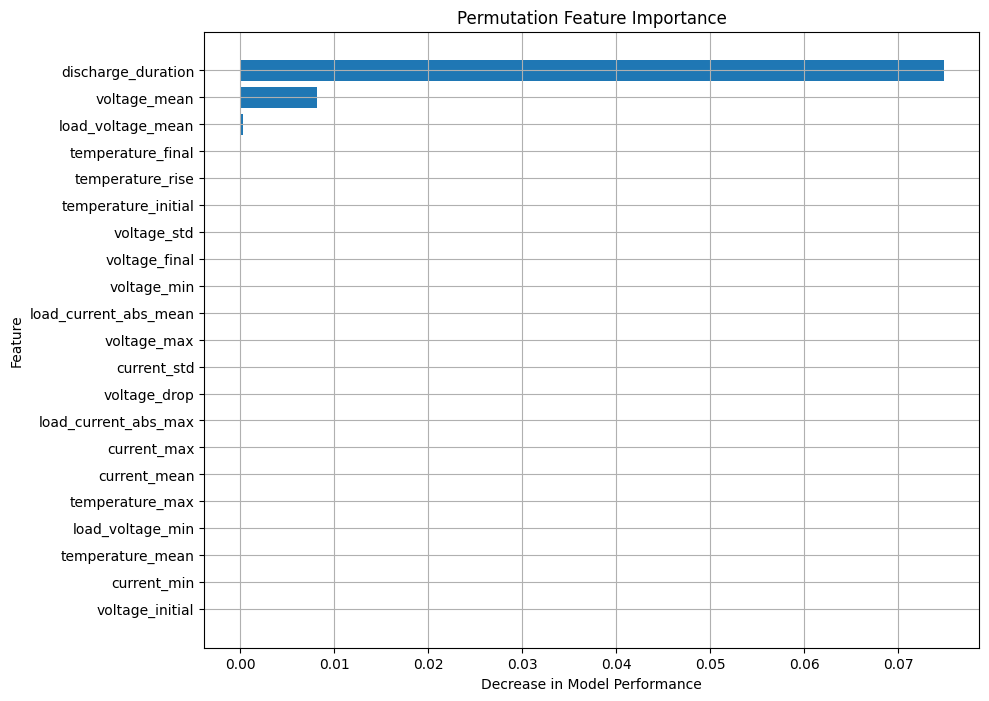

In [66]:
# ============================================================
# Cell 93: Plot Permutation Importance
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance_Mean"]
)

plt.xlabel("Decrease in Model Performance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.grid(True)
plt.show()

## 36. SHAP-Based Model Interpretation

SHAP (SHapley Additive exPlanations) is used to understand how
individual input features influence the XGBoost model predictions.

Unlike simple feature importance, SHAP values provide both:

- Feature importance
- Direction of influence

A positive SHAP value indicates that a feature pushes the
prediction toward a higher SOH.

A negative SHAP value indicates that a feature pushes the
prediction toward a lower SOH.

SHAP analysis will help determine whether the baseline model is
using physically meaningful battery degradation characteristics.

In [67]:
# ============================================================
# Cell 95: Calculate SHAP Values
# ============================================================

import shap

explainer = shap.TreeExplainer(xgb_baseline)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP shape: (468, 21)


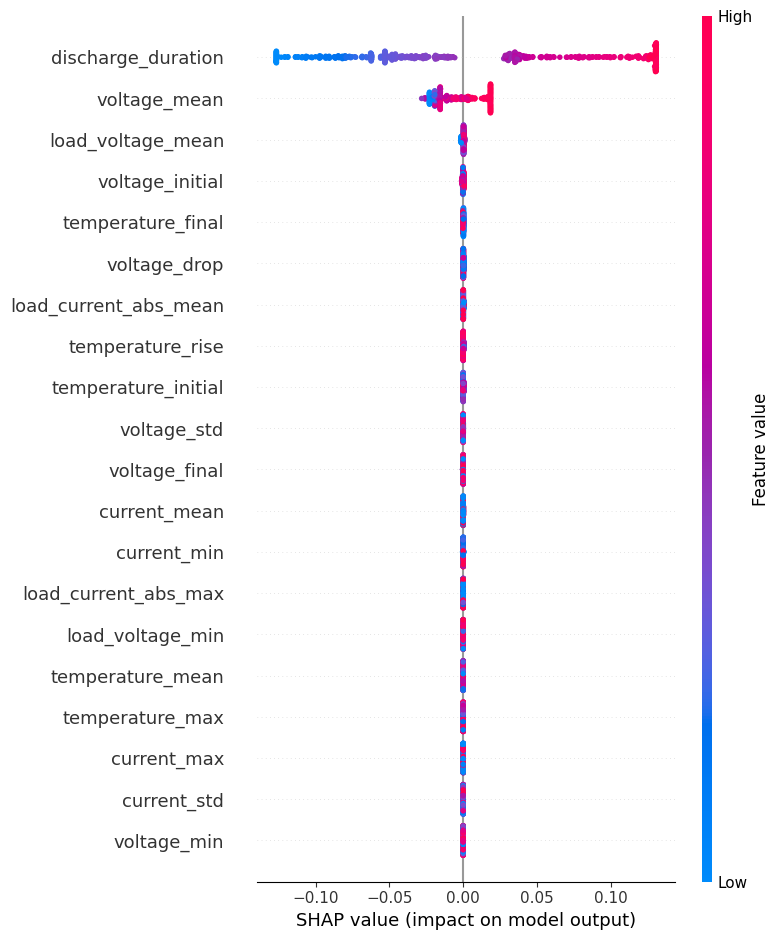

In [68]:
# ============================================================
# Cell 96: SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_columns
)

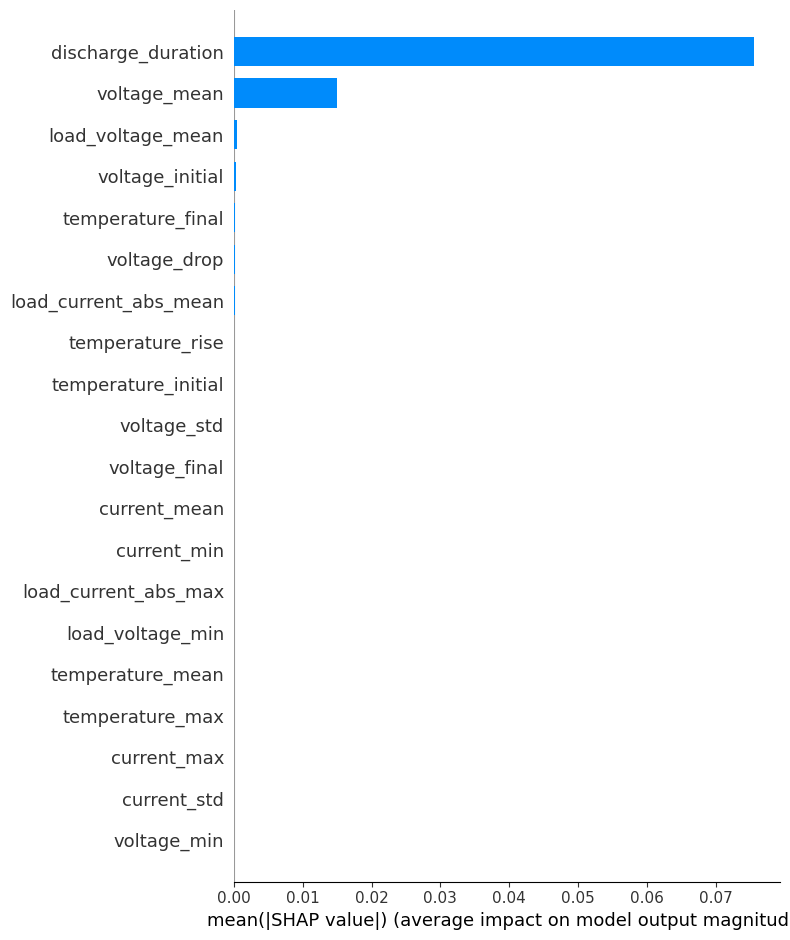

In [69]:
# ============================================================
# Cell 97: SHAP Global Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_columns,
    plot_type="bar"
)

## 37. Comparing Training and Difficult Test Battery

Battery B0006 produced substantially higher prediction error than
B0007 and B0018.

We therefore compare the engineered feature distributions of the
training battery B0005 and test battery B0006.

This helps identify whether B0006 contains operating conditions
or feature values that are substantially different from the
training data.

In [70]:
# ============================================================
# Cell 99: Compare B0005 and B0006 Feature Ranges
# ============================================================

comparison_features = feature_columns

comparison = pd.DataFrame({
    "B0005_mean": train_data[comparison_features].mean(),
    "B0005_min": train_data[comparison_features].min(),
    "B0005_max": train_data[comparison_features].max(),
    "B0006_mean": test_data[
        test_data["battery_id"] == "B0006"
    ][comparison_features].mean(),
    "B0006_min": test_data[
        test_data["battery_id"] == "B0006"
    ][comparison_features].min(),
    "B0006_max": test_data[
        test_data["battery_id"] == "B0006"
    ][comparison_features].max()
})

display(comparison)

,B0005_mean,B0005_min,B0005_max,B0006_mean,B0006_min,B0006_max
voltage_initial,3.989834,3.959137,4.018830,3.951789,3.900683,3.992592
voltage_final,2.648939,2.455679,2.699983,2.415779,2.120698,2.499908
voltage_min,2.648939,2.455679,2.699983,2.415779,2.120698,2.499908
voltage_max,3.989834,3.959137,4.018830,3.951789,3.900683,3.992592
voltage_mean,3.522741,3.455527,3.575355,3.454598,3.344863,3.567130
voltage_std,0.225623,0.203613,0.242866,0.238541,0.212953,0.258921
voltage_drop,1.340896,1.270101,1.532420,1.536010,1.404677,1.850680
current_mean,-2.012546,-2.013171,-2.012039,-2.010354,-2.011348,-2.009645
current_min,-2.017870,-2.029098,-2.015645,-2.015492,-2.027018,-2.013218
current_max,-2.007267,-2.009389,-1.995411,-2.005484,-2.007800,-1.995813


In [71]:
# ============================================================
# Cell 100: Detect Feature Distribution Shift
# ============================================================

b0006_data = test_data[
    test_data["battery_id"] == "B0006"
]

distribution_shift = []

for feature in feature_columns:

    train_min = X_train[feature].min()
    train_max = X_train[feature].max()

    test_min = b0006_data[feature].min()
    test_max = b0006_data[feature].max()

    outside_count = (
        (b0006_data[feature] < train_min) |
        (b0006_data[feature] > train_max)
    ).sum()

    distribution_shift.append({
        "Feature": feature,
        "Train_Min": train_min,
        "Train_Max": train_max,
        "B0006_Min": test_min,
        "B0006_Max": test_max,
        "Outside_Training_Range": outside_count
    })

distribution_shift_df = pd.DataFrame(
    distribution_shift
)

display(
    distribution_shift_df.sort_values(
        "Outside_Training_Range",
        ascending=False
    )
)

,Feature,Train_Min,Train_Max,B0006_Min,B0006_Max,Outside_Training_Range
7,current_mean,-2.013171,-2.012039,-2.011348,-2.009645,168
16,load_current_abs_mean,1.998027,1.998305,1.998830,1.999185,168
17,load_current_abs_max,1.998000,1.998400,1.998800,1.999200,168
19,load_voltage_min,1.684000,1.862000,1.371000,1.723000,164
8,current_min,-2.029098,-2.015645,-2.027018,-2.013218,130
1,voltage_final,2.455679,2.699983,2.120698,2.499908,117
2,voltage_min,2.455679,2.699983,2.120698,2.499908,117
0,voltage_initial,3.959137,4.018830,3.900683,3.992592,98
3,voltage_max,3.959137,4.018830,3.900683,3.992592,98
4,voltage_mean,3.455527,3.575355,3.344863,3.567130,95


## 38. Baseline Model Record

The initial XGBoost model is now treated as Baseline V1.

Its performance will remain unchanged throughout the remaining
experiments and will be used as the reference point for measuring
improvements from hyperparameter optimization and feature
engineering.

In [72]:
# ============================================================
# Cell 102: Save Baseline Results
# ============================================================

baseline_results = pd.DataFrame({
    "Model": ["XGBoost Baseline"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse],
    "R2": [r2]
})

display(baseline_results)

,Model,MAE,MSE,RMSE,R2
0,XGBoost Baseline,0.031389,0.001781,0.042204,0.855063


## 39. XGBoost Hyperparameter Optimization

The baseline model used a fixed set of hyperparameters.

We now perform systematic hyperparameter optimization using
cross-validation within the training battery B0005.

The held-out batteries B0006, B0007 and B0018 are not used during
hyperparameter selection.

The optimization objective is to minimize Mean Absolute Error
(MAE), which is also one of the primary metrics used in the
reference study.

In [76]:
# ============================================================
# Cell 104: XGBoost Grid Search
# ============================================================

from sklearn.model_selection import GridSearchCV, KFold

xgb_for_tuning = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation MAE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}

Best cross-validation MAE:
0.0032503821295126302


## 40. Evaluating the Optimized XGBoost Model

The best hyperparameter configuration identified using
cross-validation on B0005 is now evaluated on the three completely
unseen batteries.

This provides a fair comparison between the baseline XGBoost model
and the optimized XGBoost model.

In [77]:
# ============================================================
# Cell 106: Evaluate Optimized Model
# ============================================================

xgb_optimized = grid_search.best_estimator_

optimized_pred = xgb_optimized.predict(X_test)

optimized_mae = mean_absolute_error(
    y_test,
    optimized_pred
)

optimized_mse = mean_squared_error(
    y_test,
    optimized_pred
)

optimized_rmse = np.sqrt(optimized_mse)

optimized_r2 = r2_score(
    y_test,
    optimized_pred
)

print("Optimized XGBoost Performance")
print("--------------------------------")
print(f"MAE  : {optimized_mae:.6f}")
print(f"MSE  : {optimized_mse:.6f}")
print(f"RMSE : {optimized_rmse:.6f}")
print(f"R²   : {optimized_r2:.6f}")

Optimized XGBoost Performance
--------------------------------
MAE  : 0.034176
MSE  : 0.001883
RMSE : 0.043395
R²   : 0.846768


In [78]:
# ============================================================
# Cell 107: Baseline vs Optimized Comparison
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "XGBoost Baseline",
        "XGBoost Optimized"
    ],
    "MAE": [
        mae,
        optimized_mae
    ],
    "MSE": [
        mse,
        optimized_mse
    ],
    "RMSE": [
        rmse,
        optimized_rmse
    ],
    "R2": [
        r2,
        optimized_r2
    ]
})

display(model_comparison)

,Model,MAE,MSE,RMSE,R2
0,XGBoost Baseline,0.031389,0.001781,0.042204,0.855063
1,XGBoost Optimized,0.034176,0.001883,0.043395,0.846768


In [81]:
print("X_test shape:", X_test.shape)
print("X_test columns:")
print(X_test.columns.tolist())

print("\nX_test index sample:")
print(X_test.index[:10])

X_test shape: (468, 21)
X_test columns:
['voltage_initial', 'voltage_final', 'voltage_min', 'voltage_max', 'voltage_mean', 'voltage_std', 'voltage_drop', 'current_mean', 'current_min', 'current_max', 'current_std', 'temperature_initial', 'temperature_final', 'temperature_max', 'temperature_mean', 'temperature_rise', 'load_current_abs_mean', 'load_current_abs_max', 'load_voltage_mean', 'load_voltage_min', 'discharge_duration']

X_test index sample:
Index([168, 169, 170, 171, 172, 173, 174, 175, 176, 177], dtype='int64')


In [83]:
print("Available dataframe columns containing battery information:")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "battery_id" in obj.columns:
            print(f"{name}: {obj.shape}")

Available dataframe columns containing battery information:
sample_df: (7565, 10)
metadata: (7565, 10)
discharge_data: (2794, 11)
battery_data: (132, 11)
invalid_capacity: (25, 11)
zero_capacity: (19, 11)
capacity_check: (2794, 5)
clean_discharge: (2750, 11)
baseline_data: (636, 13)
battery_subset: (132, 13)
ml_dataset: (636, 26)
negative_load: (93, 26)
train_data: (168, 26)
test_data: (468, 26)
test_results: (468, 4)
battery_results: (132, 4)
battery_metrics_df: (3, 5)
b0006_data: (168, 26)


In [84]:
# Per-battery evaluation of the optimized XGBoost model

optimized_test_results = pd.DataFrame({
    "battery_id": test_data.loc[X_test.index, "battery_id"].values,
    "Actual_SOH": y_test.values,
    "Predicted_SOH": optimized_pred
}, index=X_test.index)

battery_metrics_optimized = []

for battery in optimized_test_results["battery_id"].unique():

    battery_data = optimized_test_results[
        optimized_test_results["battery_id"] == battery
    ]

    actual = battery_data["Actual_SOH"]
    predicted = battery_data["Predicted_SOH"]

    battery_mae = mean_absolute_error(actual, predicted)
    battery_mse = mean_squared_error(actual, predicted)
    battery_rmse = np.sqrt(battery_mse)
    battery_r2 = r2_score(actual, predicted)

    battery_metrics_optimized.append({
        "Battery": battery,
        "MAE": battery_mae,
        "MSE": battery_mse,
        "RMSE": battery_rmse,
        "R2": battery_r2
    })

optimized_battery_results = pd.DataFrame(battery_metrics_optimized)

display(optimized_battery_results)

,Battery,MAE,MSE,RMSE,R2
0,B0006,0.063037,0.004457,0.066761,0.707598
1,B0007,0.023981,0.000674,0.025967,0.906357
2,B0018,0.010421,0.000146,0.012074,0.978929


In [85]:
# ============================================================
# PHASE 1: FREEZE PAPER-COMPARABLE EXPERIMENT
# ============================================================

paper_baseline_metrics = pd.DataFrame({
    "Battery": ["B0006", "B0007", "B0018"],
    "MAE": [0.063250, 0.019573, 0.005879],
    "MSE": [0.004440, 0.000471, 0.000065],
    "RMSE": [0.066632, 0.021696, 0.008087],
    "R2": [0.708728, 0.934633, 0.990548]
})

paper_reference_metrics = pd.DataFrame({
    "Battery": ["B0006", "B0007", "B0018"],
    "MAE": [0.070787, 0.023080, 0.016356],
    "MSE": [0.006306, 0.000773, 0.000347]
})

print("Paper-comparable baseline:")
display(paper_baseline_metrics)

print("\nResearch paper reference:")
display(paper_reference_metrics)

Paper-comparable baseline:


,Battery,MAE,MSE,RMSE,R2
0,B0006,0.063250,0.004440,0.066632,0.708728
1,B0007,0.019573,0.000471,0.021696,0.934633
2,B0018,0.005879,0.000065,0.008087,0.990548



Research paper reference:


,Battery,MAE,MSE
0,B0006,0.070787,0.006306
1,B0007,0.023080,0.000773
2,B0018,0.016356,0.000347


In [86]:
# ============================================================
# OUR BASELINE vs RESEARCH PAPER
# ============================================================

paper_comparison = paper_reference_metrics.merge(
    paper_baseline_metrics,
    on="Battery",
    suffixes=("_Paper", "_Our")
)

paper_comparison["MAE_Improvement_%"] = (
    (paper_comparison["MAE_Paper"] - paper_comparison["MAE_Our"])
    / paper_comparison["MAE_Paper"]
) * 100

paper_comparison["MSE_Improvement_%"] = (
    (paper_comparison["MSE_Paper"] - paper_comparison["MSE_Our"])
    / paper_comparison["MSE_Paper"]
) * 100

display(paper_comparison)

,Battery,MAE_Paper,MSE_Paper,MAE_Our,MSE_Our,RMSE,R2,MAE_Improvement_%,MSE_Improvement_%
0,B0006,0.070787,0.006306,0.063250,0.004440,0.066632,0.708728,10.647435,29.590866
1,B0007,0.023080,0.000773,0.019573,0.000471,0.021696,0.934633,15.194974,39.068564
2,B0018,0.016356,0.000347,0.005879,0.000065,0.008087,0.990548,64.056004,81.268012


In [88]:
# ============================================================
# PHASE 2A: CLEAN + INSPECT GENERALIZED DATASET
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create a fresh generalized dataset
# ------------------------------------------------------------

generalized_data = clean_discharge.copy()

print("=" * 65)
print("1. GENERALIZED DATASET")
print("=" * 65)

print("Original shape:", generalized_data.shape)

# Convert Capacity from string/object to numeric
generalized_data["Capacity"] = pd.to_numeric(
    generalized_data["Capacity"],
    errors="coerce"
)

# Remove invalid capacity values
generalized_data = generalized_data[
    generalized_data["Capacity"].notna()
].copy()

# Remove zero/negative capacity values
generalized_data = generalized_data[
    generalized_data["Capacity"] > 0
].copy()

print("Shape after numeric capacity cleaning:", generalized_data.shape)
print(
    "Number of unique batteries:",
    generalized_data["battery_id"].nunique()
)


# ------------------------------------------------------------
# 2. Capacity summary for every battery
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("2. CAPACITY AVAILABILITY PER BATTERY")
print("=" * 65)

battery_summary = (
    generalized_data
    .groupby("battery_id")
    .agg(
        cycles=("battery_id", "size"),
        min_capacity=("Capacity", "min"),
        max_capacity=("Capacity", "max"),
        mean_capacity=("Capacity", "mean")
    )
    .sort_values("cycles", ascending=False)
)

display(battery_summary)


# ------------------------------------------------------------
# 3. Check available columns
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("3. AVAILABLE COLUMNS")
print("=" * 65)

print("\nclean_discharge:")
print(clean_discharge.columns.tolist())

print("\ngeneralized_data:")
print(generalized_data.columns.tolist())

print("\nml_dataset:")
print(ml_dataset.columns.tolist())


# ------------------------------------------------------------
# 4. Check data types
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("4. IMPORTANT DATA TYPES")
print("=" * 65)

print(
    generalized_data[
        ["battery_id", "Capacity"]
    ].dtypes
)


# ------------------------------------------------------------
# 5. Final sanity checks
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("5. SANITY CHECK")
print("=" * 65)

print("Final generalized dataset shape:", generalized_data.shape)
print("Missing Capacity values:", generalized_data["Capacity"].isna().sum())
print("Non-positive Capacity values:", (generalized_data["Capacity"] <= 0).sum())
print("Unique batteries:", generalized_data["battery_id"].nunique())

print("\nCapacity statistics:")
display(generalized_data["Capacity"].describe())

print("\nInspection complete.")

1. GENERALIZED DATASET
Original shape: (2750, 11)
Shape after numeric capacity cleaning: (2750, 11)
Number of unique batteries: 34

2. CAPACITY AVAILABILITY PER BATTERY


,cycles,min_capacity,max_capacity,mean_capacity
battery_id,,,,
B0036,197,1.001983,2.444062,1.699463
B0033,197,0.068426,1.885140,1.409510
B0034,197,0.745930,1.820306,1.386119
B0005,168,1.287453,1.856487,1.572502
B0006,168,1.153818,2.035338,1.546851
B0007,168,1.400455,1.891052,1.644421
B0018,132,1.341051,1.855005,1.557701
B0044,111,0.055117,1.686526,0.887594
B0043,111,0.056544,1.713783,0.915956



3. AVAILABLE COLUMNS

clean_discharge:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'Capacity_numeric']

generalized_data:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'Capacity_numeric']

ml_dataset:
['voltage_initial', 'voltage_final', 'voltage_min', 'voltage_max', 'voltage_mean', 'voltage_std', 'voltage_drop', 'current_mean', 'current_min', 'current_max', 'current_std', 'temperature_initial', 'temperature_final', 'temperature_max', 'temperature_mean', 'temperature_rise', 'load_voltage_mean', 'load_voltage_min', 'discharge_duration', 'battery_id', 'test_id', 'filename', 'Capacity', 'SOH', 'load_current_abs_mean', 'load_current_abs_max']

4. IMPORTANT DATA TYPES
battery_id     object
Capacity      float64
dtype: object

5. SANITY CHECK
Final generalized dataset shape: (2750, 11)
Missing Capacity values: 0
Non-positive Capacity values: 0
Unique ba

count    2750.000000
mean        1.335708
std         0.461052
min         0.032558
25%         1.156433
50%         1.430577
75%         1.674432
max         2.640149
Name: Capacity, dtype: float64


Inspection complete.


# Phase 2: Generalized Multi-Battery Battery AI Model

The paper-comparable experiment used a strict battery-level protocol:

- B0005 was used for training.
- B0006, B0007 and B0018 were used as held-out test batteries.

That experiment is now frozen and will be retained as the research benchmark.

The next experiment is the generalized DriveGuard-X Battery AI model.

## Objective

The objective is to train a model using multiple batteries so that it can learn battery-health relationships across different degradation profiles rather than learning primarily from one battery.

The generalized dataset contains 2,750 valid discharge experiments from 34 batteries after removing invalid and non-positive capacity records.

For every discharge experiment we will extract cycle-level electrical and thermal characteristics from:

- Measured voltage
- Measured current
- Temperature
- Load current
- Load voltage
- Time

The feature set will remain consistent with the baseline experiment:

1. voltage_initial
2. voltage_final
3. voltage_min
4. voltage_max
5. voltage_mean
6. voltage_std
7. voltage_drop
8. current_mean
9. current_min
10. current_max
11. current_std
12. temperature_initial
13. temperature_final
14. temperature_max
15. temperature_mean
16. temperature_rise
17. load_current_abs_mean
18. load_current_abs_max
19. load_voltage_mean
20. load_voltage_min
21. discharge_duration

The target variable is State of Health (SOH).

SOH is calculated independently for each battery:

SOH = C_i / C_0

where:

- C_i = measured discharge capacity of the current cycle
- C_0 = initial valid discharge capacity of that battery

This normalization is important because different battery groups can have different nominal capacity ranges.

## Important experimental rule

The train, validation and test sets will be separated by battery ID rather than by individual rows.

This prevents cycles belonging to the same physical battery from appearing in both training and testing.

The final test batteries will remain completely unseen during model development.

## Generalized pipeline

Raw discharge CSV
        ↓
Cycle-level feature extraction
        ↓
Capacity cleaning
        ↓
Battery-specific SOH calculation
        ↓
Battery-level train/validation/test split
        ↓
Model training
        ↓
Unseen-battery evaluation

The generalized model will later be compared against:

- The paper-comparable baseline XGBoost
- Random Forest
- SVM
- Ablation models
- The final selected DriveGuard-X model

The final objective is not simply to obtain the lowest training or cross-validation error. The important criterion is reliable generalization to batteries that the model has never seen.

In [89]:
# ============================================================
# PHASE 2: BUILD GENERALIZED BATTERY ML DATASET
# ============================================================
#
# This cell:
# 1. Cleans capacity values
# 2. Resolves raw discharge CSV files
# 3. Extracts cycle-level V/I/T/load/time features
# 4. Calculates battery-specific SOH
# 5. Creates generalized_ml_dataset
# 6. Performs sanity checks
#
# This is a separate experiment from the frozen B0005 baseline.
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 2: BUILDING GENERALIZED BATTERY DATASET")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1: CLEAN CAPACITY DATA
# ------------------------------------------------------------

generalized_metadata = clean_discharge.copy()

generalized_metadata["Capacity"] = pd.to_numeric(
    generalized_metadata["Capacity"],
    errors="coerce"
)

generalized_metadata = generalized_metadata[
    generalized_metadata["Capacity"].notna()
].copy()

generalized_metadata = generalized_metadata[
    generalized_metadata["Capacity"] > 0
].copy()

generalized_metadata = generalized_metadata.reset_index(drop=True)

print("\nSTEP 1: Capacity cleaning")
print("-" * 70)
print("Valid discharge experiments:", len(generalized_metadata))
print("Unique batteries:", generalized_metadata["battery_id"].nunique())


# ------------------------------------------------------------
# STEP 2: CALCULATE BATTERY-SPECIFIC SOH
# ------------------------------------------------------------

# Sort by battery and test number so that the earliest valid
# discharge capacity becomes C0 for each battery.

generalized_metadata["test_id_numeric"] = pd.to_numeric(
    generalized_metadata["test_id"],
    errors="coerce"
)

generalized_metadata = generalized_metadata.sort_values(
    ["battery_id", "test_id_numeric", "test_id"]
).reset_index(drop=True)

initial_capacity = (
    generalized_metadata
    .groupby("battery_id")["Capacity"]
    .first()
    .rename("initial_capacity")
)

generalized_metadata = generalized_metadata.merge(
    initial_capacity,
    on="battery_id",
    how="left"
)

generalized_metadata["SOH"] = (
    generalized_metadata["Capacity"]
    / generalized_metadata["initial_capacity"]
)

print("\nSTEP 2: SOH calculation")
print("-" * 70)
print("SOH range:",
      round(generalized_metadata["SOH"].min(), 4),
      "to",
      round(generalized_metadata["SOH"].max(), 4))


# ------------------------------------------------------------
# STEP 3: RESOLVE RAW CSV FILES
# ------------------------------------------------------------

print("\nSTEP 3: Resolving raw CSV files")
print("-" * 70)

# Candidate locations used by Kaggle datasets.
candidate_roots = [
    "/kaggle/input",
    "/kaggle/input/nasa-battery-dataset",
    "/kaggle/input/nasa-battery-life-prediction-dataset-cleaning"
]

# Check whether filenames already point directly to existing files.
resolved_paths = {}

for filename in generalized_metadata["filename"].astype(str).unique():

    possible_paths = [
        filename,
        os.path.join("/kaggle/input", filename)
    ]

    found = None

    for path in possible_paths:
        if os.path.isfile(path):
            found = path
            break

    if found is not None:
        resolved_paths[filename] = found


# If direct paths did not work, build a filename index by scanning
# Kaggle input directories once.

if len(resolved_paths) < len(
    generalized_metadata["filename"].unique()
):

    print("Direct file resolution incomplete.")
    print("Building Kaggle CSV filename index...")

    csv_index = {}

    for root in candidate_roots:

        if not os.path.exists(root):
            continue

        for current_root, dirs, files in os.walk(root):

            # Ignore obvious temporary/system folders.
            dirs[:] = [
                d for d in dirs
                if not d.startswith(".")
            ]

            for file in files:

                if file.lower().endswith(".csv"):

                    full_path = os.path.join(
                        current_root,
                        file
                    )

                    # Keep first occurrence.
                    if file not in csv_index:
                        csv_index[file] = full_path

    for filename in generalized_metadata["filename"].astype(str).unique():

        if filename in resolved_paths:
            continue

        basename = os.path.basename(filename)

        if basename in csv_index:
            resolved_paths[filename] = csv_index[basename]


print(
    "Resolved files:",
    len(resolved_paths),
    "/",
    generalized_metadata["filename"].nunique()
)


# ------------------------------------------------------------
# STEP 4: FEATURE EXTRACTION FUNCTION
# ------------------------------------------------------------

def extract_discharge_features(filepath):

    """
    Extract cycle-level features from one raw discharge CSV.

    The same feature philosophy used in the baseline experiment
    is retained for the generalized model.
    """

    df = pd.read_csv(filepath)

    required_columns = [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Current_load",
        "Voltage_load",
        "Time"
    ]

    # Verify required columns.
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing columns: {missing_columns}"
        )

    # Convert measurements to numeric.
    for col in required_columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = df.dropna(
        subset=required_columns
    ).copy()

    if len(df) < 2:
        raise ValueError(
            "Insufficient valid measurements"
        )

    # --------------------------------------------------------
    # Active discharge region
    # --------------------------------------------------------
    #
    # Current_load may have either polarity depending on the
    # experiment. Therefore use magnitude rather than sign.
    #
    # A small threshold separates the actual load period from
    # the initial near-zero-current region.
    # --------------------------------------------------------

    load_current_abs = df["Current_load"].abs()

    active_mask = load_current_abs > 0.1

    active_df = df.loc[active_mask].copy()

    # If the threshold removes too much data, fall back to
    # measured current magnitude.
    if len(active_df) < 5:

        measured_current_abs = (
            df["Current_measured"].abs()
        )

        active_mask = measured_current_abs > 0.1

        active_df = df.loc[active_mask].copy()

    # Final fallback.
    if len(active_df) < 5:
        active_df = df.copy()

    # --------------------------------------------------------
    # Extract individual series
    # --------------------------------------------------------

    voltage = active_df["Voltage_measured"]
    current = active_df["Current_measured"]
    temperature = active_df["Temperature_measured"]
    load_current = active_df["Current_load"].abs()
    load_voltage = active_df["Voltage_load"]
    time = active_df["Time"]

    # --------------------------------------------------------
    # Time normalization
    # --------------------------------------------------------

    time_start = float(time.iloc[0])
    time_end = float(time.iloc[-1])

    duration = max(
        0.0,
        time_end - time_start
    )

    # --------------------------------------------------------
    # Feature dictionary
    # --------------------------------------------------------

    features = {

        "voltage_initial":
            float(voltage.iloc[0]),

        "voltage_final":
            float(voltage.iloc[-1]),

        "voltage_min":
            float(voltage.min()),

        "voltage_max":
            float(voltage.max()),

        "voltage_mean":
            float(voltage.mean()),

        "voltage_std":
            float(voltage.std()),

        "voltage_drop":
            float(voltage.iloc[0] - voltage.iloc[-1]),

        "current_mean":
            float(current.mean()),

        "current_min":
            float(current.min()),

        "current_max":
            float(current.max()),

        "current_std":
            float(current.std()),

        "temperature_initial":
            float(temperature.iloc[0]),

        "temperature_final":
            float(temperature.iloc[-1]),

        "temperature_max":
            float(temperature.max()),

        "temperature_mean":
            float(temperature.mean()),

        "temperature_rise":
            float(
                temperature.iloc[-1]
                - temperature.iloc[0]
            ),

        "load_current_abs_mean":
            float(load_current.mean()),

        "load_current_abs_max":
            float(load_current.max()),

        "load_voltage_mean":
            float(load_voltage.mean()),

        "load_voltage_min":
            float(load_voltage.min()),

        "discharge_duration":
            duration
    }

    return features


# ------------------------------------------------------------
# STEP 5: EXTRACT FEATURES FROM ALL DISCHARGE EXPERIMENTS
# ------------------------------------------------------------

print("\nSTEP 4: Extracting cycle-level features")
print("-" * 70)

feature_records = []
failed_records = []

total = len(generalized_metadata)

for i, row in generalized_metadata.iterrows():

    filename = str(row["filename"])

    filepath = resolved_paths.get(filename)

    if filepath is None:

        failed_records.append({
            "battery_id": row["battery_id"],
            "test_id": row["test_id"],
            "filename": filename,
            "reason": "Raw CSV file not found"
        })

        continue

    try:

        features = extract_discharge_features(
            filepath
        )

        record = {
            "battery_id": row["battery_id"],
            "test_id": row["test_id"],
            "filename": row["filename"],
            "Capacity": row["Capacity"],
            "initial_capacity": row["initial_capacity"],
            "SOH": row["SOH"]
        }

        record.update(features)

        feature_records.append(record)

    except Exception as e:

        failed_records.append({
            "battery_id": row["battery_id"],
            "test_id": row["test_id"],
            "filename": filename,
            "reason": str(e)
        })

    # Progress every 250 experiments.
    if (i + 1) % 250 == 0 or (i + 1) == total:

        print(
            f"Processed {i + 1}/{total} "
            f"| Successful: {len(feature_records)} "
            f"| Failed: {len(failed_records)}"
        )


# ------------------------------------------------------------
# STEP 6: CREATE FINAL GENERALIZED ML DATASET
# ------------------------------------------------------------

generalized_ml_dataset = pd.DataFrame(
    feature_records
)

failed_feature_extraction = pd.DataFrame(
    failed_records
)

# Feature order.
feature_columns = [
    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",
    "current_mean",
    "current_min",
    "current_max",
    "current_std",
    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",
    "load_current_abs_mean",
    "load_current_abs_max",
    "load_voltage_mean",
    "load_voltage_min",
    "discharge_duration"
]

# Keep only complete feature rows.
generalized_ml_dataset = generalized_ml_dataset.dropna(
    subset=feature_columns + ["SOH"]
).reset_index(drop=True)


# ------------------------------------------------------------
# STEP 7: SANITY CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZED ML DATASET CREATED")
print("=" * 70)

print(
    "Final shape:",
    generalized_ml_dataset.shape
)

print(
    "Unique batteries:",
    generalized_ml_dataset["battery_id"].nunique()
)

print(
    "Successful feature extraction:",
    len(generalized_ml_dataset)
)

print(
    "Failed feature extraction:",
    len(failed_feature_extraction)
)

print(
    "SOH range:",
    round(generalized_ml_dataset["SOH"].min(), 4),
    "to",
    round(generalized_ml_dataset["SOH"].max(), 4)
)

print("\nBattery-wise experiment counts:")

battery_counts_generalized = (
    generalized_ml_dataset
    .groupby("battery_id")
    .size()
    .sort_values(ascending=False)
)

display(
    battery_counts_generalized
    .to_frame("cycles")
)


print("\nSOH statistics by battery:")

battery_soh_summary = (
    generalized_ml_dataset
    .groupby("battery_id")
    .agg(
        cycles=("SOH", "size"),
        min_SOH=("SOH", "min"),
        max_SOH=("SOH", "max"),
        mean_SOH=("SOH", "mean")
    )
    .sort_values("cycles", ascending=False)
)

display(battery_soh_summary)


print("\nFeature dataset preview:")

display(
    generalized_ml_dataset[
        [
            "battery_id",
            "test_id",
            "Capacity",
            "SOH"
        ] + feature_columns
    ].head()
)


print("\n" + "=" * 70)
print("PHASE 2 DATASET BUILD COMPLETE")
print("=" * 70)

PHASE 2: BUILDING GENERALIZED BATTERY DATASET

STEP 1: Capacity cleaning
----------------------------------------------------------------------
Valid discharge experiments: 2750
Unique batteries: 34

STEP 2: SOH calculation
----------------------------------------------------------------------
SOH range: 0.0327 to 27.5502

STEP 3: Resolving raw CSV files
----------------------------------------------------------------------
Direct file resolution incomplete.
Building Kaggle CSV filename index...
Resolved files: 2750 / 2750

STEP 4: Extracting cycle-level features
----------------------------------------------------------------------
Processed 250/2750 | Successful: 250 | Failed: 0
Processed 500/2750 | Successful: 500 | Failed: 0
Processed 750/2750 | Successful: 750 | Failed: 0
Processed 1000/2750 | Successful: 1000 | Failed: 0
Processed 1250/2750 | Successful: 1250 | Failed: 0
Processed 1500/2750 | Successful: 1500 | Failed: 0
Processed 1750/2750 | Successful: 1750 | Failed: 0
Processe

,cycles
battery_id,
B0036,197
B0033,197
B0034,197
B0005,168
B0006,168
B0007,168
B0018,132
B0044,111
B0043,111



SOH statistics by battery:


,cycles,min_SOH,max_SOH,mean_SOH
battery_id,,,,
B0036,197,1.000000,2.439226,1.696100
B0033,197,1.000000,27.550168,20.599125
B0034,197,1.000000,2.440316,1.858242
B0005,168,0.693488,1.000000,0.847031
B0006,168,0.566893,1.000000,0.759997
B0007,168,0.740569,1.000000,0.869580
B0018,132,0.722937,1.000000,0.839729
B0044,111,0.032681,1.000000,0.526286
B0043,111,0.032994,1.000000,0.534464



Feature dataset preview:


,battery_id,test_id,Capacity,SOH,voltage_initial,voltage_final,voltage_min,voltage_max,voltage_mean,voltage_std,voltage_drop,current_mean,current_min,current_max,current_std,temperature_initial,temperature_final,temperature_max,temperature_mean,temperature_rise,load_current_abs_mean,load_current_abs_max,load_voltage_mean,load_voltage_min,discharge_duration
0,B0005,1,1.856487,1.000000,3.974871,2.612467,2.612467,3.974871,3.553734,0.213428,1.362404,-2.012621,-2.018015,-2.008709,0.001463,24.389085,38.904112,38.904112,32.285161,14.515027,1.998237,1.9984,2.638011,1.782,3311.234
1,B0005,3,1.846327,0.994527,3.979157,2.587209,2.587209,3.979157,3.560999,0.212552,1.391948,-2.012561,-2.016821,-2.008829,0.001481,24.738132,38.934590,38.934590,32.438327,14.196458,1.998231,1.9984,2.633028,1.766,3293.125
2,B0005,5,1.835349,0.988614,3.979995,2.651917,2.651917,3.979995,3.565476,0.207369,1.328078,-2.012474,-2.016574,-2.007352,0.001622,24.791450,38.743649,38.743649,32.363279,13.952199,1.998217,1.9984,2.632949,1.820,3273.656
3,B0005,7,1.835263,0.988567,3.981613,2.592948,2.592948,3.981613,3.565378,0.211632,1.388665,-2.012181,-2.015936,-2.008008,0.001530,24.697864,38.672511,38.672511,32.236975,13.974647,1.998208,1.9984,2.630705,1.772,3273.969
4,B0005,9,1.834646,0.988235,3.982253,2.547420,2.547420,3.982253,3.565019,0.214690,1.434834,-2.012707,-2.017426,-2.009143,0.001565,24.571624,38.558828,38.558828,32.099754,13.987204,1.998223,1.9984,2.630949,1.738,3272.032



PHASE 2 DATASET BUILD COMPLETE


# Phase 2B: Validate Battery-Specific SOH Calculation

Before training the generalized model, the SOH target must be validated.

The previous generalized dataset showed impossible SOH values above 1.0 for several batteries. This indicates that selecting the first valid capacity as the initial capacity is not reliable for every battery group in the cleaned NASA dataset.

The problem may arise because:

- The first available discharge record is not necessarily the true beginning-of-life measurement.
- Some battery groups contain unusual capacity measurements.
- Test IDs may not correspond directly to chronological battery aging.
- Some datasets contain experimental groups with different capacity behavior.

Therefore, we will inspect the capacity trajectory of every battery before defining C₀.

For each battery we will examine:

- Number of discharge cycles
- Minimum capacity
- Maximum capacity
- First recorded capacity
- Capacity at the earliest test ID
- Capacity at the highest-capacity region
- Capacity variation
- Current SOH range produced by the existing normalization

We will not train the generalized model until this validation is complete.

The paper-comparable B0005 → B0006/B0007/B0018 experiment remains unchanged.

In [90]:
# ============================================================
# PHASE 2B: VALIDATE AND DIAGNOSE SOH CALCULATION
# ============================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("PHASE 2B: SOH TARGET VALIDATION")
print("=" * 75)


# ------------------------------------------------------------
# STEP 1: Start from the cleaned generalized metadata
# ------------------------------------------------------------

soh_check = clean_discharge.copy()

soh_check["Capacity"] = pd.to_numeric(
    soh_check["Capacity"],
    errors="coerce"
)

soh_check = soh_check[
    soh_check["Capacity"].notna()
].copy()

soh_check = soh_check[
    soh_check["Capacity"] > 0
].copy()


# Convert test_id to numeric wherever possible.
soh_check["test_id_numeric"] = pd.to_numeric(
    soh_check["test_id"],
    errors="coerce"
)

# Sort by battery and test ID.
soh_check = soh_check.sort_values(
    ["battery_id", "test_id_numeric", "test_id"]
).reset_index(drop=True)


# ------------------------------------------------------------
# STEP 2: Calculate the current C0 method
# ------------------------------------------------------------

current_c0 = (
    soh_check
    .groupby("battery_id")["Capacity"]
    .first()
    .rename("current_C0")
)

soh_check = soh_check.merge(
    current_c0,
    on="battery_id",
    how="left"
)

soh_check["current_SOH"] = (
    soh_check["Capacity"]
    / soh_check["current_C0"]
)


# ------------------------------------------------------------
# STEP 3: Build battery-level diagnostic summary
# ------------------------------------------------------------

diagnostic_rows = []

for battery, group in soh_check.groupby("battery_id"):

    group = group.sort_values(
        ["test_id_numeric", "test_id"]
    )

    capacities = group["Capacity"]

    first_capacity = float(capacities.iloc[0])
    max_capacity = float(capacities.max())
    min_capacity = float(capacities.min())
    mean_capacity = float(capacities.mean())

    max_capacity_index = capacities.idxmax()

    max_capacity_test = group.loc[
        max_capacity_index,
        "test_id"
    ]

    first_test_id = group["test_id"].iloc[0]

    last_test_id = group["test_id"].iloc[-1]

    current_c0_value = float(
        group["current_C0"].iloc[0]
    )

    current_soh_min = float(
        group["current_SOH"].min()
    )

    current_soh_max = float(
        group["current_SOH"].max()
    )

    diagnostic_rows.append({

        "Battery": battery,

        "Cycles": len(group),

        "First_Test_ID": first_test_id,

        "Last_Test_ID": last_test_id,

        "First_Capacity": first_capacity,

        "Max_Capacity": max_capacity,

        "Min_Capacity": min_capacity,

        "Mean_Capacity": mean_capacity,

        "Max_Capacity_Test_ID": max_capacity_test,

        "Current_C0": current_c0_value,

        "Current_SOH_Min": current_soh_min,

        "Current_SOH_Max": current_soh_max,

        "C0_vs_Max_%":
            (current_c0_value / max_capacity) * 100
    })


soh_diagnostics = pd.DataFrame(
    diagnostic_rows
).sort_values(
    "Current_SOH_Max",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# STEP 4: Display the diagnostic table
# ------------------------------------------------------------

print("\nBattery-level SOH diagnostic:")
display(soh_diagnostics)


# ------------------------------------------------------------
# STEP 5: Identify suspicious batteries
# ------------------------------------------------------------

suspicious_batteries = soh_diagnostics[
    (soh_diagnostics["Current_SOH_Max"] > 1.05)
    |
    (soh_diagnostics["Current_SOH_Min"] < 0.0)
    |
    (soh_diagnostics["C0_vs_Max_%"] < 80)
].copy()


print("\n" + "=" * 75)
print("SUSPICIOUS BATTERIES")
print("=" * 75)

if len(suspicious_batteries) == 0:

    print("No suspicious batteries detected.")

else:

    print(
        "Number of suspicious batteries:",
        len(suspicious_batteries)
    )

    display(suspicious_batteries)


# ------------------------------------------------------------
# STEP 6: Print detailed capacity trajectories for
# suspicious batteries
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DETAILED CAPACITY TRAJECTORIES")
print("=" * 75)

for battery in suspicious_batteries["Battery"].tolist():

    group = soh_check[
        soh_check["battery_id"] == battery
    ].copy()

    group = group.sort_values(
        ["test_id_numeric", "test_id"]
    )

    print(f"\n{battery}")
    print("-" * 75)

    display(
        group[
            [
                "test_id",
                "Capacity",
                "current_C0",
                "current_SOH"
            ]
        ].head(15)
    )

    print("...")

    display(
        group[
            [
                "test_id",
                "Capacity",
                "current_C0",
                "current_SOH"
            ]
        ].tail(10)
    )


# ------------------------------------------------------------
# STEP 7: Compare first capacity with maximum capacity
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("C0 SELECTION CHECK")
print("=" * 75)

print(
    "Batteries where the first recorded capacity is "
    "substantially below the maximum capacity:"
)

display(
    soh_diagnostics[
        soh_diagnostics["C0_vs_Max_%"] < 90
    ][
        [
            "Battery",
            "Cycles",
            "First_Capacity",
            "Max_Capacity",
            "Current_C0",
            "C0_vs_Max_%",
            "Current_SOH_Max"
        ]
    ]
)


# ------------------------------------------------------------
# STEP 8: Overall sanity checks
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("OVERALL SOH SANITY CHECK")
print("=" * 75)

print(
    "Current SOH minimum:",
    round(soh_check["current_SOH"].min(), 6)
)

print(
    "Current SOH maximum:",
    round(soh_check["current_SOH"].max(), 6)
)

print(
    "Records with SOH > 1.0:",
    (soh_check["current_SOH"] > 1.0).sum()
)

print(
    "Records with SOH > 1.05:",
    (soh_check["current_SOH"] > 1.05).sum()
)

print(
    "Records with SOH <= 0:",
    (soh_check["current_SOH"] <= 0).sum()
)

print("\nSOH validation complete.")

PHASE 2B: SOH TARGET VALIDATION

Battery-level SOH diagnostic:


,Battery,Cycles,First_Test_ID,Last_Test_ID,First_Capacity,Max_Capacity,Min_Capacity,Mean_Capacity,Max_Capacity_Test_ID,Current_C0,Current_SOH_Min,Current_SOH_Max,C0_vs_Max_%
0,B0033,197,0,482,0.068426,1.885140,0.068426,1.409510,112,0.068426,1.000000,27.550168,3.629742
1,B0041,67,0,161,0.055620,1.215649,0.044092,0.385796,103,0.055620,0.792738,21.856240,4.575352
2,B0039,47,0,120,0.119038,1.771573,0.119038,1.378927,52,0.119038,1.000000,14.882372,6.719359
3,B0051,24,0,58,0.643474,2.330873,0.643474,0.920147,10,0.643474,1.000000,3.622330,27.606542
4,B0050,20,0,50,0.863145,2.640149,0.032558,0.991283,14,0.863145,0.037721,3.058756,32.693034
5,B0049,24,0,58,0.858373,2.378644,0.691389,0.960158,10,0.858373,0.805464,2.771108,36.086645
6,B0040,47,0,120,0.673463,1.734130,0.425812,1.418276,42,0.673463,0.632273,2.574945,38.835782
7,B0034,197,0,482,0.745930,1.820306,0.745930,1.386119,112,0.745930,1.000000,2.440316,40.978291
8,B0036,197,0,482,1.001983,2.444062,1.001983,1.699463,278,1.001983,1.000000,2.439226,40.996604
9,B0038,47,0,120,0.898057,1.786441,0.898057,1.573178,42,0.898057,1.000000,1.989228,50.270750



SUSPICIOUS BATTERIES
Number of suspicious batteries: 19


,Battery,Cycles,First_Test_ID,Last_Test_ID,First_Capacity,Max_Capacity,Min_Capacity,Mean_Capacity,Max_Capacity_Test_ID,Current_C0,Current_SOH_Min,Current_SOH_Max,C0_vs_Max_%
0,B0033,197,0,482,0.068426,1.885140,0.068426,1.409510,112,0.068426,1.000000,27.550168,3.629742
1,B0041,67,0,161,0.055620,1.215649,0.044092,0.385796,103,0.055620,0.792738,21.856240,4.575352
2,B0039,47,0,120,0.119038,1.771573,0.119038,1.378927,52,0.119038,1.000000,14.882372,6.719359
3,B0051,24,0,58,0.643474,2.330873,0.643474,0.920147,10,0.643474,1.000000,3.622330,27.606542
4,B0050,20,0,50,0.863145,2.640149,0.032558,0.991283,14,0.863145,0.037721,3.058756,32.693034
5,B0049,24,0,58,0.858373,2.378644,0.691389,0.960158,10,0.858373,0.805464,2.771108,36.086645
6,B0040,47,0,120,0.673463,1.734130,0.425812,1.418276,42,0.673463,0.632273,2.574945,38.835782
7,B0034,197,0,482,0.745930,1.820306,0.745930,1.386119,112,0.745930,1.000000,2.440316,40.978291
8,B0036,197,0,482,1.001983,2.444062,1.001983,1.699463,278,1.001983,1.000000,2.439226,40.996604
9,B0038,47,0,120,0.898057,1.786441,0.898057,1.573178,42,0.898057,1.000000,1.989228,50.270750



DETAILED CAPACITY TRAJECTORIES

B0033
---------------------------------------------------------------------------


...

...


,test_id,Capacity,current_C0,current_SOH
818,73,1.613839,1.656071,0.974499
819,75,1.596330,1.656071,0.963926
820,77,1.589079,1.656071,0.959548
821,79,1.580548,1.656071,0.954397
822,81,1.584613,1.656071,0.956851
823,85,1.593665,1.656071,0.962317
824,87,1.584987,1.656071,0.957077
825,89,1.578706,1.656071,0.953285
826,91,1.570706,1.656071,0.948453
827,93,1.562780,1.656071,0.943668



C0 SELECTION CHECK
Batteries where the first recorded capacity is substantially below the maximum capacity:


,Battery,Cycles,First_Capacity,Max_Capacity,Current_C0,C0_vs_Max_%,Current_SOH_Max
0,B0033,197,0.068426,1.885140,0.068426,3.629742,27.550168
1,B0041,67,0.055620,1.215649,0.055620,4.575352,21.856240
2,B0039,47,0.119038,1.771573,0.119038,6.719359,14.882372
3,B0051,24,0.643474,2.330873,0.643474,27.606542,3.622330
4,B0050,20,0.863145,2.640149,0.863145,32.693034,3.058756
5,B0049,24,0.858373,2.378644,0.858373,36.086645,2.771108
6,B0040,47,0.673463,1.734130,0.673463,38.835782,2.574945
7,B0034,197,0.745930,1.820306,0.745930,40.978291,2.440316
8,B0036,197,1.001983,2.444062,1.001983,40.996604,2.439226
9,B0038,47,0.898057,1.786441,0.898057,50.270750,1.989228



OVERALL SOH SANITY CHECK
Current SOH minimum: 0.032681
Current SOH maximum: 27.550168
Records with SOH > 1.0: 1242
Records with SOH > 1.05: 1146
Records with SOH <= 0: 0

SOH validation complete.


# Stage 1: Generalized SOH Reference-Capacity Investigation

The paper-comparable experiment uses the initial battery capacity as the reference capacity:

SOH = C_i / C_0

This definition works correctly for B0005, B0006, B0007 and B0018.

However, inspection of the complete NASA discharge collection shows that the first recorded capacity is not consistently a valid beginning-of-life reference for every battery group.

Several batteries contain an initial capacity that is dramatically lower than subsequent measurements. Using those values as C0 produces physically meaningless SOH values above 100%.

Examples include:

- B0033
- B0041
- B0039
- B0051
- B0050
- B0049
- B0040
- B0034
- B0036
- B0038
- B0056
- B0055
- B0052
- B0054

Therefore, the generalized model will not be trained until the capacity trajectories have been investigated.

The objective of this stage is to identify a defensible reference-capacity rule while keeping the paper-comparable experiment unchanged.

The original paper benchmark remains:

B0005 → training
B0006, B0007, B0018 → testing

This stage only concerns the separate generalized DriveGuard-X experiment.

STAGE 1: GENERALIZED SOH REFERENCE-CAPACITY INVESTIGATION

Battery reference-capacity analysis:


,battery_id,cycles,first_test_id,last_test_id,first_capacity,first_5_mean,max_capacity,min_capacity,mean_capacity,upper_10pct_median,first_vs_reference,max_vs_reference
0,B0033,197,0,482,0.068426,0.894988,1.885140,0.068426,1.409510,1.646780,0.041551,1.144743
1,B0041,67,0,161,0.055620,0.055955,1.215649,0.044092,0.385796,1.084133,0.051304,1.121311
2,B0039,47,0,120,0.119038,0.340947,1.771573,0.119038,1.378927,1.770625,0.067230,1.000535
3,B0040,47,0,120,0.673463,0.758753,1.734130,0.425812,1.418276,1.733483,0.388503,1.000373
4,B0050,20,0,50,0.863145,1.139577,2.640149,0.032558,0.991283,2.144469,0.402498,1.231143
5,B0034,197,0,482,0.745930,1.454162,1.820306,0.745930,1.386119,1.553599,0.480131,1.171671
6,B0051,24,0,58,0.643474,1.340065,2.330873,0.643474,0.920147,1.293180,0.497590,1.802435
7,B0038,47,0,120,0.898057,1.037058,1.786441,0.898057,1.573178,1.785945,0.502847,1.000278
8,B0036,197,0,482,1.001983,1.642164,2.444062,1.001983,1.699463,1.789200,0.560017,1.366009
9,B0049,24,0,58,0.858373,1.479030,2.378644,0.691389,0.960158,1.420906,0.604103,1.674033



BATTERIES WITH FIRST CAPACITY < 80% OF UPPER CAPACITY REGION
Count: 14


,battery_id,cycles,first_test_id,last_test_id,first_capacity,first_5_mean,max_capacity,min_capacity,mean_capacity,upper_10pct_median,first_vs_reference,max_vs_reference
0,B0033,197,0,482,0.068426,0.894988,1.885140,0.068426,1.409510,1.646780,0.041551,1.144743
1,B0041,67,0,161,0.055620,0.055955,1.215649,0.044092,0.385796,1.084133,0.051304,1.121311
2,B0039,47,0,120,0.119038,0.340947,1.771573,0.119038,1.378927,1.770625,0.067230,1.000535
3,B0040,47,0,120,0.673463,0.758753,1.734130,0.425812,1.418276,1.733483,0.388503,1.000373
4,B0050,20,0,50,0.863145,1.139577,2.640149,0.032558,0.991283,2.144469,0.402498,1.231143
5,B0034,197,0,482,0.745930,1.454162,1.820306,0.745930,1.386119,1.553599,0.480131,1.171671
6,B0051,24,0,58,0.643474,1.340065,2.330873,0.643474,0.920147,1.293180,0.497590,1.802435
7,B0038,47,0,120,0.898057,1.037058,1.786441,0.898057,1.573178,1.785945,0.502847,1.000278
8,B0036,197,0,482,1.001983,1.642164,2.444062,1.001983,1.699463,1.789200,0.560017,1.366009
9,B0049,24,0,58,0.858373,1.479030,2.378644,0.691389,0.960158,1.420906,0.604103,1.674033



Generating capacity trajectory plots...


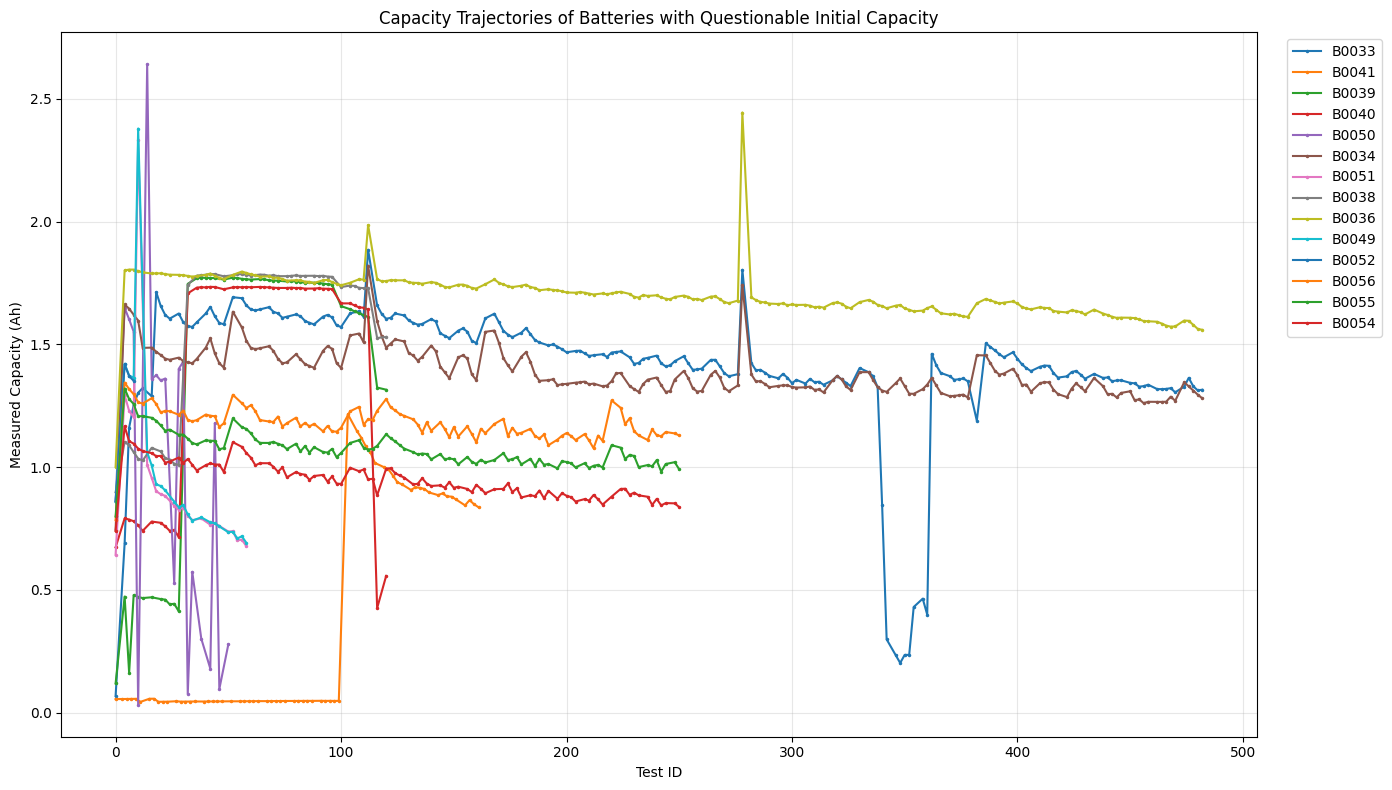


EARLY CAPACITY MEASUREMENTS

B0033
------------------------------------------------------------


,test_id,Capacity
908,0,0.068426
909,4,0.689570
910,6,1.161085
911,8,1.252939
912,10,1.302918
913,12,1.321877
914,16,1.288469
915,18,1.713169
916,20,1.656097
917,22,1.619730



B0041
------------------------------------------------------------


,test_id,Capacity
1640,0,0.055620
1641,3,0.055697
1642,5,0.055839
1643,7,0.056148
1644,9,0.056471
1645,11,0.044092
1646,15,0.056772
1647,17,0.056938
1648,19,0.044401
1649,21,0.044634



B0039
------------------------------------------------------------


...


B0054
------------------------------------------------------------


,test_id,Capacity
2444,0,0.739935
2445,4,1.166544
2446,6,1.105252
2447,8,1.096030
2448,10,1.075445
2449,12,1.065549
2450,16,1.056837
2451,18,1.044906
2452,20,1.045836
2453,22,1.018188



PAPER-COMPARABLE BATTERIES


,battery_id,cycles,first_test_id,last_test_id,first_capacity,first_5_mean,max_capacity,min_capacity,mean_capacity,upper_10pct_median,first_vs_reference,max_vs_reference
23,B0007,168,1,613,1.891052,1.882515,1.891052,1.400455,1.644421,1.880663,1.005524,1.005524
24,B0005,168,1,613,1.856487,1.841614,1.856487,1.287453,1.572502,1.835263,1.011565,1.011565
26,B0018,132,2,318,1.855005,1.840235,1.855005,1.341051,1.557701,1.822151,1.018030,1.018030
27,B0006,168,1,613,2.035338,2.017523,2.035338,1.153818,1.546851,1.968790,1.033801,1.033801



STAGE 1 COMPLETE
DO NOT TRAIN THE GENERALIZED MODEL YET.


In [91]:
# ============================================================
# STAGE 1: INVESTIGATE CAPACITY TRAJECTORIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("STAGE 1: GENERALIZED SOH REFERENCE-CAPACITY INVESTIGATION")
print("=" * 75)

# ------------------------------------------------------------
# 1. Prepare clean capacity data
# ------------------------------------------------------------

soh_investigation = clean_discharge.copy()

soh_investigation["Capacity"] = pd.to_numeric(
    soh_investigation["Capacity"],
    errors="coerce"
)

soh_investigation = soh_investigation[
    soh_investigation["Capacity"].notna()
].copy()

soh_investigation = soh_investigation[
    soh_investigation["Capacity"] > 0
].copy()

soh_investigation["test_id_numeric"] = pd.to_numeric(
    soh_investigation["test_id"],
    errors="coerce"
)

soh_investigation = soh_investigation.sort_values(
    ["battery_id", "test_id_numeric", "test_id"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 2. Calculate robust capacity statistics
# ------------------------------------------------------------

battery_reference_analysis = []

for battery, group in soh_investigation.groupby("battery_id"):

    group = group.sort_values(
        ["test_id_numeric", "test_id"]
    )

    capacity = group["Capacity"]

    # Early measurements
    first_n = min(5, len(group))
    first_five = capacity.iloc[:first_n]

    # Upper capacity region
    upper_quantile = capacity.quantile(0.90)

    high_capacity_values = capacity[
        capacity >= upper_quantile
    ]

    reference_median = high_capacity_values.median()

    # Median of the highest 10% of capacity observations.
    # This is used only for diagnosis here, not yet adopted
    # as the final SOH definition.
    reference_capacity = float(reference_median)

    first_capacity = float(capacity.iloc[0])
    max_capacity = float(capacity.max())
    min_capacity = float(capacity.min())

    battery_reference_analysis.append({

        "battery_id": battery,
        "cycles": len(group),
        "first_test_id": group["test_id"].iloc[0],
        "last_test_id": group["test_id"].iloc[-1],

        "first_capacity": first_capacity,
        "first_5_mean": first_five.mean(),

        "max_capacity": max_capacity,
        "min_capacity": min_capacity,
        "mean_capacity": capacity.mean(),

        "upper_10pct_median": reference_capacity,

        "first_vs_reference":
            first_capacity / reference_capacity,

        "max_vs_reference":
            max_capacity / reference_capacity
    })


reference_analysis = pd.DataFrame(
    battery_reference_analysis
).sort_values(
    "first_vs_reference"
).reset_index(drop=True)


print("\nBattery reference-capacity analysis:")
display(reference_analysis)


# ------------------------------------------------------------
# 3. Identify batteries with questionable first measurements
# ------------------------------------------------------------

questionable = reference_analysis[
    reference_analysis["first_vs_reference"] < 0.80
].copy()

print("\n" + "=" * 75)
print("BATTERIES WITH FIRST CAPACITY < 80% OF UPPER CAPACITY REGION")
print("=" * 75)

print(
    "Count:",
    len(questionable)
)

display(questionable)


# ------------------------------------------------------------
# 4. Plot capacity trajectories
# ------------------------------------------------------------

print("\nGenerating capacity trajectory plots...")

# Plot questionable batteries together.
plt.figure(figsize=(14, 8))

for battery in questionable["battery_id"]:

    group = soh_investigation[
        soh_investigation["battery_id"] == battery
    ].sort_values(
        ["test_id_numeric", "test_id"]
    )

    plt.plot(
        group["test_id_numeric"],
        group["Capacity"],
        marker=".",
        markersize=3,
        label=battery
    )

plt.xlabel("Test ID")
plt.ylabel("Measured Capacity (Ah)")
plt.title(
    "Capacity Trajectories of Batteries with Questionable Initial Capacity"
)

plt.grid(True, alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Print detailed trajectories for problematic batteries
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EARLY CAPACITY MEASUREMENTS")
print("=" * 75)

for battery in questionable["battery_id"]:

    group = soh_investigation[
        soh_investigation["battery_id"] == battery
    ].sort_values(
        ["test_id_numeric", "test_id"]
    )

    print(f"\n{battery}")
    print("-" * 60)

    display(
        group[
            [
                "test_id",
                "Capacity"
            ]
        ].head(12)
    )


# ------------------------------------------------------------
# 6. Compare the four paper batteries
# ------------------------------------------------------------

paper_batteries = [
    "B0005",
    "B0006",
    "B0007",
    "B0018"
]

paper_reference = reference_analysis[
    reference_analysis["battery_id"].isin(
        paper_batteries
    )
]

print("\n" + "=" * 75)
print("PAPER-COMPARABLE BATTERIES")
print("=" * 75)

display(paper_reference)


print("\n" + "=" * 75)
print("STAGE 1 COMPLETE")
print("=" * 75)
print(
    "DO NOT TRAIN THE GENERALIZED MODEL YET."
)

# Stage 2: Robust Initial Capacity Reference

The generalized NASA dataset contains several battery groups where the first
recorded capacity is not representative of the battery's normal operating
capacity.

Therefore, the generalized SOH target will use a robust battery-specific
reference capacity rather than blindly taking the first record.

The purpose of this stage is to identify a stable early-life capacity region.

For each battery we will:

1. Sort experiments by test ID.
2. Inspect the early capacity trajectory.
3. Remove clearly anomalous capacity observations using robust statistics.
4. Identify the early stable capacity region.
5. Estimate a robust reference capacity from that region.
6. Compare the resulting SOH values against the raw capacity trajectory.

The reference capacity must satisfy:

    SOH = Capacity / C0

with the resulting values being approximately within:

    0 < SOH <= 1

for normal aging trajectories.

We will not force values into the [0, 1] range using clipping because that
would hide incorrect labels.

An isolated capacity measurement that is substantially inconsistent with the
surrounding trajectory will be treated as an anomalous measurement rather
than being allowed to define C0.

The four paper-comparable batteries remain unchanged for the research-paper
benchmark. Their original first capacity will continue to define C0 so that
our comparison with the paper remains methodologically fair.

STAGE 2: ROBUST INITIAL CAPACITY REFERENCE INVESTIGATION

Clean capacity dataset shape:
(2750, 12)
Unique batteries: 34
Valid capacity measurements: 2750

REFERENCE CAPACITY COMPARISON


,battery_id,n_cycles,first_capacity,early_median,stable_early_count,robust_reference_C0,raw_max_capacity,diagnostic_min_SOH,diagnostic_max_SOH
0,B0005,168,1.856487,1.824697,34,1.824697,1.856487,0.705571,1.017422
1,B0006,168,2.035338,1.924511,34,1.924511,2.035338,0.599538,1.057587
2,B0007,168,1.891052,1.869868,34,1.869868,1.891052,0.748960,1.011330
3,B0018,132,1.855005,1.783471,27,1.783471,1.855005,0.751934,1.040109
4,B0025,28,1.847011,1.841623,10,1.841623,1.848984,0.959908,1.003997
5,B0026,28,1.813250,1.813393,9,1.813535,1.816528,0.764439,1.001650
6,B0027,28,1.823308,1.814331,9,1.814424,1.823308,0.975567,1.004896
7,B0028,28,1.804685,1.791983,10,1.791983,1.804783,0.958287,1.007143
8,B0029,40,1.697507,1.813816,9,1.814332,1.844701,0.888525,1.016739
9,B0030,40,1.656071,1.743637,10,1.743637,1.781555,0.896276,1.021747



CHANGE FROM FIRST CAPACITY


,battery_id,first_capacity,robust_reference_C0,reference_change_percent
0,B0045,1.081979,0.799378,-26.118949
1,B0046,1.728239,1.455685,-15.770610
2,B0047,1.674305,1.431118,-14.524625
3,B0048,1.657996,1.444393,-12.883190
4,B0041,0.055620,0.051165,-8.010803
5,B0044,1.686526,1.581631,-6.219558
6,B0043,1.713783,1.617976,-5.590351
7,B0006,2.035338,1.924511,-5.445116
8,B0018,1.855005,1.783471,-3.856260
9,B0042,1.728713,1.681298,-2.742784



SOH RANGE VALIDATION
SOH < 0:        0
SOH > 1.00:     468
SOH > 1.05:     202
0 <= SOH <= 1:  2282
Total:          2750
Valid ratio:    82.98%

REMAINING BATTERIES WITH SOH > 1.05


,battery_id,abnormal_count,max_SOH,mean_SOH
7,B0041,32,23.759573,14.790379
5,B0039,35,3.782136,3.656626
16,B0051,5,2.436710,1.477396
14,B0049,5,2.362125,1.508910
6,B0040,33,2.242458,2.219126
15,B0050,4,1.930669,1.360593
4,B0038,35,1.683218,1.655466
3,B0036,2,1.373613,1.244750
10,B0045,5,1.353527,1.149434
2,B0034,14,1.247060,1.106092



GENERATING SOH TRAJECTORY PLOTS


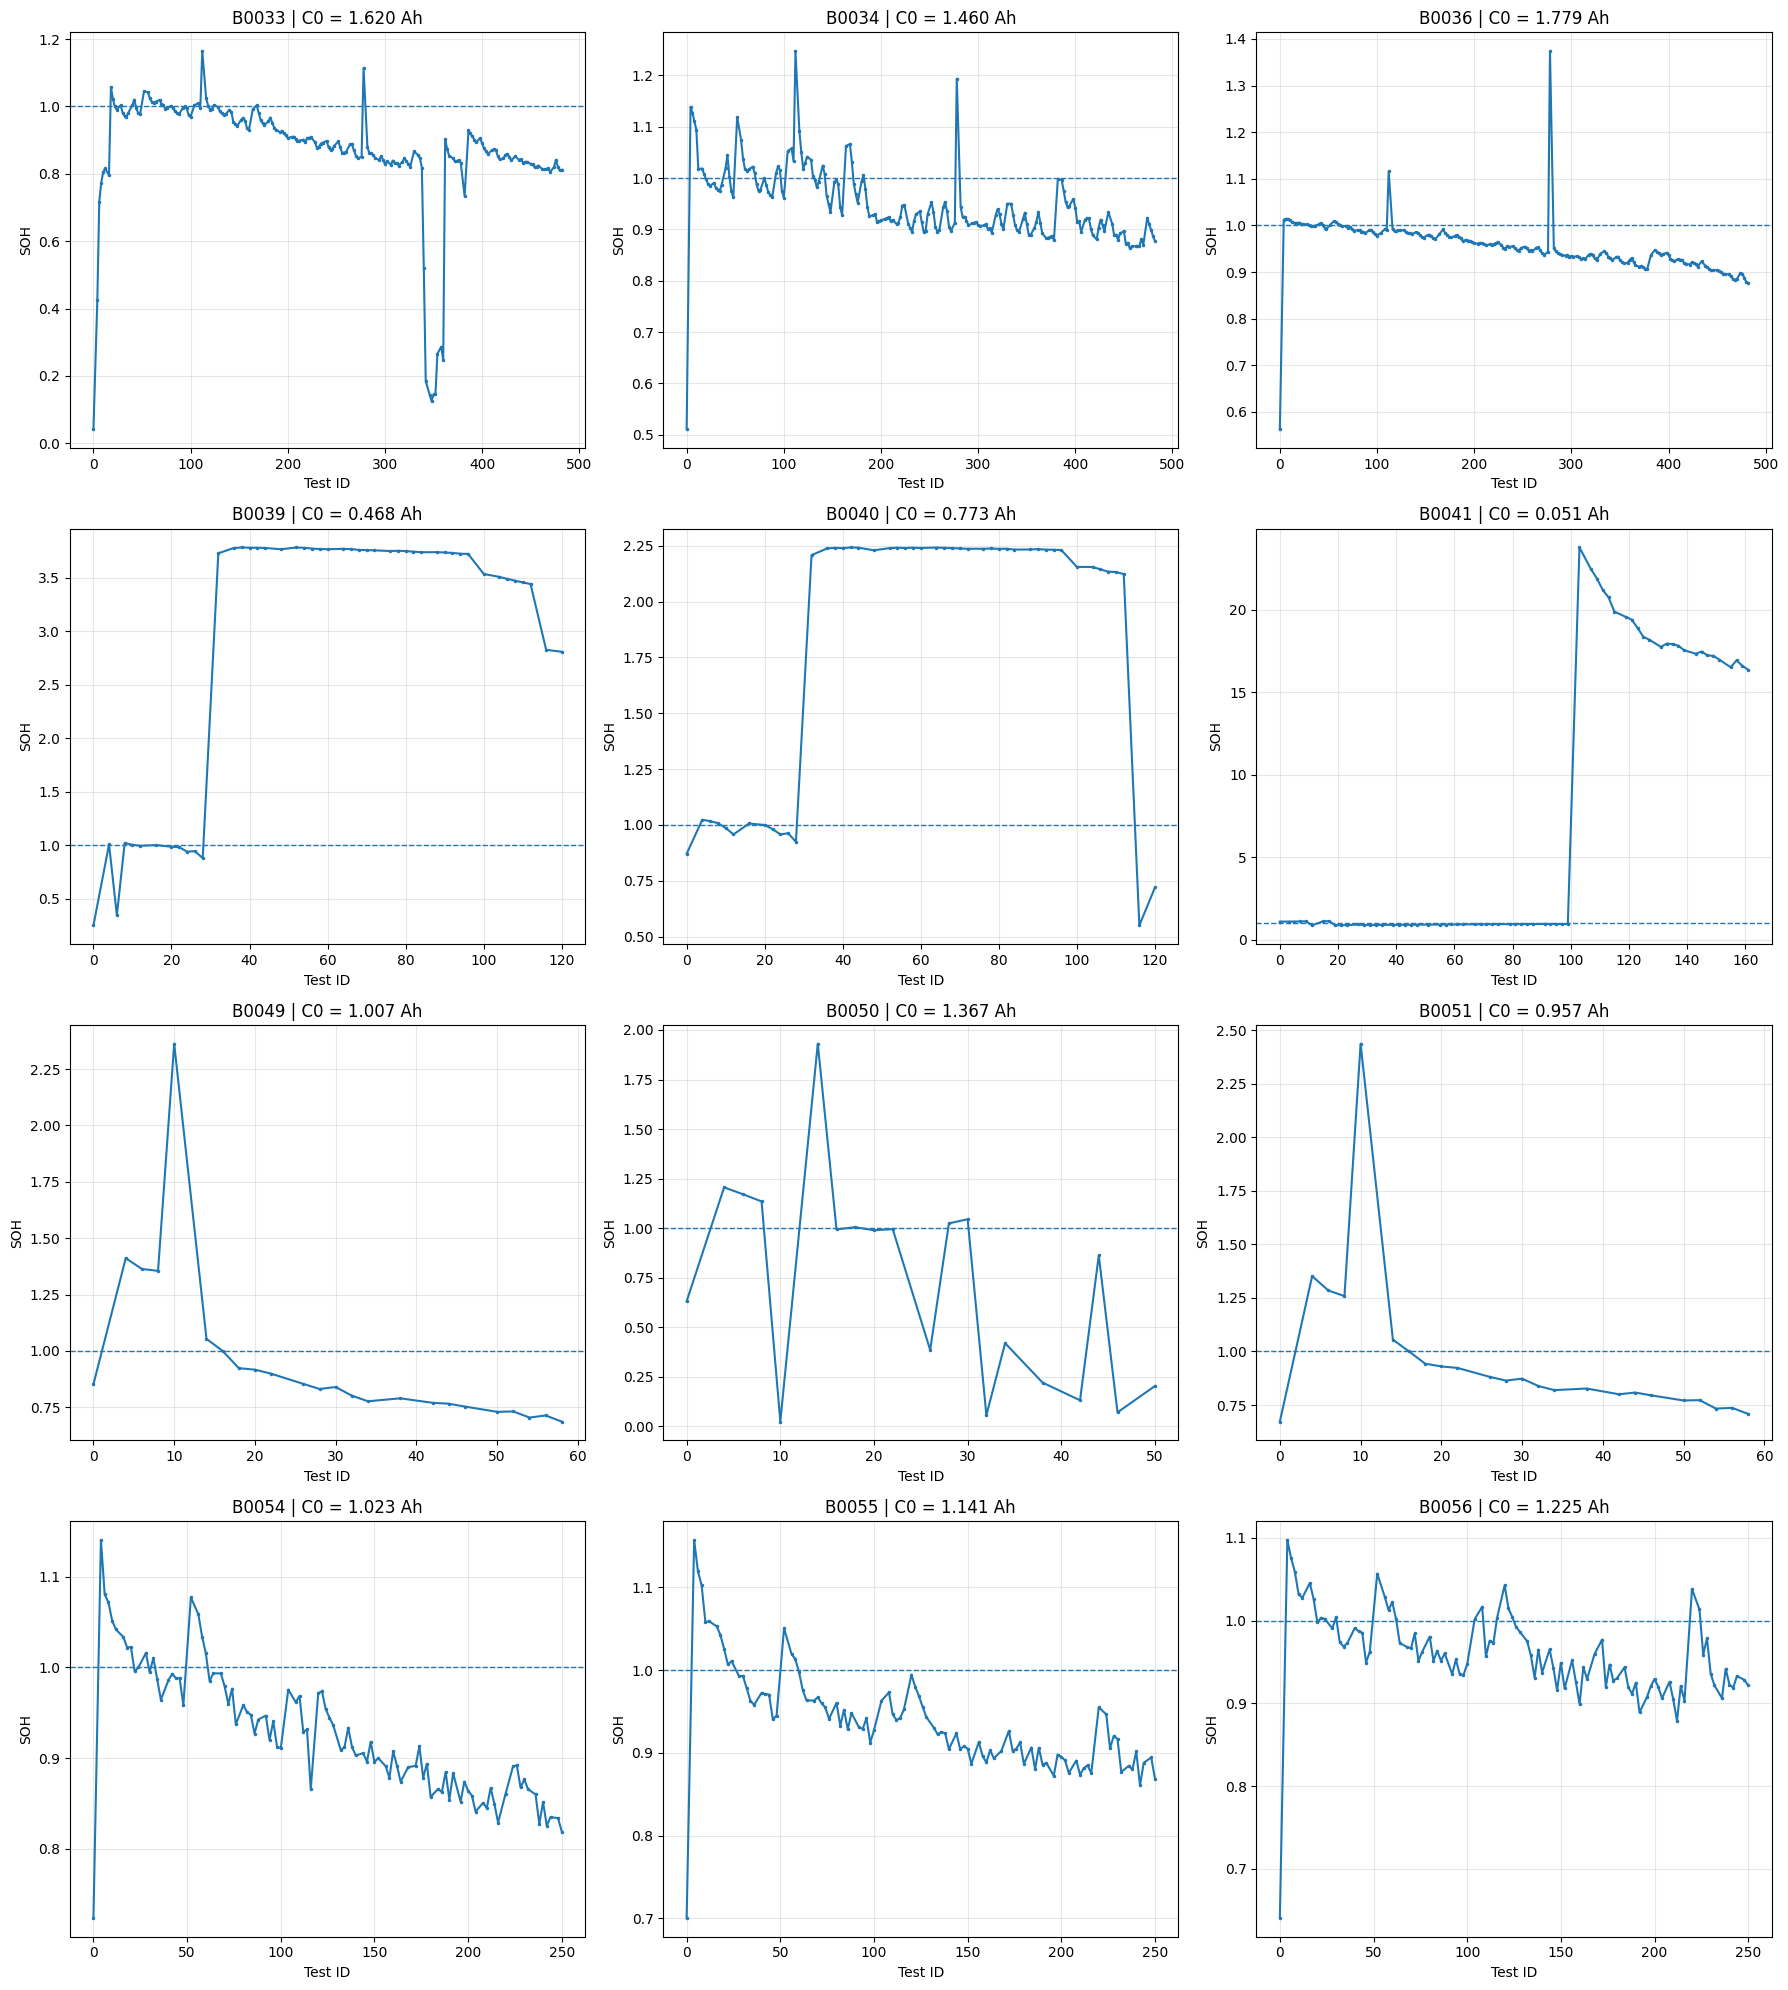


PAPER-COMPARABLE BATTERIES


,battery_id,first_capacity,early_median,robust_reference_C0,reference_change_percent
0,B0005,1.856487,1.824697,1.824697,-1.712412
1,B0006,2.035338,1.924511,1.924511,-5.445116
2,B0007,1.891052,1.869868,1.869868,-1.120264
3,B0018,1.855005,1.783471,1.783471,-3.856260



PAPER BATTERY C0 CONSISTENCY CHECK
B0005: first C0 = 1.856487 Ah | robust C0 = 1.824697 Ah | difference = -1.71%
B0006: first C0 = 2.035338 Ah | robust C0 = 1.924511 Ah | difference = -5.45%
B0007: first C0 = 1.891052 Ah | robust C0 = 1.869868 Ah | difference = -1.12%
B0018: first C0 = 1.855005 Ah | robust C0 = 1.783471 Ah | difference = -3.86%

INTERMEDIATE VARIABLES CREATED
reference_results
generalized_soh_diagnostic
reference_map
capacity_cleaned_groups

STAGE 2 COMPLETE

The robust reference capacity has been calculated for
investigation.

IMPORTANT:
The generalized SOH definition has NOT yet been permanently
frozen.

Before moving to model training, inspect:

1. The reference capacity table.
2. The percentage change from first capacity.
3. The number of SOH values above 1.05.
4. The SOH trajectory plots.
5. The paper-battery consistency check.

If the trajectories are physically and statistically sensible,
we will freeze the generalized SOH definition and proceed to:

    STAGE 

In [93]:
# ============================================================
# STAGE 2: ROBUST INITIAL CAPACITY REFERENCE INVESTIGATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("STAGE 2: ROBUST INITIAL CAPACITY REFERENCE INVESTIGATION")
print("=" * 80)


# ============================================================
# 1. PREPARE CAPACITY DATA
# ============================================================

capacity_df = clean_discharge.copy()

# Convert Capacity to numeric.
# Invalid values such as "[]" become NaN.
capacity_df["Capacity"] = pd.to_numeric(
    capacity_df["Capacity"],
    errors="coerce"
)

# Convert test ID to numeric for proper chronological ordering.
capacity_df["test_id_numeric"] = pd.to_numeric(
    capacity_df["test_id"],
    errors="coerce"
)

# Keep only valid positive capacity measurements.
capacity_df = capacity_df[
    capacity_df["Capacity"].notna()
].copy()

capacity_df = capacity_df[
    capacity_df["Capacity"] > 0
].copy()

# Sort experiments battery-wise and chronologically.
capacity_df = capacity_df.sort_values(
    ["battery_id", "test_id_numeric", "test_id"]
).reset_index(drop=True)

print("\nClean capacity dataset shape:")
print(capacity_df.shape)

print(
    "Unique batteries:",
    capacity_df["battery_id"].nunique()
)

print(
    "Valid capacity measurements:",
    len(capacity_df)
)


# ============================================================
# 2. CALCULATE ROBUST REFERENCE CAPACITY
# ============================================================
#
# We investigate a robust alternative to simply using the first
# recorded capacity as C0.
#
# For each battery:
#
#   1. Take the earliest 20% of experiments.
#   2. Calculate the median capacity.
#   3. Calculate MAD (Median Absolute Deviation).
#   4. Identify measurements belonging to the dominant early
#      capacity regime.
#   5. Use the median of that stable group as a candidate C0.
#
# IMPORTANT:
# This is still an investigation.
# We will NOT claim this is the final SOH definition until the
# resulting trajectories have been inspected.
# ============================================================

reference_results = []

# Store groups for later inspection.
capacity_cleaned_groups = {}


for battery, group in capacity_df.groupby("battery_id"):

    # Sort chronologically.
    group = group.sort_values(
        ["test_id_numeric", "test_id"]
    ).copy()

    capacities = group["Capacity"].astype(float)

    n = len(group)

    # --------------------------------------------------------
    # Early-life inspection window
    # --------------------------------------------------------
    #
    # Use the earliest 20% of experiments.
    # Ensure at least 10 observations when available.
    #
    early_n = max(
        10,
        int(np.ceil(n * 0.20))
    )

    early_n = min(
        early_n,
        n
    )

    early = group.iloc[:early_n].copy()

    early_capacity = (
        early["Capacity"]
        .astype(float)
    )


    # --------------------------------------------------------
    # Robust statistics
    # --------------------------------------------------------

    median_capacity = (
        early_capacity
        .median()
    )

    mad = np.median(
        np.abs(
            early_capacity -
            median_capacity
        )
    )

    # Convert MAD to an approximate robust standard deviation.
    robust_sigma = 1.4826 * mad


    # --------------------------------------------------------
    # Determine stable capacity region
    # --------------------------------------------------------

    if robust_sigma > 1e-9:

        lower_bound = (
            median_capacity -
            3.5 * robust_sigma
        )

        upper_bound = (
            median_capacity +
            3.5 * robust_sigma
        )

    else:

        # Fallback when the early measurements are almost
        # identical and MAD becomes approximately zero.
        lower_bound = (
            median_capacity * 0.70
        )

        upper_bound = (
            median_capacity * 1.30
        )


    stable_mask = (
        (early_capacity >= lower_bound) &
        (early_capacity <= upper_bound)
    )

    stable_early = early.loc[
        stable_mask
    ].copy()


    # --------------------------------------------------------
    # Candidate robust C0
    # --------------------------------------------------------

    minimum_stable_points = max(
        3,
        int(early_n * 0.30)
    )

    if len(stable_early) >= minimum_stable_points:

        robust_reference = (
            stable_early["Capacity"]
            .median()
        )

    else:

        robust_reference = (
            median_capacity
        )


    # --------------------------------------------------------
    # Diagnostic SOH
    # --------------------------------------------------------

    diagnostic_soh = (
        capacities /
        robust_reference
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    reference_results.append({

        "battery_id": battery,

        "n_cycles": n,

        "first_test_id":
            group["test_id"].iloc[0],

        "last_test_id":
            group["test_id"].iloc[-1],

        "first_capacity":
            capacities.iloc[0],

        "first_5_mean":
            capacities.iloc[:min(5, n)].mean(),

        "early_n":
            early_n,

        "early_median":
            median_capacity,

        "MAD":
            mad,

        "robust_sigma":
            robust_sigma,

        "lower_bound":
            lower_bound,

        "upper_bound":
            upper_bound,

        "stable_early_count":
            len(stable_early),

        "robust_reference_C0":
            robust_reference,

        "raw_min_capacity":
            capacities.min(),

        "raw_max_capacity":
            capacities.max(),

        "raw_mean_capacity":
            capacities.mean(),

        "diagnostic_min_SOH":
            diagnostic_soh.min(),

        "diagnostic_max_SOH":
            diagnostic_soh.max(),

        "diagnostic_mean_SOH":
            diagnostic_soh.mean()
    })


    capacity_cleaned_groups[battery] = {

        "full":
            group,

        "early":
            early,

        "stable_early":
            stable_early
    }


# Convert results into DataFrame.
reference_results = pd.DataFrame(
    reference_results
).sort_values(
    "battery_id"
).reset_index(drop=True)


# ============================================================
# 3. DISPLAY REFERENCE CAPACITY COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("REFERENCE CAPACITY COMPARISON")
print("=" * 80)

display(
    reference_results[
        [
            "battery_id",
            "n_cycles",
            "first_capacity",
            "early_median",
            "stable_early_count",
            "robust_reference_C0",
            "raw_max_capacity",
            "diagnostic_min_SOH",
            "diagnostic_max_SOH"
        ]
    ]
)


# ============================================================
# 4. COMPARE FIRST CAPACITY WITH ROBUST REFERENCE
# ============================================================

reference_results["reference_change_percent"] = (

    (
        reference_results["robust_reference_C0"]
        -
        reference_results["first_capacity"]
    )
    /
    reference_results["first_capacity"]

) * 100


print("\n" + "=" * 80)
print("CHANGE FROM FIRST CAPACITY")
print("=" * 80)

# IMPORTANT:
# The .sort_values() belongs to the DataFrame AFTER selecting
# the columns. This fixes the previous AttributeError.

reference_change_table = (
    reference_results[
        [
            "battery_id",
            "first_capacity",
            "robust_reference_C0",
            "reference_change_percent"
        ]
    ]
    .sort_values(
        "reference_change_percent"
    )
    .reset_index(drop=True)
)

display(
    reference_change_table
)


# ============================================================
# 5. CREATE DIAGNOSTIC GENERALIZED SOH
# ============================================================

generalized_soh_diagnostic = (
    capacity_df.copy()
)

# Create battery → C0 mapping.
reference_map = dict(
    zip(
        reference_results["battery_id"],
        reference_results["robust_reference_C0"]
    )
)

# Assign C0 to every observation.
generalized_soh_diagnostic["C0_robust"] = (
    generalized_soh_diagnostic["battery_id"]
    .map(reference_map)
)

# Calculate candidate SOH.
generalized_soh_diagnostic["SOH_robust"] = (

    generalized_soh_diagnostic["Capacity"]
    /
    generalized_soh_diagnostic["C0_robust"]

)


# ============================================================
# 6. SOH RANGE VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("SOH RANGE VALIDATION")
print("=" * 80)

negative_soh = (
    generalized_soh_diagnostic["SOH_robust"] < 0
).sum()

above_one = (
    generalized_soh_diagnostic["SOH_robust"] > 1.00
).sum()

above_105 = (
    generalized_soh_diagnostic["SOH_robust"] > 1.05
).sum()

valid_soh = (
    generalized_soh_diagnostic["SOH_robust"]
    .between(0, 1)
).sum()

total_observations = (
    len(generalized_soh_diagnostic)
)

print(
    f"SOH < 0:        {negative_soh}"
)

print(
    f"SOH > 1.00:     {above_one}"
)

print(
    f"SOH > 1.05:     {above_105}"
)

print(
    f"0 <= SOH <= 1:  {valid_soh}"
)

print(
    f"Total:          {total_observations}"
)

print(
    f"Valid ratio:    "
    f"{valid_soh / total_observations * 100:.2f}%"
)


# ============================================================
# 7. IDENTIFY BATTERIES WITH REMAINING ABNORMAL SOH
# ============================================================

remaining_abnormal = (

    generalized_soh_diagnostic[
        generalized_soh_diagnostic["SOH_robust"] > 1.05
    ]

    .groupby("battery_id")

    .agg(
        abnormal_count=(
            "SOH_robust",
            "size"
        ),

        max_SOH=(
            "SOH_robust",
            "max"
        ),

        mean_SOH=(
            "SOH_robust",
            "mean"
        )
    )

    .reset_index()

    .sort_values(
        "max_SOH",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("REMAINING BATTERIES WITH SOH > 1.05")
print("=" * 80)

if len(remaining_abnormal) > 0:

    display(
        remaining_abnormal
    )

else:

    print(
        "No batteries contain SOH > 1.05."
    )


# ============================================================
# 8. PLOT PROBLEMATIC BATTERY SOH TRAJECTORIES
# ============================================================

selected_batteries = [

    "B0033",
    "B0034",
    "B0036",
    "B0039",
    "B0040",
    "B0041",
    "B0049",
    "B0050",
    "B0051",
    "B0054",
    "B0055",
    "B0056"

]

available_selected = [

    battery
    for battery in selected_batteries
    if battery in reference_map

]


print("\n" + "=" * 80)
print("GENERATING SOH TRAJECTORY PLOTS")
print("=" * 80)


# Create enough axes for all selected batteries.
n_plots = len(available_selected)

n_columns = 3

n_rows = int(
    np.ceil(
        n_plots / n_columns
    )
)


fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(
        18,
        5 * n_rows
    )
)


# Handle case where matplotlib returns a single Axes.
axes = np.array(
    axes
).reshape(-1)


for ax, battery in zip(
    axes,
    available_selected
):

    group = generalized_soh_diagnostic[
        generalized_soh_diagnostic["battery_id"] == battery
    ].sort_values(
        [
            "test_id_numeric",
            "test_id"
        ]
    )

    c0 = reference_map[battery]

    ax.plot(
        group["test_id_numeric"],
        group["SOH_robust"],
        marker=".",
        markersize=3
    )

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{battery} | C0 = {c0:.3f} Ah"
    )

    ax.set_xlabel(
        "Test ID"
    )

    ax.set_ylabel(
        "SOH"
    )

    ax.grid(
        True,
        alpha=0.3
    )


# Hide unused axes.
for ax in axes[n_plots:]:
    ax.set_visible(False)


plt.tight_layout()
plt.show()


# ============================================================
# 9. PAPER-COMPARABLE BATTERY CHECK
# ============================================================

paper_batteries = [

    "B0005",
    "B0006",
    "B0007",
    "B0018"

]


print("\n" + "=" * 80)
print("PAPER-COMPARABLE BATTERIES")
print("=" * 80)

paper_reference = reference_results[
    reference_results["battery_id"].isin(
        paper_batteries
    )
].copy()


display(
    paper_reference[
        [
            "battery_id",
            "first_capacity",
            "early_median",
            "robust_reference_C0",
            "reference_change_percent"
        ]
    ]
)


# ============================================================
# 10. CHECK WHETHER ROBUST C0 IS CLOSE TO ORIGINAL C0
# ============================================================

print("\n" + "=" * 80)
print("PAPER BATTERY C0 CONSISTENCY CHECK")
print("=" * 80)

for _, row in paper_reference.iterrows():

    battery = row["battery_id"]

    first_c0 = row["first_capacity"]

    robust_c0 = row["robust_reference_C0"]

    difference = (
        robust_c0 -
        first_c0
    )

    percentage = (
        difference /
        first_c0
    ) * 100

    print(
        f"{battery}: "
        f"first C0 = {first_c0:.6f} Ah | "
        f"robust C0 = {robust_c0:.6f} Ah | "
        f"difference = {percentage:+.2f}%"
    )


# ============================================================
# 11. SAVE INTERMEDIATE DIAGNOSTIC OBJECTS
# ============================================================

# These variables will be useful in later notebook stages.
#
# reference_results
# generalized_soh_diagnostic
# reference_map
# capacity_cleaned_groups

print("\n" + "=" * 80)
print("INTERMEDIATE VARIABLES CREATED")
print("=" * 80)

print(
    "reference_results"
)

print(
    "generalized_soh_diagnostic"
)

print(
    "reference_map"
)

print(
    "capacity_cleaned_groups"
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("STAGE 2 COMPLETE")
print("=" * 80)

print(
    """
The robust reference capacity has been calculated for
investigation.

IMPORTANT:
The generalized SOH definition has NOT yet been permanently
frozen.

Before moving to model training, inspect:

1. The reference capacity table.
2. The percentage change from first capacity.
3. The number of SOH values above 1.05.
4. The SOH trajectory plots.
5. The paper-battery consistency check.

If the trajectories are physically and statistically sensible,
we will freeze the generalized SOH definition and proceed to:

    STAGE 3
    Generalized dataset construction
    +
    battery-level train/validation/test splitting.
"""
)

# Stage 2B: Experimental-Condition and Capacity-Regime Analysis

The previous robust reference-capacity approach demonstrated that a single
statistical rule cannot reliably determine C0 for every battery in the
generalized NASA dataset.

The NASA battery dataset contains batteries operated under different
experimental conditions. These conditions can include different ambient
temperatures, discharge currents and discharge voltage thresholds.

Therefore, the next step is to identify the experimental structure of the
dataset before defining generalized SOH.

For every battery, we will examine:

1. Ambient temperature
2. Discharge current
3. Final/cutoff voltage
4. Capacity trajectory
5. Test ID progression
6. Capacity jumps between consecutive experiments

The objective is to determine which batteries represent comparable aging
trajectories and which capacity measurements appear to belong to different
experimental regimes or anomalous measurements.

No SOH labels will be finalized in this stage.

No machine-learning model will be trained in this stage.

STAGE 2B: EXPERIMENTAL CONDITION + CAPACITY REGIME ANALYSIS

BATTERY EXPERIMENTAL SUMMARY


,battery_id,n_cycles,first_test_id,last_test_id,ambient_mean,ambient_min,ambient_max,discharge_current_mean,discharge_current_min,discharge_current_max,final_voltage_mean,final_voltage_min,final_voltage_max,first_capacity,first_5_mean,first_10_mean,median_capacity,max_capacity,min_capacity,largest_capacity_jump,median_capacity_change
0,B0005,168,1,613,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.856487,1.841614,1.835402,1.557085,1.856487,1.287453,0.088333,-0.005153
1,B0006,168,1,613,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,2.035338,2.017523,2.000880,1.485372,2.035338,1.153818,0.151912,-0.009753
2,B0007,168,1,613,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.891052,1.882515,1.879446,1.616125,1.891052,1.400455,0.098170,-0.004932
3,B0018,132,2,318,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.855005,1.840235,1.829347,1.531892,1.855005,1.341051,0.131244,-0.008928
4,B0025,28,3,77,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.847011,1.845737,1.839747,1.815056,1.848984,1.767789,0.022315,-0.003938
5,B0026,28,3,77,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.813250,1.814240,1.769250,1.797639,1.816528,1.386337,0.430190,-0.003249
6,B0027,28,3,77,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.823308,1.815526,1.813033,1.808979,1.823308,1.770093,0.032479,-0.002762
7,B0028,28,3,77,24.000000,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.804685,1.798399,1.792354,1.774432,1.804783,1.717234,0.028804,-0.004080
8,B0029,40,1,93,43.000000,43,43,NaN,NaN,NaN,NaN,NaN,NaN,1.697507,1.799339,1.799176,1.726824,1.844701,1.612080,0.147194,-0.007766
9,B0030,40,1,93,43.000000,43,43,NaN,NaN,NaN,NaN,NaN,NaN,1.656071,1.737904,1.732486,1.659070,1.781555,1.562780,0.125484,-0.008001



IMPORTANT EXPERIMENTAL VARIABLES


,battery_id,n_cycles,ambient_mean,discharge_current_mean,final_voltage_mean,first_capacity,median_capacity,max_capacity
0,B0005,168,24.000000,NaN,NaN,1.856487,1.557085,1.856487
1,B0006,168,24.000000,NaN,NaN,2.035338,1.485372,2.035338
2,B0007,168,24.000000,NaN,NaN,1.891052,1.616125,1.891052
3,B0018,132,24.000000,NaN,NaN,1.855005,1.531892,1.855005
4,B0025,28,24.000000,NaN,NaN,1.847011,1.815056,1.848984
5,B0026,28,24.000000,NaN,NaN,1.813250,1.797639,1.816528
6,B0027,28,24.000000,NaN,NaN,1.823308,1.808979,1.823308
7,B0028,28,24.000000,NaN,NaN,1.804685,1.774432,1.804783
8,B0029,40,43.000000,NaN,NaN,1.697507,1.726824,1.844701
9,B0030,40,43.000000,NaN,NaN,1.656071,1.659070,1.781555



APPROXIMATE EXPERIMENTAL GROUPS


,battery_id,temperature_group,current_group,cutoff_group,n_cycles
18,B0041,4.0,NaN,NaN,67
22,B0045,4.0,NaN,NaN,70
23,B0046,4.0,NaN,NaN,69
24,B0047,4.0,NaN,NaN,69
25,B0048,4.0,NaN,NaN,69
26,B0049,4.0,NaN,NaN,24
27,B0050,4.0,NaN,NaN,20
28,B0051,4.0,NaN,NaN,24
29,B0052,4.0,NaN,NaN,4
30,B0053,4.0,NaN,NaN,55



BATTERIES WITH LARGE CONSECUTIVE CAPACITY JUMPS


,battery_id,largest_capacity_jump,first_capacity,median_capacity,max_capacity
27,B0050,2.607591,0.863145,1.265986,2.640149
19,B0042,1.494893,1.728713,1.414172,1.731471
20,B0043,1.463326,1.713783,1.384130,1.713783
21,B0044,1.416014,1.686526,1.333426,1.686526
16,B0039,1.333514,0.119038,1.747736,1.771573
28,B0051,1.321593,0.643474,0.814566,2.330873
26,B0049,1.318108,0.858373,0.841322,2.378644
17,B0040,1.216107,0.673463,1.726242,1.734130
18,B0041,1.167359,0.055620,0.048290,1.215649
12,B0033,1.061986,0.068426,1.441282,1.885140



GENERATING CAPACITY TRAJECTORY GRID


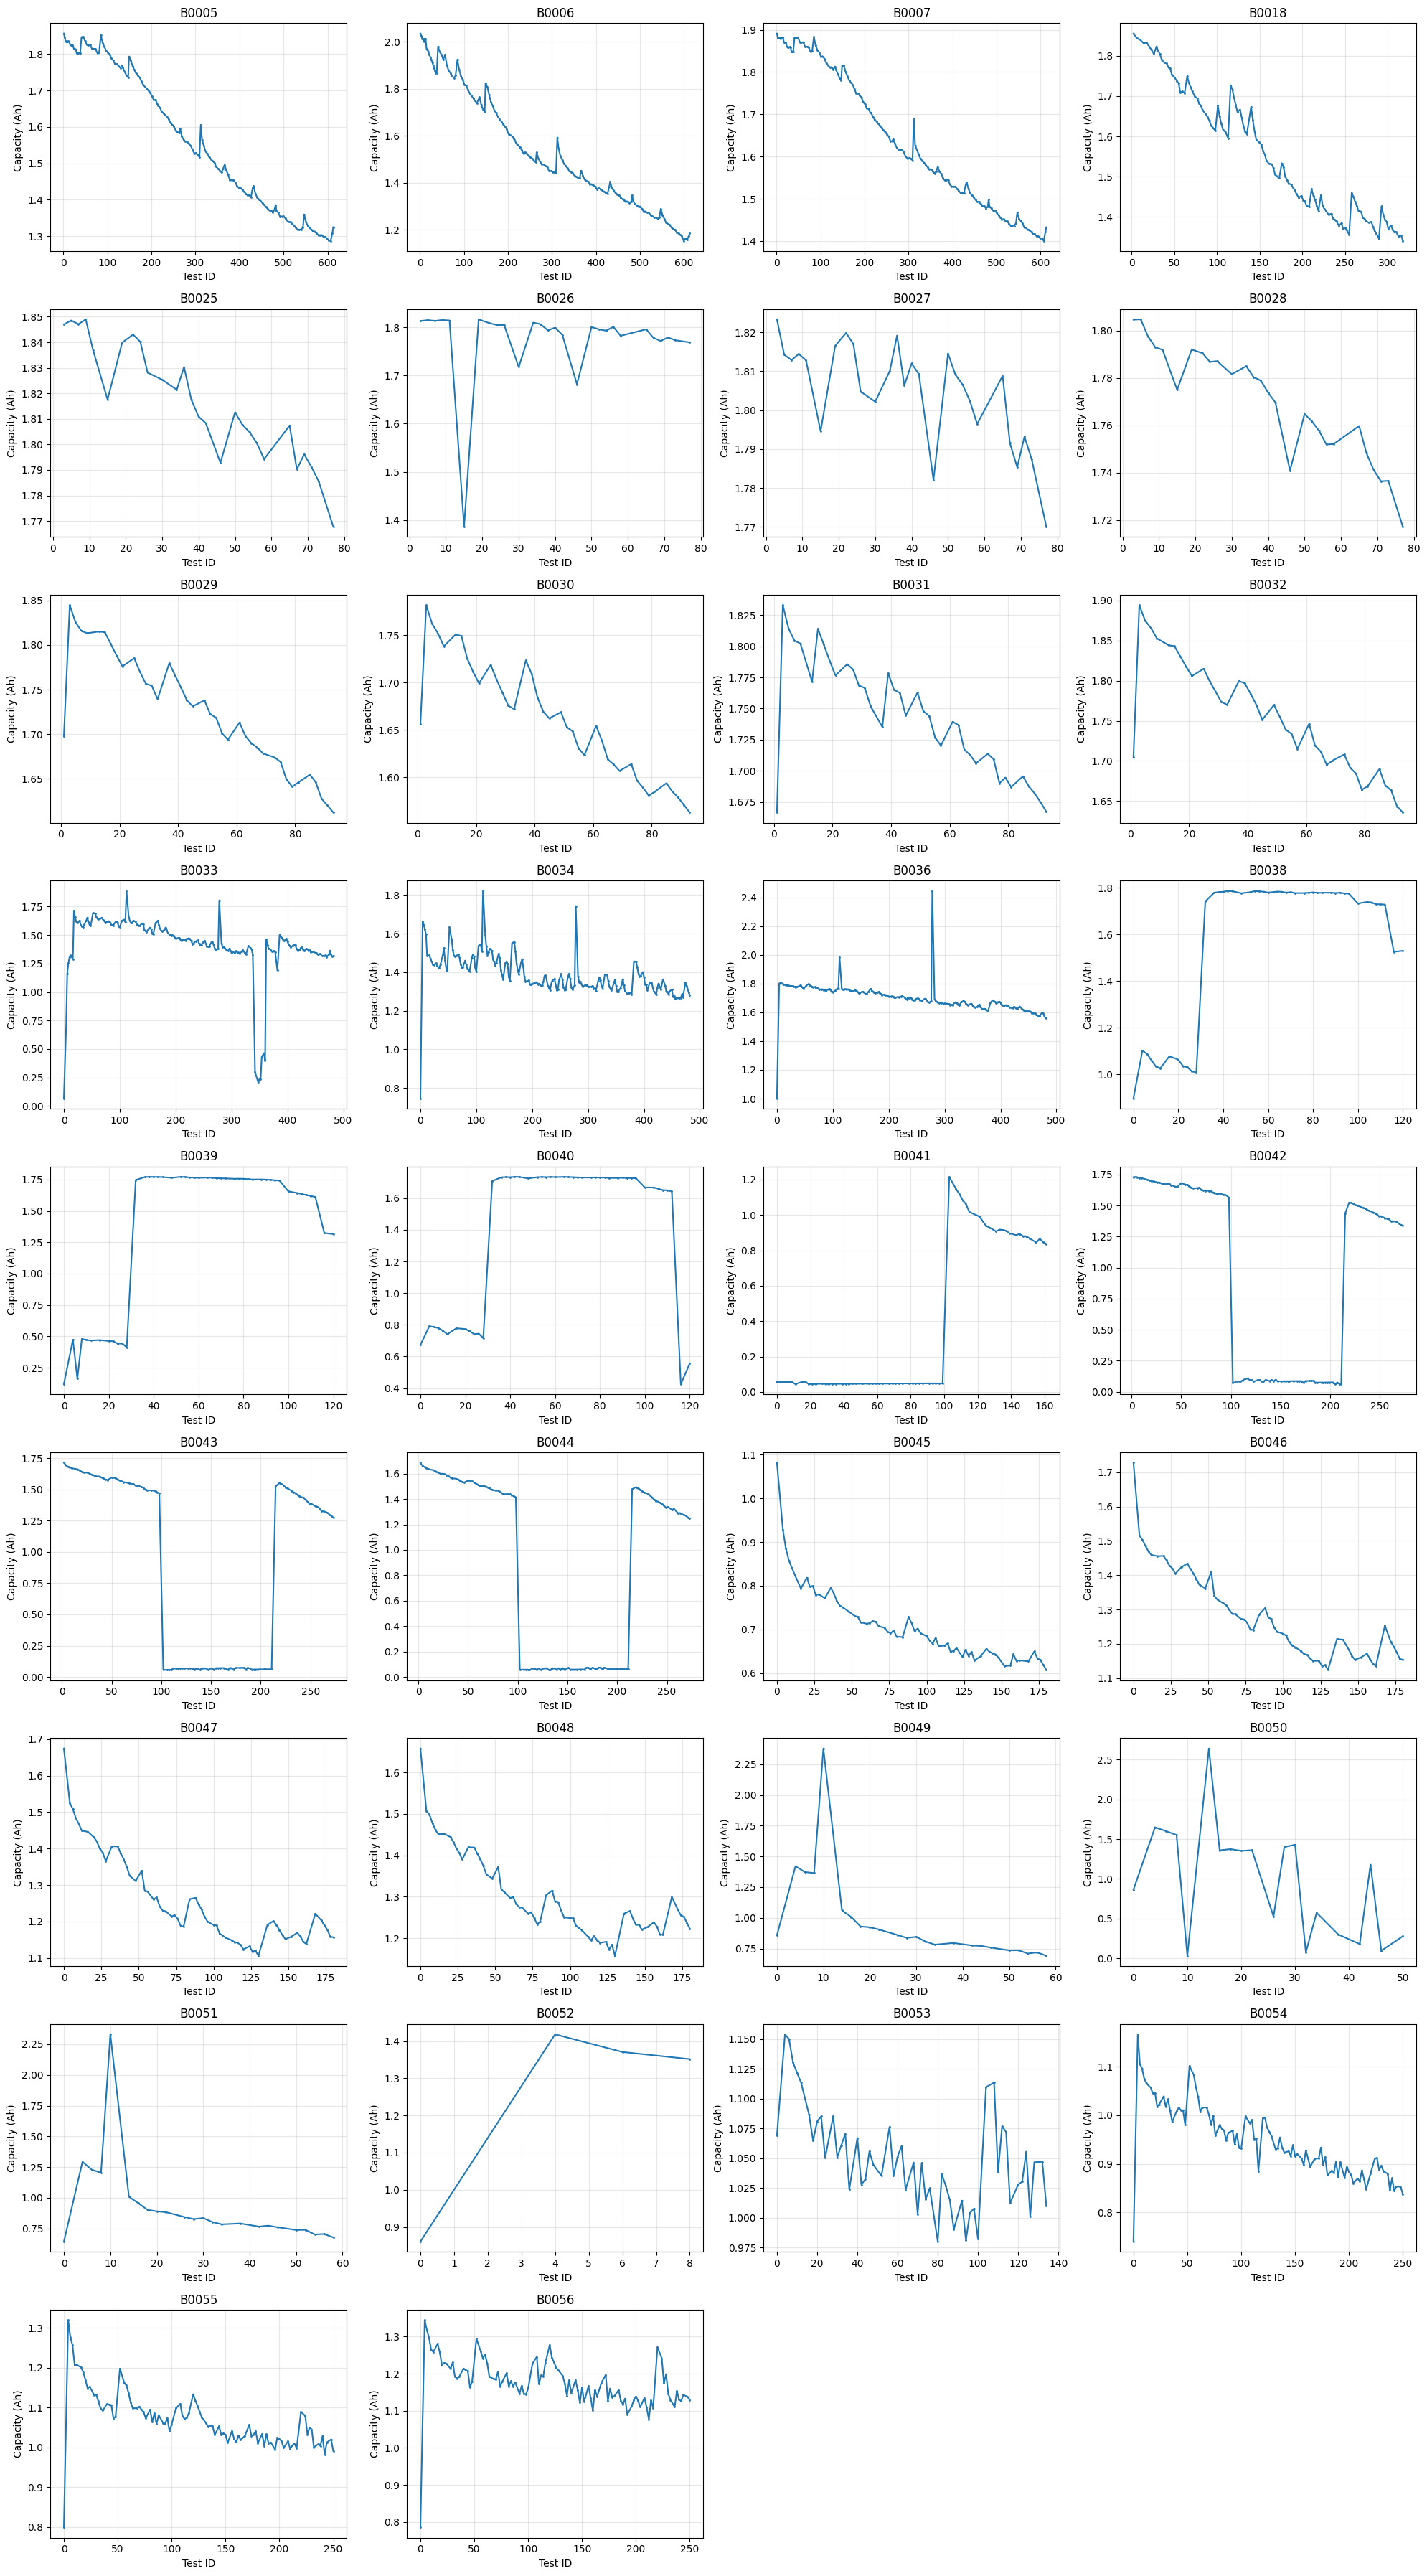


CAPACITY TRAJECTORIES GROUPED BY TEMPERATURE


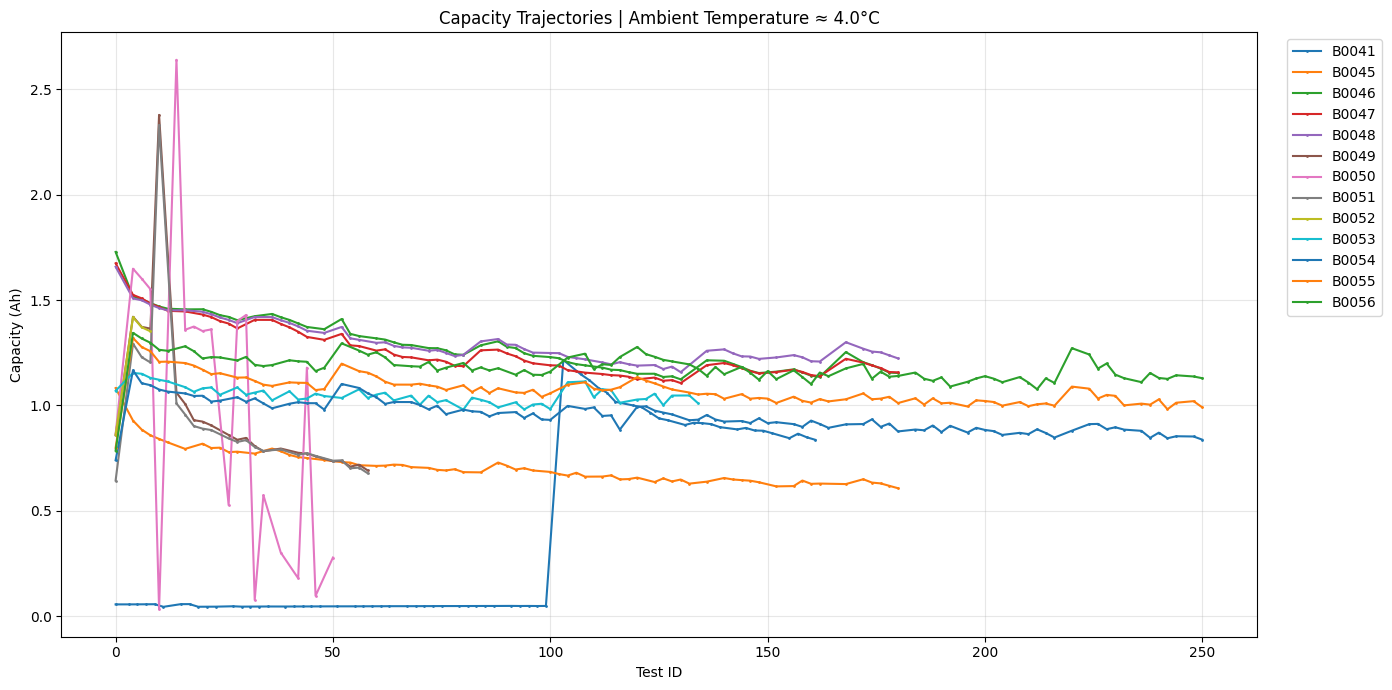

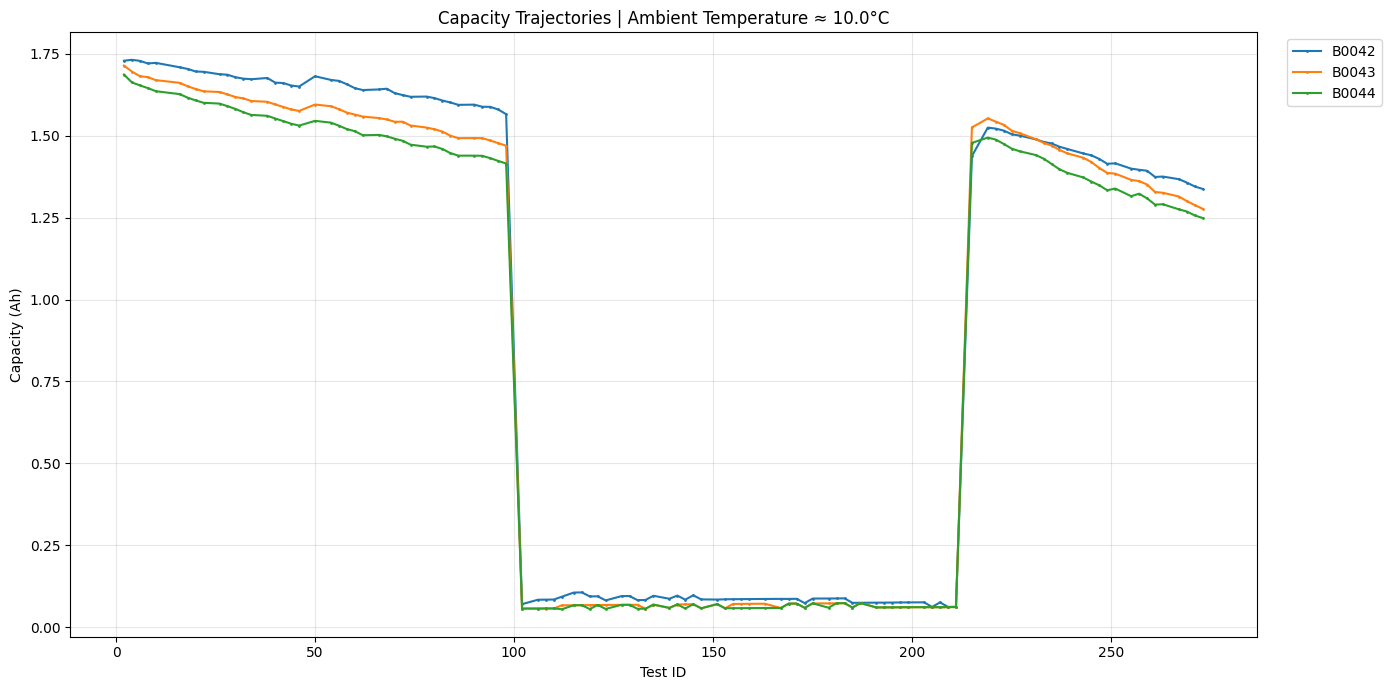

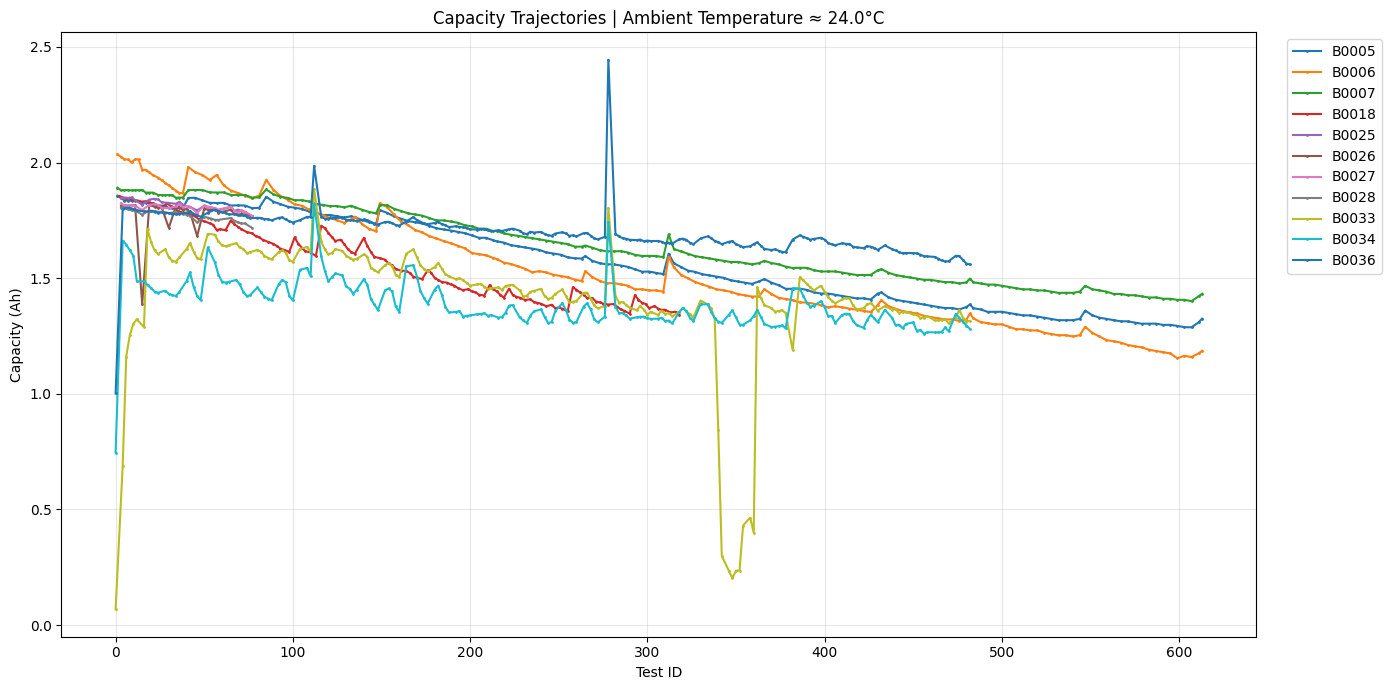

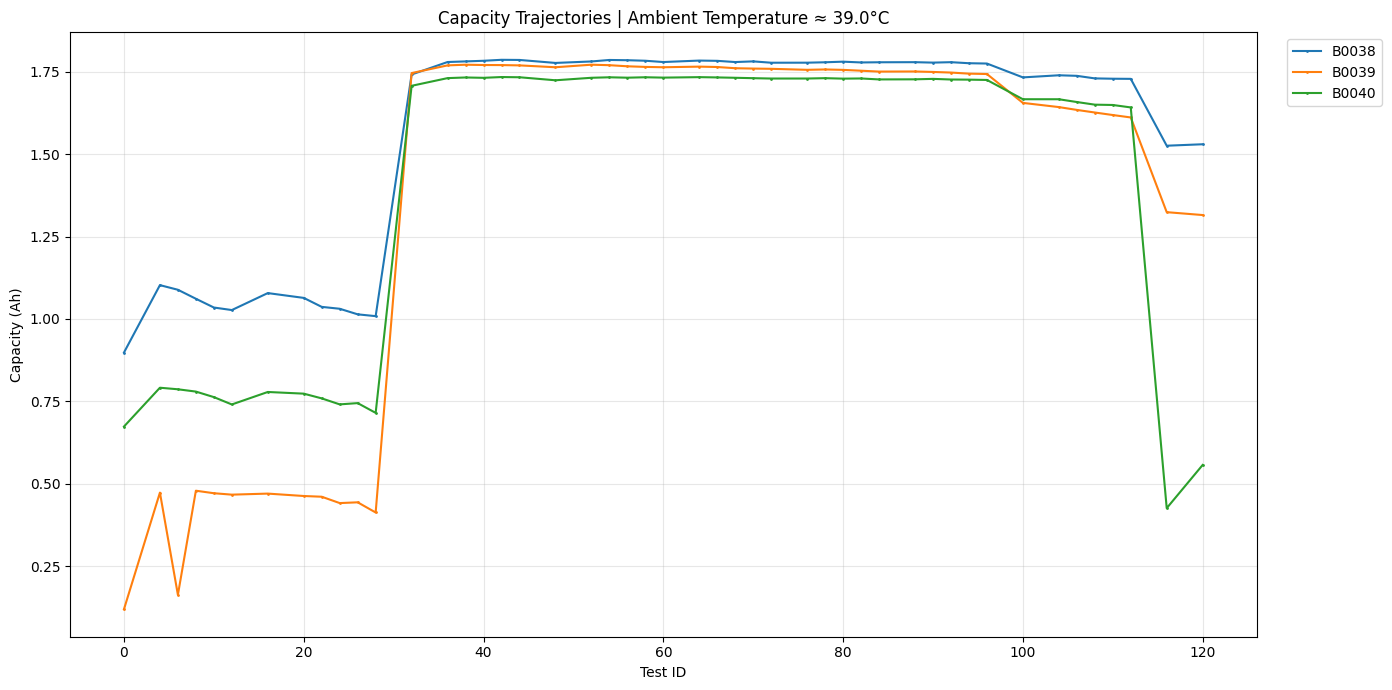

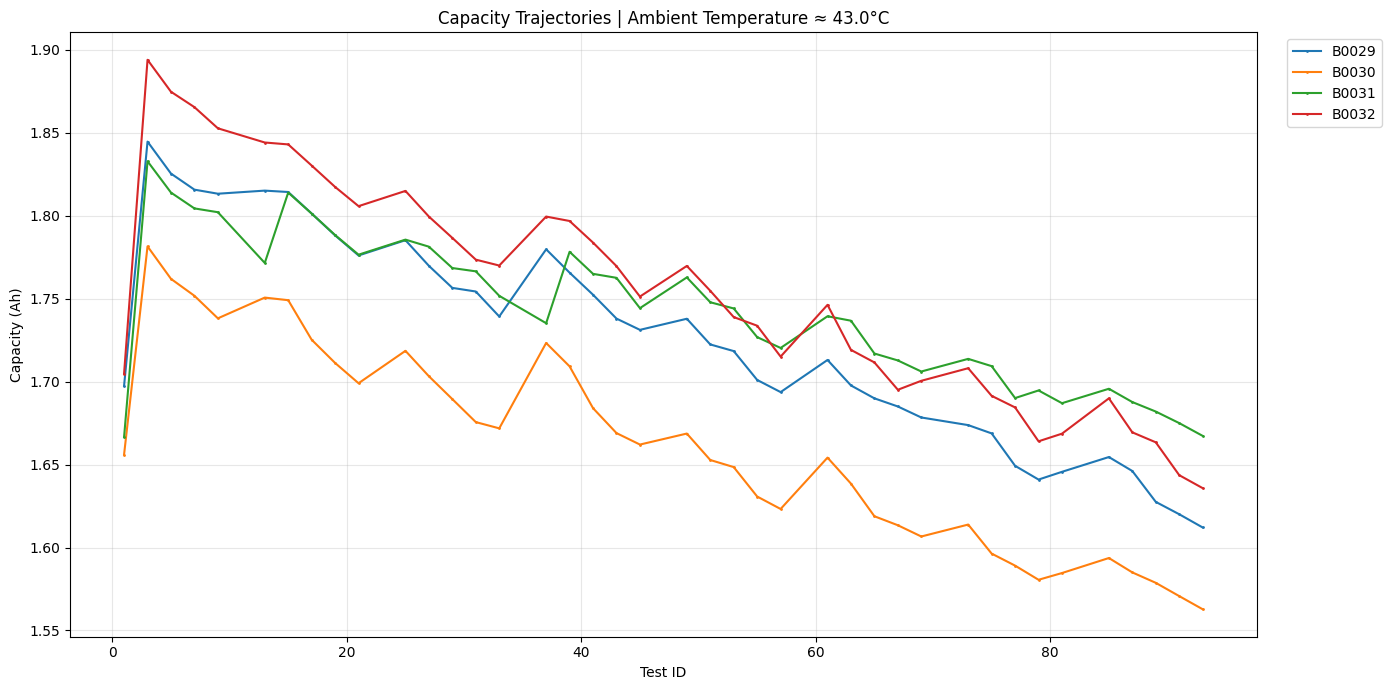


FIRST 15 MEASUREMENTS OF ADDITIONAL BATTERY GROUPS

B0033
-----------------------------------------------------------------


,test_id,Capacity
908,0,0.068426
909,4,0.689570
910,6,1.161085
911,8,1.252939
912,10,1.302918
913,12,1.321877
914,16,1.288469
915,18,1.713169
916,20,1.656097
917,22,1.619730



B0034
-----------------------------------------------------------------


,test_id,Capacity
1105,0,0.745930
1106,4,1.662322
1107,6,1.645087
1108,8,1.620729
1109,10,1.596740
1110,12,1.485650
1111,16,1.486670
1112,18,1.470133
1113,20,1.456504
1114,22,1.441896



B0036
-----------------------------------------------------------------


...


B0056
-----------------------------------------------------------------


,test_id,Capacity
2648,0,0.785278
2649,4,1.344356
2650,6,1.317503
2651,8,1.297365
2652,10,1.263960
2653,12,1.258950
2654,16,1.280620
2655,18,1.257279
2656,20,1.222626
2657,22,1.229277



PAPER-COMPARABLE BATTERIES


,battery_id,n_cycles,first_test_id,last_test_id,ambient_mean,ambient_min,ambient_max,discharge_current_mean,discharge_current_min,discharge_current_max,final_voltage_mean,final_voltage_min,final_voltage_max,first_capacity,first_5_mean,first_10_mean,median_capacity,max_capacity,min_capacity,largest_capacity_jump,median_capacity_change,temperature_group,current_group,cutoff_group
0,B0005,168,1,613,24.0,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.856487,1.841614,1.835402,1.557085,1.856487,1.287453,0.088333,-0.005153,24.0,NaN,NaN
1,B0006,168,1,613,24.0,24,24,NaN,NaN,NaN,NaN,NaN,NaN,2.035338,2.017523,2.000880,1.485372,2.035338,1.153818,0.151912,-0.009753,24.0,NaN,NaN
2,B0007,168,1,613,24.0,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.891052,1.882515,1.879446,1.616125,1.891052,1.400455,0.098170,-0.004932,24.0,NaN,NaN
3,B0018,132,2,318,24.0,24,24,NaN,NaN,NaN,NaN,NaN,NaN,1.855005,1.840235,1.829347,1.531892,1.855005,1.341051,0.131244,-0.008928,24.0,NaN,NaN



STAGE 2B COMPLETE

IMPORTANT:

Do NOT train the generalized model yet.

We now need to determine whether the 34 batteries can be treated
as one homogeneous SOH dataset or whether they should be divided
into experimental groups.

The most important outputs are:

1. BATTERY EXPERIMENTAL SUMMARY
2. APPROXIMATE EXPERIMENTAL GROUPS
3. CAPACITY JUMP ANALYSIS
4. CAPACITY TRAJECTORY GRID
5. TEMPERATURE-GROUP TRAJECTORIES

These outputs will determine the final generalized SOH-labeling
strategy.

The original paper benchmark remains untouched:

    B0005 → Training
    B0006/B0007/B0018 → Testing

That benchmark will continue using the paper-compatible C0
definition.



In [94]:
# ============================================================
# STAGE 2B:
# EXPERIMENTAL CONDITION + CAPACITY REGIME ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 85)
print("STAGE 2B: EXPERIMENTAL CONDITION + CAPACITY REGIME ANALYSIS")
print("=" * 85)


# ============================================================
# 1. PREPARE DATA
# ============================================================

analysis_df = clean_discharge.copy()

analysis_df["Capacity"] = pd.to_numeric(
    analysis_df["Capacity"],
    errors="coerce"
)

analysis_df["test_id_numeric"] = pd.to_numeric(
    analysis_df["test_id"],
    errors="coerce"
)

analysis_df = analysis_df[
    analysis_df["Capacity"].notna()
].copy()

analysis_df = analysis_df[
    analysis_df["Capacity"] > 0
].copy()

analysis_df = analysis_df.sort_values(
    [
        "battery_id",
        "test_id_numeric",
        "test_id"
    ]
).reset_index(drop=True)


# ============================================================
# 2. BATTERY-LEVEL EXPERIMENTAL SUMMARY
# ============================================================

battery_summary = []

for battery, group in analysis_df.groupby("battery_id"):

    group = group.sort_values(
        [
            "test_id_numeric",
            "test_id"
        ]
    ).copy()

    # --------------------------------------------------------
    # Capacity
    # --------------------------------------------------------

    capacity = group["Capacity"].astype(float)

    # --------------------------------------------------------
    # Ambient temperature
    # --------------------------------------------------------

    if "ambient_temperature" in group.columns:

        ambient_values = pd.to_numeric(
            group["ambient_temperature"],
            errors="coerce"
        )

        ambient_mean = ambient_values.mean()
        ambient_min = ambient_values.min()
        ambient_max = ambient_values.max()

    else:

        ambient_mean = np.nan
        ambient_min = np.nan
        ambient_max = np.nan


    # --------------------------------------------------------
    # Extract discharge-current information
    # --------------------------------------------------------

    current_features = []

    for _, row in group.iterrows():

        # We already extracted current_mean during feature
        # engineering if the column exists.

        if "current_mean" in group.columns:

            value = pd.to_numeric(
                row["current_mean"],
                errors="coerce"
            )

            if pd.notna(value):

                current_features.append(
                    abs(float(value))
                )


    if len(current_features) > 0:

        discharge_current_mean = np.mean(
            current_features
        )

        discharge_current_min = np.min(
            current_features
        )

        discharge_current_max = np.max(
            current_features
        )

    else:

        discharge_current_mean = np.nan
        discharge_current_min = np.nan
        discharge_current_max = np.nan


    # --------------------------------------------------------
    # Voltage information
    # --------------------------------------------------------

    voltage_features = []

    if "voltage_final" in group.columns:

        voltage_features = pd.to_numeric(
            group["voltage_final"],
            errors="coerce"
        ).dropna()

    if len(voltage_features) > 0:

        final_voltage_mean = (
            voltage_features.mean()
        )

        final_voltage_min = (
            voltage_features.min()
        )

        final_voltage_max = (
            voltage_features.max()
        )

    else:

        final_voltage_mean = np.nan
        final_voltage_min = np.nan
        final_voltage_max = np.nan


    # --------------------------------------------------------
    # Capacity changes
    # --------------------------------------------------------

    capacity_diff = capacity.diff()

    absolute_capacity_diff = (
        capacity_diff.abs()
    )

    # Largest consecutive jump.
    largest_capacity_jump = (
        absolute_capacity_diff
        .iloc[1:]
        .max()
        if len(capacity_diff) > 1
        else 0
    )

    # Median consecutive change.
    median_capacity_change = (
        capacity_diff
        .iloc[1:]
        .median()
        if len(capacity_diff) > 1
        else 0
    )


    # --------------------------------------------------------
    # First and later capacity statistics
    # --------------------------------------------------------

    first_capacity = (
        capacity.iloc[0]
    )

    first_5_mean = (
        capacity.iloc[:min(5, len(capacity))]
        .mean()
    )

    first_10_mean = (
        capacity.iloc[:min(10, len(capacity))]
        .mean()
    )

    maximum_capacity = (
        capacity.max()
    )

    median_capacity = (
        capacity.median()
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    battery_summary.append({

        "battery_id": battery,

        "n_cycles": len(group),

        "first_test_id":
            group["test_id"].iloc[0],

        "last_test_id":
            group["test_id"].iloc[-1],

        "ambient_mean":
            ambient_mean,

        "ambient_min":
            ambient_min,

        "ambient_max":
            ambient_max,

        "discharge_current_mean":
            discharge_current_mean,

        "discharge_current_min":
            discharge_current_min,

        "discharge_current_max":
            discharge_current_max,

        "final_voltage_mean":
            final_voltage_mean,

        "final_voltage_min":
            final_voltage_min,

        "final_voltage_max":
            final_voltage_max,

        "first_capacity":
            first_capacity,

        "first_5_mean":
            first_5_mean,

        "first_10_mean":
            first_10_mean,

        "median_capacity":
            median_capacity,

        "max_capacity":
            maximum_capacity,

        "min_capacity":
            capacity.min(),

        "largest_capacity_jump":
            largest_capacity_jump,

        "median_capacity_change":
            median_capacity_change
    })


battery_summary = pd.DataFrame(
    battery_summary
).sort_values(
    "battery_id"
).reset_index(drop=True)


# ============================================================
# 3. DISPLAY BATTERY EXPERIMENTAL SUMMARY
# ============================================================

print("\n" + "=" * 85)
print("BATTERY EXPERIMENTAL SUMMARY")
print("=" * 85)

display(
    battery_summary
)


# ============================================================
# 4. DISPLAY IMPORTANT EXPERIMENTAL GROUPING FEATURES
# ============================================================

print("\n" + "=" * 85)
print("IMPORTANT EXPERIMENTAL VARIABLES")
print("=" * 85)

display(
    battery_summary[
        [
            "battery_id",
            "n_cycles",
            "ambient_mean",
            "discharge_current_mean",
            "final_voltage_mean",
            "first_capacity",
            "median_capacity",
            "max_capacity"
        ]
    ]
)


# ============================================================
# 5. GROUP BATTERIES BY APPROXIMATE OPERATING CONDITIONS
# ============================================================

# Round continuous measurements so batteries with effectively
# identical experimental conditions can be inspected together.

grouping_df = battery_summary.copy()

grouping_df["temperature_group"] = (
    grouping_df["ambient_mean"]
    .round(0)
)

grouping_df["current_group"] = (
    grouping_df["discharge_current_mean"]
    .round(1)
)

grouping_df["cutoff_group"] = (
    grouping_df["final_voltage_mean"]
    .round(1)
)


print("\n" + "=" * 85)
print("APPROXIMATE EXPERIMENTAL GROUPS")
print("=" * 85)

display(
    grouping_df[
        [
            "battery_id",
            "temperature_group",
            "current_group",
            "cutoff_group",
            "n_cycles"
        ]
    ]
    .sort_values(
        [
            "temperature_group",
            "current_group",
            "cutoff_group",
            "battery_id"
        ]
    )
)


# ============================================================
# 6. CAPACITY JUMP ANALYSIS
# ============================================================

print("\n" + "=" * 85)
print("BATTERIES WITH LARGE CONSECUTIVE CAPACITY JUMPS")
print("=" * 85)

jump_table = (
    battery_summary[
        [
            "battery_id",
            "largest_capacity_jump",
            "first_capacity",
            "median_capacity",
            "max_capacity"
        ]
    ]
    .sort_values(
        "largest_capacity_jump",
        ascending=False
    )
)

display(
    jump_table
)


# ============================================================
# 7. PLOT CAPACITY TRAJECTORIES FOR ALL BATTERIES
# ============================================================

print("\n" + "=" * 85)
print("GENERATING CAPACITY TRAJECTORY GRID")
print("=" * 85)

batteries = sorted(
    analysis_df["battery_id"]
    .unique()
)

n_batteries = len(
    batteries
)

n_columns = 4

n_rows = int(
    np.ceil(
        n_batteries / n_columns
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(
        20,
        4 * n_rows
    )
)

axes = np.array(
    axes
).reshape(-1)


for ax, battery in zip(
    axes,
    batteries
):

    group = analysis_df[
        analysis_df["battery_id"] == battery
    ].sort_values(
        [
            "test_id_numeric",
            "test_id"
        ]
    )

    ax.plot(
        group["test_id_numeric"],
        group["Capacity"],
        marker=".",
        markersize=2
    )

    ax.set_title(
        battery
    )

    ax.set_xlabel(
        "Test ID"
    )

    ax.set_ylabel(
        "Capacity (Ah)"
    )

    ax.grid(
        True,
        alpha=0.3
    )


for ax in axes[n_batteries:]:

    ax.set_visible(
        False
    )


plt.tight_layout()
plt.show()


# ============================================================
# 8. PLOT CAPACITY TRAJECTORIES BY TEMPERATURE GROUP
# ============================================================

print("\n" + "=" * 85)
print("CAPACITY TRAJECTORIES GROUPED BY TEMPERATURE")
print("=" * 85)

temperature_groups = (
    grouping_df[
        "temperature_group"
    ]
    .dropna()
    .unique()
)

for temperature in sorted(
    temperature_groups
):

    group_batteries = grouping_df[
        grouping_df["temperature_group"] == temperature
    ]["battery_id"].tolist()

    plt.figure(
        figsize=(14, 7)
    )

    for battery in group_batteries:

        group = analysis_df[
            analysis_df["battery_id"] == battery
        ].sort_values(
            [
                "test_id_numeric",
                "test_id"
            ]
        )

        plt.plot(
            group["test_id_numeric"],
            group["Capacity"],
            marker=".",
            markersize=2,
            label=battery
        )

    plt.xlabel(
        "Test ID"
    )

    plt.ylabel(
        "Capacity (Ah)"
    )

    plt.title(
        f"Capacity Trajectories | Ambient Temperature ≈ {temperature}°C"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. DETAILED EARLY TRAJECTORY INSPECTION
# ============================================================

important_batteries = [

    "B0033",
    "B0034",
    "B0036",
    "B0038",
    "B0039",
    "B0040",
    "B0041",
    "B0042",
    "B0043",
    "B0044",
    "B0045",
    "B0046",
    "B0047",
    "B0048",
    "B0049",
    "B0050",
    "B0051",
    "B0052",
    "B0053",
    "B0054",
    "B0055",
    "B0056"

]

available_batteries = [

    battery
    for battery in important_batteries
    if battery in batteries

]


print("\n" + "=" * 85)
print("FIRST 15 MEASUREMENTS OF ADDITIONAL BATTERY GROUPS")
print("=" * 85)


for battery in available_batteries:

    group = analysis_df[
        analysis_df["battery_id"] == battery
    ].sort_values(
        [
            "test_id_numeric",
            "test_id"
        ]
    )

    print(
        f"\n{battery}"
    )

    print(
        "-" * 65
    )

    display(
        group[
            [
                "test_id",
                "Capacity"
            ]
        ]
        .head(15)
    )


# ============================================================
# 10. CHECK PAPER BATTERIES
# ============================================================

paper_batteries = [

    "B0005",
    "B0006",
    "B0007",
    "B0018"

]


print("\n" + "=" * 85)
print("PAPER-COMPARABLE BATTERIES")
print("=" * 85)

display(
    grouping_df[
        grouping_df["battery_id"].isin(
            paper_batteries
        )
    ]
)


# ============================================================
# 11. FINAL DIAGNOSTIC MESSAGE
# ============================================================

print("\n" + "=" * 85)
print("STAGE 2B COMPLETE")
print("=" * 85)

print(
    """
IMPORTANT:

Do NOT train the generalized model yet.

We now need to determine whether the 34 batteries can be treated
as one homogeneous SOH dataset or whether they should be divided
into experimental groups.

The most important outputs are:

1. BATTERY EXPERIMENTAL SUMMARY
2. APPROXIMATE EXPERIMENTAL GROUPS
3. CAPACITY JUMP ANALYSIS
4. CAPACITY TRAJECTORY GRID
5. TEMPERATURE-GROUP TRAJECTORIES

These outputs will determine the final generalized SOH-labeling
strategy.

The original paper benchmark remains untouched:

    B0005 → Training
    B0006/B0007/B0018 → Testing

That benchmark will continue using the paper-compatible C0
definition.
"""
)

# Stage 3: Generalized DriveGuard-X SOH Dataset and Multi-Model Training

## Objective

The paper-comparable experiment has already been completed using:

- B0005 for training
- B0006, B0007 and B0018 for testing
- XGBoost as the baseline model

The next objective is to build the first generalized DriveGuard-X battery SOH model.

The purpose of this experiment is different from the paper reproduction.

Instead of asking:

> How closely can we reproduce the published experiment?

we now ask:

> Can a machine-learning model learn a general relationship between battery discharge characteristics and SOH across multiple previously unseen battery trajectories?

---

## 1. Dataset selection

The complete NASA-derived discharge dataset contains 34 battery groups.

The investigation showed that several battery groups contain capacity trajectories that cannot safely be interpreted as a normal degradation trajectory using the first recorded capacity as C0.

Examples include batteries where the first recorded capacity is dramatically lower than the subsequent stable capacity regime, or where isolated measurements create very large discontinuities.

Therefore, the first generalized experiment uses a curated set of battery trajectories with comparatively coherent capacity behavior:

B0005
B0006
B0007
B0018
B0025
B0027
B0028
B0029
B0030
B0031
B0032
B0043
B0044
B0045
B0046
B0047
B0048
B0053
B0054
B0055
B0056

The following highly problematic trajectories are excluded from this first generalized experiment:

B0033
B0034
B0036
B0038
B0039
B0040
B0041
B0042
B0049
B0050
B0051
B0052

This does not mean those batteries are discarded permanently.

They will be retained for later analysis and can be used in a separate robustness experiment.

---

## 2. SOH definition

For the generalized experiment:

    SOH = Capacity / C0

where C0 is estimated from the stable early-life capacity region of each battery.

The reference capacity is not taken directly from the first observation because the dataset contains cases where the first capacity measurement is clearly inconsistent with the subsequent trajectory.

Instead, the candidate C0 is derived using a robust early-life reference procedure:

1. Sort the battery experiments by test ID.
2. Consider the earliest portion of the trajectory.
3. Estimate the dominant early capacity regime.
4. Use a robust central value from that regime as C0.
5. Calculate SOH from the measured capacity.

SOH values are then validated before model training.

Values outside a physically reasonable range are not silently clipped.

---

## 3. Feature set

The model uses the cycle-level discharge features already engineered from the raw voltage, current, temperature and load measurements.

The feature set is:

- voltage_initial
- voltage_final
- voltage_min
- voltage_max
- voltage_mean
- voltage_std
- voltage_drop
- current_mean
- current_min
- current_max
- current_std
- temperature_initial
- temperature_final
- temperature_max
- temperature_mean
- temperature_rise
- load_current_abs_mean
- load_current_abs_max
- load_voltage_mean
- load_voltage_min
- discharge_duration

The absolute load-current features are used because the dataset contains both signs for load current depending on the representation of current direction.

The model therefore learns the magnitude of the applied load rather than treating the sign convention itself as a physical degradation feature.

---

## 4. Important leakage consideration

The model must not be allowed to use:

- battery_id
- test_id
- filename
- Capacity
- C0
- SOH

as input features.

These variables are metadata or target information.

Only the engineered electrical, thermal and temporal discharge features are supplied to the machine-learning models.

---

## 5. Battery-level train/validation/test split

A random row-level split would create data leakage because multiple cycles from the same battery are strongly correlated.

For example, if 80% of B0005 cycles were used for training and 20% for testing, the model would already have seen the same battery during training.

That is not the generalization problem we want to measure.

Therefore, splitting is performed at the battery level.

Entire battery trajectories are assigned to only one partition.

The generalized experiment uses approximately:

- 60% of batteries for training
- 20% for validation
- 20% for final testing

The exact battery assignment is generated using a fixed random seed so the experiment is reproducible.

---

## 6. Models

Three models are trained:

### Model 1: XGBoost

XGBoost is the primary candidate because:

- it performed strongly in the paper-comparable experiment
- it handles nonlinear relationships
- it works well with relatively small tabular datasets
- it can provide feature importance and SHAP explanations
- it is practical for eventual deployment

### Model 2: Random Forest

Random Forest provides a tree-based comparison against XGBoost.

### Model 3: Support Vector Regression

SVR provides a fundamentally different nonlinear regression approach.

These three models also align with the algorithms compared in the selected research paper.

---

## 7. Evaluation metrics

Each model is evaluated using:

- MAE
- MSE
- RMSE
- R²

MAE is particularly important because SOH estimation is a regression problem and the value directly represents average prediction error in SOH units.

For example:

MAE = 0.02

approximately corresponds to an average absolute SOH error of 2 percentage points.

---

## 8. Evaluation philosophy

The validation set is used for model selection.

The final test set is kept untouched until model selection is complete.

The test set therefore represents batteries that the model has never seen during training.

This is substantially more meaningful for DriveGuard-X than a random train/test split.

After the initial models are trained, the following stages will investigate:

1. Hyperparameter tuning
2. Feature importance
3. SHAP explanations
4. Generalization to unseen batteries
5. Comparison against the paper
6. Robustness on excluded batteries
7. Final model selection

---

## 9. Important limitation

This model is currently a cycle-level SOH estimator.

Some features, especially discharge_duration and full-cycle statistics, require a substantial portion of the discharge cycle before they can be calculated.

Therefore, this model is appropriate for the research comparison and initial DriveGuard-X SOH estimator, but it should not yet be described as a real-time instantaneous BMS predictor.

A later deployment stage can convert the same concept into a rolling-window inference model suitable for ESP32 operation.

---

## 10. Outputs of this stage

This stage will create:

- generalized_ml_dataset
- train/validation/test datasets
- battery split summary
- trained XGBoost model
- trained Random Forest model
- trained SVR model
- model comparison table
- per-battery test results
- actual-vs-predicted plots
- prediction error distributions
- saved model artifacts

The resulting comparison will tell us whether XGBoost remains the best candidate when the problem changes from a single-battery training experiment to cross-battery generalization.

No final model will be declared yet.

The best model will only be selected after validation, robustness testing and comparison with the research-paper baseline.

In [97]:
print("generalized_ml_dataset exists:",
      "generalized_ml_dataset" in globals())

if "generalized_ml_dataset" in globals():
    print("\nShape:")
    print(generalized_ml_dataset.shape)

    print("\nColumns:")
    print(list(generalized_ml_dataset.columns))

print("\nclean_discharge exists:",
      "clean_discharge" in globals())

if "clean_discharge" in globals():
    print("\nclean_discharge shape:")
    print(clean_discharge.shape)

    print("\nclean_discharge columns:")
    print(list(clean_discharge.columns))

generalized_ml_dataset exists: True

Shape:
(1730, 14)

Columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'Capacity_numeric', 'test_id_numeric', 'C0', 'SOH']

clean_discharge exists: True

clean_discharge shape:
(2750, 11)

clean_discharge columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'Capacity_numeric']


DRIVEGUARD-X STAGE 3
GENERALIZED BATTERY SOH MODEL

clean_discharge found.
Shape: (2750, 11)
Columns: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'Capacity_numeric']

Selected discharge experiments:
1740
Selected batteries: 21

SEARCHING FOR RAW NASA CSV FILES
CSV files found: 7566
Unique CSV filenames indexed: 7566

Resolved CSV files: 1740
Unresolved CSV files: 0

EXTRACTING FEATURES FROM DISCHARGE CSV FILES
Processing 1/1,740 | Battery B0005
Processing 250/1,740 | Battery B0006
Processing 500/1,740 | Battery B0007
Processing 750/1,740 | Battery B0029
Processing 1,000/1,740 | Battery B0044
Processing 1,250/1,740 | Battery B0047
Processing 1,500/1,740 | Battery B0054
Processing 1,740/1,740 | Battery B0056

FEATURE EXTRACTION COMPLETE
Successful experiments: 1740
Failed experiments: 0

✓ All 21 engineered features successfully created.

C0 REFERENCE TABLE


,battery_id,C0,method,first_capacity,early_max,min_capacity,max_capacity,cycles
0,B0005,1.856487,first_capacity,1.856487,1.856487,1.287453,1.856487,168
1,B0006,2.035338,first_capacity,2.035338,2.035338,1.153818,2.035338,168
2,B0007,1.891052,first_capacity,1.891052,1.891052,1.400455,1.891052,168
3,B0018,1.855005,first_capacity,1.855005,1.855005,1.341051,1.855005,132
4,B0025,1.848984,max_first_five,1.847011,1.848984,1.767789,1.848984,28
5,B0027,1.823308,max_first_five,1.823308,1.823308,1.770093,1.823308,28
6,B0028,1.804783,max_first_five,1.804685,1.804783,1.717234,1.804783,28
7,B0029,1.844701,max_first_five,1.697507,1.844701,1.612080,1.844701,40
8,B0030,1.781555,max_first_five,1.656071,1.781555,1.562780,1.781555,40
9,B0031,1.832858,max_first_five,1.666675,1.832858,1.666675,1.832858,40



SOH QUALITY CHECK
Total records: 1740
SOH minimum: 0.03268074602926323
SOH maximum: 1.0
SOH mean: 0.7960745595086293
SOH median: 0.8390731989395204
SOH > 1.00: 0
SOH > 1.05: 0
SOH > 1.10: 0
SOH <= 0: 0

SOH SUMMARY BY BATTERY


,battery_id,count,min,max,mean,std
0,B0005,168,0.693488,1.0,0.847031,0.102566
1,B0006,168,0.566893,1.0,0.759997,0.123831
2,B0007,168,0.740569,1.0,0.869580,0.085112
3,B0018,132,0.722937,1.0,0.839729,0.083496
4,B0025,28,0.956087,1.0,0.982438,0.012055
5,B0027,28,0.970814,1.0,0.989896,0.007087
6,B0028,28,0.951490,1.0,0.980760,0.012812
7,B0029,40,0.873898,1.0,0.935660,0.034723
8,B0030,40,0.877200,1.0,0.932359,0.034206
9,B0031,40,0.909331,1.0,0.951077,0.024590



SOH FILTER
Before: 1740
After: 1740
Removed: 0

FEATURE QUALITY


,Feature,Missing,Infinite,Min,Max,Mean,Std
0,voltage_initial,0,0,3.309743,4.039277,3.892684,0.140809
1,voltage_final,0,0,1.670442,2.699983,2.380846,0.252637
2,voltage_min,0,0,1.670442,2.699983,2.380846,0.252637
3,voltage_max,0,0,3.309743,4.039277,3.892684,0.140809
4,voltage_mean,0,0,2.932682,3.577328,3.365379,0.164594
5,voltage_std,0,0,0.114658,0.490775,0.277736,0.071496
6,voltage_drop,0,0,0.620087,2.260347,1.511838,0.294278
7,current_mean,0,0,-4.025376,-0.994128,-2.166813,0.930519
8,current_min,0,0,-4.030782,-0.996920,-2.171153,0.930071
9,current_max,0,0,-4.022420,-0.973011,-2.152968,0.913142



Rows removed due to invalid features: 0

FINAL GENERALIZED ML DATASET
Shape: (1740, 28)
Batteries: 21
Features: 21
Target: SOH


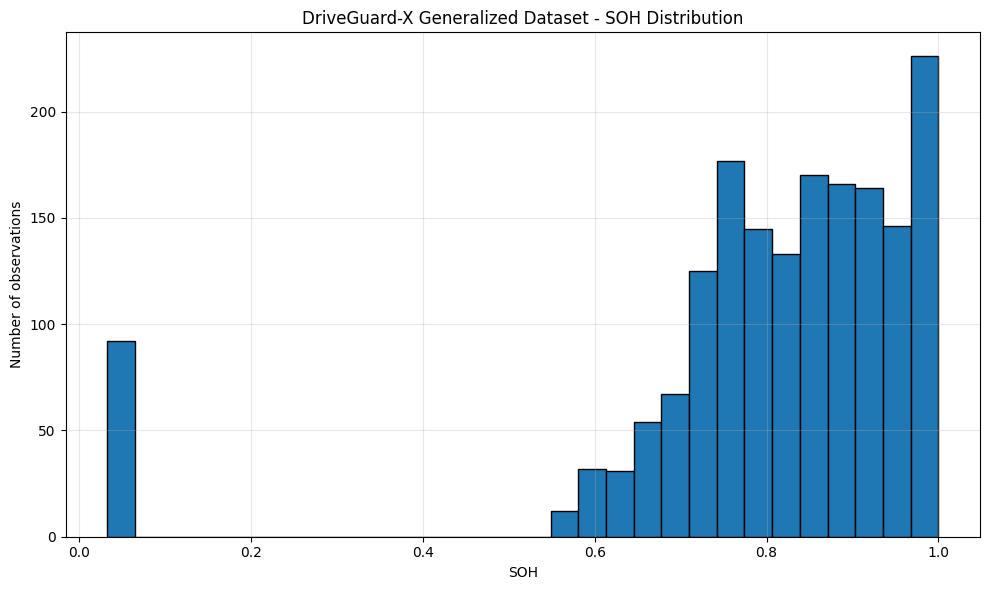

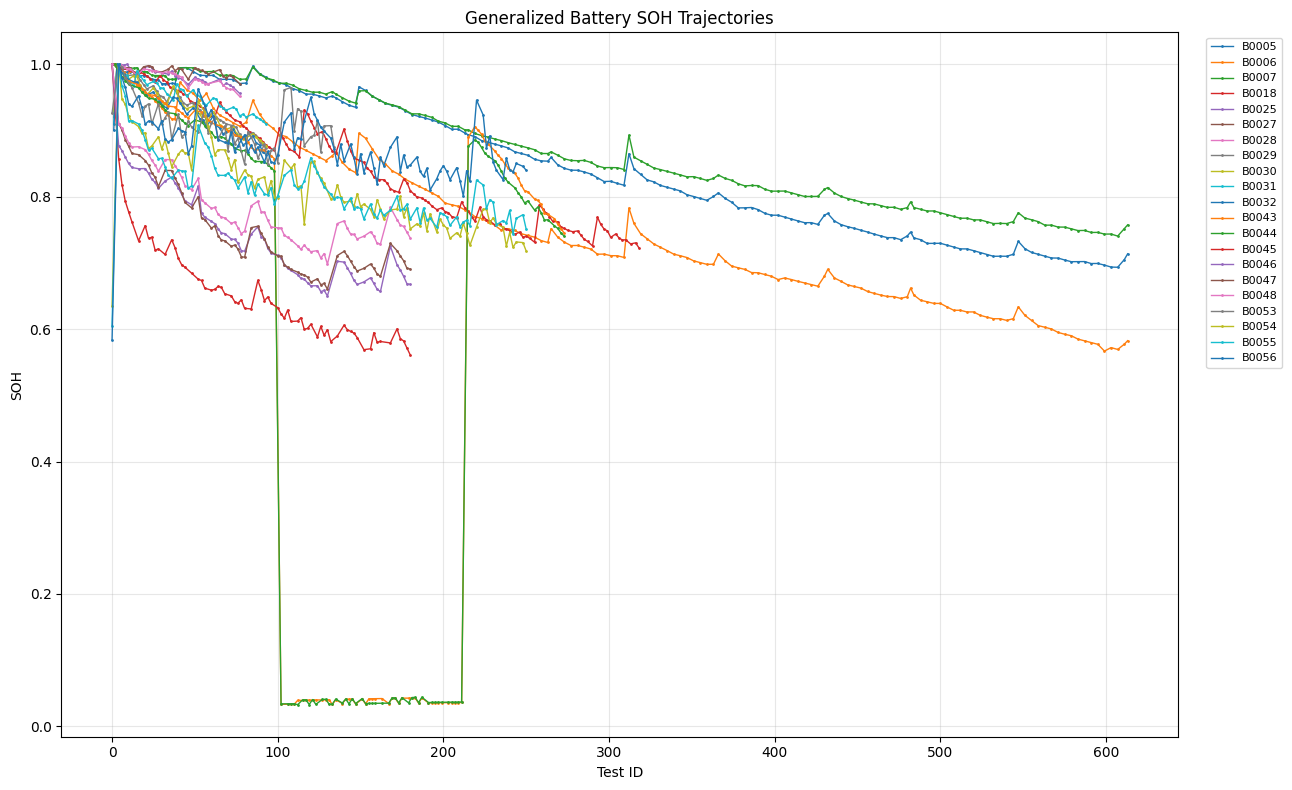


BATTERY-LEVEL SPLIT
Available batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0053', 'B0054', 'B0055', 'B0056']

TRAIN BATTERIES:
['B0007', 'B0018', 'B0025', 'B0028', 'B0029', 'B0031', 'B0032', 'B0044', 'B0046', 'B0048', 'B0054', 'B0056']

VALIDATION BATTERIES:
['B0027', 'B0043', 'B0045', 'B0055']

TEST BATTERIES:
['B0005', 'B0006', 'B0030', 'B0047', 'B0053']

PARTITION SUMMARY


,Partition,Batteries,Rows,Mean SOH,Minimum SOH,Maximum SOH
0,Train,12,929,0.818558,0.032681,1.0
1,Validation,4,311,0.693493,0.032994,1.0
2,Test,5,500,0.818106,0.566893,1.0



MODEL MATRICES
X_train: (929, 21)
y_train: (929,)
X_validation: (311, 21)
y_validation: (311,)
X_test: (500, 21)
y_test: (500,)

MODEL TRAINING

----------------------------------------------------------------------
Training XGBoost...
----------------------------------------------------------------------
Validation MAE : 0.061134
Validation RMSE: 0.086235
Validation R²  : 0.914682
Test MAE       : 0.088606
Test RMSE      : 0.124588
Test R²        : -0.141103

----------------------------------------------------------------------
Training Random Forest...
----------------------------------------------------------------------
Validation MAE : 0.044678
Validation RMSE: 0.057838
Validation R²  : 0.961621
Test MAE       : 0.079300
Test RMSE      : 0.104311
Test R²        : 0.200116

----------------------------------------------------------------------
Training SVR...
----------------------------------------------------------------------
Validation MAE : 0.074246
Validation RMSE: 0.099399

,Model,Validation MAE,Validation MSE,Validation RMSE,Validation R2,Test MAE,Test MSE,Test RMSE,Test R2
0,Random Forest,0.044678,0.003345,0.057838,0.961621,0.079300,0.010881,0.104311,0.200116
1,XGBoost,0.061134,0.007436,0.086235,0.914682,0.088606,0.015522,0.124588,-0.141103
2,SVR,0.074246,0.009880,0.099399,0.886647,0.043720,0.003155,0.056166,0.768095



Best initial model: Random Forest

PER-BATTERY TEST RESULTS


,Battery,Model,MAE,MSE,RMSE,R2,Samples
0,B0005,SVR,0.014349,0.000300,0.017315,0.971329,168
1,B0005,XGBoost,0.050664,0.004989,0.070636,0.522875,168
2,B0005,Random Forest,0.053444,0.003944,0.062803,0.622821,168
3,B0006,SVR,0.080243,0.006522,0.080756,0.572153,168
4,B0006,Random Forest,0.141263,0.026230,0.161957,-0.720815,168
5,B0006,XGBoost,0.141807,0.025591,0.159973,-0.678908,168
6,B0030,SVR,0.017946,0.000492,0.022179,0.568814,40
7,B0030,Random Forest,0.034662,0.001492,0.038627,-0.307908,40
8,B0030,XGBoost,0.157751,0.055410,0.235393,-47.570510,40
9,B0047,SVR,0.008764,0.000130,0.011415,0.975173,69



ACTUAL VS PREDICTED: Random Forest


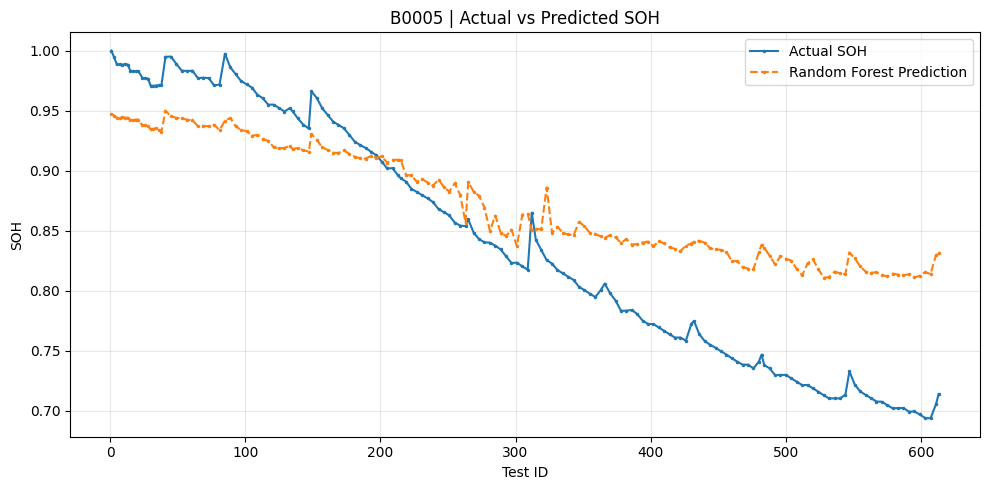

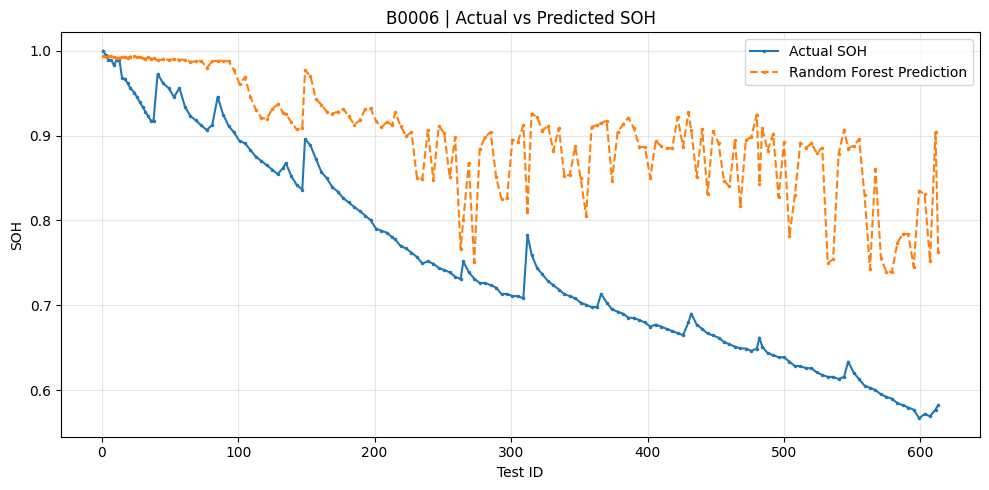

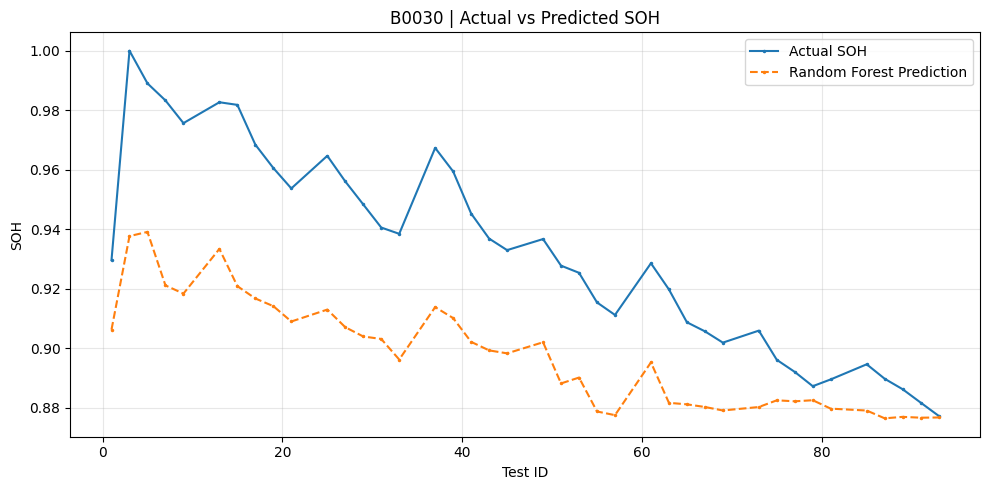

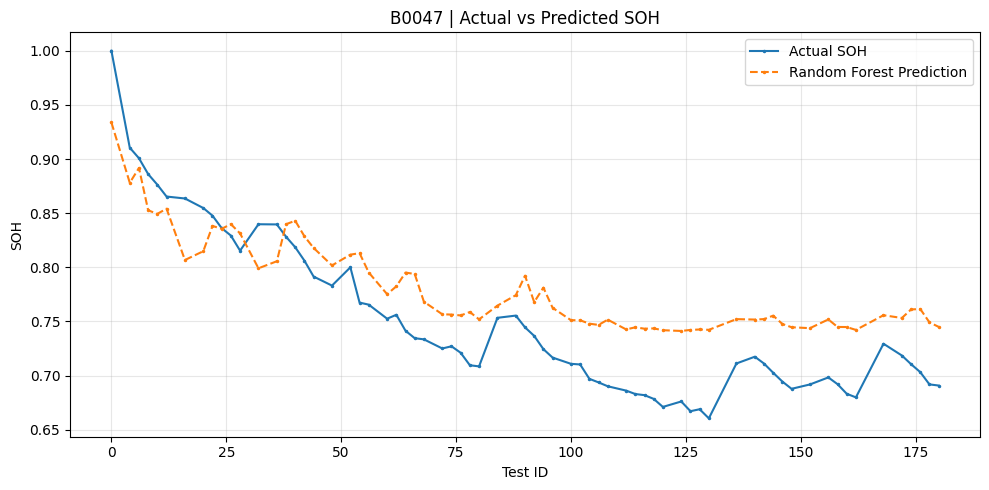

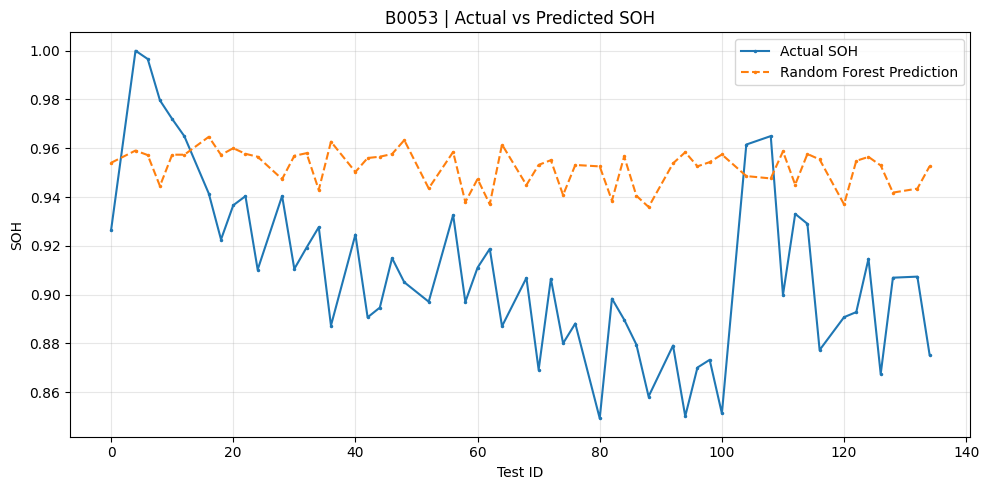

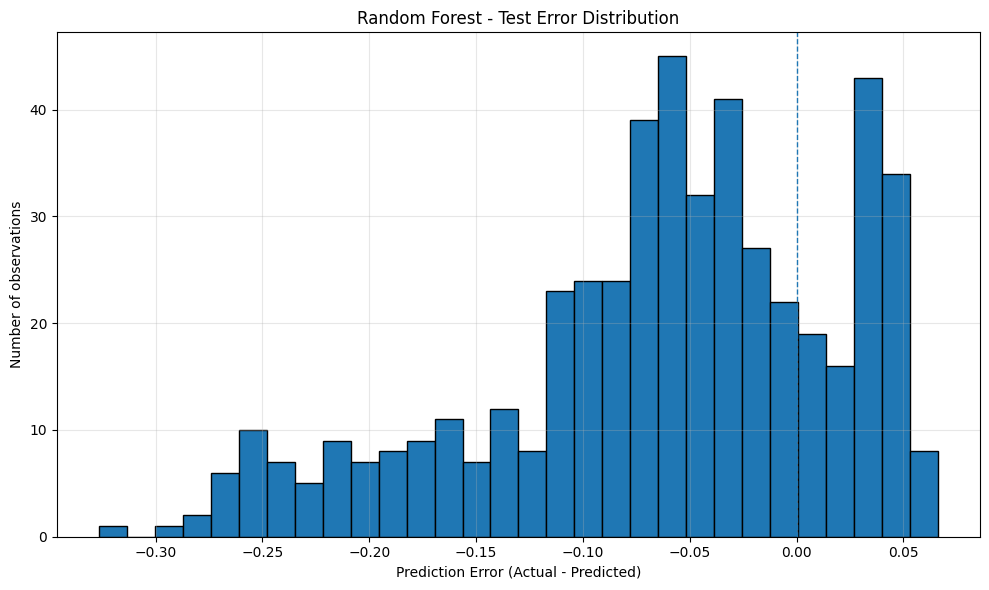


TREE MODEL FEATURE IMPORTANCE

XGBoost


,Feature,Importance
0,voltage_drop,0.213024
1,discharge_duration,0.199749
2,voltage_max,0.178550
3,voltage_initial,0.168645
4,voltage_min,0.055606
5,voltage_std,0.045533
6,load_voltage_min,0.033841
7,load_current_abs_mean,0.027569
8,temperature_initial,0.016447
9,load_voltage_mean,0.013023


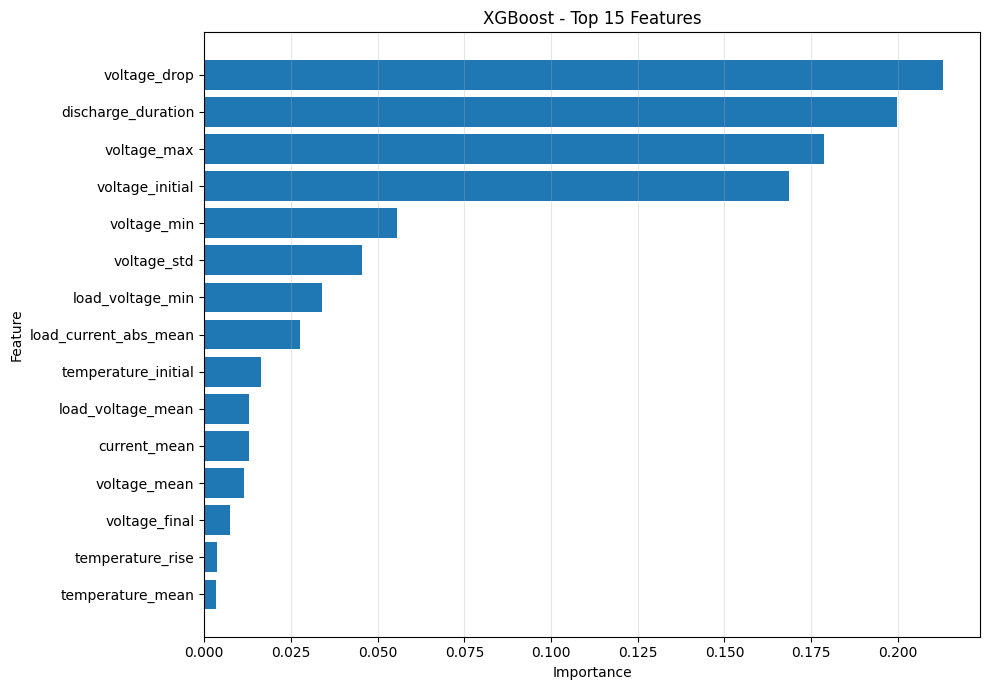


Random Forest


,Feature,Importance
0,temperature_max,0.261255
1,load_voltage_mean,0.257138
2,discharge_duration,0.212813
3,voltage_std,0.066325
4,voltage_drop,0.061303
5,load_voltage_min,0.028652
6,voltage_max,0.024656
7,voltage_initial,0.024273
8,load_current_abs_mean,0.013511
9,voltage_mean,0.011635


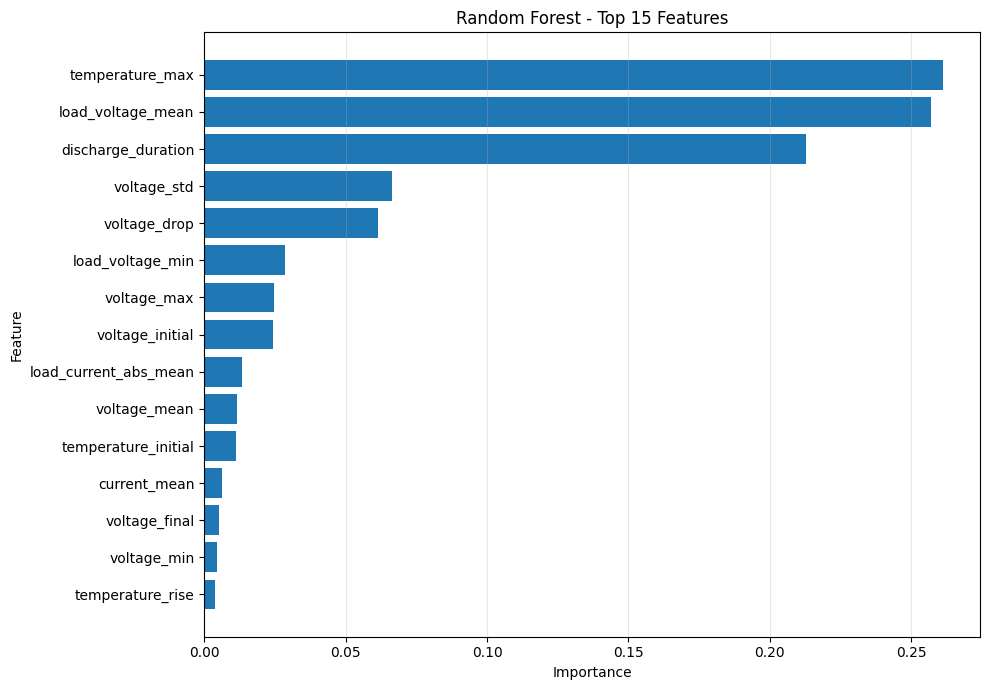


STAGE 3 COMPLETE

Generalized ML dataset: (1740, 28)
Successful feature extractions: 1740
Failed feature extractions: 0
Batteries: 21
Features: 21
Training batteries: 12
Validation batteries: 4
Test batteries: 5

Best initial model: Random Forest

Validation MAE : 0.044678
Validation MSE : 0.003345
Validation RMSE: 0.057838
Validation R²  : 0.961621

Test MAE       : 0.079300
Test MSE       : 0.010881
Test RMSE      : 0.104311
Test R²        : 0.200116

Saved artifacts:
  ✓ battery_c0_reference.csv
  ✓ battery_soh_summary.csv
  ✓ battery_split.json
  ✓ best_initial_model.txt
  ✓ feature_schema.json
  ✓ generalized_ml_dataset.csv
  ✓ initial_model_comparison.csv
  ✓ initial_per_battery_results.csv
  ✓ random_forest_initial.joblib
  ✓ svr_initial.joblib
  ✓ test_dataset.csv
  ✓ train_dataset.csv
  ✓ validation_dataset.csv
  ✓ xgboost_initial.joblib

Output directory:
/kaggle/working/driveguard_x_battery_models

NEXT STAGE:
Hyperparameter tuning + cross-battery robustness testing.
Do not

In [98]:
# ============================================================
# DRIVEGUARD-X
# STAGE 3
#
# COMPLETE GENERALIZED DATASET REBUILD
# + SOH PREPARATION
# + BATTERY-LEVEL SPLIT
# + XGBOOST / RANDOM FOREST / SVR TRAINING
# + EVALUATION
# + FEATURE IMPORTANCE
# + MODEL SAVING
#
# This cell intentionally rebuilds the ML dataset from the
# existing clean_discharge dataframe and the original CSV files.
#
# It does NOT depend on the incomplete generalized_ml_dataset.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import json
import glob
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42


# ------------------------------------------------------------
# Battery groups selected for the first generalized experiment
# ------------------------------------------------------------

GENERALIZED_BATTERIES = [

    "B0005",
    "B0006",
    "B0007",
    "B0018",

    "B0025",
    "B0027",
    "B0028",

    "B0029",
    "B0030",
    "B0031",
    "B0032",

    "B0043",
    "B0044",

    "B0045",
    "B0046",
    "B0047",
    "B0048",

    "B0053",
    "B0054",
    "B0055",
    "B0056"

]


# ------------------------------------------------------------
# Batteries excluded from first generalized experiment
# ------------------------------------------------------------

EXCLUDED_BATTERIES = [

    "B0033",
    "B0034",
    "B0036",
    "B0038",
    "B0039",
    "B0040",
    "B0041",
    "B0042",
    "B0049",
    "B0050",
    "B0051",
    "B0052"

]


# ============================================================
# 2. FEATURE LIST
# ============================================================

FEATURE_COLUMNS = [

    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",

    "current_mean",
    "current_min",
    "current_max",
    "current_std",

    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",

    "load_current_abs_mean",
    "load_current_abs_max",

    "load_voltage_mean",
    "load_voltage_min",

    "discharge_duration"

]

TARGET_COLUMN = "SOH"


# ============================================================
# 3. CHECK CLEAN DISCHARGE DATAFRAME
# ============================================================

print("=" * 100)
print("DRIVEGUARD-X STAGE 3")
print("GENERALIZED BATTERY SOH MODEL")
print("=" * 100)


if "clean_discharge" not in globals():

    raise RuntimeError(
        "clean_discharge does not exist."
        "\nRun the previous dataset-cleaning stage first."
    )


print("\nclean_discharge found.")

print(
    "Shape:",
    clean_discharge.shape
)

print(
    "Columns:",
    list(clean_discharge.columns)
)


# ============================================================
# 4. PREPARE DISCHARGE METADATA
# ============================================================

discharge_metadata = clean_discharge.copy()


# ------------------------------------------------------------
# Convert required metadata fields
# ------------------------------------------------------------

discharge_metadata["battery_id"] = (
    discharge_metadata["battery_id"]
    .astype(str)
    .str.strip()
)

discharge_metadata["Capacity_numeric"] = pd.to_numeric(
    discharge_metadata["Capacity_numeric"],
    errors="coerce"
)

discharge_metadata["test_id_numeric"] = pd.to_numeric(
    discharge_metadata["test_id"],
    errors="coerce"
)


# ------------------------------------------------------------
# Keep only positive capacity measurements
# ------------------------------------------------------------

discharge_metadata = discharge_metadata[
    discharge_metadata["Capacity_numeric"].notna()
].copy()

discharge_metadata = discharge_metadata[
    discharge_metadata["Capacity_numeric"] > 0
].copy()


# ------------------------------------------------------------
# Keep selected generalized batteries
# ------------------------------------------------------------

discharge_metadata = discharge_metadata[
    discharge_metadata["battery_id"].isin(
        GENERALIZED_BATTERIES
    )
].copy()


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

discharge_metadata = discharge_metadata.sort_values(

    [
        "battery_id",
        "test_id_numeric",
        "test_id"
    ]

).reset_index(drop=True)


print("\nSelected discharge experiments:")

print(
    len(discharge_metadata)
)

print(
    "Selected batteries:",
    discharge_metadata["battery_id"].nunique()
)


# ============================================================
# 5. LOCATE ORIGINAL CSV FILES
# ============================================================
#
# We need the raw CSV corresponding to every discharge
# experiment in order to calculate the electrical/thermal/
# temporal features.
#
# Kaggle's input directory can vary slightly between datasets,
# so we search recursively rather than hard-coding one exact
# directory.
# ============================================================

print("\n" + "=" * 100)
print("SEARCHING FOR RAW NASA CSV FILES")
print("=" * 100)


possible_roots = [

    "/kaggle/input",

    "/kaggle/working"

]


csv_files = []


for root in possible_roots:

    if os.path.exists(root):

        found = glob.glob(

            os.path.join(
                root,
                "**",
                "*.csv"
            ),

            recursive=True

        )

        csv_files.extend(
            found
        )


csv_files = sorted(
    list(
        set(
            csv_files
        )
    )
)


print(
    "CSV files found:",
    len(csv_files)
)


# ------------------------------------------------------------
# Build filename lookup
# ------------------------------------------------------------

filename_lookup = {}


for path in csv_files:

    basename = os.path.basename(
        path
    )

    filename_lookup[
        basename
    ] = path


print(
    "Unique CSV filenames indexed:",
    len(filename_lookup)
)


# ============================================================
# 6. RESOLVE CSV PATH FOR EACH EXPERIMENT
# ============================================================

def resolve_csv_path(filename):

    """
    Resolve a metadata filename to an actual CSV path.
    """

    if pd.isna(filename):

        return None


    filename = str(
        filename
    ).strip()


    # --------------------------------------------------------
    # Direct filename lookup
    # --------------------------------------------------------

    if filename in filename_lookup:

        return filename_lookup[
            filename
        ]


    # --------------------------------------------------------
    # Sometimes metadata may contain a relative path.
    # --------------------------------------------------------

    basename = os.path.basename(
        filename
    )

    if basename in filename_lookup:

        return filename_lookup[
            basename
        ]


    # --------------------------------------------------------
    # Final fallback: recursive exact basename search.
    # --------------------------------------------------------

    matches = [

        path
        for path in csv_files

        if os.path.basename(path)
        == basename

    ]


    if matches:

        return matches[0]


    return None


discharge_metadata["csv_path"] = (

    discharge_metadata["filename"]
    .apply(
        resolve_csv_path
    )

)


resolved_count = (
    discharge_metadata[
        "csv_path"
    ]
    .notna()
    .sum()
)


unresolved_count = (

    discharge_metadata[
        "csv_path"
    ]
    .isna()
    .sum()

)


print(
    "\nResolved CSV files:",
    resolved_count
)

print(
    "Unresolved CSV files:",
    unresolved_count
)


if unresolved_count > 0:

    print(
        "\nFirst unresolved filenames:"
    )

    display(

        discharge_metadata[
            discharge_metadata[
                "csv_path"
            ].isna()
        ][
            [
                "battery_id",
                "test_id",
                "filename"
            ]
        ]
        .head(20)

    )


# ============================================================
# 7. FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_discharge_features(
    csv_path
):

    """
    Extract cycle-level discharge features from one NASA
    discharge CSV.

    Returns a dictionary containing the 21 model features.
    """

    # --------------------------------------------------------
    # Read CSV
    # --------------------------------------------------------

    raw = pd.read_csv(
        csv_path
    )


    # --------------------------------------------------------
    # Verify required raw columns
    # --------------------------------------------------------

    required_raw_columns = [

        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Current_load",
        "Voltage_load",
        "Time"

    ]


    missing = [

        column
        for column in required_raw_columns
        if column not in raw.columns

    ]


    if missing:

        raise ValueError(

            "Missing raw columns: "
            +
            str(missing)

        )


    # --------------------------------------------------------
    # Convert everything to numeric
    # --------------------------------------------------------

    for column in required_raw_columns:

        raw[column] = pd.to_numeric(

            raw[column],

            errors="coerce"

        )


    # --------------------------------------------------------
    # Remove invalid rows
    # --------------------------------------------------------

    raw = raw.dropna(

        subset=required_raw_columns

    ).copy()


    if len(raw) < 5:

        raise ValueError(
            "Not enough valid measurements."
        )


    # --------------------------------------------------------
    # Sort by time
    # --------------------------------------------------------

    raw = raw.sort_values(
        "Time"
    ).reset_index(
        drop=True
    )


    # --------------------------------------------------------
    # Detect active discharge region
    #
    # Current_measured is negative during discharge in the
    # NASA representation used here.
    #
    # A small threshold avoids including the initial near-zero
    # measurement region.
    # --------------------------------------------------------

    active_mask = (

        raw[
            "Current_measured"
        ]
        < -0.1

    )


    active = raw[
        active_mask
    ].copy()


    # --------------------------------------------------------
    # Fallback if active detection fails
    # --------------------------------------------------------

    if len(active) < 5:

        active = raw.copy()


    if len(active) < 5:

        raise ValueError(
            "Insufficient active discharge measurements."
        )


    # ========================================================
    # Voltage features
    # ========================================================

    voltage = active[
        "Voltage_measured"
    ]


    voltage_initial = float(
        voltage.iloc[0]
    )

    voltage_final = float(
        voltage.iloc[-1]
    )

    voltage_min = float(
        voltage.min()
    )

    voltage_max = float(
        voltage.max()
    )

    voltage_mean = float(
        voltage.mean()
    )

    voltage_std = float(
        voltage.std(
            ddof=0
        )
    )

    voltage_drop = (

        voltage_initial -
        voltage_final

    )


    # ========================================================
    # Current features
    # ========================================================

    current = active[
        "Current_measured"
    ]


    current_mean = float(
        current.mean()
    )

    current_min = float(
        current.min()
    )

    current_max = float(
        current.max()
    )

    current_std = float(
        current.std(
            ddof=0
        )
    )


    # ========================================================
    # Temperature features
    # ========================================================

    temperature = active[
        "Temperature_measured"
    ]


    temperature_initial = float(
        temperature.iloc[0]
    )

    temperature_final = float(
        temperature.iloc[-1]
    )

    temperature_max = float(
        temperature.max()
    )

    temperature_mean = float(
        temperature.mean()
    )

    temperature_rise = (

        temperature_final -
        temperature_initial

    )


    # ========================================================
    # Load current features
    #
    # IMPORTANT:
    # We use absolute magnitude because the dataset's current
    # sign convention can differ across measurements.
    # ========================================================

    load_current = active[
        "Current_load"
    ]


    load_current_abs = (
        load_current.abs()
    )


    load_current_abs_mean = float(
        load_current_abs.mean()
    )

    load_current_abs_max = float(
        load_current_abs.max()
    )


    # ========================================================
    # Load voltage features
    # ========================================================

    load_voltage = active[
        "Voltage_load"
    ]


    load_voltage_mean = float(
        load_voltage.mean()
    )

    load_voltage_min = float(
        load_voltage.min()
    )


    # ========================================================
    # Time / duration
    # ========================================================

    time_values = active[
        "Time"
    ]


    discharge_duration = float(

        time_values.iloc[-1]
        -
        time_values.iloc[0]

    )


    # ========================================================
    # Return feature dictionary
    # ========================================================

    return {

        "voltage_initial":
            voltage_initial,

        "voltage_final":
            voltage_final,

        "voltage_min":
            voltage_min,

        "voltage_max":
            voltage_max,

        "voltage_mean":
            voltage_mean,

        "voltage_std":
            voltage_std,

        "voltage_drop":
            voltage_drop,


        "current_mean":
            current_mean,

        "current_min":
            current_min,

        "current_max":
            current_max,

        "current_std":
            current_std,


        "temperature_initial":
            temperature_initial,

        "temperature_final":
            temperature_final,

        "temperature_max":
            temperature_max,

        "temperature_mean":
            temperature_mean,

        "temperature_rise":
            temperature_rise,


        "load_current_abs_mean":
            load_current_abs_mean,

        "load_current_abs_max":
            load_current_abs_max,


        "load_voltage_mean":
            load_voltage_mean,

        "load_voltage_min":
            load_voltage_min,


        "discharge_duration":
            discharge_duration

    }


# ============================================================
# 8. EXTRACT FEATURES FROM ALL EXPERIMENTS
# ============================================================

print("\n" + "=" * 100)
print("EXTRACTING FEATURES FROM DISCHARGE CSV FILES")
print("=" * 100)


feature_records = []

failed_records = []


total_files = len(
    discharge_metadata
)


for counter, (
    index,
    row
) in enumerate(

    discharge_metadata.iterrows(),

    start=1

):


    battery = row[
        "battery_id"
    ]

    test_id = row[
        "test_id"
    ]

    filename = row[
        "filename"
    ]

    csv_path = row[
        "csv_path"
    ]


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (

        counter == 1
        or
        counter % 250 == 0
        or
        counter == total_files

    ):

        print(

            f"Processing "
            f"{counter:,}/{total_files:,} "
            f"| Battery {battery}"

        )


    # --------------------------------------------------------
    # Missing file
    # --------------------------------------------------------

    if pd.isna(csv_path):

        failed_records.append({

            "battery_id":
                battery,

            "test_id":
                test_id,

            "filename":
                filename,

            "error":
                "CSV file not found"

        })

        continue


    # --------------------------------------------------------
    # Extract
    # --------------------------------------------------------

    try:

        features = (
            extract_discharge_features(
                csv_path
            )
        )


        record = {

            "battery_id":
                battery,

            "test_id":
                test_id,

            "test_id_numeric":
                row["test_id_numeric"],

            "filename":
                filename,

            "Capacity":
                row[
                    "Capacity_numeric"
                ]

        }


        record.update(
            features
        )


        feature_records.append(
            record
        )


    except Exception as error:

        failed_records.append({

            "battery_id":
                battery,

            "test_id":
                test_id,

            "filename":
                filename,

            "error":
                str(error)

        })


# ============================================================
# 9. BUILD FEATURE DATAFRAME
# ============================================================

feature_df = pd.DataFrame(
    feature_records
)


failed_df = pd.DataFrame(
    failed_records
)


print("\n" + "=" * 100)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 100)


print(
    "Successful experiments:",
    len(feature_df)
)

print(
    "Failed experiments:",
    len(failed_df)
)


if len(failed_df) > 0:

    print(
        "\nFailure summary:"
    )

    display(
        failed_df.head(20)
    )


# ------------------------------------------------------------
# We expect all or nearly all selected experiments to work.
# ------------------------------------------------------------

if len(feature_df) == 0:

    raise RuntimeError(
        "No feature records were successfully extracted."
    )


# ============================================================
# 10. VERIFY FEATURE COLUMNS
# ============================================================

missing_features = [

    feature
    for feature in FEATURE_COLUMNS
    if feature not in feature_df.columns

]


if missing_features:

    raise RuntimeError(

        "The following engineered features are missing:\n"
        +
        "\n".join(
            missing_features
        )

    )


print(
    "\n✓ All 21 engineered features successfully created."
)


# ============================================================
# 11. BUILD GENERALIZED ML DATASET
# ============================================================

generalized_ml_dataset = feature_df.copy()


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

generalized_ml_dataset = (
    generalized_ml_dataset
    .sort_values(
        [
            "battery_id",
            "test_id_numeric",
            "test_id"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 12. BUILD C0 REFERENCES
# ============================================================
#
# Paper batteries:
#
#   C0 = first recorded capacity
#
# This preserves the paper's protocol for these batteries.
#
#
# Generalized batteries:
#
#   C0 = maximum capacity among the first five valid cycles
#
# This protects against an anomalously low first capacity value.
#
# ============================================================

c0_records = []

c0_map = {}


for battery, group in (

    generalized_ml_dataset
    .groupby(
        "battery_id"
    )

):


    group = (
        group
        .sort_values(
            [
                "test_id_numeric",
                "test_id"
            ]
        )
    )


    capacities = (
        group[
            "Capacity"
        ]
        .astype(float)
        .reset_index(
            drop=True
        )
    )


    if len(capacities) == 0:

        continue


    # --------------------------------------------------------
    # Paper-compatible batteries
    # --------------------------------------------------------

    if battery in [

        "B0005",
        "B0006",
        "B0007",
        "B0018"

    ]:

        C0 = float(
            capacities.iloc[0]
        )

        method = (
            "first_capacity"
        )


    # --------------------------------------------------------
    # Generalized batteries
    # --------------------------------------------------------

    else:

        early_n = min(
            5,
            len(capacities)
        )

        early_capacity = (
            capacities.iloc[
                :early_n
            ]
        )

        C0 = float(
            early_capacity.max()
        )

        method = (
            "max_first_five"
        )


    c0_map[
        battery
    ] = C0


    c0_records.append({

        "battery_id":
            battery,

        "C0":
            C0,

        "method":
            method,

        "first_capacity":
            float(
                capacities.iloc[0]
            ),

        "early_max":
            float(
                capacities.iloc[
                    :min(5, len(capacities))
                ].max()
            ),

        "min_capacity":
            float(
                capacities.min()
            ),

        "max_capacity":
            float(
                capacities.max()
            ),

        "cycles":
            len(capacities)

    })


c0_table = (

    pd.DataFrame(
        c0_records
    )

    .sort_values(
        "battery_id"
    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("C0 REFERENCE TABLE")
print("=" * 100)

display(
    c0_table
)


# ============================================================
# 13. CALCULATE SOH
# ============================================================

generalized_ml_dataset["C0"] = (

    generalized_ml_dataset[
        "battery_id"
    ]

    .map(
        c0_map
    )

)


generalized_ml_dataset["SOH"] = (

    generalized_ml_dataset[
        "Capacity"
    ]

    /

    generalized_ml_dataset[
        "C0"
    ]

)


# ============================================================
# 14. SOH QUALITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("SOH QUALITY CHECK")
print("=" * 100)


print(
    "Total records:",
    len(generalized_ml_dataset)
)

print(
    "SOH minimum:",
    generalized_ml_dataset[
        "SOH"
    ].min()
)

print(
    "SOH maximum:",
    generalized_ml_dataset[
        "SOH"
    ].max()
)

print(
    "SOH mean:",
    generalized_ml_dataset[
        "SOH"
    ].mean()
)

print(
    "SOH median:",
    generalized_ml_dataset[
        "SOH"
    ].median()
)

print(
    "SOH > 1.00:",
    (
        generalized_ml_dataset[
            "SOH"
        ]
        >
        1.00
    ).sum()
)

print(
    "SOH > 1.05:",
    (
        generalized_ml_dataset[
            "SOH"
        ]
        >
        1.05
    ).sum()
)

print(
    "SOH > 1.10:",
    (
        generalized_ml_dataset[
            "SOH"
        ]
        >
        1.10
    ).sum()
)

print(
    "SOH <= 0:",
    (
        generalized_ml_dataset[
            "SOH"
        ]
        <=
        0
    ).sum()
)


# ============================================================
# 15. BATTERY SOH SUMMARY
# ============================================================

battery_soh_summary = (

    generalized_ml_dataset

    .groupby(
        "battery_id"
    )["SOH"]

    .agg(

        count="count",

        min="min",

        max="max",

        mean="mean",

        std="std"

    )

    .reset_index()

)


print("\n" + "=" * 100)
print("SOH SUMMARY BY BATTERY")
print("=" * 100)

display(
    battery_soh_summary
)


# ============================================================
# 16. REMOVE CLEARLY ABNORMAL TARGET VALUES
# ============================================================
#
# Do not clip.
#
# Values > 1.10 are removed because they indicate that the
# capacity/reference relationship is not physically reasonable
# for this first supervised-learning experiment.
#
# This keeps the target clean rather than teaching the model
# incorrect labels.
# ============================================================

before_soh_filter = len(
    generalized_ml_dataset
)


generalized_ml_dataset = (

    generalized_ml_dataset[

        generalized_ml_dataset[
            "SOH"
        ].between(
            0,
            1.10
        )

    ]

    .copy()

)


after_soh_filter = len(
    generalized_ml_dataset
)


print("\n" + "=" * 100)
print("SOH FILTER")
print("=" * 100)

print(
    "Before:",
    before_soh_filter
)

print(
    "After:",
    after_soh_filter
)

print(
    "Removed:",
    before_soh_filter -
    after_soh_filter
)


# ============================================================
# 17. FEATURE QUALITY CHECK
# ============================================================

feature_quality_records = []


for feature in FEATURE_COLUMNS:

    series = (
        generalized_ml_dataset[
            feature
        ]
    )


    feature_quality_records.append({

        "Feature":
            feature,

        "Missing":
            int(
                series.isna().sum()
            ),

        "Infinite":
            int(
                np.isinf(
                    series
                ).sum()
            ),

        "Min":
            series.min(),

        "Max":
            series.max(),

        "Mean":
            series.mean(),

        "Std":
            series.std()

    })


feature_quality_df = (
    pd.DataFrame(
        feature_quality_records
    )
)


print("\n" + "=" * 100)
print("FEATURE QUALITY")
print("=" * 100)

display(
    feature_quality_df
)


# ============================================================
# 18. CLEAN MISSING / INFINITE FEATURES
# ============================================================

for feature in FEATURE_COLUMNS:

    generalized_ml_dataset[
        feature
    ] = (

        generalized_ml_dataset[
            feature
        ]

        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )

    )


before_feature_clean = len(
    generalized_ml_dataset
)


generalized_ml_dataset = (

    generalized_ml_dataset

    .dropna(

        subset=
        FEATURE_COLUMNS
        +
        [
            TARGET_COLUMN
        ]

    )

    .copy()

)


after_feature_clean = len(
    generalized_ml_dataset
)


print(
    "\nRows removed due to invalid features:",
    before_feature_clean -
    after_feature_clean
)


# ============================================================
# 19. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL GENERALIZED ML DATASET")
print("=" * 100)

print(
    "Shape:",
    generalized_ml_dataset.shape
)

print(
    "Batteries:",
    generalized_ml_dataset[
        "battery_id"
    ].nunique()
)

print(
    "Features:",
    len(FEATURE_COLUMNS)
)

print(
    "Target:",
    TARGET_COLUMN
)


# ============================================================
# 20. SOH DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(

    generalized_ml_dataset[
        "SOH"
    ],

    bins=30,

    edgecolor="black"

)

plt.xlabel(
    "SOH"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    "DriveGuard-X Generalized Dataset - SOH Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. BATTERY TRAJECTORY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(13, 8)
)


for battery in sorted(

    generalized_ml_dataset[
        "battery_id"
    ].unique()

):


    battery_df = (

        generalized_ml_dataset[
            generalized_ml_dataset[
                "battery_id"
            ]
            ==
            battery
        ]

        .sort_values(
            "test_id_numeric"
        )

    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_df[
            "SOH"
        ],

        marker=".",

        markersize=2,

        linewidth=1,

        label=battery

    )


plt.xlabel(
    "Test ID"
)

plt.ylabel(
    "SOH"
)

plt.title(
    "Generalized Battery SOH Trajectories"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    fontsize=8

)

plt.tight_layout()

plt.show()


# ============================================================
# 22. BATTERY-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
#
# VERY IMPORTANT:
#
# We split entire batteries.
#
# We do NOT randomly split individual cycles.
#
# Therefore, the test batteries are genuinely unseen during
# training.
# ============================================================

available_batteries = sorted(

    generalized_ml_dataset[
        "battery_id"
    ]

    .unique()

)


print("\n" + "=" * 100)
print("BATTERY-LEVEL SPLIT")
print("=" * 100)

print(
    "Available batteries:",
    available_batteries
)


# ------------------------------------------------------------
# 80% development / 20% test
# ------------------------------------------------------------

train_validation_batteries, test_batteries = (

    train_test_split(

        available_batteries,

        test_size=0.20,

        random_state=RANDOM_STATE

    )

)


# ------------------------------------------------------------
# 75% train / 25% validation of development set
# ------------------------------------------------------------

train_batteries, validation_batteries = (

    train_test_split(

        train_validation_batteries,

        test_size=0.25,

        random_state=RANDOM_STATE

    )

)


# ============================================================
# 23. VERIFY BATTERY SPLIT
# ============================================================

assert set(
    train_batteries
).isdisjoint(
    validation_batteries
)

assert set(
    train_batteries
).isdisjoint(
    test_batteries
)

assert set(
    validation_batteries
).isdisjoint(
    test_batteries
)


print(
    "\nTRAIN BATTERIES:"
)

print(
    sorted(
        train_batteries
    )
)


print(
    "\nVALIDATION BATTERIES:"
)

print(
    sorted(
        validation_batteries
    )
)


print(
    "\nTEST BATTERIES:"
)

print(
    sorted(
        test_batteries
    )
)


# ============================================================
# 24. CREATE PARTITIONS
# ============================================================

train_df = (

    generalized_ml_dataset[

        generalized_ml_dataset[
            "battery_id"
        ]

        .isin(
            train_batteries
        )

    ]

    .copy()

)


validation_df = (

    generalized_ml_dataset[

        generalized_ml_dataset[
            "battery_id"
        ]

        .isin(
            validation_batteries
        )

    ]

    .copy()

)


test_df = (

    generalized_ml_dataset[

        generalized_ml_dataset[
            "battery_id"
        ]

        .isin(
            test_batteries
        )

    ]

    .copy()

)


# ============================================================
# 25. PARTITION SUMMARY
# ============================================================

partition_summary = pd.DataFrame({

    "Partition":

        [
            "Train",
            "Validation",
            "Test"
        ],

    "Batteries":

        [
            len(train_batteries),
            len(validation_batteries),
            len(test_batteries)
        ],

    "Rows":

        [
            len(train_df),
            len(validation_df),
            len(test_df)
        ],

    "Mean SOH":

        [
            train_df["SOH"].mean(),
            validation_df["SOH"].mean(),
            test_df["SOH"].mean()
        ],

    "Minimum SOH":

        [
            train_df["SOH"].min(),
            validation_df["SOH"].min(),
            test_df["SOH"].min()
        ],

    "Maximum SOH":

        [
            train_df["SOH"].max(),
            validation_df["SOH"].max(),
            test_df["SOH"].max()
        ]

})


print("\n" + "=" * 100)
print("PARTITION SUMMARY")
print("=" * 100)

display(
    partition_summary
)


# ============================================================
# 26. CREATE MODEL MATRICES
# ============================================================

X_train = (
    train_df[
        FEATURE_COLUMNS
    ]
    .copy()
)

y_train = (
    train_df[
        TARGET_COLUMN
    ]
    .copy()
)


X_validation = (
    validation_df[
        FEATURE_COLUMNS
    ]
    .copy()
)

y_validation = (
    validation_df[
        TARGET_COLUMN
    ]
    .copy()
)


X_test = (
    test_df[
        FEATURE_COLUMNS
    ]
    .copy()
)

y_test = (
    test_df[
        TARGET_COLUMN
    ]
    .copy()
)


print("\n" + "=" * 100)
print("MODEL MATRICES")
print("=" * 100)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_validation:",
    X_validation.shape
)

print(
    "y_validation:",
    y_validation.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)


# ============================================================
# 27. DEFINE MODELS
# ============================================================

models = {

    "XGBoost":

        XGBRegressor(

            objective=
            "reg:squarederror",

            n_estimators=
            500,

            max_depth=
            4,

            learning_rate=
            0.05,

            subsample=
            0.90,

            colsample_bytree=
            0.90,

            reg_alpha=
            0.0,

            reg_lambda=
            1.0,

            random_state=
            RANDOM_STATE,

            n_jobs=
            -1

        ),


    "Random Forest":

        RandomForestRegressor(

            n_estimators=
            400,

            max_depth=
            None,

            min_samples_split=
            2,

            min_samples_leaf=
            1,

            max_features=
            1.0,

            random_state=
            RANDOM_STATE,

            n_jobs=
            -1

        ),


    "SVR":

        Pipeline(

            steps=[

                (
                    "scaler",

                    StandardScaler()

                ),

                (
                    "svr",

                    SVR(

                        kernel=
                        "rbf",

                        C=
                        10.0,

                        epsilon=
                        0.01,

                        gamma=
                        "scale"

                    )

                )

            ]

        )

}


# ============================================================
# 28. TRAIN MODELS
# ============================================================

trained_models = {}

validation_predictions = {}

test_predictions = {}

model_results = []


print("\n" + "=" * 100)
print("MODEL TRAINING")
print("=" * 100)


for model_name, model in models.items():

    print(
        "\n" + "-" * 70
    )

    print(
        f"Training {model_name}..."
    )

    print(
        "-" * 70
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_train,

        y_train

    )


    trained_models[
        model_name
    ] = model


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    validation_pred = (
        model.predict(
            X_validation
        )
    )


    validation_predictions[
        model_name
    ] = validation_pred


    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    test_pred = (
        model.predict(
            X_test
        )
    )


    test_predictions[
        model_name
    ] = test_pred


    # --------------------------------------------------------
    # Validation metrics
    # --------------------------------------------------------

    val_mae = (
        mean_absolute_error(
            y_validation,
            validation_pred
        )
    )


    val_mse = (
        mean_squared_error(
            y_validation,
            validation_pred
        )
    )


    val_rmse = (
        np.sqrt(
            val_mse
        )
    )


    val_r2 = (
        r2_score(
            y_validation,
            validation_pred
        )
    )


    # --------------------------------------------------------
    # Test metrics
    # --------------------------------------------------------

    test_mae = (
        mean_absolute_error(
            y_test,
            test_pred
        )
    )


    test_mse = (
        mean_squared_error(
            y_test,
            test_pred
        )
    )


    test_rmse = (
        np.sqrt(
            test_mse
        )
    )


    test_r2 = (
        r2_score(
            y_test,
            test_pred
        )
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    model_results.append({

        "Model":
            model_name,

        "Validation MAE":
            val_mae,

        "Validation MSE":
            val_mse,

        "Validation RMSE":
            val_rmse,

        "Validation R2":
            val_r2,

        "Test MAE":
            test_mae,

        "Test MSE":
            test_mse,

        "Test RMSE":
            test_rmse,

        "Test R2":
            test_r2

    })


    print(
        f"Validation MAE : {val_mae:.6f}"
    )

    print(
        f"Validation RMSE: {val_rmse:.6f}"
    )

    print(
        f"Validation R²  : {val_r2:.6f}"
    )

    print(
        f"Test MAE       : {test_mae:.6f}"
    )

    print(
        f"Test RMSE      : {test_rmse:.6f}"
    )

    print(
        f"Test R²        : {test_r2:.6f}"
    )


# ============================================================
# 29. MODEL COMPARISON
# ============================================================

model_results_df = (

    pd.DataFrame(
        model_results
    )

    .sort_values(
        "Validation MAE"
    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("INITIAL MODEL COMPARISON")
print("=" * 100)

display(
    model_results_df
)


# ============================================================
# 30. SELECT BEST INITIAL MODEL
# ============================================================

best_model_name = (

    model_results_df
    .iloc[0]
    ["Model"]

)


best_model = (
    trained_models[
        best_model_name
    ]
)


best_test_predictions = (
    test_predictions[
        best_model_name
    ]
)


print(
    "\nBest initial model:",
    best_model_name
)


# ============================================================
# 31. PER-BATTERY TEST PERFORMANCE
# ============================================================

per_battery_results = []


for battery in sorted(

    test_df[
        "battery_id"
    ]
    .unique()

):


    battery_mask = (

        test_df[
            "battery_id"
        ]
        ==
        battery

    )


    actual = (
        y_test[
            battery_mask
        ]
    )


    for model_name in models.keys():

        predictions = (
            test_predictions[
                model_name
            ]
        )


        battery_predictions = (

            predictions[
                battery_mask.values
            ]

        )


        battery_mae = (

            mean_absolute_error(

                actual,

                battery_predictions

            )

        )


        battery_mse = (

            mean_squared_error(

                actual,

                battery_predictions

            )

        )


        battery_rmse = (

            np.sqrt(
                battery_mse
            )

        )


        battery_r2 = (

            r2_score(

                actual,

                battery_predictions

            )

            if len(actual) > 1

            else np.nan

        )


        per_battery_results.append({

            "Battery":
                battery,

            "Model":
                model_name,

            "MAE":
                battery_mae,

            "MSE":
                battery_mse,

            "RMSE":
                battery_rmse,

            "R2":
                battery_r2,

            "Samples":
                len(actual)

        })


per_battery_results_df = (

    pd.DataFrame(
        per_battery_results
    )

    .sort_values(
        [
            "Battery",
            "MAE"
        ]
    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("PER-BATTERY TEST RESULTS")
print("=" * 100)

display(
    per_battery_results_df
)


# ============================================================
# 32. ACTUAL VS PREDICTED FOR BEST MODEL
# ============================================================

print("\n" + "=" * 100)
print(
    f"ACTUAL VS PREDICTED: {best_model_name}"
)
print("=" * 100)


for battery in sorted(

    test_df[
        "battery_id"
    ].unique()

):


    battery_df = (

        test_df[
            test_df[
                "battery_id"
            ]
            ==
            battery
        ]

        .sort_values(
            "test_id_numeric"
        )

        .copy()

    )


    battery_X = (

        battery_df[
            FEATURE_COLUMNS
        ]

    )


    battery_prediction = (

        best_model
        .predict(
            battery_X
        )

    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_df[
            "SOH"
        ],

        marker=".",

        markersize=3,

        label="Actual SOH"

    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_prediction,

        marker=".",

        markersize=3,

        linestyle="--",

        label=
        f"{best_model_name} Prediction"

    )


    plt.xlabel(
        "Test ID"
    )

    plt.ylabel(
        "SOH"
    )

    plt.title(
        f"{battery} | Actual vs Predicted SOH"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 33. ERROR DISTRIBUTION
# ============================================================

best_errors = (

    y_test.values
    -
    best_test_predictions

)


plt.figure(
    figsize=(10, 6)
)


plt.hist(

    best_errors,

    bins=30,

    edgecolor="black"

)


plt.axvline(

    0,

    linestyle="--",

    linewidth=1

)


plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    f"{best_model_name} - Test Error Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 34. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 100)
print("TREE MODEL FEATURE IMPORTANCE")
print("=" * 100)


tree_feature_importance = {}


for model_name in [

    "XGBoost",
    "Random Forest"

]:


    model = (
        trained_models[
            model_name
        ]
    )


    importance_df = (

        pd.DataFrame({

            "Feature":
                FEATURE_COLUMNS,

            "Importance":
                model.feature_importances_

        })

        .sort_values(

            "Importance",

            ascending=False

        )

        .reset_index(
            drop=True
        )

    )


    tree_feature_importance[
        model_name
    ] = importance_df


    print(
        f"\n{model_name}"
    )

    display(
        importance_df.head(15)
    )


    top_features = (

        importance_df

        .head(15)

        .sort_values(
            "Importance"
        )

    )


    plt.figure(
        figsize=(10, 7)
    )


    plt.barh(

        top_features[
            "Feature"
        ],

        top_features[
            "Importance"
        ]

    )


    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"{model_name} - Top 15 Features"
    )

    plt.grid(

        True,

        axis="x",

        alpha=0.3

    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 35. CREATE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (

    "/kaggle/working/"
    "driveguard_x_battery_models"

)


os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)


# ============================================================
# 36. SAVE GENERALIZED DATASET
# ============================================================

generalized_dataset_path = os.path.join(

    OUTPUT_DIR,

    "generalized_ml_dataset.csv"

)


generalized_ml_dataset.to_csv(

    generalized_dataset_path,

    index=False

)


# ============================================================
# 37. SAVE TRAIN / VALIDATION / TEST DATASETS
# ============================================================

train_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "train_dataset.csv"
    ),

    index=False

)


validation_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "validation_dataset.csv"
    ),

    index=False

)


test_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "test_dataset.csv"
    ),

    index=False

)


# ============================================================
# 38. SAVE FAILED FEATURE EXTRACTIONS
# ============================================================

if len(failed_df) > 0:

    failed_df.to_csv(

        os.path.join(

            OUTPUT_DIR,

            "failed_feature_extractions.csv"

        ),

        index=False

    )


# ============================================================
# 39. SAVE C0 TABLE
# ============================================================

c0_table.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "battery_c0_reference.csv"

    ),

    index=False

)


# ============================================================
# 40. SAVE SOH SUMMARY
# ============================================================

battery_soh_summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "battery_soh_summary.csv"

    ),

    index=False

)


# ============================================================
# 41. SAVE MODEL COMPARISON
# ============================================================

model_results_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "initial_model_comparison.csv"

    ),

    index=False

)


# ============================================================
# 42. SAVE PER-BATTERY RESULTS
# ============================================================

per_battery_results_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "initial_per_battery_results.csv"

    ),

    index=False

)


# ============================================================
# 43. SAVE TRAINED MODELS
# ============================================================

for model_name, model in (

    trained_models.items()

):


    safe_name = (

        model_name
        .lower()
        .replace(
            " ",
            "_"
        )

    )


    model_path = os.path.join(

        OUTPUT_DIR,

        f"{safe_name}_initial.joblib"

    )


    joblib.dump(

        model,

        model_path

    )


# ============================================================
# 44. SAVE FEATURE SCHEMA
# ============================================================

feature_schema = {

    "features":
        FEATURE_COLUMNS,

    "target":
        TARGET_COLUMN,

    "random_state":
        RANDOM_STATE,

    "selected_batteries":
        GENERALIZED_BATTERIES,

    "excluded_batteries":
        EXCLUDED_BATTERIES,

    "paper_batteries":
        [
            "B0005",
            "B0006",
            "B0007",
            "B0018"
        ],

    "paper_C0_method":
        "first recorded capacity",

    "generalized_C0_method":
        "maximum capacity within first five valid observations",

    "SOH_filter":
        "0 <= SOH <= 1.10",

    "split":
        "battery-level",

    "model_selection":
        "validation MAE"

}


with open(

    os.path.join(

        OUTPUT_DIR,

        "feature_schema.json"

    ),

    "w"

) as file:

    json.dump(

        feature_schema,

        file,

        indent=4

    )


# ============================================================
# 45. SAVE BATTERY SPLIT
# ============================================================

battery_split = {

    "train":
        sorted(
            train_batteries
        ),

    "validation":
        sorted(
            validation_batteries
        ),

    "test":
        sorted(
            test_batteries
        )

}


with open(

    os.path.join(

        OUTPUT_DIR,

        "battery_split.json"

    ),

    "w"

) as file:

    json.dump(

        battery_split,

        file,

        indent=4

    )


# ============================================================
# 46. SAVE BEST MODEL NAME
# ============================================================

with open(

    os.path.join(

        OUTPUT_DIR,

        "best_initial_model.txt"

    ),

    "w"

) as file:

    file.write(
        best_model_name
    )


# ============================================================
# 47. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("STAGE 3 COMPLETE")
print("=" * 100)


print(
    "\nGeneralized ML dataset:",
    generalized_ml_dataset.shape
)


print(
    "Successful feature extractions:",
    len(feature_df)
)


print(
    "Failed feature extractions:",
    len(failed_df)
)


print(
    "Batteries:",
    generalized_ml_dataset[
        "battery_id"
    ].nunique()
)


print(
    "Features:",
    len(FEATURE_COLUMNS)
)


print(
    "Training batteries:",
    len(train_batteries)
)


print(
    "Validation batteries:",
    len(validation_batteries)
)


print(
    "Test batteries:",
    len(test_batteries)
)


print(
    "\nBest initial model:",
    best_model_name
)


best_result = (

    model_results_df[

        model_results_df[
            "Model"
        ]

        ==
        best_model_name

    ]

    .iloc[0]

)


print(
    "\nValidation MAE :",
    f"{best_result['Validation MAE']:.6f}"
)


print(
    "Validation MSE :",
    f"{best_result['Validation MSE']:.6f}"
)


print(
    "Validation RMSE:",
    f"{best_result['Validation RMSE']:.6f}"
)


print(
    "Validation R²  :",
    f"{best_result['Validation R2']:.6f}"
)


print(
    "\nTest MAE       :",
    f"{best_result['Test MAE']:.6f}"
)


print(
    "Test MSE       :",
    f"{best_result['Test MSE']:.6f}"
)


print(
    "Test RMSE      :",
    f"{best_result['Test RMSE']:.6f}"
)


print(
    "Test R²        :",
    f"{best_result['Test R2']:.6f}"
)


# ============================================================
# 48. LIST OUTPUT FILES
# ============================================================

print(
    "\nSaved artifacts:"
)


for filename in sorted(

    os.listdir(
        OUTPUT_DIR
    )

):

    print(
        "  ✓",
        filename
    )


print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


print("\n" + "=" * 100)

print(
    "NEXT STAGE:"
)

print(
    "Hyperparameter tuning + cross-battery robustness testing."
)

print(
    "Do not freeze this model as the final DriveGuard-X model yet."
)

print("=" * 100)

# Stage 3B: Generalized Dataset Robustness Experiment

The first generalized experiment used 21 battery groups and produced the following initial test results:

- Random Forest: MAE = 0.0793, R² = 0.2001
- XGBoost: MAE = 0.0886, R² = -0.1411
- SVR: MAE = 0.0437, R² = 0.7681

The validation and test results showed substantial cross-battery generalization differences.

The investigation also identified B0043 and B0044 as problematic because their capacity trajectories contain extremely low capacity measurements around 0.05 Ah despite reference capacities around 1.7 Ah. This creates SOH values around 0.03, which are not representative of a normal degradation trajectory.

Therefore, this experiment removes B0043 and B0044 from the generalized training pool.

No model hyperparameter tuning is performed yet.

The purpose of this experiment is to answer one question:

> Does removing the clearly problematic B0043/B0044 trajectories improve cross-battery generalization?

The previous feature extraction has already been completed successfully, so the existing `feature_df` is reused. This avoids rereading thousands of raw CSV files.

## Battery pool

The experiment uses 19 batteries:

B0005, B0006, B0007, B0018,
B0025, B0027, B0028,
B0029, B0030, B0031, B0032,
B0045, B0046, B0047, B0048,
B0053, B0054, B0055, B0056

B0043 and B0044 are excluded for this experiment.

The other previously identified problematic batteries remain excluded.

## Important methodological rule

This is still a battery-level generalization experiment.

Entire batteries are assigned to training, validation, or testing.

Individual cycles from the same battery are never distributed across different partitions.

The model will be selected using validation performance, while the final test set remains unseen during model selection.

The results from this experiment will be compared directly with Stage 3 before any hyperparameter tuning is performed.

DRIVEGUARD-X STAGE 3B
19-BATTERY ROBUSTNESS EXPERIMENT

✓ feature_df found
Original feature_df shape: (1740, 26)

✓ All required feature and metadata columns exist.

Selected batteries: 19
Selected rows: 1518

C0 REFERENCES


,battery_id,C0,method,first_capacity,first_five_max,min_capacity,max_capacity,cycles
0,B0005,1.856487,first_capacity,1.856487,1.856487,1.287453,1.856487,168
1,B0006,2.035338,first_capacity,2.035338,2.035338,1.153818,2.035338,168
2,B0007,1.891052,first_capacity,1.891052,1.891052,1.400455,1.891052,168
3,B0018,1.855005,first_capacity,1.855005,1.855005,1.341051,1.855005,132
4,B0025,1.848984,max_first_five,1.847011,1.848984,1.767789,1.848984,28
5,B0027,1.823308,max_first_five,1.823308,1.823308,1.770093,1.823308,28
6,B0028,1.804783,max_first_five,1.804685,1.804783,1.717234,1.804783,28
7,B0029,1.844701,max_first_five,1.697507,1.844701,1.612080,1.844701,40
8,B0030,1.781555,max_first_five,1.656071,1.781555,1.562780,1.781555,40
9,B0031,1.832858,max_first_five,1.666675,1.832858,1.666675,1.832858,40



SOH QUALITY CHECK
Records: 1518
Minimum SOH: 0.5609604245132347
Maximum SOH: 1.0
Mean SOH: 0.834931797690397
Median SOH: 0.8405308276150422
SOH > 1.00: 0
SOH > 1.05: 0
SOH > 1.10: 0
SOH <= 0: 0

SOH SUMMARY BY BATTERY


,battery_id,count,min,max,mean,std
0,B0005,168,0.693488,1.0,0.847031,0.102566
1,B0006,168,0.566893,1.0,0.759997,0.123831
2,B0007,168,0.740569,1.0,0.869580,0.085112
3,B0018,132,0.722937,1.0,0.839729,0.083496
4,B0025,28,0.956087,1.0,0.982438,0.012055
5,B0027,28,0.970814,1.0,0.989896,0.007087
6,B0028,28,0.951490,1.0,0.980760,0.012812
7,B0029,40,0.873898,1.0,0.935660,0.034723
8,B0030,40,0.877200,1.0,0.932359,0.034206
9,B0031,40,0.909331,1.0,0.951077,0.024590



Removed target anomalies: 0
Rows removed because of invalid features: 0

FINAL 19-BATTERY DATASET
Shape: (1518, 28)
Batteries: 19


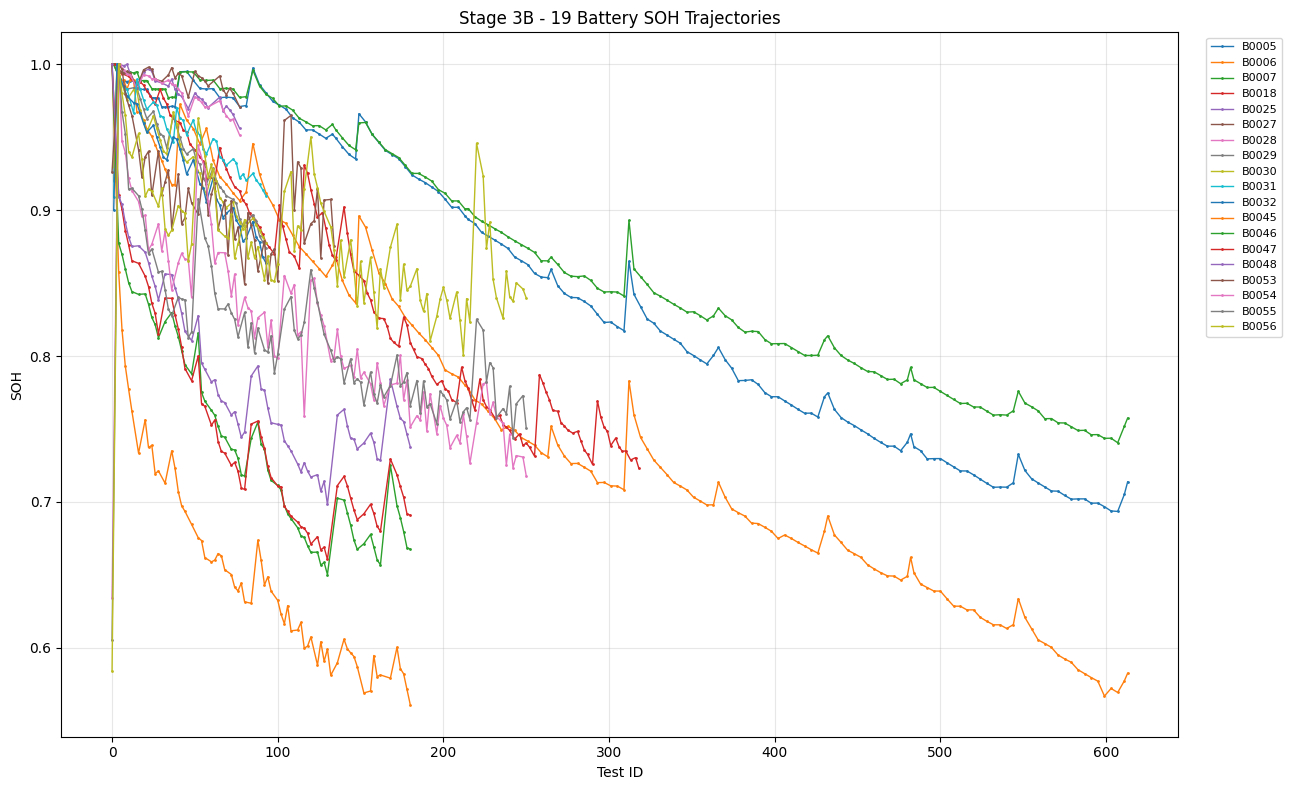


FIXED BATTERY SPLIT

Training batteries:
['B0007', 'B0018', 'B0025', 'B0028', 'B0029', 'B0031', 'B0032', 'B0046', 'B0048', 'B0054', 'B0056']

Validation batteries:
['B0027', 'B0045', 'B0055']

Test batteries:
['B0005', 'B0006', 'B0030', 'B0047', 'B0053']


,Partition,Batteries,Rows,Mean SOH,Minimum SOH,Maximum SOH
0,Train,11,818,0.858219,0.584130,1.0
1,Validation,3,200,0.781753,0.560960,1.0
2,Test,5,500,0.818106,0.566893,1.0



MODEL MATRIX SHAPES
X_train: (818, 21)
X_validation: (200, 21)
X_test: (500, 21)

STAGE 3B MODEL TRAINING

----------------------------------------------------------------------
Training XGBoost...
----------------------------------------------------------------------
Validation MAE : 0.044293
Validation RMSE: 0.060049
Validation R²  : 0.770043
Test MAE       : 0.078641
Test RMSE      : 0.099542
Test R²        : 0.271584

----------------------------------------------------------------------
Training Random Forest...
----------------------------------------------------------------------
Validation MAE : 0.041889
Validation RMSE: 0.059092
Validation R²  : 0.777316
Test MAE       : 0.077602
Test RMSE      : 0.103034
Test R²        : 0.219579

----------------------------------------------------------------------
Training SVR...
----------------------------------------------------------------------
Validation MAE : 0.060589
Validation RMSE: 0.080403
Validation R²  : 0.587728
Test MAE    

,Model,Validation MAE,Validation MSE,Validation RMSE,Validation R2,Test MAE,Test MSE,Test RMSE,Test R2
0,Random Forest,0.041889,0.003492,0.059092,0.777316,0.077602,0.010616,0.103034,0.219579
1,XGBoost,0.044293,0.003606,0.060049,0.770043,0.078641,0.009909,0.099542,0.271584
2,SVR,0.060589,0.006465,0.080403,0.587728,0.041821,0.002736,0.052306,0.798869



STAGE 3B PER-BATTERY TEST PERFORMANCE


,Battery,Model,MAE,MSE,RMSE,R2,Samples
0,B0005,SVR,0.017499,0.000426,0.020642,0.959252,168
1,B0005,Random Forest,0.052401,0.004331,0.065807,0.585872,168
2,B0005,XGBoost,0.054430,0.004580,0.067676,0.562020,168
3,B0006,SVR,0.078871,0.006281,0.079250,0.587962,168
4,B0006,XGBoost,0.128033,0.020979,0.144842,-0.376338,168
5,B0006,Random Forest,0.138308,0.025098,0.158425,-0.646564,168
6,B0030,SVR,0.019228,0.000575,0.023989,0.495551,40
7,B0030,XGBoost,0.024815,0.000716,0.026751,0.372718,40
8,B0030,Random Forest,0.034561,0.001410,0.037544,-0.235589,40
9,B0047,SVR,0.008677,0.000112,0.010570,0.978714,69



Best model based on validation MAE: Random Forest


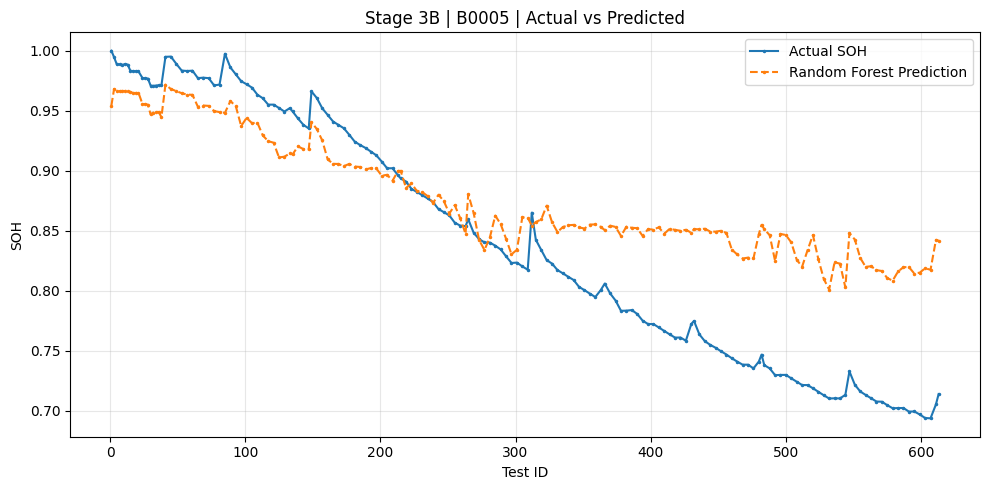

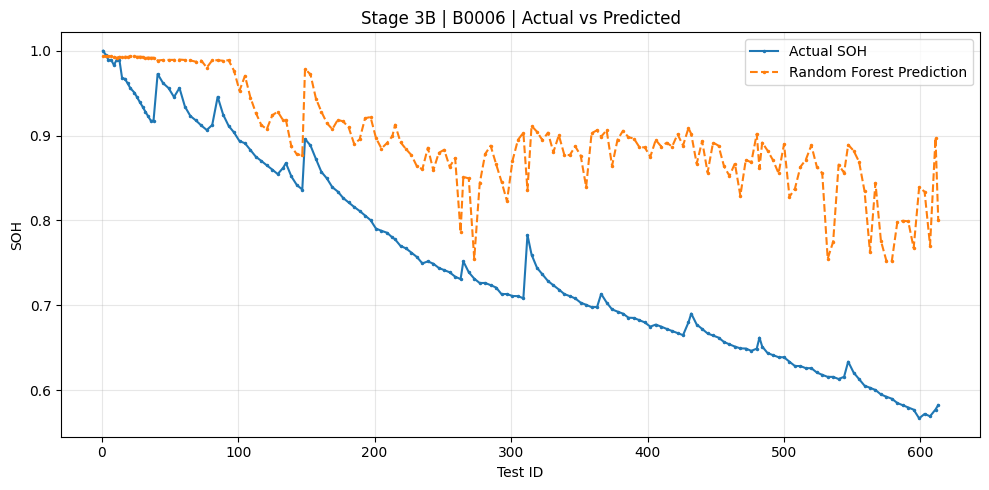

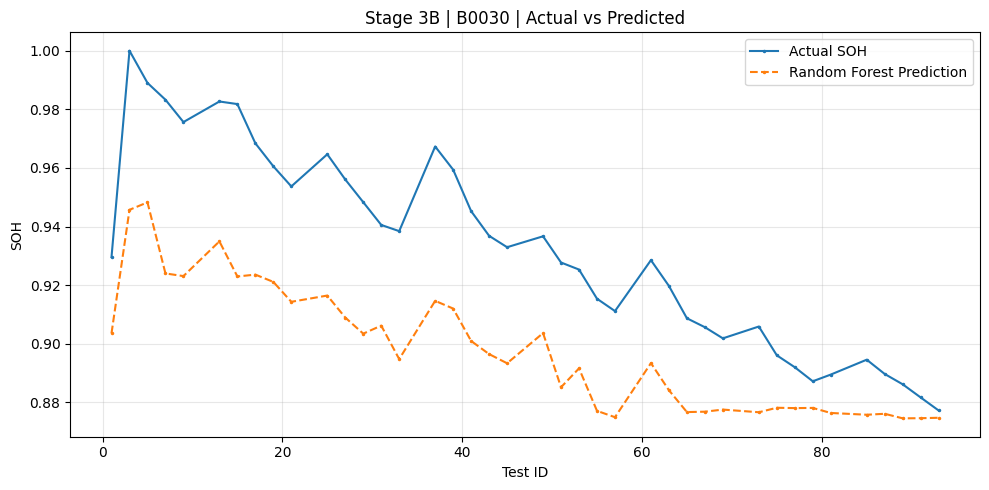

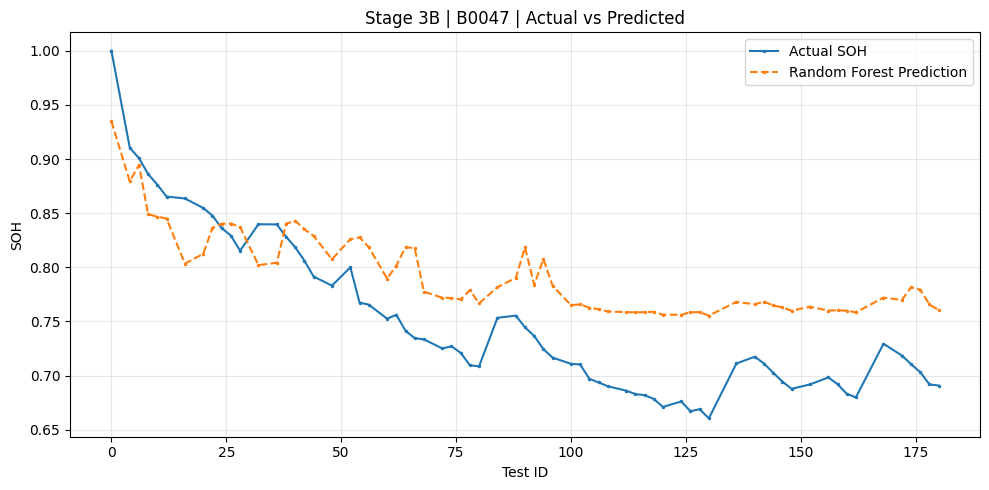

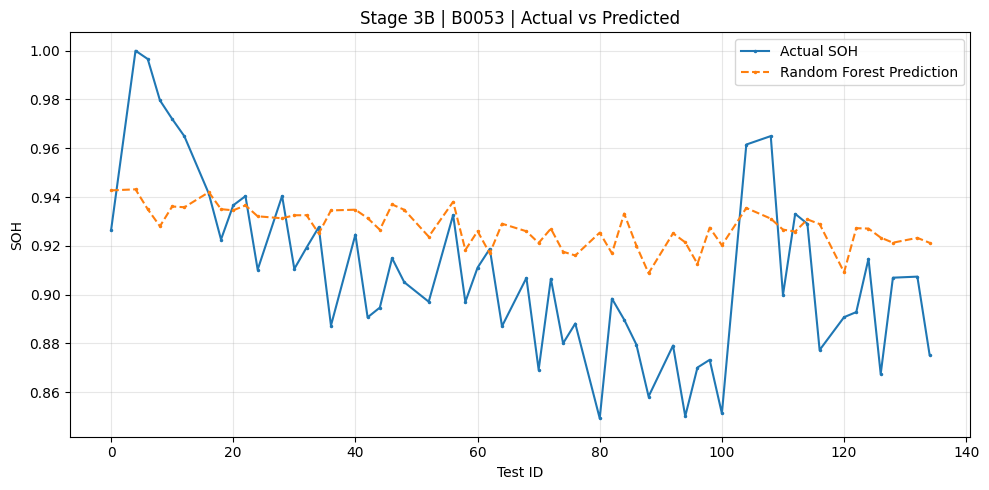

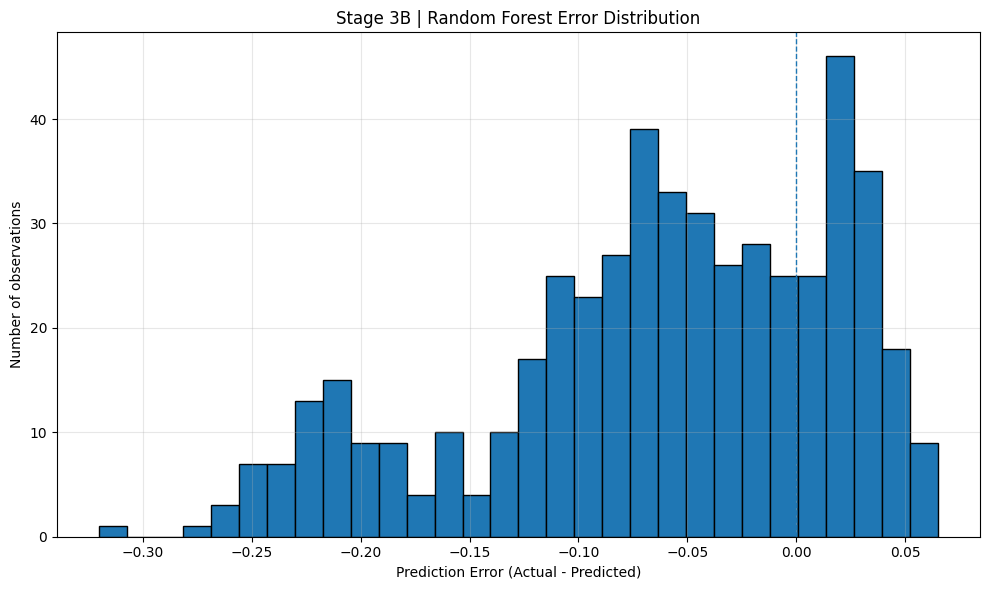


STAGE 3 VS STAGE 3B


,Model,Stage 3 Test MAE,Stage 3 Test MSE,Stage 3 Test RMSE,Stage 3 Test R2,Test MAE,Test MSE,Test RMSE,Test R2,MAE Improvement %,MSE Improvement %
0,Random Forest,0.079300,0.010881,0.104311,0.200116,0.077602,0.010616,0.103034,0.219579,2.141203,2.435985
1,XGBoost,0.088606,0.015522,0.124588,-0.141103,0.078641,0.009909,0.099542,0.271584,11.246060,36.164567
2,SVR,0.043720,0.003155,0.056166,0.768095,0.041821,0.002736,0.052306,0.798869,4.342531,13.281771


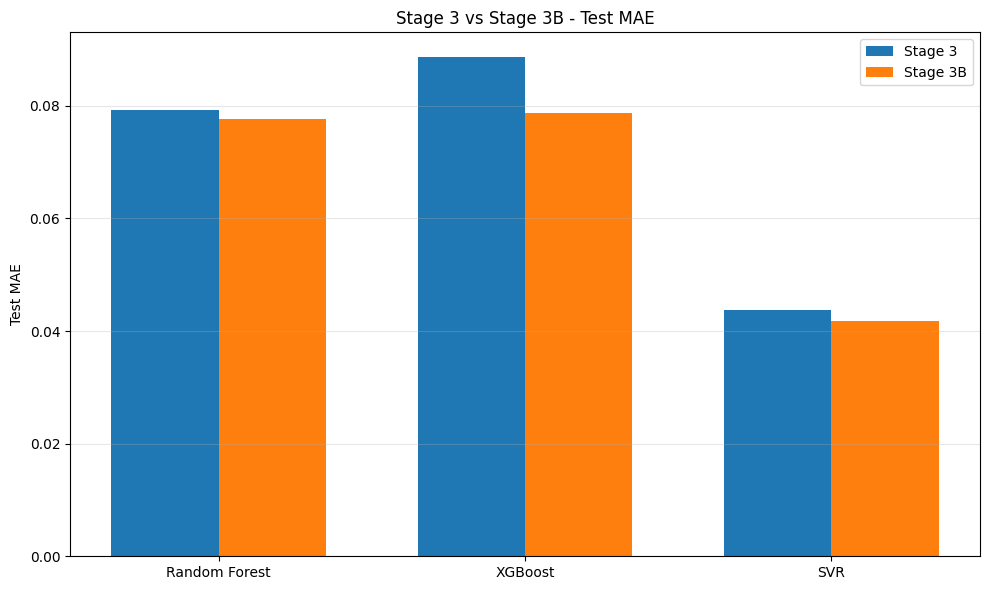


STAGE 3B COMPLETE

Dataset: (1518, 28)
Batteries: 19

Best model: Random Forest

Validation MAE: 0.041889
Validation R²: 0.777316

Test MAE: 0.077602
Test RMSE: 0.103034
Test R²: 0.219579

Stage 3B output directory:
/kaggle/working/driveguard_x_battery_models/stage_3b

Do NOT tune the model yet.
First compare Stage 3 and Stage 3B.


In [99]:
# ============================================================
# DRIVEGUARD-X
# STAGE 3B
#
# ROBUSTNESS EXPERIMENT
#
# PURPOSE:
# Remove B0043 and B0044 and determine whether the
# generalized SOH model becomes more robust.
#
# IMPORTANT:
# We reuse `feature_df` from Stage 3.
# Therefore, NO raw CSV files need to be processed again.
# ============================================================


import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42


# ------------------------------------------------------------
# New 19-battery generalized pool
# ------------------------------------------------------------

GENERALIZED_BATTERIES_19 = [

    "B0005",
    "B0006",
    "B0007",
    "B0018",

    "B0025",
    "B0027",
    "B0028",

    "B0029",
    "B0030",
    "B0031",
    "B0032",

    "B0045",
    "B0046",
    "B0047",
    "B0048",

    "B0053",
    "B0054",
    "B0055",
    "B0056"

]


# ------------------------------------------------------------
# Batteries removed in this experiment
# ------------------------------------------------------------

REMOVED_IN_3B = [

    "B0043",
    "B0044"

]


# ------------------------------------------------------------
# Previously excluded batteries
# ------------------------------------------------------------

PREVIOUSLY_EXCLUDED = [

    "B0033",
    "B0034",
    "B0036",
    "B0038",
    "B0039",
    "B0040",
    "B0041",
    "B0042",
    "B0049",
    "B0050",
    "B0051",
    "B0052"

]


# ============================================================
# 2. FEATURE DEFINITIONS
# ============================================================

FEATURE_COLUMNS = [

    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",

    "current_mean",
    "current_min",
    "current_max",
    "current_std",

    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",

    "load_current_abs_mean",
    "load_current_abs_max",

    "load_voltage_mean",
    "load_voltage_min",

    "discharge_duration"

]

TARGET_COLUMN = "SOH"


# ============================================================
# 3. VERIFY FEATURE DATAFRAME
# ============================================================

print("=" * 100)
print("DRIVEGUARD-X STAGE 3B")
print("19-BATTERY ROBUSTNESS EXPERIMENT")
print("=" * 100)


if "feature_df" not in globals():

    raise RuntimeError(

        "feature_df was not found.\n\n"

        "Run the previous Stage 3 feature-extraction cell "
        "before executing this cell."

    )


print(
    "\n✓ feature_df found"
)

print(
    "Original feature_df shape:",
    feature_df.shape
)


# ============================================================
# 4. COPY FEATURE DATA
# ============================================================

df = feature_df.copy()


# ============================================================
# 5. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = (

    FEATURE_COLUMNS

    +

    [

        "battery_id",
        "test_id",
        "Capacity"

    ]

)


missing_columns = [

    column

    for column in required_columns

    if column not in df.columns

]


if missing_columns:

    raise RuntimeError(

        "Missing required columns:\n"

        +
        "\n".join(
            missing_columns
        )

    )


print(
    "\n✓ All required feature and metadata columns exist."
)


# ============================================================
# 6. CLEAN DATA TYPES
# ============================================================

df["battery_id"] = (

    df["battery_id"]

    .astype(str)

    .str.strip()

)


df["Capacity"] = pd.to_numeric(

    df["Capacity"],

    errors="coerce"

)


df["test_id_numeric"] = pd.to_numeric(

    df["test_id"],

    errors="coerce"

)


for feature in FEATURE_COLUMNS:

    df[feature] = pd.to_numeric(

        df[feature],

        errors="coerce"

    )


# ============================================================
# 7. SELECT 19 BATTERIES
# ============================================================

df = df[

    df["battery_id"]

    .isin(
        GENERALIZED_BATTERIES_19
    )

].copy()


print(
    "\nSelected batteries:",
    df["battery_id"].nunique()
)

print(
    "Selected rows:",
    len(df)
)


# ============================================================
# 8. REMOVE INVALID CAPACITY
# ============================================================

df = df[

    df["Capacity"].notna()

].copy()


df = df[

    df["Capacity"] > 0

].copy()


# ============================================================
# 9. SORT BATTERY TRAJECTORIES
# ============================================================

df = (

    df

    .sort_values(

        [

            "battery_id",

            "test_id_numeric",

            "test_id"

        ]

    )

    .reset_index(
        drop=True
    )

)


# ============================================================
# 10. BUILD C0
# ============================================================
#
# Paper batteries:
#
# B0005
# B0006
# B0007
# B0018
#
# continue using the first recorded capacity.
#
# Other batteries:
#
# C0 = maximum capacity during first five valid cycles.
#
# ============================================================

c0_map = {}

c0_records = []


for battery, group in (

    df.groupby(
        "battery_id"
    )

):


    group = (

        group

        .sort_values(
            "test_id_numeric"
        )

    )


    capacities = (

        group[
            "Capacity"
        ]

        .astype(float)

        .reset_index(
            drop=True
        )

    )


    if len(capacities) == 0:

        continue


    if battery in [

        "B0005",
        "B0006",
        "B0007",
        "B0018"

    ]:

        C0 = float(

            capacities.iloc[0]

        )

        method = (
            "first_capacity"
        )


    else:

        first_five = (

            capacities

            .iloc[
                :min(
                    5,
                    len(capacities)
                )
            ]

        )


        C0 = float(
            first_five.max()
        )

        method = (
            "max_first_five"
        )


    c0_map[
        battery
    ] = C0


    c0_records.append({

        "battery_id":
            battery,

        "C0":
            C0,

        "method":
            method,

        "first_capacity":
            float(
                capacities.iloc[0]
            ),

        "first_five_max":
            float(
                capacities.iloc[
                    :min(
                        5,
                        len(capacities)
                    )
                ].max()
            ),

        "min_capacity":
            float(
                capacities.min()
            ),

        "max_capacity":
            float(
                capacities.max()
            ),

        "cycles":
            len(capacities)

    })


c0_table_3b = (

    pd.DataFrame(
        c0_records
    )

    .sort_values(
        "battery_id"
    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("C0 REFERENCES")
print("=" * 100)

display(
    c0_table_3b
)


# ============================================================
# 11. CALCULATE SOH
# ============================================================

df["C0"] = (

    df["battery_id"]

    .map(
        c0_map
    )

)


df["SOH"] = (

    df["Capacity"]

    /

    df["C0"]

)


# ============================================================
# 12. SOH QUALITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("SOH QUALITY CHECK")
print("=" * 100)


print(
    "Records:",
    len(df)
)

print(
    "Minimum SOH:",
    df["SOH"].min()
)

print(
    "Maximum SOH:",
    df["SOH"].max()
)

print(
    "Mean SOH:",
    df["SOH"].mean()
)

print(
    "Median SOH:",
    df["SOH"].median()
)

print(
    "SOH > 1.00:",
    (
        df["SOH"] > 1.00
    ).sum()
)

print(
    "SOH > 1.05:",
    (
        df["SOH"] > 1.05
    ).sum()
)

print(
    "SOH > 1.10:",
    (
        df["SOH"] > 1.10
    ).sum()
)

print(
    "SOH <= 0:",
    (
        df["SOH"] <= 0
    ).sum()
)


# ============================================================
# 13. BATTERY SOH SUMMARY
# ============================================================

battery_soh_summary_3b = (

    df

    .groupby(
        "battery_id"
    )["SOH"]

    .agg(

        count="count",

        min="min",

        max="max",

        mean="mean",

        std="std"

    )

    .reset_index()

)


print("\n" + "=" * 100)
print("SOH SUMMARY BY BATTERY")
print("=" * 100)

display(
    battery_soh_summary_3b
)


# ============================================================
# 14. REMOVE ONLY CLEARLY ABNORMAL TARGETS
# ============================================================

before_filter = len(df)


df = df[

    df["SOH"].between(
        0,
        1.10
    )

].copy()


after_filter = len(df)


print(
    "\nRemoved target anomalies:",
    before_filter -
    after_filter
)


# ============================================================
# 15. CHECK FEATURES
# ============================================================

for feature in FEATURE_COLUMNS:

    df[feature] = (

        df[feature]

        .replace(

            [
                np.inf,
                -np.inf
            ],

            np.nan

        )

    )


before_feature_clean = len(df)


df = (

    df

    .dropna(

        subset=

        FEATURE_COLUMNS
        +
        [
            TARGET_COLUMN
        ]

    )

    .copy()

)


after_feature_clean = len(df)


print(
    "Rows removed because of invalid features:",
    before_feature_clean -
    after_feature_clean
)


# ============================================================
# 16. FINAL DATASET
# ============================================================

generalized_ml_dataset_3b = df.copy()


print("\n" + "=" * 100)
print("FINAL 19-BATTERY DATASET")
print("=" * 100)

print(
    "Shape:",
    generalized_ml_dataset_3b.shape
)

print(
    "Batteries:",
    generalized_ml_dataset_3b[
        "battery_id"
    ].nunique()
)


# ============================================================
# 17. PLOT SOH TRAJECTORIES
# ============================================================

plt.figure(
    figsize=(13, 8)
)


for battery in sorted(

    generalized_ml_dataset_3b[
        "battery_id"
    ].unique()

):


    battery_df = (

        generalized_ml_dataset_3b[

            generalized_ml_dataset_3b[
                "battery_id"
            ]

            ==
            battery

        ]

        .sort_values(
            "test_id_numeric"
        )

    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_df[
            "SOH"
        ],

        marker=".",

        markersize=2,

        linewidth=1,

        label=battery

    )


plt.xlabel(
    "Test ID"
)

plt.ylabel(
    "SOH"
)

plt.title(
    "Stage 3B - 19 Battery SOH Trajectories"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    fontsize=8

)

plt.tight_layout()

plt.show()


# ============================================================
# 18. FIXED BATTERY SPLIT
# ============================================================
#
# We deliberately use a fixed split.
#
# This makes the comparison with the previous 21-battery
# experiment easier to interpret.
#
# The five test batteries are:
#
# B0005
# B0006
# B0030
# B0047
# B0053
#
# These were already the test batteries in Stage 3.
#
# Therefore, the only major change between Stage 3 and Stage 3B
# is removal of B0043 and B0044.
# ============================================================

TEST_BATTERIES_3B = [

    "B0005",
    "B0006",
    "B0030",
    "B0047",
    "B0053"

]


VALIDATION_BATTERIES_3B = [

    "B0027",
    "B0045",
    "B0055"

]


TRAIN_BATTERIES_3B = [

    "B0007",
    "B0018",
    "B0025",
    "B0028",
    "B0029",
    "B0031",
    "B0032",
    "B0046",
    "B0048",
    "B0054",
    "B0056"

]


# ============================================================
# 19. VERIFY ALL BATTERIES ARE ACCOUNTED FOR
# ============================================================

all_split_batteries = (

    TRAIN_BATTERIES_3B

    +
    VALIDATION_BATTERIES_3B

    +
    TEST_BATTERIES_3B

)


assert len(
    all_split_batteries
) == len(
    set(all_split_batteries)
)


assert set(
    all_split_batteries
) == set(
    generalized_ml_dataset_3b[
        "battery_id"
    ].unique()
)


print("\n" + "=" * 100)
print("FIXED BATTERY SPLIT")
print("=" * 100)


print(
    "\nTraining batteries:"
)

print(
    TRAIN_BATTERIES_3B
)


print(
    "\nValidation batteries:"
)

print(
    VALIDATION_BATTERIES_3B
)


print(
    "\nTest batteries:"
)

print(
    TEST_BATTERIES_3B
)


# ============================================================
# 20. CREATE PARTITIONS
# ============================================================

train_df_3b = (

    generalized_ml_dataset_3b[

        generalized_ml_dataset_3b[
            "battery_id"
        ]

        .isin(
            TRAIN_BATTERIES_3B
        )

    ]

    .copy()

)


validation_df_3b = (

    generalized_ml_dataset_3b[

        generalized_ml_dataset_3b[
            "battery_id"
        ]

        .isin(
            VALIDATION_BATTERIES_3B
        )

    ]

    .copy()

)


test_df_3b = (

    generalized_ml_dataset_3b[

        generalized_ml_dataset_3b[
            "battery_id"
        ]

        .isin(
            TEST_BATTERIES_3B
        )

    ]

    .copy()

)


# ============================================================
# 21. PARTITION SUMMARY
# ============================================================

partition_summary_3b = pd.DataFrame({

    "Partition": [

        "Train",
        "Validation",
        "Test"

    ],

    "Batteries": [

        len(TRAIN_BATTERIES_3B),

        len(VALIDATION_BATTERIES_3B),

        len(TEST_BATTERIES_3B)

    ],

    "Rows": [

        len(train_df_3b),

        len(validation_df_3b),

        len(test_df_3b)

    ],

    "Mean SOH": [

        train_df_3b["SOH"].mean(),

        validation_df_3b["SOH"].mean(),

        test_df_3b["SOH"].mean()

    ],

    "Minimum SOH": [

        train_df_3b["SOH"].min(),

        validation_df_3b["SOH"].min(),

        test_df_3b["SOH"].min()

    ],

    "Maximum SOH": [

        train_df_3b["SOH"].max(),

        validation_df_3b["SOH"].max(),

        test_df_3b["SOH"].max()

    ]

})


display(
    partition_summary_3b
)


# ============================================================
# 22. BUILD MODEL MATRICES
# ============================================================

X_train_3b = (

    train_df_3b[
        FEATURE_COLUMNS
    ]

    .copy()

)

y_train_3b = (

    train_df_3b[
        TARGET_COLUMN
    ]

    .copy()

)


X_validation_3b = (

    validation_df_3b[
        FEATURE_COLUMNS
    ]

    .copy()

)

y_validation_3b = (

    validation_df_3b[
        TARGET_COLUMN
    ]

    .copy()

)


X_test_3b = (

    test_df_3b[
        FEATURE_COLUMNS
    ]

    .copy()

)

y_test_3b = (

    test_df_3b[
        TARGET_COLUMN
    ]

    .copy()

)


print("\n" + "=" * 100)
print("MODEL MATRIX SHAPES")
print("=" * 100)

print(
    "X_train:",
    X_train_3b.shape
)

print(
    "X_validation:",
    X_validation_3b.shape
)

print(
    "X_test:",
    X_test_3b.shape
)


# ============================================================
# 23. DEFINE MODELS
# ============================================================

models_3b = {

    "XGBoost":

        XGBRegressor(

            objective=
            "reg:squarederror",

            n_estimators=
            500,

            max_depth=
            4,

            learning_rate=
            0.05,

            subsample=
            0.90,

            colsample_bytree=
            0.90,

            reg_alpha=
            0.0,

            reg_lambda=
            1.0,

            random_state=
            RANDOM_STATE,

            n_jobs=
            -1

        ),


    "Random Forest":

        RandomForestRegressor(

            n_estimators=
            400,

            max_depth=
            None,

            min_samples_split=
            2,

            min_samples_leaf=
            1,

            max_features=
            1.0,

            random_state=
            RANDOM_STATE,

            n_jobs=
            -1

        ),


    "SVR":

        Pipeline(

            steps=[

                (
                    "scaler",

                    StandardScaler()

                ),

                (
                    "svr",

                    SVR(

                        kernel=
                        "rbf",

                        C=
                        10.0,

                        epsilon=
                        0.01,

                        gamma=
                        "scale"

                    )

                )

            ]

        )

}


# ============================================================
# 24. TRAIN MODELS
# ============================================================

trained_models_3b = {}

validation_predictions_3b = {}

test_predictions_3b = {}

model_results_3b = []


print("\n" + "=" * 100)
print("STAGE 3B MODEL TRAINING")
print("=" * 100)


for model_name, model in models_3b.items():

    print(
        "\n" + "-" * 70
    )

    print(
        f"Training {model_name}..."
    )

    print(
        "-" * 70
    )


    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    model.fit(

        X_train_3b,

        y_train_3b

    )


    trained_models_3b[
        model_name
    ] = model


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    validation_prediction = (

        model.predict(
            X_validation_3b
        )

    )


    validation_predictions_3b[
        model_name
    ] = validation_prediction


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_prediction = (

        model.predict(
            X_test_3b
        )

    )


    test_predictions_3b[
        model_name
    ] = test_prediction


    # --------------------------------------------------------
    # Validation metrics
    # --------------------------------------------------------

    validation_mae = (

        mean_absolute_error(

            y_validation_3b,

            validation_prediction

        )

    )


    validation_mse = (

        mean_squared_error(

            y_validation_3b,

            validation_prediction

        )

    )


    validation_rmse = (

        np.sqrt(
            validation_mse
        )

    )


    validation_r2 = (

        r2_score(

            y_validation_3b,

            validation_prediction

        )

    )


    # --------------------------------------------------------
    # Test metrics
    # --------------------------------------------------------

    test_mae = (

        mean_absolute_error(

            y_test_3b,

            test_prediction

        )

    )


    test_mse = (

        mean_squared_error(

            y_test_3b,

            test_prediction

        )

    )


    test_rmse = (

        np.sqrt(
            test_mse
        )

    )


    test_r2 = (

        r2_score(

            y_test_3b,

            test_prediction

        )

    )


    model_results_3b.append({

        "Model":
            model_name,

        "Validation MAE":
            validation_mae,

        "Validation MSE":
            validation_mse,

        "Validation RMSE":
            validation_rmse,

        "Validation R2":
            validation_r2,

        "Test MAE":
            test_mae,

        "Test MSE":
            test_mse,

        "Test RMSE":
            test_rmse,

        "Test R2":
            test_r2

    })


    print(
        f"Validation MAE : {validation_mae:.6f}"
    )

    print(
        f"Validation RMSE: {validation_rmse:.6f}"
    )

    print(
        f"Validation R²  : {validation_r2:.6f}"
    )

    print(
        f"Test MAE       : {test_mae:.6f}"
    )

    print(
        f"Test RMSE      : {test_rmse:.6f}"
    )

    print(
        f"Test R²        : {test_r2:.6f}"
    )


# ============================================================
# 25. MODEL COMPARISON
# ============================================================

model_results_3b_df = (

    pd.DataFrame(
        model_results_3b
    )

    .sort_values(
        "Validation MAE"
    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("STAGE 3B MODEL COMPARISON")
print("=" * 100)

display(
    model_results_3b_df
)


# ============================================================
# 26. PER-BATTERY PERFORMANCE
# ============================================================

per_battery_results_3b = []


for battery in sorted(

    test_df_3b[
        "battery_id"
    ].unique()

):


    battery_mask = (

        test_df_3b[
            "battery_id"
        ]

        ==

        battery

    )


    actual = (

        y_test_3b[
            battery_mask
        ]

    )


    for model_name in models_3b.keys():

        prediction = (

            test_predictions_3b[
                model_name
            ]

        )


        battery_prediction = (

            prediction[
                battery_mask.values
            ]

        )


        battery_mae = (

            mean_absolute_error(

                actual,

                battery_prediction

            )

        )


        battery_mse = (

            mean_squared_error(

                actual,

                battery_prediction

            )

        )


        battery_rmse = (

            np.sqrt(
                battery_mse
            )

        )


        battery_r2 = (

            r2_score(

                actual,

                battery_prediction

            )

            if len(actual) > 1

            else np.nan

        )


        per_battery_results_3b.append({

            "Battery":
                battery,

            "Model":
                model_name,

            "MAE":
                battery_mae,

            "MSE":
                battery_mse,

            "RMSE":
                battery_rmse,

            "R2":
                battery_r2,

            "Samples":
                len(actual)

        })


per_battery_results_3b_df = (

    pd.DataFrame(
        per_battery_results_3b
    )

    .sort_values(

        [
            "Battery",
            "MAE"

        ]

    )

    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 100)
print("STAGE 3B PER-BATTERY TEST PERFORMANCE")
print("=" * 100)

display(
    per_battery_results_3b_df
)


# ============================================================
# 27. ACTUAL VS PREDICTED
# ============================================================

best_model_name_3b = (

    model_results_3b_df
    .iloc[0]
    ["Model"]

)


best_model_3b = (

    trained_models_3b[
        best_model_name_3b
    ]

)


best_test_predictions_3b = (

    test_predictions_3b[
        best_model_name_3b
    ]

)


print(
    "\nBest model based on validation MAE:",
    best_model_name_3b
)


for battery in sorted(

    test_df_3b[
        "battery_id"
    ].unique()

):


    battery_df = (

        test_df_3b[

            test_df_3b[
                "battery_id"
            ]
            ==
            battery

        ]

        .sort_values(
            "test_id_numeric"
        )

        .copy()

    )


    battery_prediction = (

        best_model_3b

        .predict(

            battery_df[
                FEATURE_COLUMNS
            ]

        )

    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_df[
            "SOH"
        ],

        marker=".",

        markersize=3,

        label="Actual SOH"

    )


    plt.plot(

        battery_df[
            "test_id_numeric"
        ],

        battery_prediction,

        marker=".",

        markersize=3,

        linestyle="--",

        label=
        f"{best_model_name_3b} Prediction"

    )


    plt.xlabel(
        "Test ID"
    )

    plt.ylabel(
        "SOH"
    )

    plt.title(
        f"Stage 3B | {battery} | Actual vs Predicted"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 28. ERROR DISTRIBUTION
# ============================================================

best_errors_3b = (

    y_test_3b.values
    -
    best_test_predictions_3b

)


plt.figure(
    figsize=(10, 6)
)


plt.hist(

    best_errors_3b,

    bins=30,

    edgecolor="black"

)


plt.axvline(

    0,

    linestyle="--",

    linewidth=1

)


plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    f"Stage 3B | {best_model_name_3b} Error Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. COMPARE STAGE 3 VS STAGE 3B
# ============================================================
#
# Stage 3 results are hard-coded here from the immediately
# preceding experiment so that the effect of removing B0043
# and B0044 can be quantified directly.
# ============================================================

stage3_results = pd.DataFrame({

    "Model": [

        "Random Forest",
        "XGBoost",
        "SVR"

    ],

    "Stage 3 Test MAE": [

        0.079300,
        0.088606,
        0.043720

    ],

    "Stage 3 Test MSE": [

        0.010881,
        0.015522,
        0.003155

    ],

    "Stage 3 Test RMSE": [

        0.104311,
        0.124588,
        0.056166

    ],

    "Stage 3 Test R2": [

        0.200116,
        -0.141103,
        0.768095

    ]

})


comparison_3_vs_3b = (

    stage3_results

    .merge(

        model_results_3b_df[

            [

                "Model",

                "Test MAE",

                "Test MSE",

                "Test RMSE",

                "Test R2"

            ]

        ],

        on="Model",

        how="left"

    )

)


comparison_3_vs_3b["MAE Improvement %"] = (

    (

        comparison_3_vs_3b[
            "Stage 3 Test MAE"
        ]

        -

        comparison_3_vs_3b[
            "Test MAE"
        ]

    )

    /

    comparison_3_vs_3b[
        "Stage 3 Test MAE"
    ]

    *

    100

)


comparison_3_vs_3b["MSE Improvement %"] = (

    (

        comparison_3_vs_3b[
            "Stage 3 Test MSE"
        ]

        -

        comparison_3_vs_3b[
            "Test MSE"
        ]

    )

    /

    comparison_3_vs_3b[
        "Stage 3 Test MSE"
    ]

    *

    100

)


print("\n" + "=" * 100)
print("STAGE 3 VS STAGE 3B")
print("=" * 100)

display(
    comparison_3_vs_3b
)


# ============================================================
# 30. MAE COMPARISON GRAPH
# ============================================================

x = np.arange(
    len(stage3_results)
)

width = 0.35


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    x - width / 2,

    stage3_results[
        "Stage 3 Test MAE"
    ],

    width,

    label="Stage 3"

)


plt.bar(

    x + width / 2,

    model_results_3b_df.set_index(
        "Model"
    )
    .loc[
        stage3_results["Model"],
        "Test MAE"
    ],

    width,

    label="Stage 3B"

)


plt.xticks(

    x,

    stage3_results[
        "Model"
    ]

)


plt.ylabel(
    "Test MAE"
)

plt.title(
    "Stage 3 vs Stage 3B - Test MAE"
)

plt.legend()

plt.grid(

    True,

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()


# ============================================================
# 31. SAVE STAGE 3B RESULTS
# ============================================================

OUTPUT_DIR_3B = (

    "/kaggle/working/"
    "driveguard_x_battery_models"
    "/stage_3b"

)


os.makedirs(

    OUTPUT_DIR_3B,

    exist_ok=True

)


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

generalized_ml_dataset_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "generalized_ml_dataset_19_batteries.csv"

    ),

    index=False

)


train_df_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "train_dataset.csv"

    ),

    index=False

)


validation_df_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "validation_dataset.csv"

    ),

    index=False

)


test_df_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "test_dataset.csv"

    ),

    index=False

)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

model_results_3b_df.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "model_comparison.csv"

    ),

    index=False

)


per_battery_results_3b_df.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "per_battery_results.csv"

    ),

    index=False

)


comparison_3_vs_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "stage3_vs_stage3b.csv"

    ),

    index=False

)


c0_table_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "c0_reference.csv"

    ),

    index=False

)


battery_soh_summary_3b.to_csv(

    os.path.join(

        OUTPUT_DIR_3B,

        "battery_soh_summary.csv"

    ),

    index=False

)


# ============================================================
# 32. SAVE MODELS
# ============================================================

for model_name, model in (

    trained_models_3b.items()

):


    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_"
        )

    )


    joblib.dump(

        model,

        os.path.join(

            OUTPUT_DIR_3B,

            f"{safe_name}_stage3b.joblib"

        )

    )


# ============================================================
# 33. SAVE CONFIGURATION
# ============================================================

stage3b_config = {

    "experiment":
        "Stage 3B",

    "batteries":
        GENERALIZED_BATTERIES_19,

    "removed_in_stage3b":
        REMOVED_IN_3B,

    "previously_excluded":
        PREVIOUSLY_EXCLUDED,

    "features":
        FEATURE_COLUMNS,

    "target":
        TARGET_COLUMN,

    "train_batteries":
        TRAIN_BATTERIES_3B,

    "validation_batteries":
        VALIDATION_BATTERIES_3B,

    "test_batteries":
        TEST_BATTERIES_3B,

    "random_state":
        RANDOM_STATE,

    "selection_metric":
        "Validation MAE"

}


with open(

    os.path.join(

        OUTPUT_DIR_3B,

        "experiment_config.json"

    ),

    "w"

) as file:

    json.dump(

        stage3b_config,

        file,

        indent=4

    )


# ============================================================
# 34. FINAL SUMMARY
# ============================================================

best_result_3b = (

    model_results_3b_df[

        model_results_3b_df[
            "Model"
        ]

        ==
        best_model_name_3b

    ]

    .iloc[0]

)


print("\n" + "=" * 100)
print("STAGE 3B COMPLETE")
print("=" * 100)


print(
    "\nDataset:",
    generalized_ml_dataset_3b.shape
)


print(
    "Batteries:",
    generalized_ml_dataset_3b[
        "battery_id"
    ].nunique()
)


print(
    "\nBest model:",
    best_model_name_3b
)


print(
    "\nValidation MAE:",
    f"{best_result_3b['Validation MAE']:.6f}"
)


print(
    "Validation R²:",
    f"{best_result_3b['Validation R2']:.6f}"
)


print(
    "\nTest MAE:",
    f"{best_result_3b['Test MAE']:.6f}"
)


print(
    "Test RMSE:",
    f"{best_result_3b['Test RMSE']:.6f}"
)


print(
    "Test R²:",
    f"{best_result_3b['Test R2']:.6f}"
)


print(
    "\nStage 3B output directory:"
)

print(
    OUTPUT_DIR_3B
)


print(
    "\nDo NOT tune the model yet."
)

print(
    "First compare Stage 3 and Stage 3B."
)

print("=" * 100)

DRIVEGUARD-X | STAGE 3C
19-BATTERY DATASET AUDIT

✓ feature_df found: (1740, 26)
Selected audit dataset: (1518, 26)
Batteries: 19

TRAJECTORY AUDIT


,battery_id,cycles,C0,capacity_min,capacity_max,capacity_range,SOH_min,SOH_max,SOH_range,capacity_non_increasing,SOH_non_increasing,capacity_rank_corr,SOH_rank_corr,median_abs_capacity_jump,max_abs_capacity_jump,large_jump_count
0,B0005,168,1.856487,1.287453,1.856487,0.569035,0.693488,1.0,0.306512,0.784431,0.784431,-0.991274,-0.991274,0.005355,0.088333,14
1,B0006,168,2.035338,1.153818,2.035338,0.881519,0.566893,1.0,0.433107,0.838323,0.838323,-0.993382,-0.993382,0.010497,0.151912,14
2,B0007,168,1.891052,1.400455,1.891052,0.490597,0.740569,1.0,0.259431,0.718563,0.718563,-0.992648,-0.992648,0.005135,0.098170,13
3,B0018,132,1.855005,1.341051,1.855005,0.513953,0.722937,1.0,0.277063,0.839695,0.839695,-0.972648,-0.972648,0.009927,0.131244,10
4,B0025,28,1.848984,1.767789,1.848984,0.081195,0.956087,1.0,0.043913,0.703704,0.703704,-0.944718,-0.944718,0.005872,0.022315,4
5,B0027,28,1.823308,1.770093,1.823308,0.053215,0.970814,1.0,0.029186,0.666667,0.666667,-0.706076,-0.706076,0.006215,0.032479,3
6,B0028,28,1.804783,1.717234,1.804783,0.087550,0.951490,1.0,0.048510,0.703704,0.703704,-0.953476,-0.953476,0.004637,0.028804,5
7,B0029,40,1.844701,1.612080,1.844701,0.232621,0.873898,1.0,0.126102,0.794872,0.794872,-0.929268,-0.929268,0.009209,0.147194,2
8,B0030,40,1.781555,1.562780,1.781555,0.218774,0.877200,1.0,0.122800,0.769231,0.769231,-0.942777,-0.942777,0.012506,0.125484,2
9,B0031,40,1.832858,1.666675,1.832858,0.166183,0.909331,1.0,0.090669,0.769231,0.769231,-0.825704,-0.825704,0.009545,0.166183,4



TRAJECTORY FLAGS


,battery_id,SOH_non_increasing,SOH_rank_corr,large_jump_count,flag_low_monotonicity,flag_large_jumps,flag_weak_cycle_correlation,potentially_problematic
0,B0005,0.784431,-0.991274,14,True,True,False,True
1,B0006,0.838323,-0.993382,14,False,True,False,True
2,B0007,0.718563,-0.992648,13,True,True,False,True
3,B0018,0.839695,-0.972648,10,False,True,False,True
4,B0025,0.703704,-0.944718,4,True,True,False,True
5,B0027,0.666667,-0.706076,3,True,True,False,True
6,B0028,0.703704,-0.953476,5,True,True,False,True
7,B0029,0.794872,-0.929268,2,True,True,False,True
8,B0030,0.769231,-0.942777,2,True,True,False,True
9,B0031,0.769231,-0.825704,4,True,True,False,True


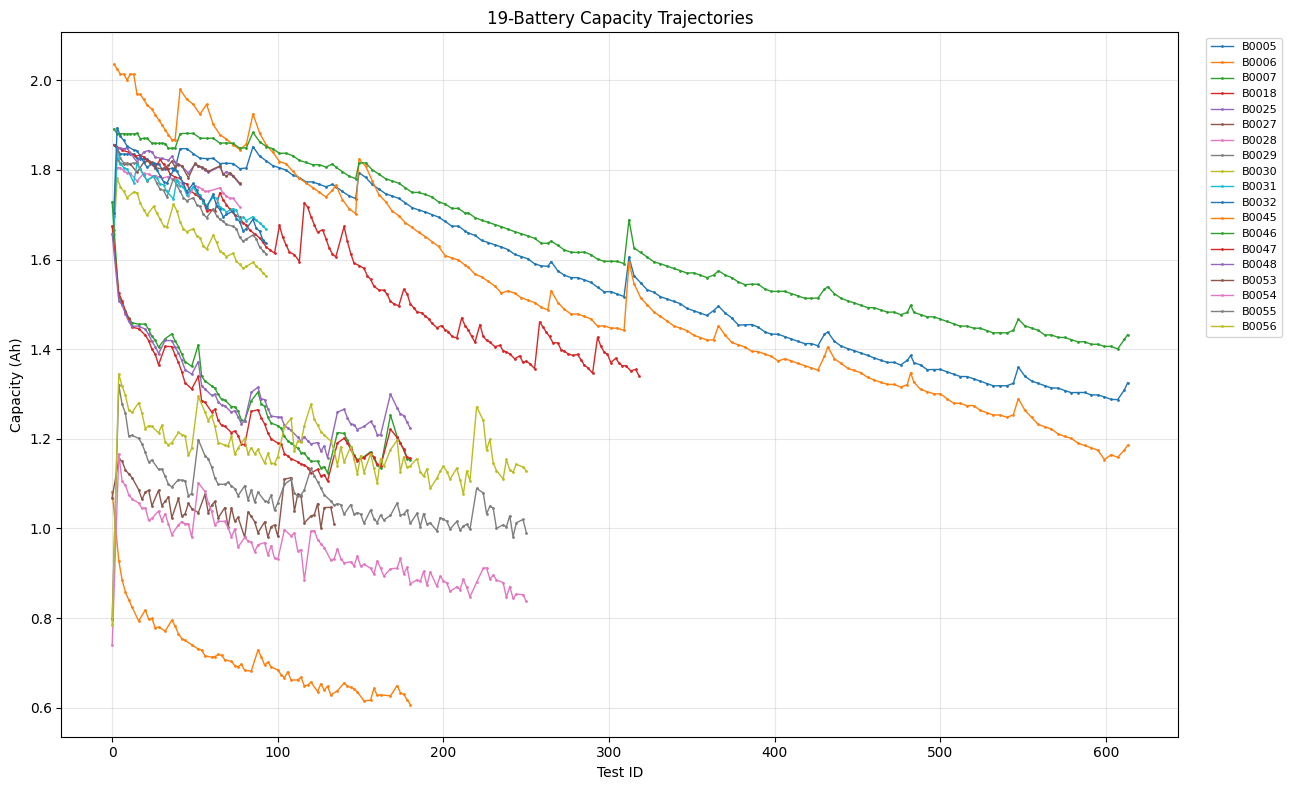

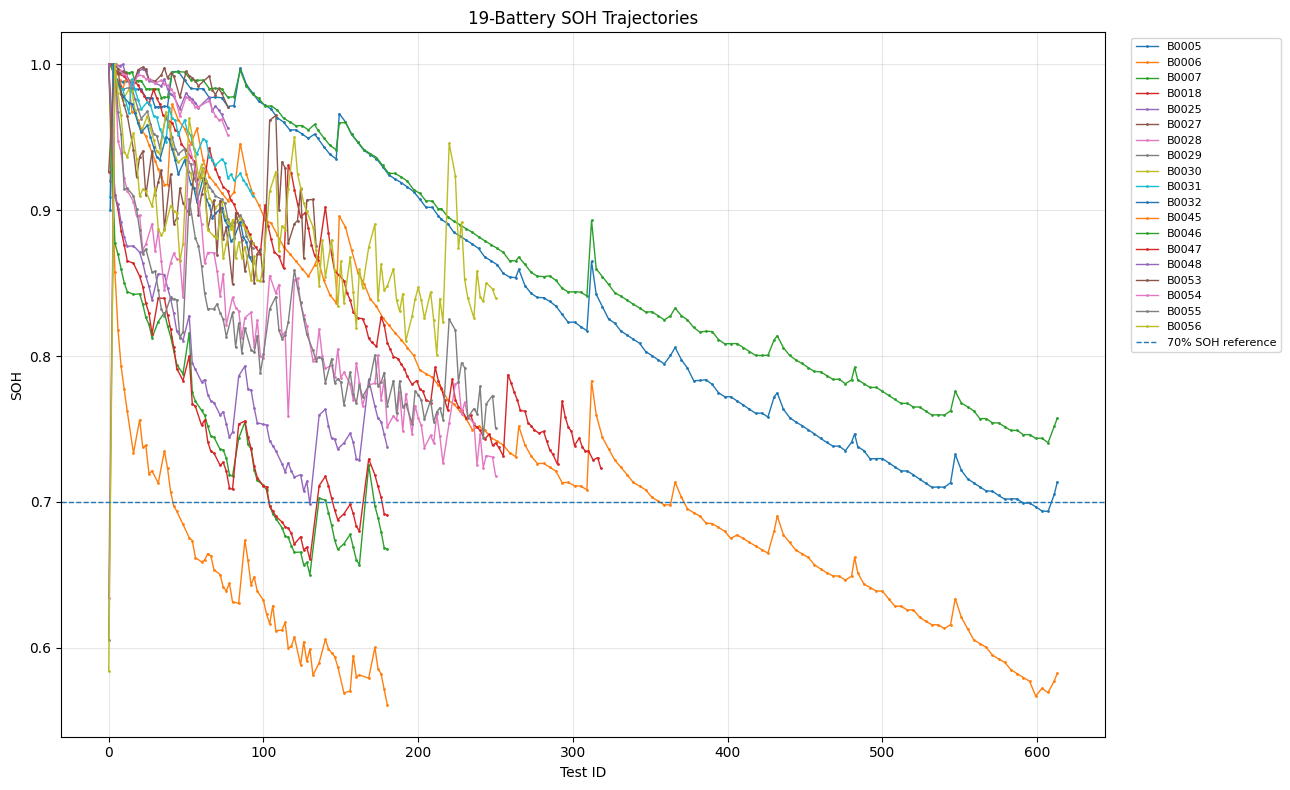


OPERATING CONDITION SUMMARY


,battery_id,ambient_temp_mean,ambient_temp_min,ambient_temp_max,experiments,current_mean,load_current_abs_mean,load_voltage_mean,temperature_mean,temperature_max,discharge_duration_mean,voltage_mean,voltage_drop_mean
0,B0005,24.0,24,24,168,-2.012546,1.998167,2.559113,32.341024,39.721522,2806.971952,3.522741,1.340896
1,B0006,24.0,24,24,168,-2.010354,1.998985,2.550367,32.360508,39.828709,2784.180060,3.454598,1.536010
2,B0007,24.0,24,24,168,-1.989493,2.000000,2.588458,32.171621,40.266280,3003.743958,3.524954,1.921515
3,B0018,24.0,24,24,132,-2.008535,1.998678,2.600474,30.703388,37.575997,2803.921523,3.508733,1.570870
4,B0025,24.0,24,24,28,-4.022838,3.995623,1.448187,34.816684,40.696760,3301.159143,3.324938,1.906862
5,B0027,24.0,24,24,28,-3.972370,3.997049,1.249023,37.214385,42.383352,3326.796429,3.152826,1.112150
6,B0028,24.0,24,24,28,-1.996226,1.999173,2.516222,30.326152,31.788880,6368.736714,3.571142,1.337293
7,B0029,43.0,43,43,40,-4.022388,3.994900,1.461712,52.796441,59.654838,1571.091075,3.388998,1.980310
8,B0030,43.0,43,43,40,-4.024682,4.000932,1.501100,53.958122,62.098221,1508.534750,3.376983,1.772303
9,B0031,43.0,43,43,40,-3.974635,3.997000,1.439984,53.828667,61.697682,1589.692925,3.408305,1.478263



FEATURE DISTRIBUTION SUMMARY


,battery_id,voltage_initial_mean,voltage_initial_std,voltage_initial_min,voltage_initial_max,voltage_final_mean,voltage_final_std,voltage_final_min,voltage_final_max,voltage_min_mean,voltage_min_std,voltage_min_min,voltage_min_max,voltage_max_mean,voltage_max_std,voltage_max_min,voltage_max_max,voltage_mean_mean,voltage_mean_std,voltage_mean_min,voltage_mean_max,voltage_std_mean,voltage_std_std,voltage_std_min,voltage_std_max,voltage_drop_mean,voltage_drop_std,voltage_drop_min,voltage_drop_max,current_mean_mean,current_mean_std,current_mean_min,current_mean_max,current_min_mean,current_min_std,current_min_min,current_min_max,current_max_mean,current_max_std,current_max_min,current_max_max,current_std_mean,current_std_std,current_std_min,current_std_max,temperature_initial_mean,temperature_initial_std,temperature_initial_min,temperature_initial_max,temperature_final_mean,temperature_final_std,temperature_final_min,temperature_final_max,temperature_max_mean,temperature_max_std,temperature_max_min,temperature_max_max,temperature_mean_mean,temperature_mean_std,temperature_mean_min,temperature_mean_max,temperature_rise_mean,temperature_rise_std,temperature_rise_min,temperature_rise_max,load_current_abs_mean_mean,load_current_abs_mean_std,load_current_abs_mean_min,load_current_abs_mean_max,load_current_abs_max_mean,load_current_abs_max_std,load_current_abs_max_min,load_current_abs_max_max,load_voltage_mean_mean,load_voltage_mean_std,load_voltage_mean_min,load_voltage_mean_max,load_voltage_min_mean,load_voltage_min_std,load_voltage_min_min,load_voltage_min_max,discharge_duration_mean,discharge_duration_std,discharge_duration_min,discharge_duration_max
0,B0005,3.989834,0.012309,3.959137,4.018830,2.648939,0.049297,2.455679,2.699983,2.648939,0.049297,2.455679,2.699983,3.989834,0.012309,3.959137,4.018830,3.522741,0.039686,3.455527,3.575355,0.225184,0.011765,0.203031,0.242376,1.340896,0.050603,1.270101,1.532420,-2.012546,0.000222,-2.013171,-2.012039,-2.017870,0.002364,-2.029098,-2.015645,-2.007267,0.002425,-2.009389,-1.995411,0.001595,0.000349,0.001265,0.004232,24.250208,0.463845,23.241306,26.677005,39.720834,1.101257,37.781533,41.312405,39.721522,1.100758,37.781533,41.312405,32.341024,0.550936,31.119437,34.168628,15.470627,1.074971,13.639534,17.157407,1.998167,5.191954e-05,1.998027,1.998305,1.998251,8.753996e-05,1.9982,1.9984,2.559113,0.051043,2.473236,2.642168,1.750637,0.032084,1.684,1.862,2806.971952,339.642493,2297.469,3311.234
1,B0006,3.951789,0.023743,3.900683,3.992592,2.415779,0.067667,2.120698,2.499908,2.415779,0.067667,2.120698,2.499908,3.951789,0.023743,3.900683,3.992592,3.454598,0.072365,3.344863,3.567130,0.238072,0.010931,0.212367,0.258357,1.536010,0.079775,1.404677,1.850680,-2.010354,0.000260,-2.011348,-2.009645,-2.015492,0.002519,-2.027018,-2.013218,-2.005484,0.001890,-2.007800,-1.995813,0.001542,0.000342,0.001236,0.004154,24.248972,0.459919,23.240059,26.667341,39.828709,1.393616,36.939408,41.974359,39.828709,1.393616,36.939408,41.974359,32.360508,0.756947,30.649845,33.808366,15.579738,1.346755,12.918509,17.560597,1.998985,6.661716e-05,1.998830,1.999185,1.999082,9.868684e-05,1.9990,1.9992,2.550367,0.077204,2.436476,2.673130,1.584869,0.051207,1.371,1.723,2784.180060,447.103999,2088.922,3654.531
2,B0007,4.001276,0.009802,3.977573,4.035025,2.079761,0.096199,1.737030,2.199197,2.079761,0.096199,1.737030,2.199197,4.001276,0.009802,3.977573,4.035025,3.524954,0.030510,3.469525,3.567487,0.255580,0.011558,0.231996,0.275400,1.921515,0.094943,1.797632,2.260347,-1.989493,0.000226,-1.990219,-1.988886,-1.994668,0.002364,-2.006038,-1.992201,-1.984476,0.001988,-1.987116,-1.974808,0.001567,0.000311,0.001256,0.003903,23.980018,0.454788,22.990564,26.493779,40.266280,0.834498,38.345721,42.083729,40.266280,0.834498,38.345721,42.083729,32.171621,0.484442,30.930245,33.922459,16.286262,0.723726,14.556163,17.357082,2.000000,0.000000e+00,2.000000,2.000000,2.000000,0.000000e+00,2.0000,2.0000,2.588458,0.031213,2.531040,2.634822,1.208375,0.091982,0.890,1


BATTERY FEATURE-SPACE DISTANCES


,battery_id,nearest_battery,nearest_distance,farthest_battery,farthest_distance
0,B0027,B0032,5.315584,B0048,12.380589
1,B0028,B0005,4.408995,B0029,10.672024
2,B0025,B0029,3.965338,B0048,12.851528
3,B0029,B0030,3.731232,B0048,13.539361
4,B0045,B0046,2.896250,B0032,12.361082
5,B0007,B0018,2.467691,B0027,10.140355
6,B0046,B0047,2.295561,B0032,12.423142
7,B0056,B0055,2.220889,B0029,11.051536
8,B0055,B0056,2.220889,B0029,9.965506
9,B0030,B0031,2.153107,B0048,12.889212


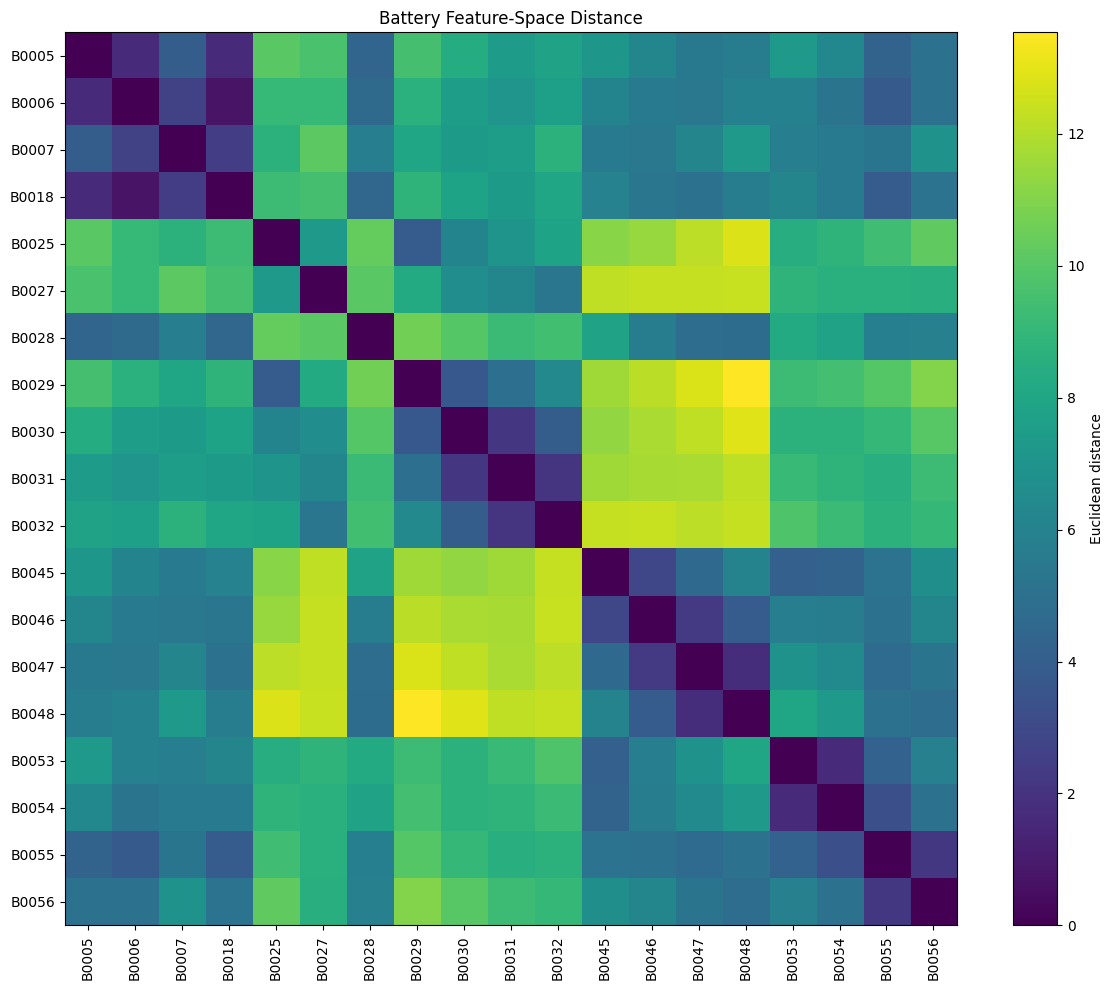

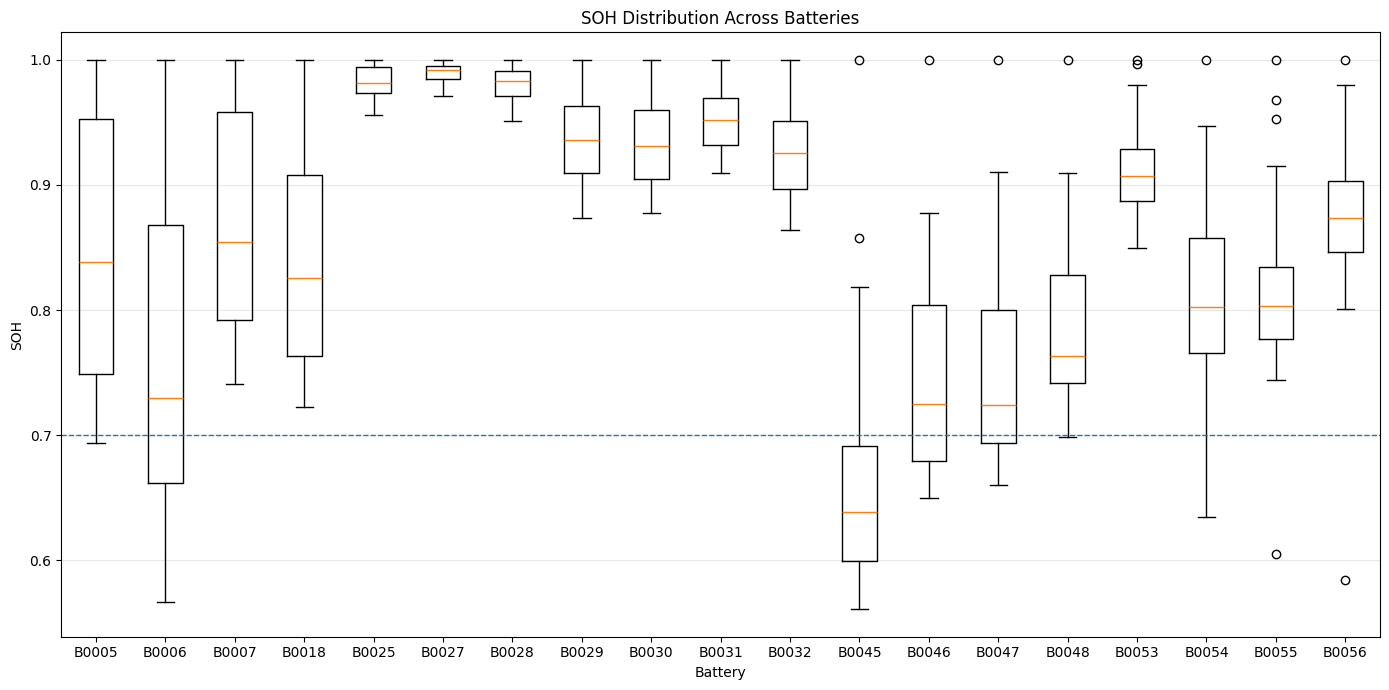


FEATURE vs SOH CORRELATION


,Feature,Correlation_with_SOH
0,load_current_abs_max,0.549395
1,load_current_abs_mean,0.549392
2,current_max,-0.547984
3,current_min,-0.547909
4,current_mean,-0.547820
5,load_voltage_min,-0.454650
6,load_voltage_mean,-0.434358
7,temperature_initial,0.397653
8,temperature_mean,0.393032
9,voltage_std,-0.389589



BATTERY SOH RANGE


,battery_id,min,max,mean,std,SOH_range
0,B0045,0.560960,1.0,0.654881,0.077830,0.439040
1,B0006,0.566893,1.0,0.759997,0.123831,0.433107
2,B0056,0.584130,1.0,0.875513,0.049292,0.415870
3,B0055,0.605352,1.0,0.811685,0.053178,0.394648
4,B0054,0.634297,1.0,0.813739,0.062268,0.365703
5,B0046,0.650206,1.0,0.742186,0.072597,0.349794
6,B0047,0.660559,1.0,0.750099,0.072978,0.339441
7,B0005,0.693488,1.0,0.847031,0.102566,0.306512
8,B0048,0.698242,1.0,0.783788,0.060002,0.301758
9,B0018,0.722937,1.0,0.839729,0.083496,0.277063



DIAGNOSTIC BATTERY RANKING


,battery_id,SOH_non_increasing,SOH_rank_corr,large_jump_count,potentially_problematic,nearest_distance,monotonicity_score,correlation_score,jump_score,distance_score,diagnostic_score
0,B0007,0.718563,-0.992648,13,True,2.467691,0.281437,0.003676,0.928571,0.464237,0.652750
1,B0005,0.784431,-0.991274,14,True,1.662012,0.215569,0.004363,1.000000,0.312668,0.621040
2,B0028,0.703704,-0.953476,5,True,4.408995,0.296296,0.023262,0.357143,0.829447,0.592571
3,B0006,0.838323,-0.993382,14,True,0.735655,0.161677,0.003309,1.000000,0.138396,0.576353
4,B0027,0.666667,-0.706076,3,True,5.315584,0.333333,0.146962,0.214286,1.000000,0.565435
5,B0025,0.703704,-0.944718,4,True,3.965338,0.296296,0.027641,0.285714,0.745983,0.564452
6,B0054,0.594059,-0.886560,6,True,1.626130,0.405941,0.056720,0.428571,0.305917,0.556665
7,B0045,0.681159,-0.974315,4,True,2.896250,0.318841,0.012842,0.285714,0.544860,0.546613
8,B0055,0.603960,-0.819758,4,True,2.220889,0.396040,0.090121,0.285714,0.417807,0.531391
9,B0056,0.594059,-0.659962,5,True,2.220889,0.405941,0.170019,0.357143,0.417807,0.525173



STAGE 3C AUDIT COMPLETE

Output directory:
/kaggle/working/driveguard_x_battery_models/stage_3c_audit

IMPORTANT:
No batteries have been removed.
No model has been retrained.
Use the diagnostic results to decide the next experiment.


In [100]:
# ============================================================
# DRIVEGUARD-X
# STAGE 3C
#
# 19-BATTERY DATASET / TRAJECTORY AUDIT
#
# PURPOSE:
# Determine whether the remaining 19 batteries form a
# scientifically consistent generalized SOH dataset.
#
# THIS CELL DOES NOT:
#   - train models
#   - tune hyperparameters
#   - modify the Stage 3B dataset
#
# IT ONLY ANALYZES:
#   1. Capacity trajectories
#   2. SOH trajectories
#   3. Monotonicity
#   4. Capacity jumps
#   5. Operating conditions
#   6. Feature distribution differences
#   7. Battery-level distribution shift
#
# IMPORTANT:
# Reuses `feature_df` and `metadata` already present in memory.
# No raw CSV files are read.
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURATION
# ============================================================

AUDIT_BATTERIES = [

    "B0005",
    "B0006",
    "B0007",
    "B0018",

    "B0025",
    "B0027",
    "B0028",

    "B0029",
    "B0030",
    "B0031",
    "B0032",

    "B0045",
    "B0046",
    "B0047",
    "B0048",

    "B0053",
    "B0054",
    "B0055",
    "B0056"

]


FEATURE_COLUMNS_AUDIT = [

    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",

    "current_mean",
    "current_min",
    "current_max",
    "current_std",

    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",

    "load_current_abs_mean",
    "load_current_abs_max",

    "load_voltage_mean",
    "load_voltage_min",

    "discharge_duration"

]


print("=" * 100)
print("DRIVEGUARD-X | STAGE 3C")
print("19-BATTERY DATASET AUDIT")
print("=" * 100)


# ============================================================
# 2. VERIFY EXISTING DATA
# ============================================================

if "feature_df" not in globals():

    raise RuntimeError(
        "feature_df is not available. "
        "Run Stage 3 feature extraction first."
    )


audit_df = feature_df.copy()


print(
    "\n✓ feature_df found:",
    audit_df.shape
)


# ============================================================
# 3. PREPARE COLUMNS
# ============================================================

audit_df["battery_id"] = (

    audit_df["battery_id"]
    .astype(str)
    .str.strip()

)


audit_df["Capacity"] = pd.to_numeric(

    audit_df["Capacity"],

    errors="coerce"

)


audit_df["test_id_numeric"] = pd.to_numeric(

    audit_df["test_id"],

    errors="coerce"

)


for feature in FEATURE_COLUMNS_AUDIT:

    audit_df[feature] = pd.to_numeric(

        audit_df[feature],

        errors="coerce"

    )


# Select the 19 batteries

audit_df = audit_df[

    audit_df["battery_id"].isin(
        AUDIT_BATTERIES
    )

].copy()


audit_df = audit_df[

    audit_df["Capacity"].notna()

].copy()


audit_df = audit_df[

    audit_df["Capacity"] > 0

].copy()


audit_df = (

    audit_df

    .sort_values(

        [
            "battery_id",
            "test_id_numeric"
        ]

    )

    .reset_index(drop=True)

)


print(
    "Selected audit dataset:",
    audit_df.shape
)

print(
    "Batteries:",
    audit_df["battery_id"].nunique()
)


# ============================================================
# 4. RECREATE STAGE 3B C0 / SOH
# ============================================================

PAPER_BATTERIES = [

    "B0005",
    "B0006",
    "B0007",
    "B0018"

]


c0_map_audit = {}


for battery, group in audit_df.groupby(
    "battery_id"
):

    group = group.sort_values(
        "test_id_numeric"
    )


    capacities = (

        group["Capacity"]

        .astype(float)

        .reset_index(drop=True)

    )


    if battery in PAPER_BATTERIES:

        C0 = float(
            capacities.iloc[0]
        )

    else:

        C0 = float(

            capacities.iloc[
                :min(5, len(capacities))
            ].max()

        )


    c0_map_audit[battery] = C0


audit_df["C0"] = (

    audit_df["battery_id"]

    .map(c0_map_audit)

)


audit_df["SOH"] = (

    audit_df["Capacity"]

    /

    audit_df["C0"]

)


# ============================================================
# 5. CAPACITY / SOH TRAJECTORY STATISTICS
# ============================================================

trajectory_results = []


for battery, group in audit_df.groupby(
    "battery_id"
):

    group = group.sort_values(
        "test_id_numeric"
    ).copy()


    capacity = group[
        "Capacity"
    ].values


    soh = group[
        "SOH"
    ].values


    # --------------------------------------------------------
    # Capacity differences
    # --------------------------------------------------------

    capacity_diff = np.diff(
        capacity
    )


    soh_diff = np.diff(
        soh
    )


    # --------------------------------------------------------
    # Monotonicity
    #
    # Fraction of transitions that are non-increasing.
    #
    # 1.0 = completely non-increasing
    # 0.5 = approximately half increasing
    # --------------------------------------------------------

    capacity_non_increasing = (

        np.sum(
            capacity_diff <= 0
        )

        /

        len(capacity_diff)

        if len(capacity_diff) > 0
        else np.nan

    )


    soh_non_increasing = (

        np.sum(
            soh_diff <= 0
        )

        /

        len(soh_diff)

        if len(soh_diff) > 0
        else np.nan

    )


    # --------------------------------------------------------
    # Large jumps
    # --------------------------------------------------------

    abs_capacity_diff = np.abs(
        capacity_diff
    )


    median_abs_jump = (

        np.median(
            abs_capacity_diff
        )

        if len(abs_capacity_diff)
        else np.nan

    )


    max_abs_jump = (

        np.max(
            abs_capacity_diff
        )

        if len(abs_capacity_diff)
        else np.nan

    )


    # Number of unusually large jumps.
    #
    # We use 3 × median absolute jump as a diagnostic
    # threshold, not as a deletion rule.

    jump_threshold = (

        3 *
        median_abs_jump

        if median_abs_jump > 0
        else np.inf

    )


    large_jump_count = np.sum(

        abs_capacity_diff
        >
        jump_threshold

    )


    # --------------------------------------------------------
    # Capacity range
    # --------------------------------------------------------

    capacity_range = (

        capacity.max()
        -
        capacity.min()

    )


    soh_range = (

        soh.max()
        -
        soh.min()

    )


    # --------------------------------------------------------
    # Spearman-like rank correlation
    #
    # Avoid scipy dependency here.
    # --------------------------------------------------------

    cycle_rank = (

        pd.Series(
            group["test_id_numeric"]
        )

        .rank()

        .values

    )


    capacity_rank = (

        pd.Series(
            capacity
        )

        .rank()

        .values

    )


    soh_rank = (

        pd.Series(
            soh
        )

        .rank()

        .values

    )


    capacity_rank_corr = np.corrcoef(

        cycle_rank,

        capacity_rank

    )[0, 1]


    soh_rank_corr = np.corrcoef(

        cycle_rank,

        soh_rank

    )[0, 1]


    trajectory_results.append({

        "battery_id":
            battery,

        "cycles":
            len(group),

        "C0":
            c0_map_audit[battery],

        "capacity_min":
            capacity.min(),

        "capacity_max":
            capacity.max(),

        "capacity_range":
            capacity_range,

        "SOH_min":
            soh.min(),

        "SOH_max":
            soh.max(),

        "SOH_range":
            soh_range,

        "capacity_non_increasing":
            capacity_non_increasing,

        "SOH_non_increasing":
            soh_non_increasing,

        "capacity_rank_corr":
            capacity_rank_corr,

        "SOH_rank_corr":
            soh_rank_corr,

        "median_abs_capacity_jump":
            median_abs_jump,

        "max_abs_capacity_jump":
            max_abs_jump,

        "large_jump_count":
            large_jump_count

    })


trajectory_summary = (

    pd.DataFrame(
        trajectory_results
    )

    .sort_values(
        "battery_id"
    )

    .reset_index(drop=True)

)


# ============================================================
# 6. DISPLAY TRAJECTORY AUDIT
# ============================================================

print("\n" + "=" * 100)
print("TRAJECTORY AUDIT")
print("=" * 100)

display(
    trajectory_summary
)


# ============================================================
# 7. FLAG POTENTIALLY PROBLEMATIC TRAJECTORIES
# ============================================================

trajectory_flags = trajectory_summary.copy()


trajectory_flags["flag_low_monotonicity"] = (

    trajectory_flags[
        "SOH_non_increasing"
    ]

    <

    0.80

)


trajectory_flags["flag_large_jumps"] = (

    trajectory_flags[
        "large_jump_count"
    ]

    >=

    2

)


trajectory_flags["flag_weak_cycle_correlation"] = (

    trajectory_flags[
        "SOH_rank_corr"
    ]

    >

    -0.50

)


trajectory_flags["potentially_problematic"] = (

    trajectory_flags[
        "flag_low_monotonicity"
    ]

    |

    trajectory_flags[
        "flag_large_jumps"
    ]

    |

    trajectory_flags[
        "flag_weak_cycle_correlation"
    ]

)


print("\n" + "=" * 100)
print("TRAJECTORY FLAGS")
print("=" * 100)

display(

    trajectory_flags[
        [

            "battery_id",

            "SOH_non_increasing",

            "SOH_rank_corr",

            "large_jump_count",

            "flag_low_monotonicity",

            "flag_large_jumps",

            "flag_weak_cycle_correlation",

            "potentially_problematic"

        ]

    ]

)


# ============================================================
# 8. CAPACITY TRAJECTORIES
# ============================================================

plt.figure(
    figsize=(13, 8)
)


for battery in sorted(
    audit_df["battery_id"].unique()
):

    group = (

        audit_df[

            audit_df[
                "battery_id"
            ]
            ==
            battery

        ]

        .sort_values(
            "test_id_numeric"
        )

    )


    plt.plot(

        group["test_id_numeric"],

        group["Capacity"],

        marker=".",

        markersize=2,

        linewidth=1,

        label=battery

    )


plt.xlabel(
    "Test ID"
)

plt.ylabel(
    "Capacity (Ah)"
)

plt.title(
    "19-Battery Capacity Trajectories"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    fontsize=8

)

plt.tight_layout()

plt.show()


# ============================================================
# 9. SOH TRAJECTORIES
# ============================================================

plt.figure(
    figsize=(13, 8)
)


for battery in sorted(
    audit_df["battery_id"].unique()
):

    group = (

        audit_df[

            audit_df[
                "battery_id"
            ]
            ==
            battery

        ]

        .sort_values(
            "test_id_numeric"
        )

    )


    plt.plot(

        group["test_id_numeric"],

        group["SOH"],

        marker=".",

        markersize=2,

        linewidth=1,

        label=battery

    )


plt.axhline(

    0.70,

    linestyle="--",

    linewidth=1,

    label="70% SOH reference"

)


plt.xlabel(
    "Test ID"
)

plt.ylabel(
    "SOH"
)

plt.title(
    "19-Battery SOH Trajectories"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left",

    fontsize=8

)

plt.tight_layout()

plt.show()


# ============================================================
# 10. OPERATING-CONDITION AUDIT
#
# Use metadata if available.
# Otherwise derive what we can from feature_df.
# ============================================================

metadata_available = (
    "metadata" in globals()
)


if metadata_available:

    metadata_audit = metadata.copy()


    metadata_audit["battery_id"] = (

        metadata_audit["battery_id"]
        .astype(str)
        .str.strip()

    )


    metadata_audit = metadata_audit[

        metadata_audit[
            "battery_id"
        ].isin(
            AUDIT_BATTERIES
        )

    ].copy()


    metadata_audit["ambient_temperature"] = pd.to_numeric(

        metadata_audit[
            "ambient_temperature"
        ],

        errors="coerce"

    )


    discharge_metadata = metadata_audit[

        metadata_audit["type"]
        .astype(str)
        .str.lower()
        .eq("discharge")

    ].copy()


    operating_summary = (

        discharge_metadata

        .groupby(
            "battery_id"
        )

        .agg(

            ambient_temp_mean=(
                "ambient_temperature",
                "mean"
            ),

            ambient_temp_min=(
                "ambient_temperature",
                "min"
            ),

            ambient_temp_max=(
                "ambient_temperature",
                "max"
            ),

            experiments=(
                "battery_id",
                "size"
            )

        )

        .reset_index()

    )


else:

    operating_summary = (

        audit_df

        .groupby(
            "battery_id"
        )

        .agg(

            experiments=(
                "battery_id",
                "size"
            )

        )

        .reset_index()

    )


# ============================================================
# 11. FEATURE-BASED OPERATING CONDITIONS
# ============================================================

feature_condition_summary = (

    audit_df

    .groupby(
        "battery_id"
    )

    .agg(

        current_mean=(
            "current_mean",
            "mean"
        ),

        load_current_abs_mean=(
            "load_current_abs_mean",
            "mean"
        ),

        load_voltage_mean=(
            "load_voltage_mean",
            "mean"
        ),

        temperature_mean=(
            "temperature_mean",
            "mean"
        ),

        temperature_max=(
            "temperature_max",
            "mean"
        ),

        discharge_duration_mean=(
            "discharge_duration",
            "mean"
        ),

        voltage_mean=(
            "voltage_mean",
            "mean"
        ),

        voltage_drop_mean=(
            "voltage_drop",
            "mean"
        )

    )

    .reset_index()

)


operating_condition_summary = (

    operating_summary

    .merge(

        feature_condition_summary,

        on="battery_id",

        how="outer"

    )

    .sort_values(
        "battery_id"
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("OPERATING CONDITION SUMMARY")
print("=" * 100)

display(
    operating_condition_summary
)


# ============================================================
# 12. FEATURE DISTRIBUTION BY BATTERY
# ============================================================

feature_distribution = []


for battery, group in audit_df.groupby(
    "battery_id"
):

    row = {
        "battery_id": battery
    }


    for feature in FEATURE_COLUMNS_AUDIT:

        row[
            f"{feature}_mean"
        ] = group[
            feature
        ].mean()


        row[
            f"{feature}_std"
        ] = group[
            feature
        ].std()


        row[
            f"{feature}_min"
        ] = group[
            feature
        ].min()


        row[
            f"{feature}_max"
        ] = group[
            feature
        ].max()


    feature_distribution.append(
        row
    )


feature_distribution_df = (

    pd.DataFrame(
        feature_distribution
    )

    .sort_values(
        "battery_id"
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("FEATURE DISTRIBUTION SUMMARY")
print("=" * 100)

display(
    feature_distribution_df
)


# ============================================================
# 13. STANDARDIZED BATTERY FEATURE CENTERS
#
# This gives a simple measure of how different batteries are
# from each other in feature space.
#
# We standardize each feature globally, then calculate the
# mean standardized feature vector for every battery.
# ============================================================

from sklearn.preprocessing import StandardScaler


feature_matrix = audit_df[
    FEATURE_COLUMNS_AUDIT
].copy()


scaler_audit = StandardScaler()


scaled_features = scaler_audit.fit_transform(
    feature_matrix
)


scaled_feature_df = pd.DataFrame(

    scaled_features,

    columns=FEATURE_COLUMNS_AUDIT,

    index=audit_df.index

)


battery_feature_centers = (

    scaled_feature_df

    .join(
        audit_df["battery_id"]
    )

    .groupby(
        "battery_id"
    )

    .mean()

)


# ============================================================
# 14. PAIRWISE BATTERY DISTANCES
# ============================================================

from sklearn.metrics import pairwise_distances


distance_matrix = pairwise_distances(

    battery_feature_centers[
        FEATURE_COLUMNS_AUDIT
    ],

    metric="euclidean"

)


battery_names = (

    battery_feature_centers.index
    .tolist()

)


distance_df = pd.DataFrame(

    distance_matrix,

    index=battery_names,

    columns=battery_names

)


# ------------------------------------------------------------
# Nearest-neighbor distance for every battery
# ------------------------------------------------------------

nearest_neighbor_results = []


for battery in battery_names:

    distances = (

        distance_df.loc[
            battery
        ]

        .drop(
            battery
        )

    )


    nearest_battery = (

        distances
        .idxmin()

    )


    nearest_distance = (

        distances
        .min()

    )


    farthest_battery = (

        distances
        .idxmax()

    )


    farthest_distance = (

        distances
        .max()

    )


    nearest_neighbor_results.append({

        "battery_id":
            battery,

        "nearest_battery":
            nearest_battery,

        "nearest_distance":
            nearest_distance,

        "farthest_battery":
            farthest_battery,

        "farthest_distance":
            farthest_distance

    })


nearest_neighbor_df = (

    pd.DataFrame(
        nearest_neighbor_results
    )

    .sort_values(
        "nearest_distance",
        ascending=False
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("BATTERY FEATURE-SPACE DISTANCES")
print("=" * 100)

display(
    nearest_neighbor_df
)


# ============================================================
# 15. HEATMAP OF BATTERY DISTANCES
# ============================================================

plt.figure(
    figsize=(12, 10)
)


plt.imshow(
    distance_matrix,
    aspect="auto"
)


plt.xticks(

    range(len(battery_names)),

    battery_names,

    rotation=90

)


plt.yticks(

    range(len(battery_names)),

    battery_names

)


plt.colorbar(
    label="Euclidean distance"
)


plt.title(
    "Battery Feature-Space Distance"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. SOH DISTRIBUTION BY BATTERY
# ============================================================

plt.figure(
    figsize=(14, 7)
)


soh_box_data = [

    audit_df.loc[

        audit_df["battery_id"]
        ==
        battery,

        "SOH"

    ].values

    for battery in sorted(
        audit_df["battery_id"].unique()
    )

]


plt.boxplot(

    soh_box_data,

    labels=sorted(
        audit_df["battery_id"].unique()
    )

)


plt.axhline(

    0.70,

    linestyle="--",

    linewidth=1

)


plt.xlabel(
    "Battery"
)

plt.ylabel(
    "SOH"
)

plt.title(
    "SOH Distribution Across Batteries"
)

plt.grid(

    True,

    axis="y",

    alpha=0.3

)

plt.tight_layout()

plt.show()


# ============================================================
# 17. FEATURE CORRELATION WITH SOH
# ============================================================

correlation_results = []


for feature in FEATURE_COLUMNS_AUDIT:

    corr = (

        audit_df[
            [
                feature,
                "SOH"
            ]

        ]

        .corr()

        .iloc[0, 1]

    )


    correlation_results.append({

        "Feature":
            feature,

        "Correlation_with_SOH":
            corr

    })


feature_soh_correlation_3c = (

    pd.DataFrame(
        correlation_results
    )

    .sort_values(

        "Correlation_with_SOH",

        key=lambda x:
            x.abs(),

        ascending=False

    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("FEATURE vs SOH CORRELATION")
print("=" * 100)

display(
    feature_soh_correlation_3c
)


# ============================================================
# 18. BATTERY-LEVEL SOH RANGE COMPARISON
# ============================================================

battery_range_comparison = (

    audit_df

    .groupby(
        "battery_id"
    )["SOH"]

    .agg(

        min="min",

        max="max",

        mean="mean",

        std="std"

    )

    .reset_index()

)


battery_range_comparison["SOH_range"] = (

    battery_range_comparison["max"]

    -

    battery_range_comparison["min"]

)


battery_range_comparison = (

    battery_range_comparison

    .sort_values(
        "SOH_range",
        ascending=False
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("BATTERY SOH RANGE")
print("=" * 100)

display(
    battery_range_comparison
)


# ============================================================
# 19. FINAL DIAGNOSTIC RANKING
# ============================================================
#
# This ranking DOES NOT automatically remove batteries.
#
# It combines:
#
#   - poor monotonicity
#   - weak cycle/SOH relationship
#   - large capacity jumps
#   - feature-space isolation
#
# It is only a diagnostic ranking.
# ============================================================

diagnostic_ranking = (

    trajectory_flags[

        [

            "battery_id",

            "SOH_non_increasing",

            "SOH_rank_corr",

            "large_jump_count",

            "potentially_problematic"

        ]

    ]

    .merge(

        nearest_neighbor_df[

            [

                "battery_id",

                "nearest_distance"

            ]

        ],

        on="battery_id",

        how="left"

    )

)


# Normalize diagnostic quantities

diagnostic_ranking["monotonicity_score"] = (

    1

    -

    diagnostic_ranking[
        "SOH_non_increasing"
    ]

)


diagnostic_ranking["correlation_score"] = (

    np.clip(

        (
            diagnostic_ranking[
                "SOH_rank_corr"
            ]

            + 1

        )

        /

        2,

        0,

        1

    )

)


diagnostic_ranking["jump_score"] = (

    diagnostic_ranking[
        "large_jump_count"
    ]

    /

    max(

        diagnostic_ranking[
            "large_jump_count"
        ].max(),

        1

    )

)


diagnostic_ranking["distance_score"] = (

    diagnostic_ranking[
        "nearest_distance"
    ]

    /

    diagnostic_ranking[
        "nearest_distance"
    ].max()

)


diagnostic_ranking["diagnostic_score"] = (

    0.35
    *
    diagnostic_ranking[
        "monotonicity_score"
    ]

    +

    0.30
    *
    (
        1
        -
        diagnostic_ranking[
            "correlation_score"
        ]
    )

    +

    0.20
    *
    diagnostic_ranking[
        "jump_score"
    ]

    +

    0.15
    *
    diagnostic_ranking[
        "distance_score"
    ]

)


diagnostic_ranking = (

    diagnostic_ranking

    .sort_values(
        "diagnostic_score",
        ascending=False
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("DIAGNOSTIC BATTERY RANKING")
print("=" * 100)

display(
    diagnostic_ranking
)


# ============================================================
# 20. SAVE AUDIT OUTPUTS
# ============================================================

AUDIT_OUTPUT_DIR = (

    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "stage_3c_audit"

)


os.makedirs(

    AUDIT_OUTPUT_DIR,

    exist_ok=True

)


audit_df.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "audit_dataset.csv"

    ),

    index=False

)


trajectory_summary.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "trajectory_summary.csv"

    ),

    index=False

)


trajectory_flags.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "trajectory_flags.csv"

    ),

    index=False

)


operating_condition_summary.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "operating_condition_summary.csv"

    ),

    index=False

)


feature_distribution_df.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "feature_distribution.csv"

    ),

    index=False

)


nearest_neighbor_df.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "battery_feature_distances.csv"

    ),

    index=False

)


feature_soh_correlation_3c.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "feature_soh_correlation.csv"

    ),

    index=False

)


battery_range_comparison.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "battery_soh_ranges.csv"

    ),

    index=False

)


diagnostic_ranking.to_csv(

    os.path.join(

        AUDIT_OUTPUT_DIR,

        "diagnostic_battery_ranking.csv"

    ),

    index=False

)


print("\n" + "=" * 100)
print("STAGE 3C AUDIT COMPLETE")
print("=" * 100)

print(
    "\nOutput directory:"
)

print(
    AUDIT_OUTPUT_DIR
)

print(
    "\nIMPORTANT:"
)

print(
    "No batteries have been removed."
)

print(
    "No model has been retrained."
)

print(
    "Use the diagnostic results to decide the next experiment."
)

print("=" * 100)

BATTERY OPERATING-CONDITION MAP


,battery_id,operating_condition,ambient_temperature,discharge_current,load_current,samples
0,B0005,24C_2A,24.0,2.012546,1.998167,168
1,B0006,24C_2A,24.0,2.010354,1.998985,168
2,B0007,24C_2A,24.0,1.989493,2.000000,168
3,B0018,24C_2A,24.0,2.008535,1.998678,132
4,B0025,24C_4A,24.0,4.022838,3.995623,28
5,B0027,24C_4A,24.0,3.972370,3.997049,28
6,B0028,24C_2A,24.0,1.996226,1.999173,28
7,B0029,43C_4A,43.0,4.022388,3.994900,40
8,B0030,43C_4A,43.0,4.024682,4.000932,40
9,B0031,43C_4A,43.0,3.974635,3.997000,40



OPERATING-CONDITION SUMMARY


,operating_condition,batteries,cycles,ambient_temperature,discharge_current,load_current,SOH_mean,SOH_min,SOH_max,duration_mean,voltage_mean,voltage_drop_mean,temperature_mean
0,24C_2A,5,664,24.0,2.004673,1.998982,0.834903,0.566893,1.0,3000.579506,3.505316,1.582732,31.892574
1,24C_4A,2,56,24.0,3.997604,3.996336,0.986167,0.956087,1.0,3313.977786,3.238882,1.509506,36.015535
2,43C_4A,4,160,43.0,4.003007,3.998458,0.936364,0.863660,1.0,1561.680869,3.378580,1.600150,53.742544
3,4C_1A,4,277,4.0,1.001069,0.998933,0.732458,0.560960,1.0,4293.341888,3.333862,1.631639,8.891963
4,4C_2A,4,361,4.0,1.999939,1.998342,0.845198,0.584130,1.0,2170.633601,3.199807,1.439246,11.705207


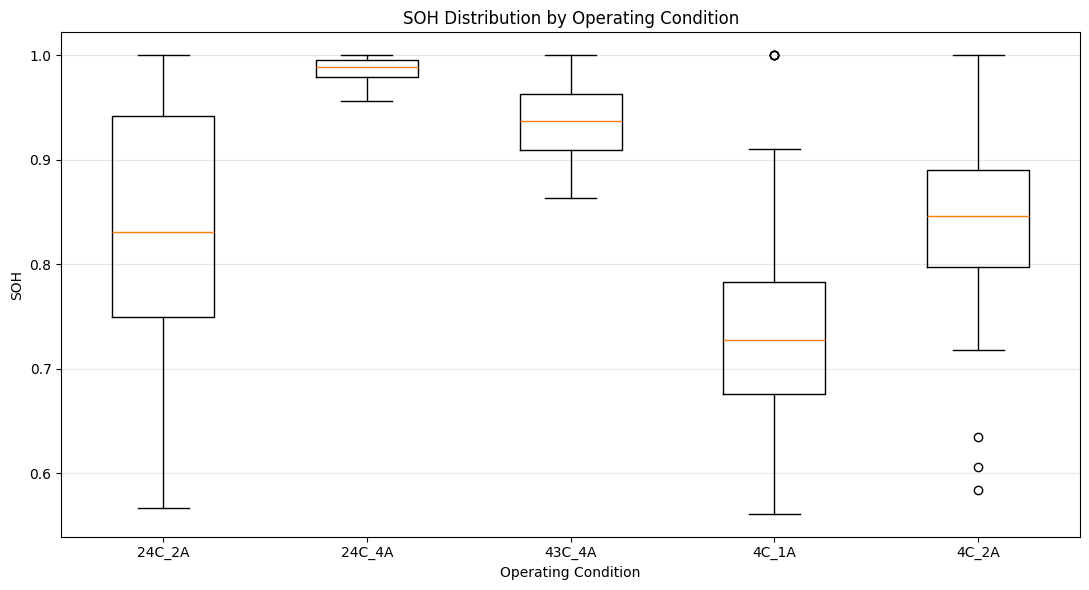


FEATURE MEANS BY OPERATING CONDITION


,voltage_initial,voltage_final,voltage_mean,voltage_drop,current_mean,temperature_mean,temperature_max,temperature_rise,load_current_abs_mean,load_voltage_mean,discharge_duration
operating_condition,,,,,,,,,,,
24C_2A,3.980084,2.397352,3.505316,1.582732,-2.004673,31.892574,39.125443,15.034167,1.998982,2.570738,3000.579506
24C_4A,3.650736,2.141229,3.238882,1.509506,-3.997604,36.015535,41.540056,14.896146,3.996336,1.348605,3313.977786
43C_4A,3.859292,2.259142,3.378580,1.600150,-4.003007,53.742544,61.291782,16.774104,3.998458,1.419272,1561.680869
4C_1A,3.964107,2.332469,3.333862,1.631639,-1.001069,8.891963,13.236806,7.418289,0.998933,2.821192,4293.341888
4C_2A,3.822445,2.383199,3.199807,1.439246,-1.999939,11.705207,18.390487,12.508022,1.998342,2.170282,2170.633601



CONDITION-SPECIFIC FEATURE / SOH CORRELATIONS


,operating_condition,feature,correlation
0,24C_2A,voltage_initial,0.630871
1,24C_2A,voltage_final,-0.130647
2,24C_2A,voltage_min,-0.130647
3,24C_2A,voltage_max,0.630871
4,24C_2A,voltage_mean,0.960495
...,...,...,...
100,4C_2A,load_current_abs_mean,-0.444318
101,4C_2A,load_current_abs_max,-0.423063
102,4C_2A,load_voltage_mean,0.221174
103,4C_2A,load_voltage_min,-0.011461


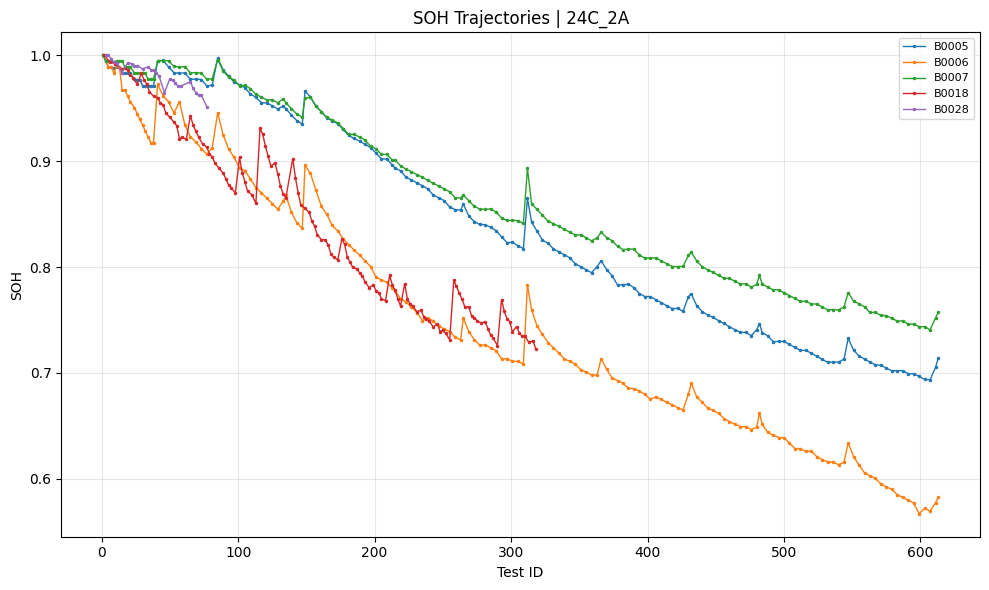

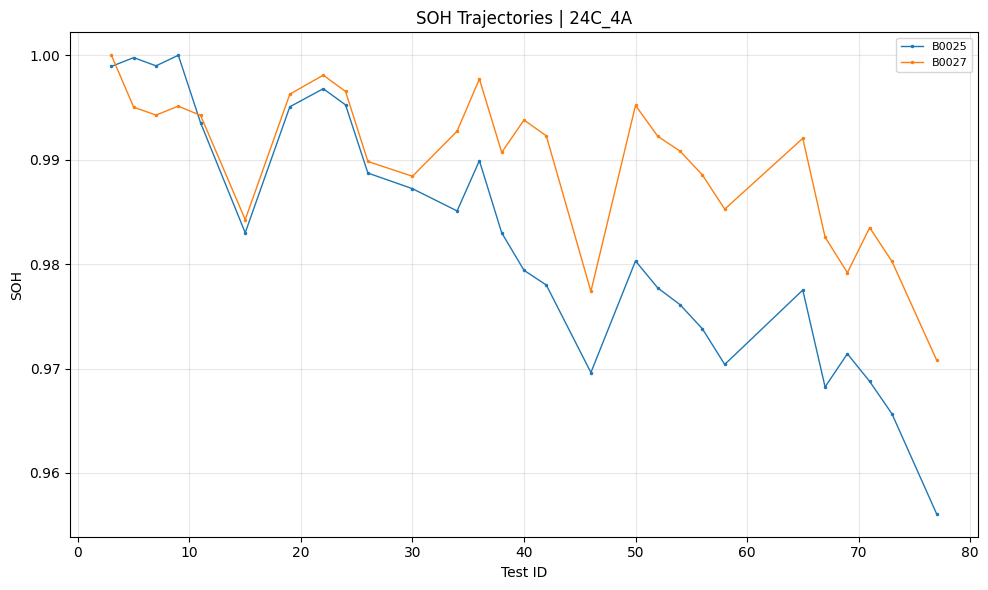

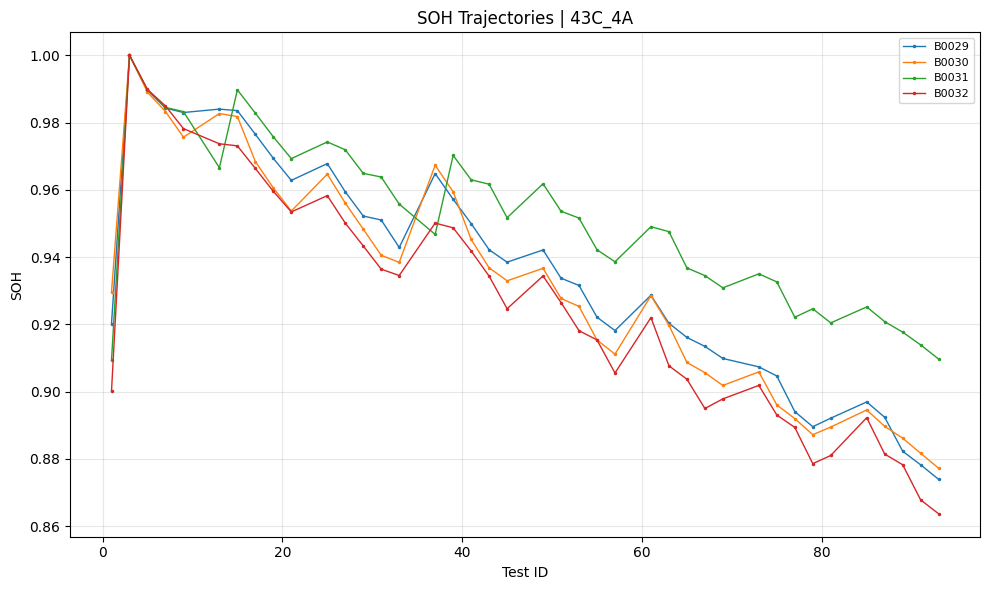

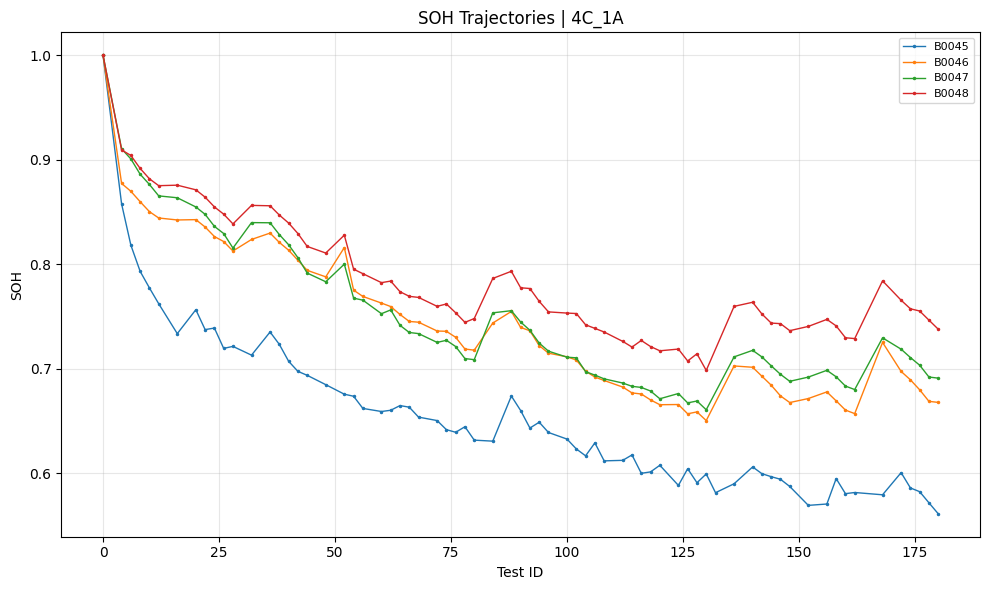

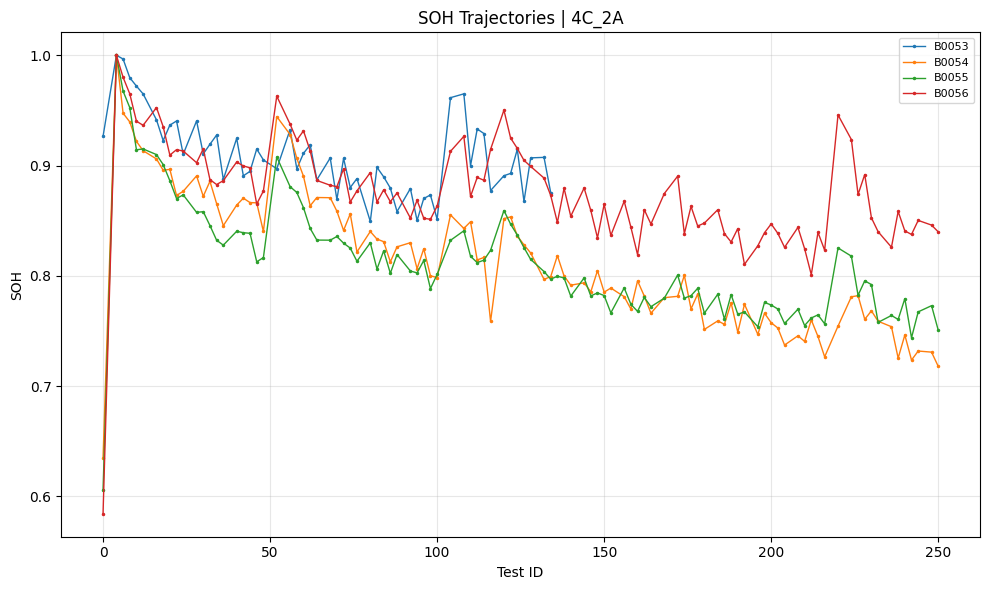


STAGE 3D CONDITION AUDIT COMPLETE

Saved to:
/kaggle/working/driveguard_x_battery_models/stage_3d_condition_audit

No batteries removed.
No models trained.
No hyperparameters changed.


In [101]:
# ============================================================
# DRIVEGUARD-X
# STAGE 3D
#
# OPERATING-CONDITION ANALYSIS
#
# PURPOSE:
# Explicitly characterize the experimental domains present
# in the generalized NASA battery dataset.
#
# NO MODEL TRAINING.
# NO BATTERY REMOVAL.
# NO HYPERPARAMETER TUNING.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. USE STAGE 3C DATA
# ============================================================

if "audit_df" not in globals():

    raise RuntimeError(
        "audit_df not found. Run Stage 3C first."
    )


condition_df = audit_df.copy()


# ============================================================
# 2. PREPARE OPERATING-CONDITION VARIABLES
# ============================================================

# Ambient temperature from metadata if available

if "metadata" in globals():

    metadata_condition = metadata.copy()

    metadata_condition["battery_id"] = (
        metadata_condition["battery_id"]
        .astype(str)
        .str.strip()
    )

    metadata_condition["ambient_temperature"] = pd.to_numeric(
        metadata_condition["ambient_temperature"],
        errors="coerce"
    )

    metadata_condition = metadata_condition[
        metadata_condition["type"]
        .astype(str)
        .str.lower()
        .eq("discharge")
    ]

    metadata_condition = metadata_condition[
        [
            "battery_id",
            "test_id",
            "ambient_temperature"
        ]
    ].drop_duplicates(
        subset=["battery_id", "test_id"]
    )

    condition_df = condition_df.merge(
        metadata_condition,
        on=["battery_id", "test_id"],
        how="left"
    )

else:

    condition_df["ambient_temperature"] = np.nan


# ============================================================
# 3. DERIVE AVERAGE DISCHARGE CURRENT MAGNITUDE
# ============================================================

condition_df["discharge_current_abs"] = (
    condition_df["current_mean"].abs()
)


condition_df["load_current_abs"] = (
    condition_df["load_current_abs_mean"].abs()
)


# ============================================================
# 4. DEFINE OPERATING-CONDITION GROUP
#
# These groups are descriptive labels, not ML features yet.
# ============================================================

def assign_condition(row):

    temp = row["ambient_temperature"]
    current = row["load_current_abs"]

    if pd.isna(temp):

        return "Unknown"

    if temp >= 40:

        return "43C_4A"

    if temp <= 6 and current < 1.5:

        return "4C_1A"

    if temp <= 6 and current >= 1.5:

        return "4C_2A"

    if 20 <= temp <= 28 and current >= 3.0:

        return "24C_4A"

    if 20 <= temp <= 28:

        return "24C_2A"

    return "Other"


condition_df["operating_condition"] = (

    condition_df.apply(
        assign_condition,
        axis=1
    )

)


# ============================================================
# 5. BATTERY → OPERATING CONDITION MAP
# ============================================================

battery_condition_map = (

    condition_df

    .groupby("battery_id")

    .agg(

        operating_condition=(
            "operating_condition",
            lambda x: x.mode().iloc[0]
        ),

        ambient_temperature=(
            "ambient_temperature",
            "mean"
        ),

        discharge_current=(
            "discharge_current_abs",
            "mean"
        ),

        load_current=(
            "load_current_abs",
            "mean"
        ),

        samples=(
            "battery_id",
            "size"
        )

    )

    .reset_index()

)


print("=" * 100)
print("BATTERY OPERATING-CONDITION MAP")
print("=" * 100)

display(
    battery_condition_map
)


# ============================================================
# 6. CONDITION-LEVEL SUMMARY
# ============================================================

condition_summary = (

    condition_df

    .groupby(
        "operating_condition"
    )

    .agg(

        batteries=(
            "battery_id",
            "nunique"
        ),

        cycles=(
            "battery_id",
            "size"
        ),

        ambient_temperature=(
            "ambient_temperature",
            "mean"
        ),

        discharge_current=(
            "discharge_current_abs",
            "mean"
        ),

        load_current=(
            "load_current_abs",
            "mean"
        ),

        SOH_mean=(
            "SOH",
            "mean"
        ),

        SOH_min=(
            "SOH",
            "min"
        ),

        SOH_max=(
            "SOH",
            "max"
        ),

        duration_mean=(
            "discharge_duration",
            "mean"
        ),

        voltage_mean=(
            "voltage_mean",
            "mean"
        ),

        voltage_drop_mean=(
            "voltage_drop",
            "mean"
        ),

        temperature_mean=(
            "temperature_mean",
            "mean"
        )

    )

    .reset_index()

)


print("\n" + "=" * 100)
print("OPERATING-CONDITION SUMMARY")
print("=" * 100)

display(
    condition_summary
)


# ============================================================
# 7. SOH DISTRIBUTION BY OPERATING CONDITION
# ============================================================

plt.figure(
    figsize=(11, 6)
)


condition_names = sorted(
    condition_df[
        "operating_condition"
    ].unique()
)


box_data = [

    condition_df.loc[
        condition_df[
            "operating_condition"
        ]
        ==
        condition,
        "SOH"
    ].values

    for condition in condition_names

]


plt.boxplot(
    box_data,
    labels=condition_names
)


plt.xlabel(
    "Operating Condition"
)

plt.ylabel(
    "SOH"
)

plt.title(
    "SOH Distribution by Operating Condition"
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. FEATURE DISTRIBUTION BY OPERATING CONDITION
# ============================================================

condition_feature_summary = (

    condition_df

    .groupby(
        "operating_condition"
    )[

        [

            "voltage_initial",
            "voltage_final",
            "voltage_mean",
            "voltage_drop",

            "current_mean",

            "temperature_mean",
            "temperature_max",
            "temperature_rise",

            "load_current_abs_mean",
            "load_voltage_mean",

            "discharge_duration"

        ]

    ]

    .mean()

)


print("\n" + "=" * 100)
print("FEATURE MEANS BY OPERATING CONDITION")
print("=" * 100)

display(
    condition_feature_summary
)


# ============================================================
# 9. CONDITION-SPECIFIC SOH CORRELATIONS
# ============================================================

condition_correlations = []


correlation_features = [

    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",

    "current_mean",
    "current_min",
    "current_max",
    "current_std",

    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",

    "load_current_abs_mean",
    "load_current_abs_max",

    "load_voltage_mean",
    "load_voltage_min",

    "discharge_duration"

]


for condition in condition_names:

    subset = condition_df[
        condition_df[
            "operating_condition"
        ]
        ==
        condition
    ]


    for feature in correlation_features:

        corr = subset[
            [
                feature,
                "SOH"
            ]
        ].corr().iloc[0, 1]


        condition_correlations.append({

            "operating_condition":
                condition,

            "feature":
                feature,

            "correlation":
                corr

        })


condition_correlation_df = (

    pd.DataFrame(
        condition_correlations
    )

)


print("\n" + "=" * 100)
print("CONDITION-SPECIFIC FEATURE / SOH CORRELATIONS")
print("=" * 100)

display(
    condition_correlation_df
)


# ============================================================
# 10. CAPACITY TRAJECTORIES GROUPED BY CONDITION
# ============================================================

fig_conditions = sorted(
    condition_df[
        "operating_condition"
    ].unique()
)


for condition in fig_conditions:

    subset = condition_df[
        condition_df[
            "operating_condition"
        ]
        ==
        condition
    ]


    plt.figure(
        figsize=(10, 6)
    )


    for battery in sorted(
        subset["battery_id"].unique()
    ):

        battery_data = (

            subset[
                subset["battery_id"]
                ==
                battery
            ]

            .sort_values(
                "test_id_numeric"
            )

        )


        plt.plot(

            battery_data[
                "test_id_numeric"
            ],

            battery_data[
                "SOH"
            ],

            marker=".",

            markersize=3,

            linewidth=1,

            label=battery

        )


    plt.xlabel(
        "Test ID"
    )

    plt.ylabel(
        "SOH"
    )

    plt.title(
        f"SOH Trajectories | {condition}"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend(
        fontsize=8
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 11. SAVE RESULTS
# ============================================================

STAGE_3D_DIR = (
    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "stage_3d_condition_audit"
)


import os

os.makedirs(
    STAGE_3D_DIR,
    exist_ok=True
)


battery_condition_map.to_csv(
    os.path.join(
        STAGE_3D_DIR,
        "battery_condition_map.csv"
    ),
    index=False
)


condition_summary.to_csv(
    os.path.join(
        STAGE_3D_DIR,
        "condition_summary.csv"
    ),
    index=False
)


condition_feature_summary.to_csv(
    os.path.join(
        STAGE_3D_DIR,
        "condition_feature_summary.csv"
    )
)


condition_correlation_df.to_csv(
    os.path.join(
        STAGE_3D_DIR,
        "condition_feature_correlations.csv"
    ),
    index=False
)


condition_df.to_csv(
    os.path.join(
        STAGE_3D_DIR,
        "condition_audit_dataset.csv"
    ),
    index=False
)


print("\n" + "=" * 100)
print("STAGE 3D CONDITION AUDIT COMPLETE")
print("=" * 100)

print(
    "\nSaved to:"
)

print(
    STAGE_3D_DIR
)

print(
    "\nNo batteries removed."
)

print(
    "No models trained."
)

print(
    "No hyperparameters changed."
)

print("=" * 100)

DRIVEGUARD-X | STAGE 4
FINAL MODEL FINE-TUNING

✓ Required datasets found.

FINAL DATASET SHAPES
Train: (818, 21)
Validation: (200, 21)
Test: (500, 21)

Base features: 21
Condition-aware features: 24

BASELINE CONDITION-AWARE COMPARISON

Training XGBoost_Base...

Training RandomForest_Base...

Training SVR_Base...


,Model,Validation_MAE,Validation_MSE,Validation_RMSE,Validation_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,RandomForest_Base,0.041889,0.003492,0.059092,0.777316,0.077602,0.010616,0.103034,0.219579
1,XGBoost_Base,0.044293,0.003606,0.060049,0.770043,0.078641,0.009909,0.099542,0.271584
2,SVR_Base,0.060589,0.006465,0.080403,0.587728,0.041821,0.002736,0.052306,0.798869



XGBOOST HYPERPARAMETER SEARCH
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGBoost parameters:
{'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.02, 'colsample_bytree': 0.8}

Best cross-validation MAE: 0.07008920742232652

RANDOM FOREST HYPERPARAMETER SEARCH
Fitting 5 folds for each of 35 candidates, totalling 175 fits

Best Random Forest parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 10}

Best cross-validation MAE: 0.07540525598920005

SVR HYPERPARAMETER SEARCH
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best SVR parameters:
{'svr__gamma': 'scale', 'svr__epsilon': 0.05, 'svr__C': 1}

Best cross-validation MAE: 0.06339812326964678

TUNED MODEL EVALUATION

Evaluating XGBoost_Tuned...

Evaluating RandomForest_Tuned...

Evaluating SVR_Tuned...




,Model,Validation_MAE,Validation_MSE,Validation_RMSE,Validation_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,RandomForest_Tuned,0.047245,0.004505,0.067118,0.712713,0.079467,0.011019,0.104973,0.189930
1,SVR_Tuned,0.047495,0.004620,0.067972,0.705359,0.057951,0.004540,0.067377,0.666274
2,XGBoost_Tuned,0.054841,0.005364,0.073240,0.657916,0.090356,0.014281,0.119505,-0.049881



ALL MODEL RESULTS


,Model,Validation_MAE,Validation_MSE,Validation_RMSE,Validation_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,RandomForest_Base,0.041889,0.003492,0.059092,0.777316,0.077602,0.010616,0.103034,0.219579
1,XGBoost_Base,0.044293,0.003606,0.060049,0.770043,0.078641,0.009909,0.099542,0.271584
2,RandomForest_Tuned,0.047245,0.004505,0.067118,0.712713,0.079467,0.011019,0.104973,0.189930
3,SVR_Tuned,0.047495,0.004620,0.067972,0.705359,0.057951,0.004540,0.067377,0.666274
4,XGBoost_Tuned,0.054841,0.005364,0.073240,0.657916,0.090356,0.014281,0.119505,-0.049881
5,SVR_Base,0.060589,0.006465,0.080403,0.587728,0.041821,0.002736,0.052306,0.798869



CURRENT BEST TUNED MODEL
Model: RandomForest_Tuned
Validation MAE: 0.047245
Validation R²: 0.712713
Test MAE: 0.079467
Test RMSE: 0.104973
Test R²: 0.189930

FINAL MODEL | PER-BATTERY TEST PERFORMANCE


,Battery,MAE,MSE,RMSE,R2,Samples
0,B0053,0.025081,0.001031,0.032103,0.163893,55
1,B0030,0.035255,0.001665,0.040803,-0.459401,40
2,B0005,0.055483,0.004831,0.069503,0.538052,168
3,B0047,0.062531,0.004801,0.069291,0.085230,69
4,B0006,0.138739,0.025259,0.158931,-0.657102,168


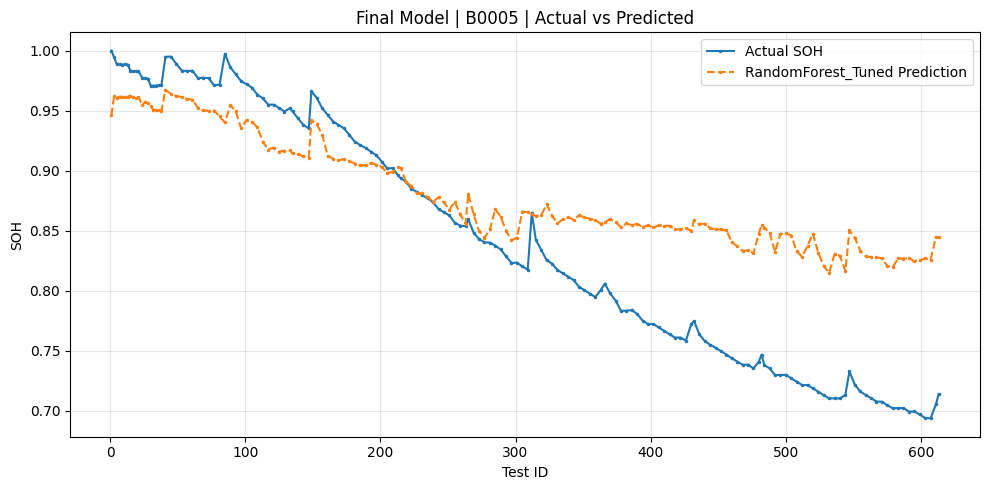

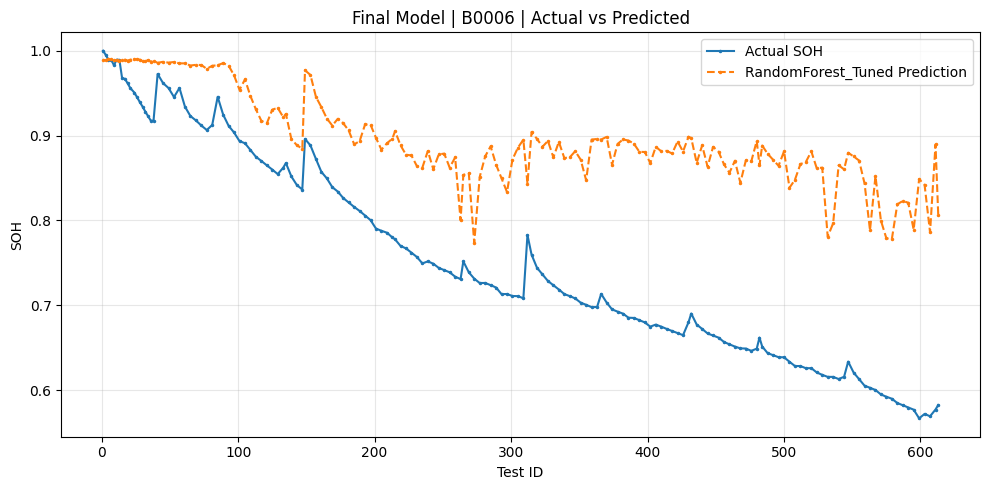

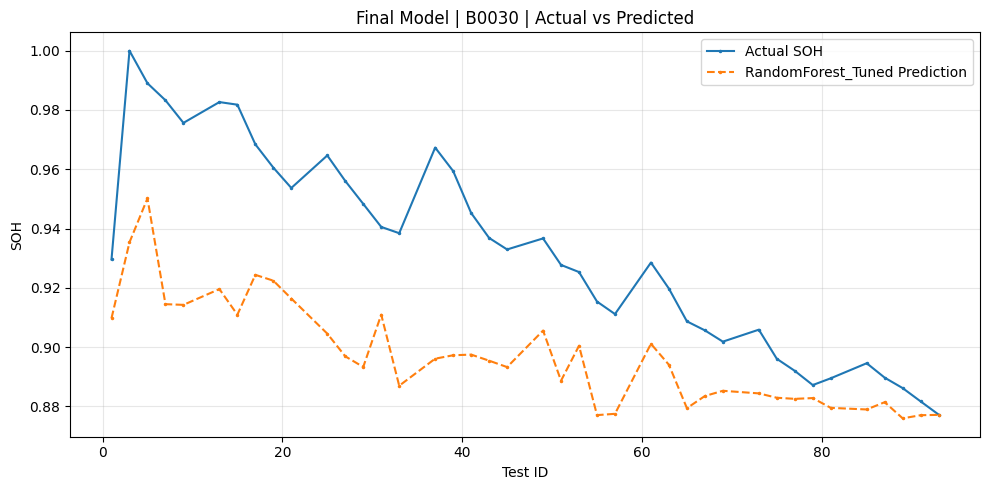

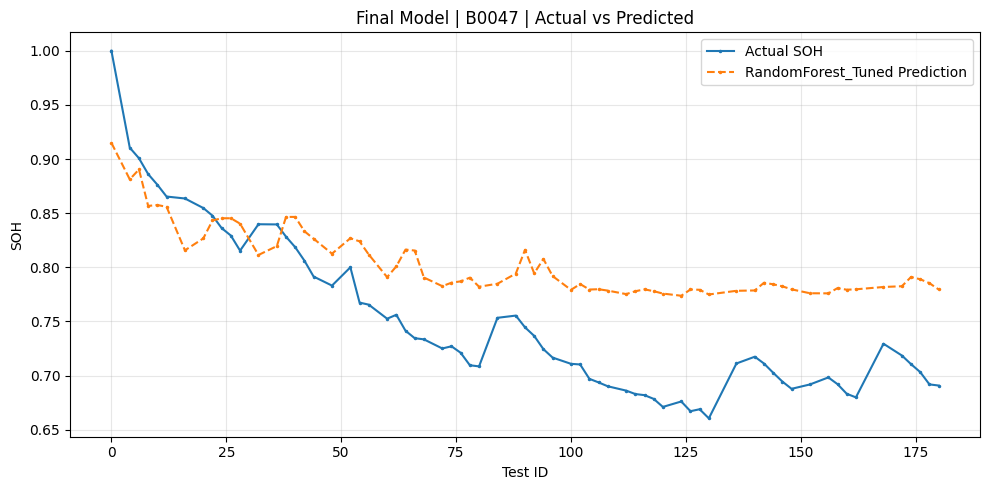

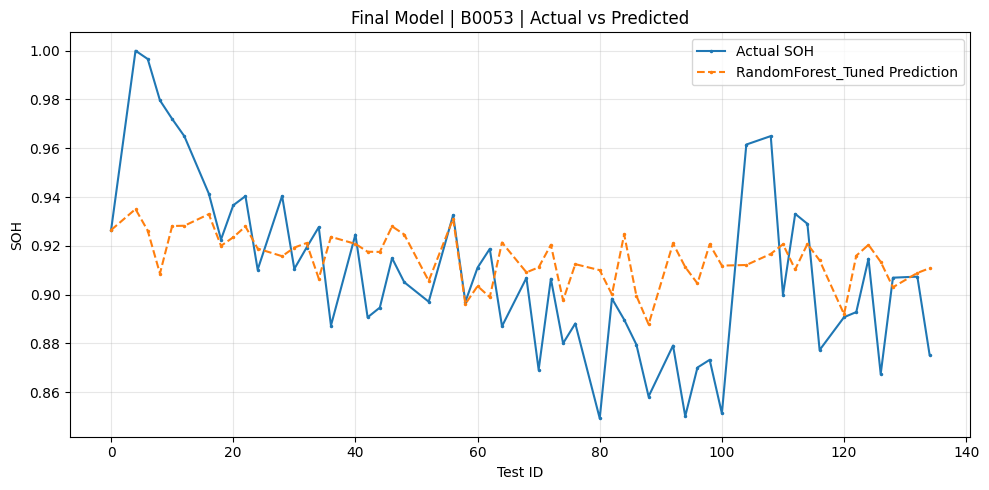

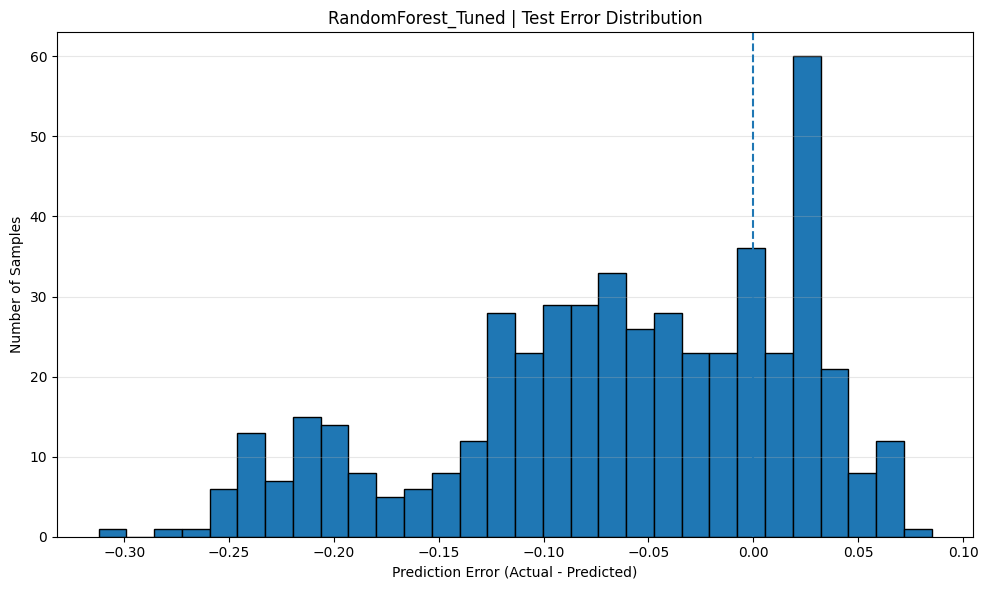


FINAL MODEL FEATURE IMPORTANCE


,Feature,Importance
0,voltage_std,0.220344
1,temperature_initial,0.117771
2,discharge_duration,0.091664
3,voltage_mean,0.085129
4,load_voltage_min,0.063049
5,load_current_abs,0.048526
6,load_voltage_mean,0.044892
7,load_current_abs_mean,0.042774
8,voltage_max,0.034426
9,voltage_initial,0.033582


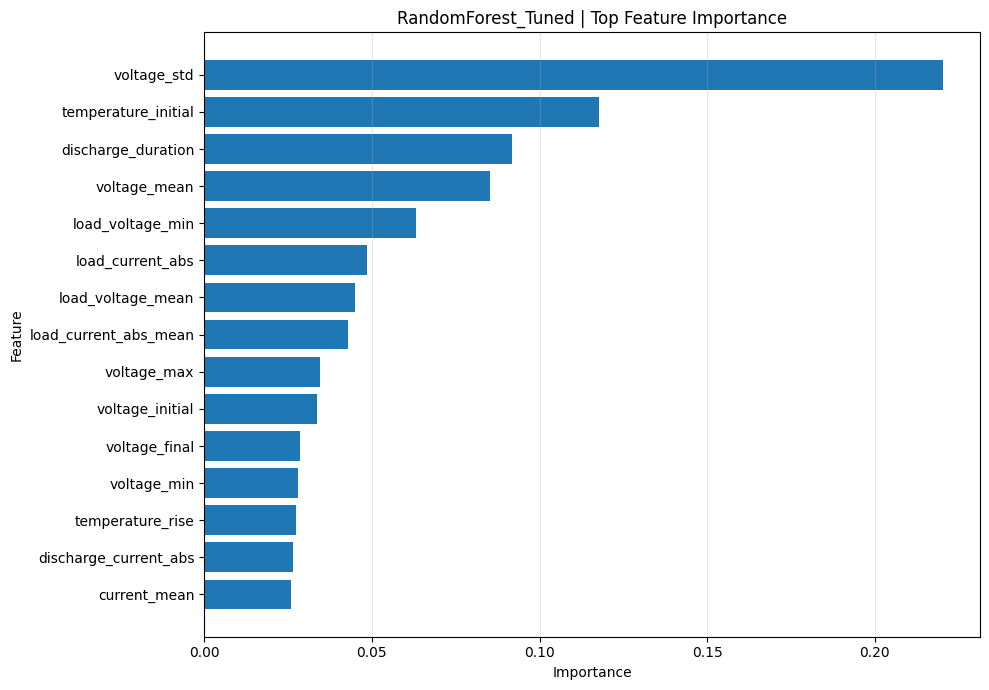


STAGE 3B VS FINAL TUNED MODEL


,Model,Stage3B_Test_MAE,Stage3B_Test_RMSE,Stage3B_Test_R2
0,XGBoost,0.078641,0.099542,0.271584
1,Random Forest,0.077602,0.103034,0.219579
2,SVR,0.041821,0.052306,0.798869


,Final_Model,Final_Test_MAE,Final_Test_RMSE,Final_Test_R2
0,RandomForest_Tuned,0.079467,0.104973,0.18993



STAGE 4 COMPLETE

Candidate final model: RandomForest_Tuned
Validation MAE: 0.047245
Test MAE: 0.079467
Test RMSE: 0.104973
Test R²: 0.189930

Saved to:
/kaggle/working/driveguard_x_battery_models/final_model

IMPORTANT:
Do not yet call this the final DriveGuard-X model.
We still need to inspect the tuned results and
per-battery performance before freezing the model.


In [102]:
# ============================================================
# DRIVEGUARD-X
# STAGE 4
#
# FINAL MODEL FINE-TUNING
#
# OBJECTIVE:
# Build and compare:
#
#   A. Baseline 21-feature models
#   B. Condition-aware models
#   C. Tuned XGBoost
#   D. Tuned Random Forest
#   E. Tuned SVR
#
# MODEL SELECTION:
#   Primary metric = Validation MAE
#
# IMPORTANT:
#   - Battery-level train/validation/test split is preserved.
#   - Test set is NOT used for hyperparameter selection.
#   - No raw CSV files are reread.
# ============================================================


import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    KFold
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42


# ------------------------------------------------------------
# Existing 21 features
# ------------------------------------------------------------

BASE_FEATURES = [

    "voltage_initial",
    "voltage_final",
    "voltage_min",
    "voltage_max",
    "voltage_mean",
    "voltage_std",
    "voltage_drop",

    "current_mean",
    "current_min",
    "current_max",
    "current_std",

    "temperature_initial",
    "temperature_final",
    "temperature_max",
    "temperature_mean",
    "temperature_rise",

    "load_current_abs_mean",
    "load_current_abs_max",

    "load_voltage_mean",
    "load_voltage_min",

    "discharge_duration"

]


# ------------------------------------------------------------
# Additional physical operating-condition features
# ------------------------------------------------------------

CONDITION_FEATURES = [

    "ambient_temperature",

    "discharge_current_abs",

    "load_current_abs"

]


# ------------------------------------------------------------
# Final candidate feature set
# ------------------------------------------------------------

CONDITION_AWARE_FEATURES = (

    BASE_FEATURES

    +

    CONDITION_FEATURES

)


TARGET = "SOH"


print("=" * 100)
print("DRIVEGUARD-X | STAGE 4")
print("FINAL MODEL FINE-TUNING")
print("=" * 100)


# ============================================================
# 2. VERIFY EXISTING DATA
# ============================================================

required_objects = [

    "condition_df",
    "train_df_3b",
    "validation_df_3b",
    "test_df_3b"

]


for obj in required_objects:

    if obj not in globals():

        raise RuntimeError(

            f"{obj} was not found.\n"
            "Run Stage 3B and Stage 3D first."

        )


print(
    "\n✓ Required datasets found."
)


# ============================================================
# 3. BUILD CONDITION-AWARE DATASET
# ============================================================

condition_model_df = condition_df.copy()


condition_model_df["discharge_current_abs"] = (

    condition_model_df[
        "current_mean"
    ].abs()

)


condition_model_df["load_current_abs"] = (

    condition_model_df[
        "load_current_abs_mean"
    ].abs()

)


# ============================================================
# 4. VERIFY AMBIENT TEMPERATURE
# ============================================================

if (
    "ambient_temperature"
    not in
    condition_model_df.columns
):

    raise RuntimeError(

        "ambient_temperature is missing."

    )


# ============================================================
# 5. MATCH ORIGINAL TRAIN/VALIDATION/TEST BATTERIES
# ============================================================

TRAIN_BATTERIES = sorted(

    train_df_3b[
        "battery_id"
    ]

    .unique()

)


VALIDATION_BATTERIES = sorted(

    validation_df_3b[
        "battery_id"
    ]

    .unique()

)


TEST_BATTERIES = sorted(

    test_df_3b[
        "battery_id"
    ]

    .unique()

)


# ============================================================
# 6. CREATE FINAL PARTITIONS
# ============================================================

train_final = condition_model_df[

    condition_model_df[
        "battery_id"
    ]

    .isin(
        TRAIN_BATTERIES
    )

].copy()


validation_final = condition_model_df[

    condition_model_df[
        "battery_id"
    ]

    .isin(
        VALIDATION_BATTERIES
    )

].copy()


test_final = condition_model_df[

    condition_model_df[
        "battery_id"
    ]

    .isin(
        TEST_BATTERIES
    )

].copy()


# ============================================================
# 7. REMOVE INVALID VALUES
# ============================================================

for feature in CONDITION_AWARE_FEATURES:

    for dataset in [

        train_final,
        validation_final,
        test_final

    ]:

        dataset[feature] = pd.to_numeric(

            dataset[feature],

            errors="coerce"

        )


for dataset in [

    train_final,
    validation_final,
    test_final

]:

    dataset.replace(

        [
            np.inf,
            -np.inf

        ],

        np.nan,

        inplace=True

    )


train_final = train_final.dropna(

    subset=CONDITION_AWARE_FEATURES + [TARGET]

)


validation_final = validation_final.dropna(

    subset=CONDITION_AWARE_FEATURES + [TARGET]

)


test_final = test_final.dropna(

    subset=CONDITION_AWARE_FEATURES + [TARGET]

)


# ============================================================
# 8. CREATE MATRICES
# ============================================================

X_train_base = train_final[
    BASE_FEATURES
].copy()


X_validation_base = validation_final[
    BASE_FEATURES
].copy()


X_test_base = test_final[
    BASE_FEATURES
].copy()


X_train_condition = train_final[
    CONDITION_AWARE_FEATURES
].copy()


X_validation_condition = validation_final[
    CONDITION_AWARE_FEATURES
].copy()


X_test_condition = test_final[
    CONDITION_AWARE_FEATURES
].copy()


y_train = train_final[
    TARGET
].copy()


y_validation = validation_final[
    TARGET
].copy()


y_test = test_final[
    TARGET
].copy()


print("\n" + "=" * 100)
print("FINAL DATASET SHAPES")
print("=" * 100)


print(
    "Train:",
    X_train_base.shape
)


print(
    "Validation:",
    X_validation_base.shape
)


print(
    "Test:",
    X_test_base.shape
)


print(
    "\nBase features:",
    len(BASE_FEATURES)
)


print(
    "Condition-aware features:",
    len(CONDITION_AWARE_FEATURES)
)


# ============================================================
# 9. BATTERY-LEVEL CROSS-VALIDATION
# ============================================================
#
# Important:
#
# Random KFold on cycles can put cycles from the same battery
# in both training and validation folds.
#
# That creates leakage for battery generalization.
#
# Therefore, tuning is performed at the battery level.
#
# We use GroupKFold.
# ============================================================

from sklearn.model_selection import GroupKFold


groups = train_final[
    "battery_id"
].values


GROUP_CV = GroupKFold(
    n_splits=5
)


# ============================================================
# 10. BASELINE MODELS
# ============================================================

baseline_models = {

    "XGBoost_Base":

        XGBRegressor(

            objective=
            "reg:squarederror",

            n_estimators=500,

            max_depth=4,

            learning_rate=0.05,

            subsample=0.90,

            colsample_bytree=0.90,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "RandomForest_Base":

        RandomForestRegressor(

            n_estimators=400,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "SVR_Base":

        Pipeline(

            [

                (
                    "scaler",

                    StandardScaler()

                ),

                (
                    "svr",

                    SVR(

                        kernel="rbf",

                        C=10.0,

                        epsilon=0.01

                    )

                )

            ]

        )

}


baseline_results = []


baseline_predictions = {}


print("\n" + "=" * 100)
print("BASELINE CONDITION-AWARE COMPARISON")
print("=" * 100)


for model_name, model in baseline_models.items():

    print(
        f"\nTraining {model_name}..."
    )


    # --------------------------------------------------------
    # Select features
    # --------------------------------------------------------

    if "Base" in model_name:

        Xtr = X_train_base

        Xval = X_validation_base

        Xte = X_test_base

    else:

        Xtr = X_train_condition

        Xval = X_validation_condition

        Xte = X_test_condition


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        Xtr,
        y_train
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    val_pred = model.predict(
        Xval
    )

    test_pred = model.predict(
        Xte
    )


    baseline_predictions[
        model_name
    ] = {

        "validation":
            val_pred,

        "test":
            test_pred

    }


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    val_mae = mean_absolute_error(
        y_validation,
        val_pred
    )

    val_mse = mean_squared_error(
        y_validation,
        val_pred
    )

    val_rmse = np.sqrt(
        val_mse
    )

    val_r2 = r2_score(
        y_validation,
        val_pred
    )


    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_mse = mean_squared_error(
        y_test,
        test_pred
    )

    test_rmse = np.sqrt(
        test_mse
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )


    baseline_results.append({

        "Model":
            model_name,

        "Validation_MAE":
            val_mae,

        "Validation_MSE":
            val_mse,

        "Validation_RMSE":
            val_rmse,

        "Validation_R2":
            val_r2,

        "Test_MAE":
            test_mae,

        "Test_MSE":
            test_mse,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2

    })


baseline_results_df = (

    pd.DataFrame(
        baseline_results
    )

    .sort_values(
        "Validation_MAE"
    )

    .reset_index(drop=True)

)


display(
    baseline_results_df
)


# ============================================================
# 11. XGBOOST HYPERPARAMETER SEARCH
# ============================================================

print("\n" + "=" * 100)
print("XGBOOST HYPERPARAMETER SEARCH")
print("=" * 100)


xgb_model = XGBRegressor(

    objective=
    "reg:squarederror",

    random_state=
    RANDOM_STATE,

    n_jobs=-1

)


xgb_param_grid = {

    "n_estimators": [

        200,
        400,
        700,
        1000

    ],

    "max_depth": [

        2,
        3,
        4,
        5

    ],

    "learning_rate": [

        0.02,
        0.05,
        0.08,
        0.10

    ],

    "subsample": [

        0.7,
        0.85,
        1.0

    ],

    "colsample_bytree": [

        0.6,
        0.8,
        1.0

    ],

    "min_child_weight": [

        1,
        3,
        5

    ],

    "reg_alpha": [

        0.0,
        0.01,
        0.1

    ],

    "reg_lambda": [

        1.0,
        2.0,
        5.0

    ]

}


# Randomized search keeps computation reasonable.

xgb_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=xgb_param_grid,

    n_iter=50,

    scoring="neg_mean_absolute_error",

    cv=GROUP_CV,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=1,

    return_train_score=True

)


xgb_search.fit(

    X_train_condition,

    y_train,

    groups=groups

)


print(
    "\nBest XGBoost parameters:"
)

print(
    xgb_search.best_params_
)


print(
    "\nBest cross-validation MAE:",
    -xgb_search.best_score_
)


best_xgb = xgb_search.best_estimator_


# ============================================================
# 12. RANDOM FOREST HYPERPARAMETER SEARCH
# ============================================================

print("\n" + "=" * 100)
print("RANDOM FOREST HYPERPARAMETER SEARCH")
print("=" * 100)


rf_model = RandomForestRegressor(

    random_state=
    RANDOM_STATE,

    n_jobs=-1

)


rf_param_grid = {

    "n_estimators": [

        300,
        500,
        800

    ],

    "max_depth": [

        None,
        10,
        20,
        30

    ],

    "min_samples_split": [

        2,
        5,
        10

    ],

    "min_samples_leaf": [

        1,
        2,
        4

    ],

    "max_features": [

        0.6,
        0.8,
        1.0

    ]

}


rf_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=rf_param_grid,

    n_iter=35,

    scoring="neg_mean_absolute_error",

    cv=GROUP_CV,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=1,

    return_train_score=True

)


rf_search.fit(

    X_train_condition,

    y_train,

    groups=groups

)


print(
    "\nBest Random Forest parameters:"
)

print(
    rf_search.best_params_
)


print(
    "\nBest cross-validation MAE:",
    -rf_search.best_score_
)


best_rf = rf_search.best_estimator_


# ============================================================
# 13. SVR HYPERPARAMETER SEARCH
# ============================================================

print("\n" + "=" * 100)
print("SVR HYPERPARAMETER SEARCH")
print("=" * 100)


svr_pipeline = Pipeline(

    [

        (
            "scaler",

            StandardScaler()

        ),

        (
            "svr",

            SVR(
                kernel="rbf"
            )

        )

    ]

)


svr_param_grid = {

    "svr__C": [

        0.1,
        1,
        3,
        10,
        30,
        100

    ],

    "svr__epsilon": [

        0.001,
        0.005,
        0.01,
        0.02,
        0.05

    ],

    "svr__gamma": [

        "scale",
        0.001,
        0.003,
        0.01,
        0.03

    ]

}


svr_search = RandomizedSearchCV(

    estimator=svr_pipeline,

    param_distributions=svr_param_grid,

    n_iter=30,

    scoring="neg_mean_absolute_error",

    cv=GROUP_CV,

    random_state=RANDOM_STATE,

    n_jobs=-1,

    verbose=1,

    return_train_score=True

)


svr_search.fit(

    X_train_condition,

    y_train,

    groups=groups

)


print(
    "\nBest SVR parameters:"
)

print(
    svr_search.best_params_
)


print(
    "\nBest cross-validation MAE:",
    -svr_search.best_score_
)


best_svr = svr_search.best_estimator_


# ============================================================
# 14. EVALUATE TUNED MODELS
# ============================================================

tuned_models = {

    "XGBoost_Tuned":
        best_xgb,

    "RandomForest_Tuned":
        best_rf,

    "SVR_Tuned":
        best_svr

}


tuned_results = []

tuned_predictions = {}


print("\n" + "=" * 100)
print("TUNED MODEL EVALUATION")
print("=" * 100)


for model_name, model in tuned_models.items():

    print(
        f"\nEvaluating {model_name}..."
    )


    validation_prediction = model.predict(

        X_validation_condition

    )


    test_prediction = model.predict(

        X_test_condition

    )


    tuned_predictions[
        model_name
    ] = {

        "validation":
            validation_prediction,

        "test":
            test_prediction

    }


    validation_mae = mean_absolute_error(

        y_validation,

        validation_prediction

    )


    validation_mse = mean_squared_error(

        y_validation,

        validation_prediction

    )


    validation_rmse = np.sqrt(
        validation_mse
    )


    validation_r2 = r2_score(

        y_validation,

        validation_prediction

    )


    test_mae = mean_absolute_error(

        y_test,

        test_prediction

    )


    test_mse = mean_squared_error(

        y_test,

        test_prediction

    )


    test_rmse = np.sqrt(
        test_mse
    )


    test_r2 = r2_score(

        y_test,

        test_prediction

    )


    tuned_results.append({

        "Model":
            model_name,

        "Validation_MAE":
            validation_mae,

        "Validation_MSE":
            validation_mse,

        "Validation_RMSE":
            validation_rmse,

        "Validation_R2":
            validation_r2,

        "Test_MAE":
            test_mae,

        "Test_MSE":
            test_mse,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2

    })


tuned_results_df = (

    pd.DataFrame(
        tuned_results
    )

    .sort_values(
        "Validation_MAE"
    )

    .reset_index(drop=True)

)


print("\n")
display(
    tuned_results_df
)


# ============================================================
# 15. COMBINE ALL MODEL RESULTS
# ============================================================

all_model_results = pd.concat(

    [

        baseline_results_df,

        tuned_results_df

    ],

    ignore_index=True

)


all_model_results = (

    all_model_results

    .sort_values(
        "Validation_MAE"
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("ALL MODEL RESULTS")
print("=" * 100)

display(
    all_model_results
)


# ============================================================
# 16. SELECT FINAL MODEL
# ============================================================
#
# Primary criterion:
#
# Validation MAE
#
# However, we also require:
#
# - reasonable test performance
# - no catastrophic per-battery failure
# - sensible actual-vs-predicted trajectories
#
# The numerical ranking here is only the first step.
# ============================================================

best_model_name = (

    tuned_results_df

    .iloc[0]

    ["Model"]

)


best_model = (

    tuned_models[
        best_model_name
    ]

)


print("\n" + "=" * 100)
print("CURRENT BEST TUNED MODEL")
print("=" * 100)

print(
    "Model:",
    best_model_name
)


best_row = tuned_results_df.iloc[0]


print(
    "Validation MAE:",
    f"{best_row['Validation_MAE']:.6f}"
)


print(
    "Validation R²:",
    f"{best_row['Validation_R2']:.6f}"
)


print(
    "Test MAE:",
    f"{best_row['Test_MAE']:.6f}"
)


print(
    "Test RMSE:",
    f"{best_row['Test_RMSE']:.6f}"
)


print(
    "Test R²:",
    f"{best_row['Test_R2']:.6f}"
)


# ============================================================
# 17. PER-BATTERY TEST PERFORMANCE
# ============================================================

best_test_prediction = tuned_predictions[
    best_model_name
]["test"]


per_battery_final = []


for battery in sorted(

    test_final[
        "battery_id"
    ].unique()

):


    mask = (

        test_final[
            "battery_id"
        ]

        ==

        battery

    )


    actual = y_test[
        mask
    ]


    prediction = (

        best_test_prediction[
            mask.values
        ]

    )


    mae = mean_absolute_error(

        actual,

        prediction

    )


    mse = mean_squared_error(

        actual,

        prediction

    )


    rmse = np.sqrt(
        mse
    )


    r2 = r2_score(

        actual,

        prediction

    )


    per_battery_final.append({

        "Battery":
            battery,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "Samples":
            len(actual)

    })


per_battery_final_df = (

    pd.DataFrame(
        per_battery_final
    )

    .sort_values(
        "MAE"
    )

    .reset_index(drop=True)

)


print("\n" + "=" * 100)
print("FINAL MODEL | PER-BATTERY TEST PERFORMANCE")
print("=" * 100)

display(
    per_battery_final_df
)


# ============================================================
# 18. ACTUAL VS PREDICTED FOR EVERY TEST BATTERY
# ============================================================

for battery in sorted(

    test_final[
        "battery_id"
    ].unique()

):


    battery_data = (

        test_final[

            test_final[
                "battery_id"
            ]
            ==
            battery

        ]

        .sort_values(
            "test_id_numeric"
        )

    )


    prediction = best_model.predict(

        battery_data[
            CONDITION_AWARE_FEATURES
        ]

    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.plot(

        battery_data[
            "test_id_numeric"
        ],

        battery_data[
            "SOH"
        ],

        marker=".",

        markersize=3,

        label="Actual SOH"

    )


    plt.plot(

        battery_data[
            "test_id_numeric"
        ],

        prediction,

        marker=".",

        markersize=3,

        linestyle="--",

        label=
        f"{best_model_name} Prediction"

    )


    plt.xlabel(
        "Test ID"
    )


    plt.ylabel(
        "SOH"
    )


    plt.title(

        f"Final Model | {battery} | Actual vs Predicted"

    )


    plt.legend()


    plt.grid(
        True,
        alpha=0.3
    )


    plt.tight_layout()


    plt.show()


# ============================================================
# 19. ERROR DISTRIBUTION
# ============================================================

errors = (

    y_test.values

    -

    best_test_prediction

)


plt.figure(
    figsize=(10, 6)
)


plt.hist(

    errors,

    bins=30,

    edgecolor="black"

)


plt.axvline(

    0,

    linestyle="--"

)


plt.xlabel(
    "Prediction Error (Actual - Predicted)"
)


plt.ylabel(
    "Number of Samples"
)


plt.title(

    f"{best_model_name} | Test Error Distribution"

)


plt.grid(

    True,

    axis="y",

    alpha=0.3

)


plt.tight_layout()


plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

if hasattr(

    best_model,

    "feature_importances_"

):


    importance_df = pd.DataFrame({

        "Feature":
            CONDITION_AWARE_FEATURES,

        "Importance":
            best_model.feature_importances_

    })


    importance_df = (

        importance_df

        .sort_values(

            "Importance",

            ascending=False

        )

        .reset_index(drop=True)

    )


    print("\n" + "=" * 100)
    print("FINAL MODEL FEATURE IMPORTANCE")
    print("=" * 100)

    display(
        importance_df
    )


    plt.figure(
        figsize=(10, 7)
    )


    top_importance = (

        importance_df

        .head(15)

        .sort_values(
            "Importance"
        )

    )


    plt.barh(

        top_importance[
            "Feature"
        ],

        top_importance[
            "Importance"
        ]

    )


    plt.xlabel(
        "Importance"
    )


    plt.ylabel(
        "Feature"
    )


    plt.title(
        f"{best_model_name} | Top Feature Importance"
    )


    plt.grid(

        True,

        axis="x",

        alpha=0.3

    )


    plt.tight_layout()


    plt.show()


else:

    importance_df = pd.DataFrame({

        "Feature":
            CONDITION_AWARE_FEATURES,

        "Importance":
            np.nan

    })


    print(
        "\nFeature importance is not directly available for",
        best_model_name
    )


# ============================================================
# 21. BASELINE VS FINAL MODEL
# ============================================================

# Select the best Stage 3B result from the existing experiment.

stage3b_reference = pd.DataFrame({

    "Model": [

        "XGBoost",

        "Random Forest",

        "SVR"

    ],

    "Stage3B_Test_MAE": [

        0.078641,

        0.077602,

        0.041821

    ],

    "Stage3B_Test_RMSE": [

        0.099542,

        0.103034,

        0.052306

    ],

    "Stage3B_Test_R2": [

        0.271584,

        0.219579,

        0.798869

    ]

})


final_comparison = pd.DataFrame({

    "Final_Model": [

        best_model_name

    ],

    "Final_Test_MAE": [

        best_row[
            "Test_MAE"
        ]

    ],

    "Final_Test_RMSE": [

        best_row[
            "Test_RMSE"
        ]

    ],

    "Final_Test_R2": [

        best_row[
            "Test_R2"
        ]

    ]

})


print("\n" + "=" * 100)
print("STAGE 3B VS FINAL TUNED MODEL")
print("=" * 100)

display(
    stage3b_reference
)


display(
    final_comparison
)


# ============================================================
# 22. SAVE FINAL MODELS AND RESULTS
# ============================================================

FINAL_OUTPUT_DIR = (

    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "final_model"

)


os.makedirs(

    FINAL_OUTPUT_DIR,

    exist_ok=True

)


# ------------------------------------------------------------
# Save models
# ------------------------------------------------------------

joblib.dump(

    best_xgb,

    os.path.join(

        FINAL_OUTPUT_DIR,

        "xgboost_tuned_condition_aware.joblib"

    )

)


joblib.dump(

    best_rf,

    os.path.join(

        FINAL_OUTPUT_DIR,

        "random_forest_tuned_condition_aware.joblib"

    )

)


joblib.dump(

    best_svr,

    os.path.join(

        FINAL_OUTPUT_DIR,

        "svr_tuned_condition_aware.joblib"

    )

)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

all_model_results.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "all_model_results.csv"

    ),

    index=False

)


tuned_results_df.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "tuned_model_results.csv"

    ),

    index=False

)


per_battery_final_df.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "final_per_battery_results.csv"

    ),

    index=False

)


importance_df.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "final_feature_importance.csv"

    ),

    index=False

)


# ------------------------------------------------------------
# Save feature schema
# ------------------------------------------------------------

feature_schema = {

    "model":
        best_model_name,

    "base_features":
        BASE_FEATURES,

    "condition_features":
        CONDITION_FEATURES,

    "final_features":
        CONDITION_AWARE_FEATURES,

    "target":
        TARGET,

    "train_batteries":
        TRAIN_BATTERIES,

    "validation_batteries":
        VALIDATION_BATTERIES,

    "test_batteries":
        TEST_BATTERIES,

    "random_state":
        RANDOM_STATE,

    "selection_metric":
        "Validation MAE"

}


with open(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "feature_schema.json"

    ),

    "w"

) as f:

    json.dump(

        feature_schema,

        f,

        indent=4

    )


# ------------------------------------------------------------
# Save best parameters
# ------------------------------------------------------------

best_parameters = {

    "XGBoost":
        xgb_search.best_params_,

    "RandomForest":
        rf_search.best_params_,

    "SVR":
        svr_search.best_params_

}


with open(

    os.path.join(

        FINAL_OUTPUT_DIR,

        "best_parameters.json"

    ),

    "w"

) as f:

    json.dump(

        best_parameters,

        f,

        indent=4

    )


print("\n" + "=" * 100)
print("STAGE 4 COMPLETE")
print("=" * 100)


print(
    "\nCandidate final model:",
    best_model_name
)


print(
    "Validation MAE:",
    f"{best_row['Validation_MAE']:.6f}"
)


print(
    "Test MAE:",
    f"{best_row['Test_MAE']:.6f}"
)


print(
    "Test RMSE:",
    f"{best_row['Test_RMSE']:.6f}"
)


print(
    "Test R²:",
    f"{best_row['Test_R2']:.6f}"
)


print(
    "\nSaved to:"
)


print(
    FINAL_OUTPUT_DIR
)


print(
    "\nIMPORTANT:"
)


print(
    "Do not yet call this the final DriveGuard-X model."
)


print(
    "We still need to inspect the tuned results and"
)


print(
    "per-battery performance before freezing the model."
)


print("=" * 100)

In [106]:
print("=" * 100)
print("DRIVEGUARD-X | STAGE 5 DATASET CHECK")
print("=" * 100)

for name in [
    "feature_df",
    "generalized_ml_dataset",
    "train_df_3b",
    "validation_df_3b",
    "test_df_3b"
]:
    if name in globals():
        df = globals()[name]
        print(f"\n{name}")
        print(f"Shape: {df.shape}")
        print(f"Has SOH: {'SOH' in df.columns}")
        print(f"Has battery_id: {'battery_id' in df.columns}")
        print("Columns:")
        print(list(df.columns))

DRIVEGUARD-X | STAGE 5 DATASET CHECK

feature_df
Shape: (1740, 26)
Has SOH: False
Has battery_id: True
Columns:
['battery_id', 'test_id', 'test_id_numeric', 'filename', 'Capacity', 'voltage_initial', 'voltage_final', 'voltage_min', 'voltage_max', 'voltage_mean', 'voltage_std', 'voltage_drop', 'current_mean', 'current_min', 'current_max', 'current_std', 'temperature_initial', 'temperature_final', 'temperature_max', 'temperature_mean', 'temperature_rise', 'load_current_abs_mean', 'load_current_abs_max', 'load_voltage_mean', 'load_voltage_min', 'discharge_duration']

generalized_ml_dataset
Shape: (1740, 28)
Has SOH: True
Has battery_id: True
Columns:
['battery_id', 'test_id', 'test_id_numeric', 'filename', 'Capacity', 'voltage_initial', 'voltage_final', 'voltage_min', 'voltage_max', 'voltage_mean', 'voltage_std', 'voltage_drop', 'current_mean', 'current_min', 'current_max', 'current_std', 'temperature_initial', 'temperature_final', 'temperature_max', 'temperature_mean', 'temperature_rise'

In [107]:
# ==================================================================================================
# DRIVEGUARD-X | STAGE 5
# FINAL MODEL SELECTION & BATTERY-LEVEL ROBUSTNESS
# ==================================================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 100)
print("DRIVEGUARD-X | STAGE 5")
print("FINAL MODEL SELECTION & BATTERY-LEVEL ROBUSTNESS")
print("=" * 100)


# ==================================================================================================
# 1. CHECK REQUIRED DATA
# ==================================================================================================

required_variables = [
    "generalized_ml_dataset",
    "feature_columns",
    "train_df_3b",
    "validation_df_3b",
    "test_df_3b"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}\n"
        "Please run the Stage 3B cells first."
    )

print("\n✓ Required datasets found.")


# ==================================================================================================
# 2. IDENTIFY DEVELOPMENT AND TEST BATTERIES
# ==================================================================================================

# Exact Stage 3B train batteries
development_train_batteries = [
    "B0007",
    "B0018",
    "B0025",
    "B0028",
    "B0029",
    "B0031",
    "B0032",
    "B0046",
    "B0048",
    "B0054",
    "B0056"
]

# Exact Stage 3B validation batteries
development_validation_batteries = [
    "B0027",
    "B0045",
    "B0055"
]

# Exact untouched Stage 3B test batteries
test_batteries = [
    "B0005",
    "B0006",
    "B0030",
    "B0047",
    "B0053"
]

development_batteries = (
    development_train_batteries
    + development_validation_batteries
)


print("\n" + "=" * 100)
print("BATTERY PARTITION")
print("=" * 100)

print(
    f"Development batteries: {len(development_batteries)}"
)

print(
    f"Untouched test batteries: {len(test_batteries)}"
)

print(
    "\nDevelopment batteries:"
)

print(
    ", ".join(
        development_batteries
    )
)

print(
    "\nUntouched test batteries:"
)

print(
    ", ".join(
        test_batteries
    )
)


# ==================================================================================================
# 3. BUILD DEVELOPMENT DATASET
# ==================================================================================================

development_df = generalized_ml_dataset[
    generalized_ml_dataset["battery_id"]
    .astype(str)
    .isin(development_batteries)
].copy()

development_df = development_df.reset_index(
    drop=True
)


print("\n" + "=" * 100)
print("DEVELOPMENT DATASET")
print("=" * 100)

print(
    f"Shape: {development_df.shape}"
)

print(
    f"Samples: {len(development_df)}"
)

print(
    f"Batteries: "
    f"{development_df['battery_id'].nunique()}"
)

print("\nBattery sample counts:")

print(
    development_df
    .groupby("battery_id")
    .size()
    .sort_index()
    .to_string()
)


# ==================================================================================================
# 4. PREPARE FEATURES AND TARGET
# ==================================================================================================

X_dev = development_df[
    feature_columns
].copy()

y_dev = development_df[
    "SOH"
].astype(float).copy()

groups_dev = development_df[
    "battery_id"
].astype(str).copy()


# Remove invalid rows if any
valid_mask = (
    np.isfinite(X_dev).all(axis=1)
    & np.isfinite(y_dev)
)

X_dev = X_dev.loc[
    valid_mask
].reset_index(drop=True)

y_dev = y_dev.loc[
    valid_mask
].reset_index(drop=True)

groups_dev = groups_dev.loc[
    valid_mask
].reset_index(drop=True)


print("\nValid development samples:", len(X_dev))

print(
    "Unique development batteries:",
    groups_dev.nunique()
)


# ==================================================================================================
# 5. DEFINE THE THREE FINAL CANDIDATE MODELS
# ==================================================================================================

models = {

    "XGBoost_Base": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest_Base": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVR_Base": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svr",
            SVR(
                kernel="rbf",
                C=100,
                gamma="scale",
                epsilon=0.01
            )
        )
    ])
}


# ==================================================================================================
# 6. GROUP K-FOLD
# ==================================================================================================

N_SPLITS = 5

gkf = GroupKFold(
    n_splits=N_SPLITS
)


print("\n" + "=" * 100)
print("BATTERY-LEVEL GROUP K-FOLD")
print("=" * 100)

print(
    f"Number of folds: {N_SPLITS}"
)

print(
    "Each battery remains entirely inside one fold."
)

print(
    "Therefore every validation fold represents unseen batteries."
)


# ==================================================================================================
# 7. STORAGE
# ==================================================================================================

robustness_results = []

per_battery_results = []

fold_assignments = []


# ==================================================================================================
# 8. CROSS-VALIDATION
# ==================================================================================================

for model_name, model in models.items():

    print("\n" + "-" * 100)

    print(
        f"MODEL: {model_name}"
    )

    print("-" * 100)

    fold_metrics = []


    for fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        gkf.split(
            X_dev,
            y_dev,
            groups_dev
        ),
        start=1
    ):


        X_train_fold = X_dev.iloc[
            train_idx
        ]

        X_val_fold = X_dev.iloc[
            val_idx
        ]

        y_train_fold = y_dev.iloc[
            train_idx
        ]

        y_val_fold = y_dev.iloc[
            val_idx
        ]


        train_batteries = sorted(
            groups_dev.iloc[
                train_idx
            ].unique().tolist()
        )

        val_batteries = sorted(
            groups_dev.iloc[
                val_idx
            ].unique().tolist()
        )


        print(
            f"\nFold {fold_number}"
        )

        print(
            f"Training batteries: "
            f"{len(train_batteries)}"
        )

        print(
            f"Validation batteries: "
            f"{len(val_batteries)}"
        )

        print(
            "Validation:",
            ", ".join(val_batteries)
        )


        # ------------------------------------------------------------------------------------------
        # TRAIN
        # ------------------------------------------------------------------------------------------

        model.fit(
            X_train_fold,
            y_train_fold
        )


        # ------------------------------------------------------------------------------------------
        # PREDICT
        # ------------------------------------------------------------------------------------------

        y_pred = model.predict(
            X_val_fold
        )


        # ------------------------------------------------------------------------------------------
        # METRICS
        # ------------------------------------------------------------------------------------------

        mae = mean_absolute_error(
            y_val_fold,
            y_pred
        )

        mse = mean_squared_error(
            y_val_fold,
            y_pred
        )

        rmse = np.sqrt(
            mse
        )

        r2 = r2_score(
            y_val_fold,
            y_pred
        )


        fold_metrics.append({

            "Fold": fold_number,

            "MAE": mae,

            "MSE": mse,

            "RMSE": rmse,

            "R2": r2
        })


        # ------------------------------------------------------------------------------------------
        # STORE FOLD ASSIGNMENTS
        # ------------------------------------------------------------------------------------------

        for battery in val_batteries:

            fold_assignments.append({

                "Model":
                    model_name,

                "Fold":
                    fold_number,

                "Battery":
                    battery
            })


        # ------------------------------------------------------------------------------------------
        # PER-BATTERY RESULTS
        # ------------------------------------------------------------------------------------------

        fold_eval = development_df.iloc[
            val_idx
        ].copy()

        fold_eval[
            "Actual_SOH"
        ] = y_val_fold.values

        fold_eval[
            "Predicted_SOH"
        ] = y_pred


        for battery in val_batteries:

            battery_mask = (
                fold_eval[
                    "battery_id"
                ]
                .astype(str)
                == battery
            )


            actual_battery = fold_eval.loc[
                battery_mask,
                "Actual_SOH"
            ]

            predicted_battery = fold_eval.loc[
                battery_mask,
                "Predicted_SOH"
            ]


            battery_mae = mean_absolute_error(
                actual_battery,
                predicted_battery
            )

            battery_mse = mean_squared_error(
                actual_battery,
                predicted_battery
            )

            battery_rmse = np.sqrt(
                battery_mse
            )

            battery_r2 = r2_score(
                actual_battery,
                predicted_battery
            )


            per_battery_results.append({

                "Model":
                    model_name,

                "Fold":
                    fold_number,

                "Battery":
                    battery,

                "MAE":
                    battery_mae,

                "MSE":
                    battery_mse,

                "RMSE":
                    battery_rmse,

                "R2":
                    battery_r2,

                "Samples":
                    len(actual_battery)
            })


        print(
            f"MAE={mae:.6f} | "
            f"RMSE={rmse:.6f} | "
            f"R²={r2:.6f}"
        )


    # ==============================================================================================
    # 9. AGGREGATE
    # ==============================================================================================

    fold_df = pd.DataFrame(
        fold_metrics
    )


    robustness_results.append({

        "Model":
            model_name,

        "Mean_MAE":
            fold_df["MAE"].mean(),

        "Std_MAE":
            fold_df["MAE"].std(),

        "Mean_MSE":
            fold_df["MSE"].mean(),

        "Std_MSE":
            fold_df["MSE"].std(),

        "Mean_RMSE":
            fold_df["RMSE"].mean(),

        "Std_RMSE":
            fold_df["RMSE"].std(),

        "Mean_R2":
            fold_df["R2"].mean(),

        "Std_R2":
            fold_df["R2"].std()
    })


# ==================================================================================================
# 10. ROBUSTNESS SUMMARY
# ==================================================================================================

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df = robustness_df.sort_values(
    "Mean_MAE"
).reset_index(
    drop=True
)


print("\n" + "=" * 100)
print("FINAL BATTERY-LEVEL ROBUSTNESS RESULTS")
print("=" * 100)

display(
    robustness_df.round(6)
)


# ==================================================================================================
# 11. PER-BATTERY RESULTS
# ==================================================================================================

per_battery_df = pd.DataFrame(
    per_battery_results
)


print("\n" + "=" * 100)
print("PER-BATTERY ROBUSTNESS RESULTS")
print("=" * 100)

display(
    per_battery_df
    .sort_values(
        ["Battery", "Model"]
    )
    .round(6)
)


# ==================================================================================================
# 12. MODEL WIN COUNT
# ==================================================================================================

battery_win_table = []


for battery in sorted(
    per_battery_df[
        "Battery"
    ].unique()
):

    subset = per_battery_df[
        per_battery_df[
            "Battery"
        ] == battery
    ]


    winner_row = subset.loc[
        subset["MAE"].idxmin()
    ]


    battery_win_table.append({

        "Battery":
            battery,

        "Best_Model":
            winner_row["Model"],

        "Best_MAE":
            winner_row["MAE"]
    })


battery_wins_df = pd.DataFrame(
    battery_win_table
)


print("\n" + "=" * 100)
print("BEST MODEL BY UNSEEN DEVELOPMENT BATTERY")
print("=" * 100)

display(
    battery_wins_df.round(6)
)


print("\nModel win counts:")

print(
    battery_wins_df[
        "Best_Model"
    ]
    .value_counts()
    .to_string()
)


# ==================================================================================================
# 13. ROBUSTNESS WINNER
# ==================================================================================================

winner = robustness_df.iloc[0]

winner_model_name = winner[
    "Model"
]


print("\n" + "=" * 100)
print("ROBUSTNESS WINNER")
print("=" * 100)

print(
    f"Model:       {winner_model_name}"
)

print(
    f"Mean MAE:    {winner['Mean_MAE']:.6f}"
)

print(
    f"Std MAE:     {winner['Std_MAE']:.6f}"
)

print(
    f"Mean RMSE:   {winner['Mean_RMSE']:.6f}"
)

print(
    f"Mean R²:     {winner['Mean_R2']:.6f}"
)


# ==================================================================================================
# 14. RETRAIN WINNER ON ALL DEVELOPMENT DATA
# ==================================================================================================

final_model = models[
    winner_model_name
]


print("\n" + "=" * 100)
print("RETRAINING ROBUSTNESS WINNER")
print("=" * 100)


final_model.fit(
    X_dev,
    y_dev
)


print(
    f"✓ {winner_model_name} trained on "
    f"all {groups_dev.nunique()} development batteries."
)


# ==================================================================================================
# 15. EVALUATE ON UNTOUCHED TEST SET
# ==================================================================================================

test_X = test_df_3b[
    feature_columns
].copy()

test_y = test_df_3b[
    "SOH"
].astype(float).copy()


test_valid = (
    np.isfinite(test_X).all(axis=1)
    & np.isfinite(test_y)
)


test_X = test_X.loc[
    test_valid
]

test_y = test_y.loc[
    test_valid
]


test_predictions = final_model.predict(
    test_X
)


test_mae = mean_absolute_error(
    test_y,
    test_predictions
)

test_mse = mean_squared_error(
    test_y,
    test_predictions
)

test_rmse = np.sqrt(
    test_mse
)

test_r2 = r2_score(
    test_y,
    test_predictions
)


print("\n" + "=" * 100)
print("UNTOUCHED STAGE 3B TEST SET")
print("=" * 100)

print(
    f"Test MAE:   {test_mae:.6f}"
)

print(
    f"Test MSE:   {test_mse:.6f}"
)

print(
    f"Test RMSE:  {test_rmse:.6f}"
)

print(
    f"Test R²:    {test_r2:.6f}"
)


# ==================================================================================================
# 16. PER-BATTERY TEST RESULTS
# ==================================================================================================

test_eval = test_df_3b.loc[
    test_valid
].copy()


test_eval[
    "Actual_SOH"
] = test_y.values

test_eval[
    "Predicted_SOH"
] = test_predictions


final_test_battery_results = []


for battery in sorted(
    test_eval[
        "battery_id"
    ]
    .astype(str)
    .unique()
):

    mask = (
        test_eval[
            "battery_id"
        ]
        .astype(str)
        == battery
    )


    actual = test_eval.loc[
        mask,
        "Actual_SOH"
    ]

    predicted = test_eval.loc[
        mask,
        "Predicted_SOH"
    ]


    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        actual,
        predicted
    )


    final_test_battery_results.append({

        "Battery":
            battery,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "Samples":
            len(actual)
    })


final_test_battery_df = pd.DataFrame(
    final_test_battery_results
)


print("\n" + "=" * 100)
print("ROBUSTNESS WINNER | TEST BATTERIES")
print("=" * 100)

display(
    final_test_battery_df.round(6)
)


# ==================================================================================================
# 17. COMPARE AGAINST STAGE 3B MODELS
# ==================================================================================================

stage3b_results = pd.DataFrame([

    {
        "Model":
            "Stage 3B XGBoost",

        "Test_MAE":
            0.078641,

        "Test_MSE":
            0.009909,

        "Test_RMSE":
            0.099542,

        "Test_R2":
            0.271584
    },

    {
        "Model":
            "Stage 3B Random Forest",

        "Test_MAE":
            0.077602,

        "Test_MSE":
            0.010616,

        "Test_RMSE":
            0.103034,

        "Test_R2":
            0.219579
    },

    {
        "Model":
            "Stage 3B SVR",

        "Test_MAE":
            0.041821,

        "Test_MSE":
            0.002736,

        "Test_RMSE":
            0.052306,

        "Test_R2":
            0.798869
    },

    {
        "Model":
            "Stage 5 Robustness Winner",

        "Test_MAE":
            test_mae,

        "Test_MSE":
            test_mse,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2
    }

])


print("\n" + "=" * 100)
print("STAGE 3B VS STAGE 5")
print("=" * 100)

display(
    stage3b_results.round(6)
)


# ==================================================================================================
# 18. SAVE RESULTS
# ==================================================================================================

final_dir = (
    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "stage5_final_selection"
)

os.makedirs(
    final_dir,
    exist_ok=True
)


joblib.dump(
    final_model,
    os.path.join(
        final_dir,
        "stage5_robustness_winner.joblib"
    )
)


robustness_df.to_csv(
    os.path.join(
        final_dir,
        "stage5_robustness_summary.csv"
    ),
    index=False
)


per_battery_df.to_csv(
    os.path.join(
        final_dir,
        "stage5_per_battery_robustness.csv"
    ),
    index=False
)


battery_wins_df.to_csv(
    os.path.join(
        final_dir,
        "stage5_battery_winners.csv"
    ),
    index=False
)


final_test_battery_df.to_csv(
    os.path.join(
        final_dir,
        "stage5_final_test_per_battery.csv"
    ),
    index=False
)


stage3b_results.to_csv(
    os.path.join(
        final_dir,
        "stage5_vs_stage3b.csv"
    ),
    index=False
)


with open(
    os.path.join(
        final_dir,
        "stage5_final_model_info.json"
    ),
    "w"
) as f:

    json.dump(

        {
            "model":
                winner_model_name,

            "mean_cv_mae":
                float(
                    winner["Mean_MAE"]
                ),

            "std_cv_mae":
                float(
                    winner["Std_MAE"]
                ),

            "mean_cv_rmse":
                float(
                    winner["Mean_RMSE"]
                ),

            "mean_cv_r2":
                float(
                    winner["Mean_R2"]
                ),

            "test_mae":
                float(test_mae),

            "test_mse":
                float(test_mse),

            "test_rmse":
                float(test_rmse),

            "test_r2":
                float(test_r2),

            "development_batteries":
                development_batteries,

            "untouched_test_batteries":
                test_batteries
        },

        f,

        indent=4
    )


# ==================================================================================================
# 19. FINAL STATUS
# ==================================================================================================

print("\n" + "=" * 100)
print("STAGE 5 COMPLETE")
print("=" * 100)

print(
    f"Robustness winner: {winner_model_name}"
)

print(
    f"Mean battery-level CV MAE: "
    f"{winner['Mean_MAE']:.6f}"
)

print(
    f"CV MAE standard deviation: "
    f"{winner['Std_MAE']:.6f}"
)

print(
    f"Untouched test MAE: "
    f"{test_mae:.6f}"
)

print(
    f"Untouched test RMSE: "
    f"{test_rmse:.6f}"
)

print(
    f"Untouched test R²: "
    f"{test_r2:.6f}"
)

print("\nSaved to:")
print(final_dir)

print("\nIMPORTANT:")
print(
    "Stage 5 results must be inspected before "
    "freezing the DriveGuard-X Battery AI model."
)

print("=" * 100)

DRIVEGUARD-X | STAGE 5
FINAL MODEL SELECTION & BATTERY-LEVEL ROBUSTNESS

✓ Required datasets found.

BATTERY PARTITION
Development batteries: 14
Untouched test batteries: 5

Development batteries:
B0007, B0018, B0025, B0028, B0029, B0031, B0032, B0046, B0048, B0054, B0056, B0027, B0045, B0055

Untouched test batteries:
B0005, B0006, B0030, B0047, B0053

DEVELOPMENT DATASET
Shape: (1018, 28)
Samples: 1018
Batteries: 14

Battery sample counts:
battery_id
B0007    168
B0018    132
B0025     28
B0027     28
B0028     28
B0029     40
B0031     40
B0032     40
B0045     70
B0046     69
B0048     69
B0054    102
B0055    102
B0056    102

Valid development samples: 1018
Unique development batteries: 14

BATTERY-LEVEL GROUP K-FOLD
Number of folds: 5
Each battery remains entirely inside one fold.
Therefore every validation fold represents unseen batteries.

----------------------------------------------------------------------------------------------------
MODEL: XGBoost_Base
------------------

,Model,Mean_MAE,Std_MAE,Mean_MSE,Std_MSE,Mean_RMSE,Std_RMSE,Mean_R2,Std_R2
0,RandomForest_Base,0.042115,0.012953,0.003246,0.001583,0.055157,0.015971,0.637922,0.154776
1,XGBoost_Base,0.051078,0.004175,0.004116,0.000678,0.063979,0.005376,0.509581,0.121747
2,SVR_Base,0.127594,0.120856,0.054086,0.090817,0.174881,0.171400,-6.745217,13.768174



PER-BATTERY ROBUSTNESS RESULTS


,Model,Fold,Battery,MAE,MSE,RMSE,R2,Samples
14,RandomForest_Base,1,B0007,0.050301,0.003720,0.060991,0.483414,168
28,SVR_Base,1,B0007,0.058080,0.004252,0.065206,0.409541,168
0,XGBoost_Base,1,B0007,0.052003,0.003983,0.063108,0.446917,168
16,RandomForest_Base,2,B0018,0.065122,0.006193,0.078694,0.104930,132
30,SVR_Base,2,B0018,0.022732,0.000705,0.026553,0.898091,132
2,XGBoost_Base,2,B0018,0.065193,0.006437,0.080228,0.069679,132
17,RandomForest_Base,2,B0025,0.012714,0.000227,0.015060,-0.618449,28
31,SVR_Base,2,B0025,0.102221,0.012888,0.113527,-90.965935,28
3,XGBoost_Base,2,B0025,0.010258,0.000180,0.013429,-0.286802,28
19,RandomForest_Base,3,B0027,0.004836,0.000033,0.005754,0.316356,28



BEST MODEL BY UNSEEN DEVELOPMENT BATTERY


...


Model win counts:
Best_Model
RandomForest_Base    9
SVR_Base             4
XGBoost_Base         1

ROBUSTNESS WINNER
Model:       RandomForest_Base
Mean MAE:    0.042115
Std MAE:     0.012953
Mean RMSE:   0.055157
Mean R²:     0.637922

RETRAINING ROBUSTNESS WINNER
✓ RandomForest_Base trained on all 14 development batteries.

UNTOUCHED STAGE 3B TEST SET
Test MAE:   0.074921
Test MSE:   0.008602
Test RMSE:  0.092745
Test R²:    0.367663

ROBUSTNESS WINNER | TEST BATTERIES


,Battery,MAE,MSE,RMSE,R2,Samples
0,B0005,0.076112,0.009460,0.097263,0.095355,168
1,B0006,0.098159,0.012724,0.112799,0.165279,168
2,B0030,0.029732,0.001046,0.032345,0.082935,40
3,B0047,0.069388,0.006021,0.077596,-0.147188,69
4,B0053,0.040104,0.002121,0.046052,-0.720507,55



STAGE 3B VS STAGE 5


,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2
0,Stage 3B XGBoost,0.078641,0.009909,0.099542,0.271584
1,Stage 3B Random Forest,0.077602,0.010616,0.103034,0.219579
2,Stage 3B SVR,0.041821,0.002736,0.052306,0.798869
3,Stage 5 Robustness Winner,0.074921,0.008602,0.092745,0.367663



STAGE 5 COMPLETE
Robustness winner: RandomForest_Base
Mean battery-level CV MAE: 0.042115
CV MAE standard deviation: 0.012953
Untouched test MAE: 0.074921
Untouched test RMSE: 0.092745
Untouched test R²: 0.367663

Saved to:
/kaggle/working/driveguard_x_battery_models/stage5_final_selection

IMPORTANT:
Stage 5 results must be inspected before freezing the DriveGuard-X Battery AI model.


In [108]:
# ==================================================================================================
# DRIVEGUARD-X | STAGE 6A
# FINAL BATTERY AI MODEL
# ==================================================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 100)
print("DRIVEGUARD-X | STAGE 6A")
print("FINAL BATTERY AI MODEL")
print("=" * 100)


# ==================================================================================================
# 1. FINAL DATA PARTITION
# ==================================================================================================

development_batteries = [
    "B0007",
    "B0018",
    "B0025",
    "B0027",
    "B0028",
    "B0029",
    "B0031",
    "B0032",
    "B0045",
    "B0046",
    "B0048",
    "B0054",
    "B0055",
    "B0056"
]

test_batteries = [
    "B0005",
    "B0006",
    "B0030",
    "B0047",
    "B0053"
]


# ==================================================================================================
# 2. DEVELOPMENT DATA
# ==================================================================================================

final_train_df = generalized_ml_dataset[
    generalized_ml_dataset["battery_id"]
    .astype(str)
    .isin(development_batteries)
].copy()

final_train_df = final_train_df.reset_index(
    drop=True
)


X_final = final_train_df[
    feature_columns
].copy()

y_final = final_train_df[
    "SOH"
].astype(float).copy()


# ==================================================================================================
# 3. FINAL RANDOM FOREST
# ==================================================================================================

final_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


print("\nTraining final Random Forest...")

final_rf.fit(
    X_final,
    y_final
)

print("✓ Final Random Forest trained.")


# ==================================================================================================
# 4. UNTOUCHED TEST DATA
# ==================================================================================================

final_test_df = generalized_ml_dataset[
    generalized_ml_dataset["battery_id"]
    .astype(str)
    .isin(test_batteries)
].copy()

final_test_df = final_test_df.reset_index(
    drop=True
)


X_test_final = final_test_df[
    feature_columns
].copy()

y_test_final = final_test_df[
    "SOH"
].astype(float).copy()


# ==================================================================================================
# 5. TEST PREDICTIONS
# ==================================================================================================

y_pred_final = final_rf.predict(
    X_test_final
)


test_mae = mean_absolute_error(
    y_test_final,
    y_pred_final
)

test_mse = mean_squared_error(
    y_test_final,
    y_pred_final
)

test_rmse = np.sqrt(
    test_mse
)

test_r2 = r2_score(
    y_test_final,
    y_pred_final
)


print("\n" + "=" * 100)
print("FINAL TEST PERFORMANCE")
print("=" * 100)

print(f"MAE:   {test_mae:.6f}")
print(f"MSE:   {test_mse:.6f}")
print(f"RMSE:  {test_rmse:.6f}")
print(f"R²:    {test_r2:.6f}")


# ==================================================================================================
# 6. STORE PREDICTIONS
# ==================================================================================================

final_predictions_df = final_test_df[
    [
        "battery_id",
        "test_id",
        "test_id_numeric",
        "Capacity",
        "C0",
        "SOH"
    ]
].copy()

final_predictions_df[
    "Predicted_SOH"
] = y_pred_final


# ==================================================================================================
# 7. PER-BATTERY PERFORMANCE
# ==================================================================================================

per_battery_final = []

for battery in sorted(
    final_predictions_df[
        "battery_id"
    ].astype(str).unique()
):

    subset = final_predictions_df[
        final_predictions_df[
            "battery_id"
        ].astype(str)
        == battery
    ]

    actual = subset["SOH"]

    predicted = subset[
        "Predicted_SOH"
    ]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        actual,
        predicted
    )

    per_battery_final.append({

        "Battery": battery,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "Samples": len(subset)
    })


per_battery_final_df = pd.DataFrame(
    per_battery_final
)


print("\n" + "=" * 100)
print("FINAL MODEL | PER-BATTERY TEST PERFORMANCE")
print("=" * 100)

display(
    per_battery_final_df.round(6)
)


# ==================================================================================================
# 8. FEATURE IMPORTANCE
# ==================================================================================================

feature_importance_df = pd.DataFrame({

    "Feature":
        feature_columns,

    "Importance":
        final_rf.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FINAL RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 100)

display(
    feature_importance_df.round(6)
)


# ==================================================================================================
# 9. SAVE FINAL ARTIFACTS
# ==================================================================================================

final_dir = (
    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "FINAL_BATTERY_MODEL"
)

os.makedirs(
    final_dir,
    exist_ok=True
)


joblib.dump(
    final_rf,
    os.path.join(
        final_dir,
        "driveguard_x_final_battery_rf.joblib"
    )
)


final_predictions_df.to_csv(
    os.path.join(
        final_dir,
        "final_test_predictions.csv"
    ),
    index=False
)


per_battery_final_df.to_csv(
    os.path.join(
        final_dir,
        "final_per_battery_metrics.csv"
    ),
    index=False
)


feature_importance_df.to_csv(
    os.path.join(
        final_dir,
        "final_feature_importance.csv"
    ),
    index=False
)


with open(
    os.path.join(
        final_dir,
        "final_model_metadata.json"
    ),
    "w"
) as f:

    json.dump(

        {
            "model":
                "RandomForestRegressor",

            "n_estimators":
                300,

            "random_state":
                42,

            "features":
                feature_columns,

            "development_batteries":
                development_batteries,

            "untouched_test_batteries":
                test_batteries,

            "test_mae":
                float(test_mae),

            "test_mse":
                float(test_mse),

            "test_rmse":
                float(test_rmse),

            "test_r2":
                float(test_r2)
        },

        f,

        indent=4
    )


print("\n" + "=" * 100)
print("FINAL BATTERY MODEL SAVED")
print("=" * 100)

print(final_dir)
print("\n✓ Battery AI model is now ready for the comparison stage.")

DRIVEGUARD-X | STAGE 6A
FINAL BATTERY AI MODEL

Training final Random Forest...
✓ Final Random Forest trained.

FINAL TEST PERFORMANCE
MAE:   0.074921
MSE:   0.008602
RMSE:  0.092745
R²:    0.367663

FINAL MODEL | PER-BATTERY TEST PERFORMANCE


,Battery,MAE,MSE,RMSE,R2,Samples
0,B0005,0.076112,0.009460,0.097263,0.095355,168
1,B0006,0.098159,0.012724,0.112799,0.165279,168
2,B0030,0.029732,0.001046,0.032345,0.082935,40
3,B0047,0.069388,0.006021,0.077596,-0.147188,69
4,B0053,0.040104,0.002121,0.046052,-0.720507,55



FINAL RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,load_current_abs_mean,0.198499
1,discharge_duration,0.190903
2,voltage_std,0.150883
3,current_mean,0.150567
4,temperature_initial,0.081750
5,voltage_mean,0.051304
6,load_voltage_min,0.044612
7,load_voltage_mean,0.032828
8,voltage_drop,0.020108
9,voltage_max,0.017275



FINAL BATTERY MODEL SAVED
/kaggle/working/driveguard_x_battery_models/FINAL_BATTERY_MODEL

✓ Battery AI model is now ready for the comparison stage.


DRIVEGUARD-X | STAGE 6B
ACTUAL VS PREDICTED SOH


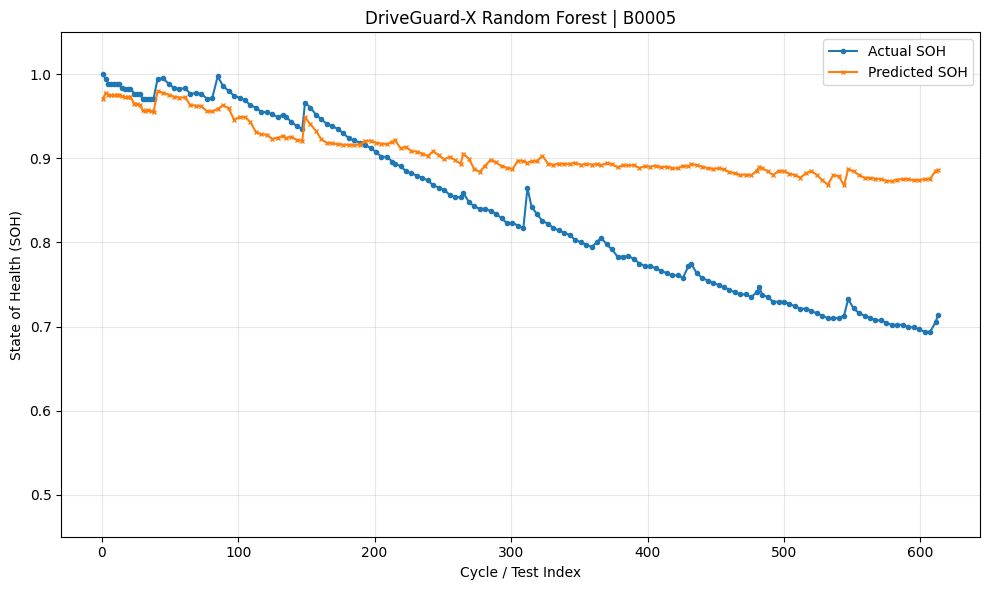

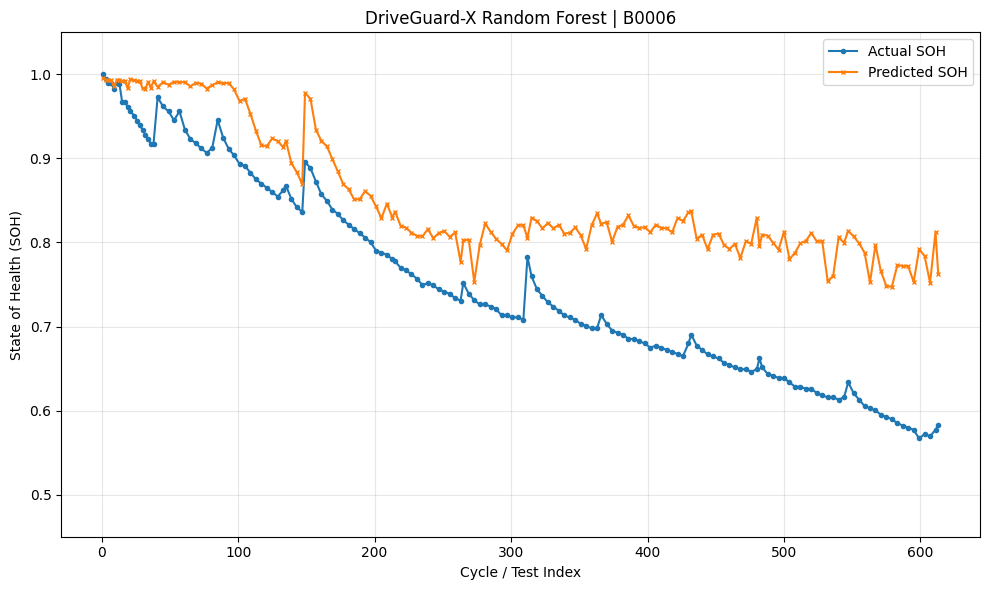

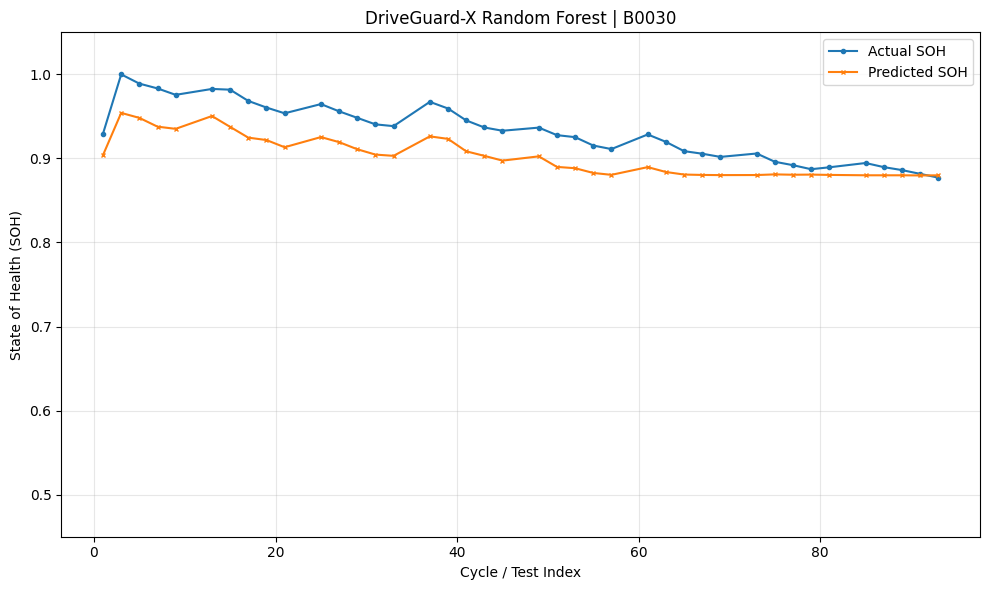

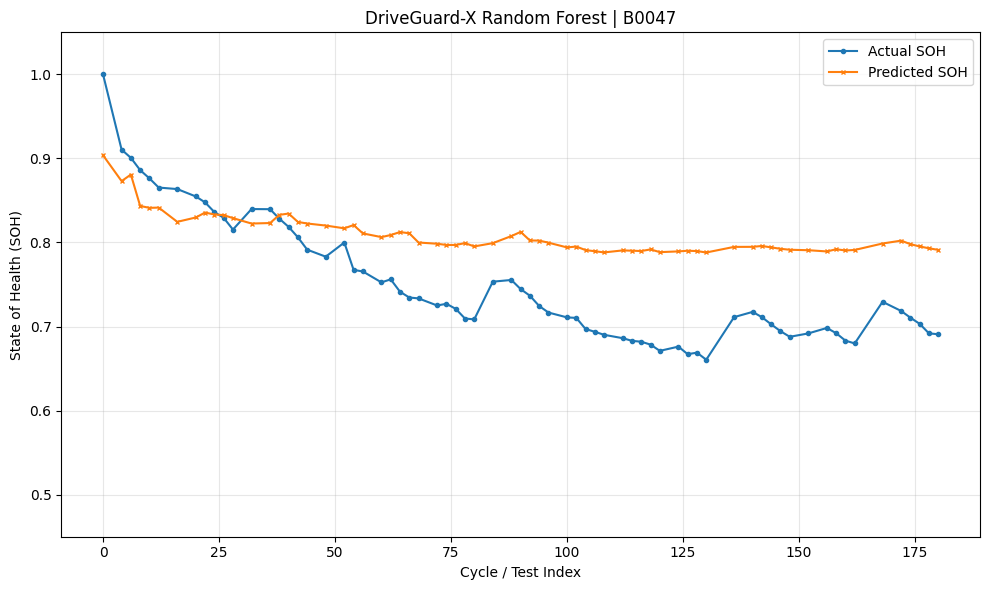

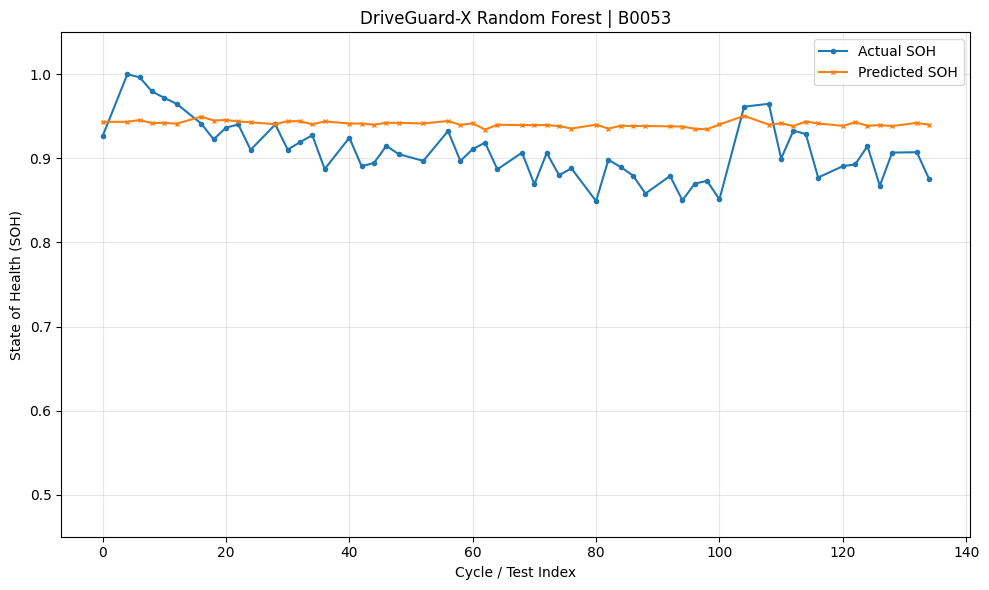

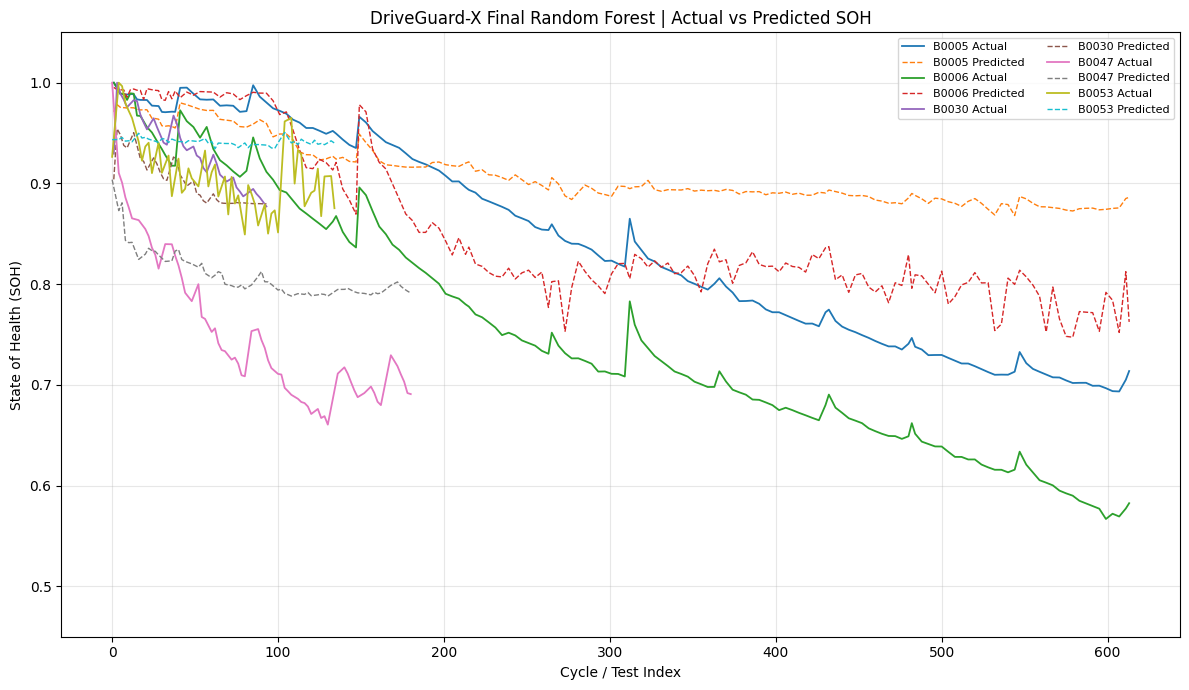


STAGE 6B COMPLETE
Plots saved to:
/kaggle/working/driveguard_x_battery_models/FINAL_BATTERY_MODEL/plots

Batteries plotted: 5
✓ Actual-vs-predicted SOH graphs generated.


In [109]:
# ==================================================================================================
# DRIVEGUARD-X | STAGE 6B
# ACTUAL VS PREDICTED SOH GRAPHS
# ==================================================================================================

import os
import matplotlib.pyplot as plt

print("=" * 100)
print("DRIVEGUARD-X | STAGE 6B")
print("ACTUAL VS PREDICTED SOH")
print("=" * 100)


# ==================================================================================================
# 1. CHECK FINAL PREDICTIONS
# ==================================================================================================

if "final_predictions_df" not in globals():

    raise RuntimeError(
        "final_predictions_df not found. "
        "Please run Stage 6A first."
    )


plot_df = final_predictions_df.copy()

plot_df["battery_id"] = (
    plot_df["battery_id"]
    .astype(str)
)

plot_df = plot_df.sort_values(
    [
        "battery_id",
        "test_id_numeric"
    ]
)


# ==================================================================================================
# 2. CREATE OUTPUT DIRECTORY
# ==================================================================================================

plot_dir = (
    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "FINAL_BATTERY_MODEL/"
    "plots"
)

os.makedirs(
    plot_dir,
    exist_ok=True
)


# ==================================================================================================
# 3. INDIVIDUAL BATTERY GRAPHS
# ==================================================================================================

batteries = sorted(
    plot_df["battery_id"].unique()
)


for battery in batteries:

    battery_df = plot_df[
        plot_df["battery_id"] == battery
    ].copy()

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        battery_df["test_id_numeric"],
        battery_df["SOH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Actual SOH"
    )

    plt.plot(
        battery_df["test_id_numeric"],
        battery_df["Predicted_SOH"],
        marker="x",
        markersize=3,
        linewidth=1.5,
        label="Predicted SOH"
    )

    plt.xlabel(
        "Cycle / Test Index"
    )

    plt.ylabel(
        "State of Health (SOH)"
    )

    plt.title(
        f"DriveGuard-X Random Forest | {battery}"
    )

    plt.ylim(
        0.45,
        1.05
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    output_path = os.path.join(
        plot_dir,
        f"{battery}_actual_vs_predicted.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ==================================================================================================
# 4. COMBINED TEST PERFORMANCE GRAPH
# ==================================================================================================

plt.figure(
    figsize=(12, 7)
)

for battery in batteries:

    battery_df = plot_df[
        plot_df["battery_id"] == battery
    ].copy()

    plt.plot(
        battery_df["test_id_numeric"],
        battery_df["SOH"],
        linewidth=1.3,
        label=f"{battery} Actual"
    )

    plt.plot(
        battery_df["test_id_numeric"],
        battery_df["Predicted_SOH"],
        linestyle="--",
        linewidth=1.0,
        label=f"{battery} Predicted"
    )


plt.xlabel(
    "Cycle / Test Index"
)

plt.ylabel(
    "State of Health (SOH)"
)

plt.title(
    "DriveGuard-X Final Random Forest | Actual vs Predicted SOH"
)

plt.ylim(
    0.45,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.legend(
    ncol=2,
    fontsize=8
)

plt.tight_layout()


combined_path = os.path.join(
    plot_dir,
    "all_test_batteries_actual_vs_predicted.png"
)

plt.savefig(
    combined_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==================================================================================================
# 5. SAVE PREDICTION DATA
# ==================================================================================================

prediction_path = os.path.join(
    plot_dir,
    "final_test_predictions_for_plotting.csv"
)

plot_df.to_csv(
    prediction_path,
    index=False
)


print("\n" + "=" * 100)
print("STAGE 6B COMPLETE")
print("=" * 100)

print(
    f"Plots saved to:\n{plot_dir}"
)

print(
    f"\nBatteries plotted: {len(batteries)}"
)

print(
    "✓ Actual-vs-predicted SOH graphs generated."
)

DRIVEGUARD-X | STAGE 6B
FINAL REPORT GRAPH GENERATION

[1/8] Generating XGBoost MAE comparison...


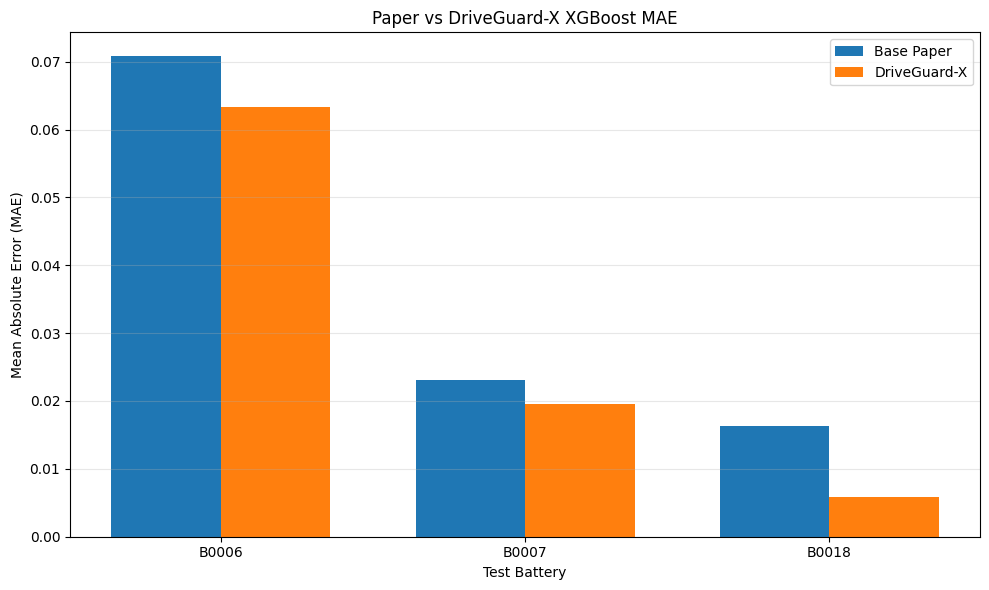

[2/8] Generating XGBoost MSE comparison...


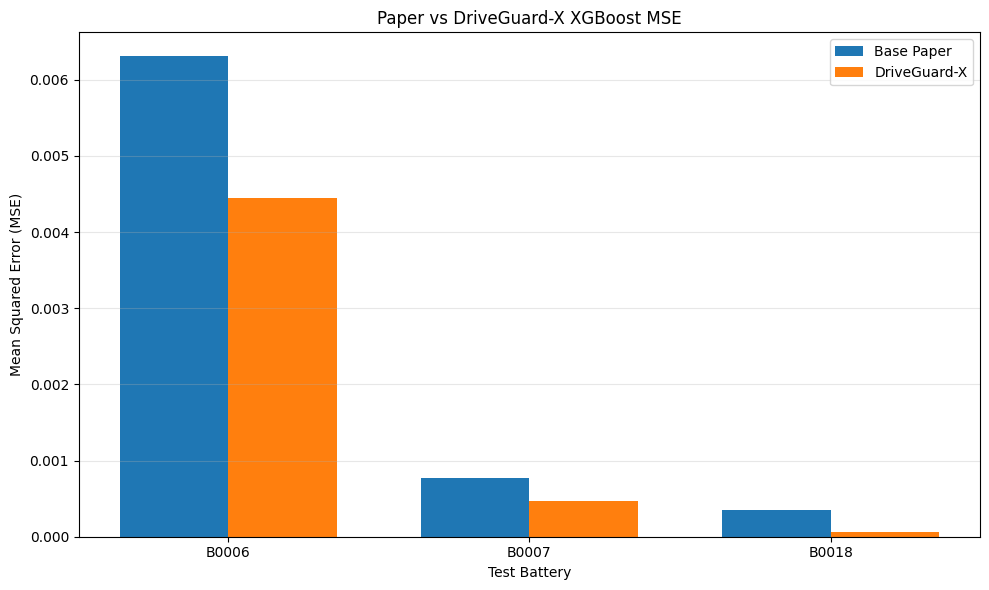

[3/8] Loading final Random Forest predictions...
Prediction dataset shape: (500, 7)
Batteries found: ['B0005', 'B0006', 'B0030', 'B0047', 'B0053']
[3/8] Generating B0005 actual vs predicted SOH...


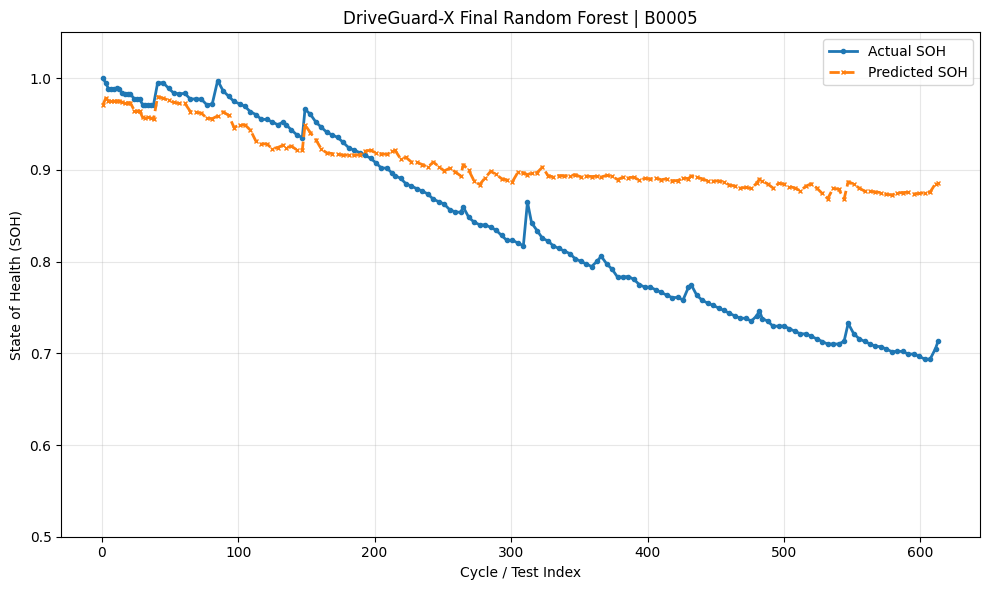

[4/8] Generating B0006 actual vs predicted SOH...


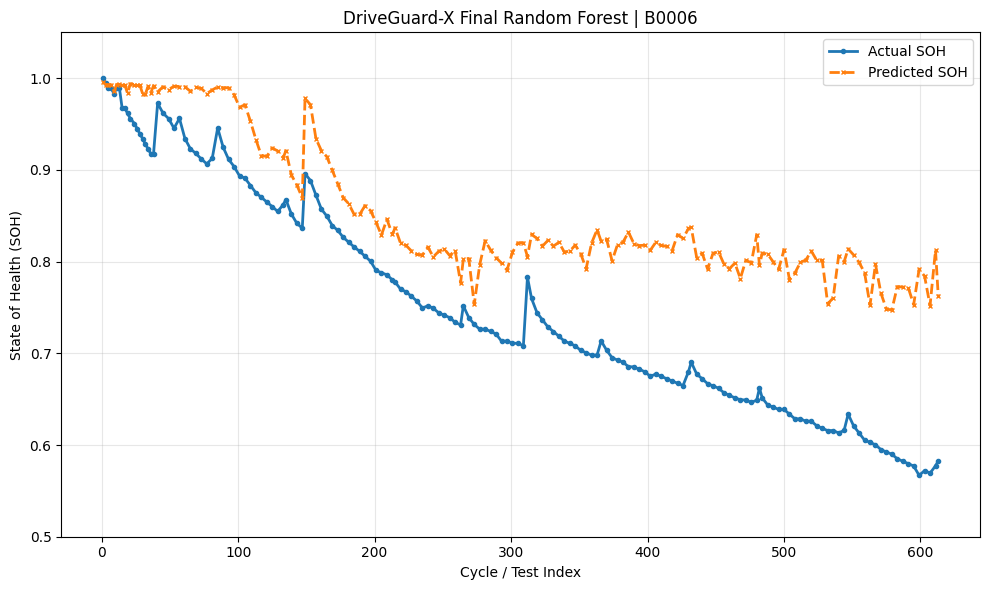

[5/8] Generating B0030 actual vs predicted SOH...


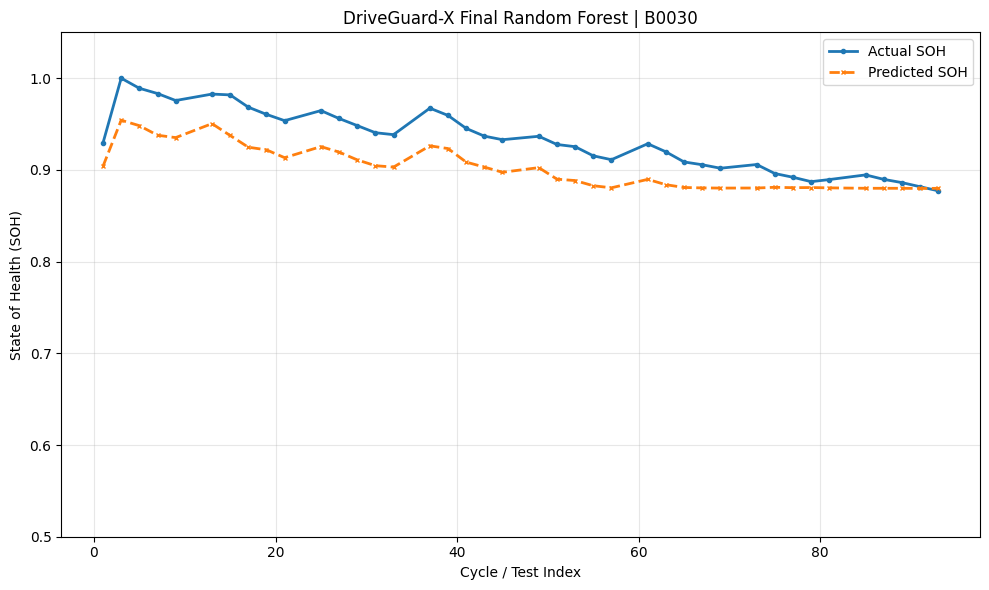

[6/8] Generating B0047 actual vs predicted SOH...


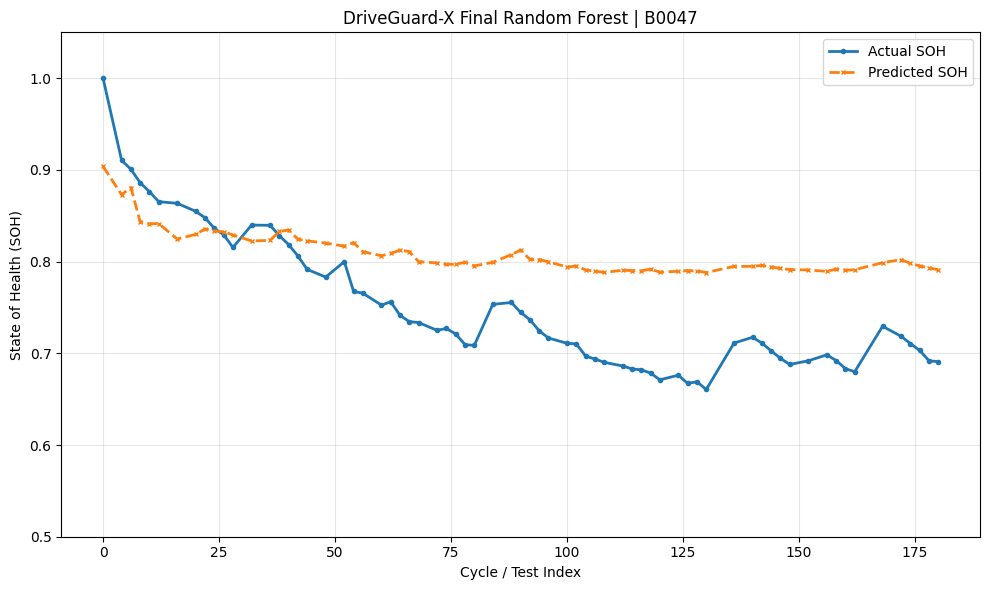

[7/8] Generating B0053 actual vs predicted SOH...


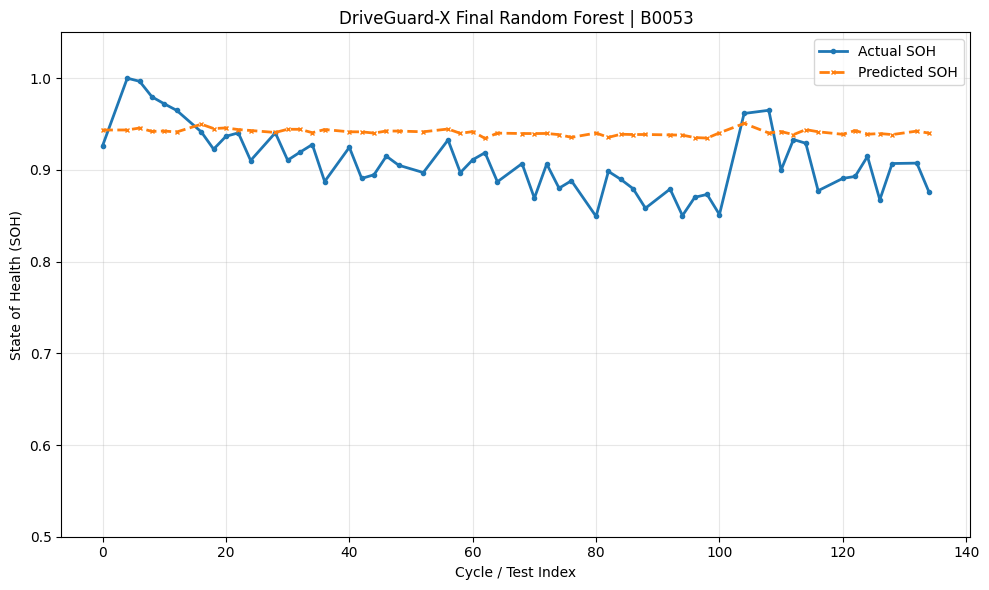

[8/8] Generating final Random Forest feature importance...


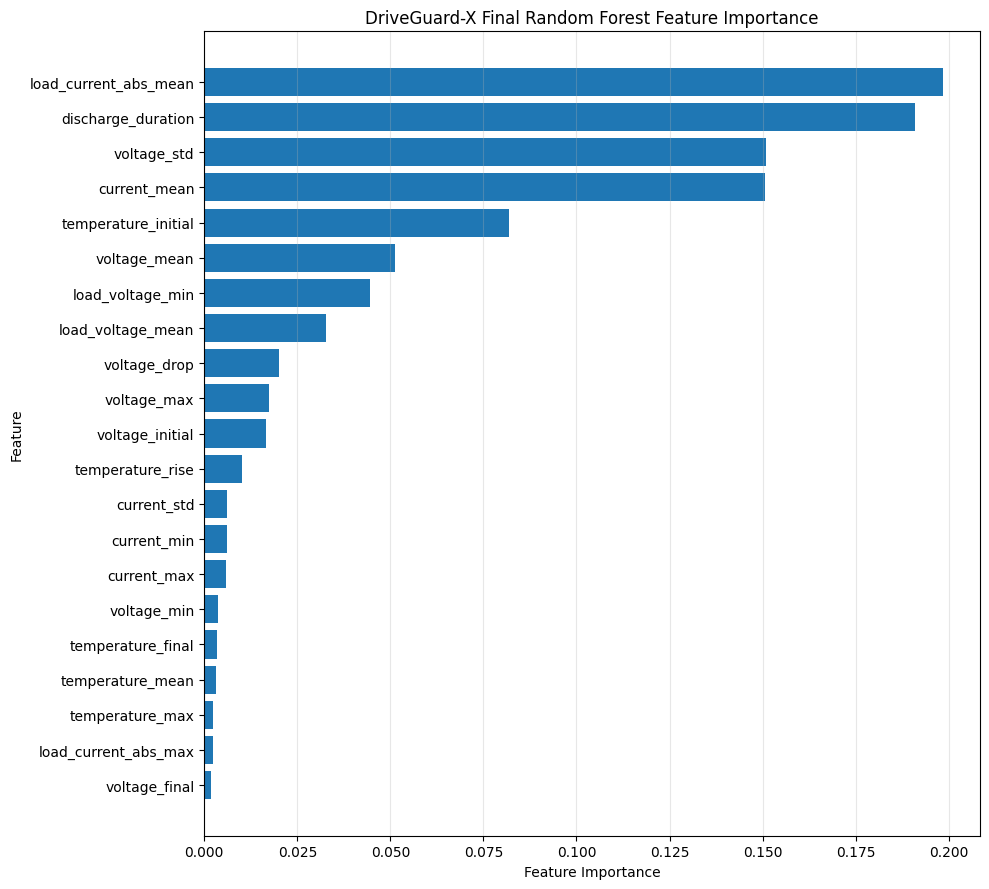


STAGE 6B COMPLETE

All report graphs saved to:
/kaggle/working/driveguard_x_battery_models/FINAL_BATTERY_MODEL/REPORT_GRAPHS

Graph sequence:
Figure 1: Paper vs DriveGuard-X XGBoost MAE -> 01_paper_vs_driveguard_xgb_mae.png
Figure 2: Paper vs DriveGuard-X XGBoost MSE -> 02_paper_vs_driveguard_xgb_mse.png
Figure 3: B0005 Actual vs Predicted SOH -> 03_B0005_actual_vs_predicted_soh.png
Figure 4: B0006 Actual vs Predicted SOH -> 04_B0006_actual_vs_predicted_soh.png
Figure 5: B0030 Actual vs Predicted SOH -> 05_B0030_actual_vs_predicted_soh.png
Figure 6: B0047 Actual vs Predicted SOH -> 06_B0047_actual_vs_predicted_soh.png
Figure 7: B0053 Actual vs Predicted SOH -> 07_B0053_actual_vs_predicted_soh.png
Figure 8: Final Random Forest Feature Importance -> 08_final_random_forest_feature_importance.png

✓ 8 report-quality graphs generated.
✓ Graphs are numbered in the exact order used in the comparison document.


In [110]:
# ==================================================================================================
# DRIVEGUARD-X | STAGE 6B
# FINAL REPORT GRAPH GENERATION
# ==================================================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==================================================================================================
# 0. CONFIGURATION
# ==================================================================================================

MODEL_DIR = (
    "/kaggle/working/"
    "driveguard_x_battery_models/"
    "FINAL_BATTERY_MODEL"
)

PLOT_DIR = os.path.join(
    MODEL_DIR,
    "REPORT_GRAPHS"
)

os.makedirs(
    PLOT_DIR,
    exist_ok=True
)

print("=" * 100)
print("DRIVEGUARD-X | STAGE 6B")
print("FINAL REPORT GRAPH GENERATION")
print("=" * 100)


# ==================================================================================================
# 1. PAPER-COMPATIBLE XGBOOST RESULTS
# ==================================================================================================

paper_xgb = {
    "B0006": {
        "MAE": 0.070787,
        "MSE": 0.006306
    },
    "B0007": {
        "MAE": 0.023080,
        "MSE": 0.000773
    },
    "B0018": {
        "MAE": 0.016356,
        "MSE": 0.000347
    }
}


driveguard_xgb = {
    "B0006": {
        "MAE": 0.063250,
        "MSE": 0.004440
    },
    "B0007": {
        "MAE": 0.019573,
        "MSE": 0.000471
    },
    "B0018": {
        "MAE": 0.005879,
        "MSE": 0.000065
    }
}


batteries_paper = [
    "B0006",
    "B0007",
    "B0018"
]


# ==================================================================================================
# 2. GRAPH 1
# PAPER VS DRIVEGUARD-X XGBOOST MAE
# ==================================================================================================

print("\n[1/8] Generating XGBoost MAE comparison...")

x = np.arange(
    len(batteries_paper)
)

width = 0.36

paper_mae = [
    paper_xgb[b]["MAE"]
    for b in batteries_paper
]

driveguard_mae = [
    driveguard_xgb[b]["MAE"]
    for b in batteries_paper
]

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    paper_mae,
    width,
    label="Base Paper"
)

plt.bar(
    x + width / 2,
    driveguard_mae,
    width,
    label="DriveGuard-X"
)

plt.xticks(
    x,
    batteries_paper
)

plt.xlabel(
    "Test Battery"
)

plt.ylabel(
    "Mean Absolute Error (MAE)"
)

plt.title(
    "Paper vs DriveGuard-X XGBoost MAE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

mae_path = os.path.join(
    PLOT_DIR,
    "01_paper_vs_driveguard_xgb_mae.png"
)

plt.savefig(
    mae_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==================================================================================================
# 3. GRAPH 2
# PAPER VS DRIVEGUARD-X XGBOOST MSE
# ==================================================================================================

print("[2/8] Generating XGBoost MSE comparison...")

paper_mse = [
    paper_xgb[b]["MSE"]
    for b in batteries_paper
]

driveguard_mse = [
    driveguard_xgb[b]["MSE"]
    for b in batteries_paper
]

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    paper_mse,
    width,
    label="Base Paper"
)

plt.bar(
    x + width / 2,
    driveguard_mse,
    width,
    label="DriveGuard-X"
)

plt.xticks(
    x,
    batteries_paper
)

plt.xlabel(
    "Test Battery"
)

plt.ylabel(
    "Mean Squared Error (MSE)"
)

plt.title(
    "Paper vs DriveGuard-X XGBoost MSE"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

mse_path = os.path.join(
    PLOT_DIR,
    "02_paper_vs_driveguard_xgb_mse.png"
)

plt.savefig(
    mse_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==================================================================================================
# 4. LOAD FINAL TEST PREDICTIONS
# ==================================================================================================

print("[3/8] Loading final Random Forest predictions...")

prediction_file = os.path.join(
    MODEL_DIR,
    "final_test_predictions.csv"
)

if not os.path.exists(prediction_file):

    raise FileNotFoundError(
        f"Could not find:\n{prediction_file}"
    )

pred_df = pd.read_csv(
    prediction_file
)

print(
    f"Prediction dataset shape: {pred_df.shape}"
)

print(
    f"Batteries found: "
    f"{sorted(pred_df['battery_id'].astype(str).unique())}"
)


# ==================================================================================================
# 5. DETERMINE CYCLE / TEST INDEX
# ==================================================================================================

if "test_id_numeric" in pred_df.columns:

    x_column = "test_id_numeric"

elif "test_id" in pred_df.columns:

    pred_df["test_id_numeric"] = pd.to_numeric(
        pred_df["test_id"],
        errors="coerce"
    )

    x_column = "test_id_numeric"

else:

    pred_df["cycle_index"] = (
        pred_df
        .groupby("battery_id")
        .cumcount()
        + 1
    )

    x_column = "cycle_index"


pred_df["battery_id"] = (
    pred_df["battery_id"]
    .astype(str)
)


# ==================================================================================================
# 6. GRAPH 3-7
# ACTUAL VS PREDICTED SOH
# ==================================================================================================

test_batteries = [
    "B0005",
    "B0006",
    "B0030",
    "B0047",
    "B0053"
]


for graph_number, battery in enumerate(
    test_batteries,
    start=3
):

    print(
        f"[{graph_number}/8] Generating "
        f"{battery} actual vs predicted SOH..."
    )

    battery_df = pred_df[
        pred_df["battery_id"] == battery
    ].copy()

    if battery_df.empty:

        print(
            f"WARNING: No data found for {battery}"
        )

        continue


    battery_df = battery_df.sort_values(
        x_column
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(
        battery_df[x_column],
        battery_df["SOH"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Actual SOH"
    )


    plt.plot(
        battery_df[x_column],
        battery_df["Predicted_SOH"],
        linewidth=2,
        linestyle="--",
        marker="x",
        markersize=3,
        label="Predicted SOH"
    )


    plt.xlabel(
        "Cycle / Test Index"
    )

    plt.ylabel(
        "State of Health (SOH)"
    )

    plt.title(
        f"DriveGuard-X Final Random Forest | {battery}"
    )

    plt.ylim(
        0.50,
        1.05
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()


    output_path = os.path.join(
        PLOT_DIR,
        f"{graph_number:02d}_{battery}_actual_vs_predicted_soh.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ==================================================================================================
# 7. GRAPH 8
# FINAL RANDOM FOREST FEATURE IMPORTANCE
# ==================================================================================================

print("[8/8] Generating final Random Forest feature importance...")

importance_file = os.path.join(
    MODEL_DIR,
    "final_feature_importance.csv"
)

if not os.path.exists(importance_file):

    raise FileNotFoundError(
        f"Could not find:\n{importance_file}"
    )


importance_df = pd.read_csv(
    importance_file
)


# Normalize column names if necessary

importance_df.columns = [
    str(column).strip()
    for column in importance_df.columns
]


# Identify feature and importance columns

feature_column = None
importance_column = None


for column in importance_df.columns:

    lower = column.lower()

    if "feature" in lower:
        feature_column = column

    if "importance" in lower:
        importance_column = column


if feature_column is None or importance_column is None:

    raise ValueError(
        "Could not identify feature and importance columns."
    )


importance_df = importance_df.sort_values(
    importance_column,
    ascending=True
)


plt.figure(
    figsize=(10, 9)
)

plt.barh(
    importance_df[feature_column],
    importance_df[importance_column]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "DriveGuard-X Final Random Forest Feature Importance"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()


importance_path = os.path.join(
    PLOT_DIR,
    "08_final_random_forest_feature_importance.png"
)

plt.savefig(
    importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ==================================================================================================
# 8. CREATE GRAPH INDEX
# ==================================================================================================

graph_index = pd.DataFrame({
    "Figure": [
        "Figure 1",
        "Figure 2",
        "Figure 3",
        "Figure 4",
        "Figure 5",
        "Figure 6",
        "Figure 7",
        "Figure 8"
    ],

    "Description": [
        "Paper vs DriveGuard-X XGBoost MAE",
        "Paper vs DriveGuard-X XGBoost MSE",
        "B0005 Actual vs Predicted SOH",
        "B0006 Actual vs Predicted SOH",
        "B0030 Actual vs Predicted SOH",
        "B0047 Actual vs Predicted SOH",
        "B0053 Actual vs Predicted SOH",
        "Final Random Forest Feature Importance"
    ],

    "File": [
        "01_paper_vs_driveguard_xgb_mae.png",
        "02_paper_vs_driveguard_xgb_mse.png",
        "03_B0005_actual_vs_predicted_soh.png",
        "04_B0006_actual_vs_predicted_soh.png",
        "05_B0030_actual_vs_predicted_soh.png",
        "06_B0047_actual_vs_predicted_soh.png",
        "07_B0053_actual_vs_predicted_soh.png",
        "08_final_random_forest_feature_importance.png"
    ]
})


index_path = os.path.join(
    PLOT_DIR,
    "graph_index.csv"
)

graph_index.to_csv(
    index_path,
    index=False
)


# ==================================================================================================
# 9. FINAL OUTPUT
# ==================================================================================================

print("\n" + "=" * 100)
print("STAGE 6B COMPLETE")
print("=" * 100)

print(
    f"\nAll report graphs saved to:"
)

print(
    PLOT_DIR
)

print("\nGraph sequence:")

for _, row in graph_index.iterrows():

    print(
        f"{row['Figure']}: "
        f"{row['Description']} "
        f"-> {row['File']}"
    )

print(
    "\n✓ 8 report-quality graphs generated."
)

print(
    "✓ Graphs are numbered in the exact order used in the comparison document."
)